# Setup

## Imports

In [1]:
import numpy as np
import pandas as pd

from rlbench.action_modes.action_mode import MoveArmThenGripper
from rlbench.action_modes.arm_action_modes import JointVelocity
from rlbench.action_modes.gripper_action_modes import Discrete

from rlbench.environment import Environment
from rlbench.task_environment import TaskEnvironment
from rlbench.observation_config import ObservationConfig, CameraConfig


from pyrep.const import RenderMode
from pyrep.objects import Object

import numpy as np
import torch
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from lib.cam_type import CamType
from lib.agent import Agent
from lib.policy_type import PolicyType



from seed import set_seed
from lib.utils import get_task_name
from task_utils import run_grasp_with_agent, demos_and_train_for_task

from itertools import product

set_seed()


In [2]:
## Vision Experiments - Grasp
from rlbench.tasks.vision_static import VisionStatic as Vision_Static
from rlbench.tasks.vision_random import VisionRandom as Vision_Random

## Environment Launch


In [3]:
live_demos = True
DATASET = '' if live_demos else 'PATH/TO/YOUR/DATASET'

obs_config = ObservationConfig()
obs_config.set_all(True) ## important to get the data from the joints etc
cam_config = CameraConfig(rgb=True, depth=True, mask=False, point_cloud=False,
                              render_mode=RenderMode.OPENGL,
                    image_size=(64, 64))
nocam_config = CameraConfig(rgb=False, depth=False, mask=False,
                          render_mode=RenderMode.OPENGL)

## active cameras:
obs_config.right_shoulder_camera = cam_config
obs_config.left_shoulder_camera = cam_config
obs_config.wrist_camera = cam_config


obs_config.overhead_camera = nocam_config
obs_config.front_camera = nocam_config


action_mode = MoveArmThenGripper(
    arm_action_mode=JointVelocity(), gripper_action_mode=Discrete())

env = Environment(
    action_mode, DATASET, obs_config, False)
env.launch()


## Helper Functions to be used later


# Shutdown


In [10]:
env.shutdown()

[CoppeliaSim:loadinfo]   done.


# Grasping Task - Camera Experiments

Here I am investigating the use of multiple cameras aiding a more complex task like a grasping task


## (Static) Grasping with Single Camera
Following form earlier, I want to try each of the cameras I have with this task to see which performs better per static cube and a single demo.

In [4]:
cam_types = [
  CamType.WRIST, ## TODO: wrist seems to perform better with longer epispdes do a run with that
  # CamType.LEFT_SHOULDER,
  # CamType.RIGHT_SHOULDER,
]

task = Vision_Static
## configure the task, so that it is always the same per test here
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": 1000,
  "minibatch_size": 64,
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": False,
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5
}
max_eplens = ["demo_max", 150]
repeats = 20

In [5]:
demos = task_env.get_demos(1, live_demos = True)


[vision_static] scale: 1 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)


In [11]:
df = pd.DataFrame(columns=[
  "task_name", "cam_type", "demo_count", "max_eplen",
  "is_success", "min_distance", "final_distance",
  "gripper_image_paths"
  
], index = range(repeats * len(cam_types) * 2)) 

Running Vision_Static with wrist and 1 demo, repeat: 0
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 217.84it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May11_18-14.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist and 1 demo, repeat: 1
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 217.68it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May11_18-14.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist and 1 demo, repeat: 2
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



...

Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May11_18-18.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist and 1 demo, repeat: 18
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 221.14it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May11_18-18.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist and 1 demo, repeat: 19
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 215.88it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May11_18-18.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)


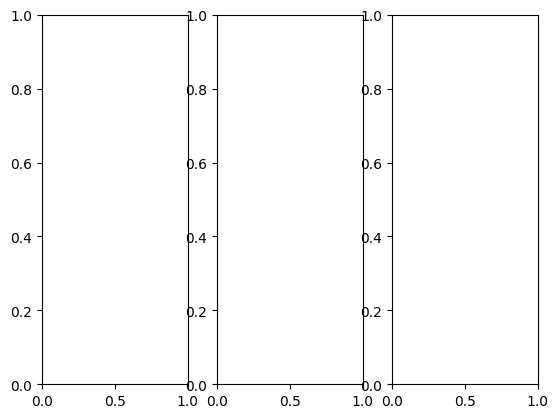

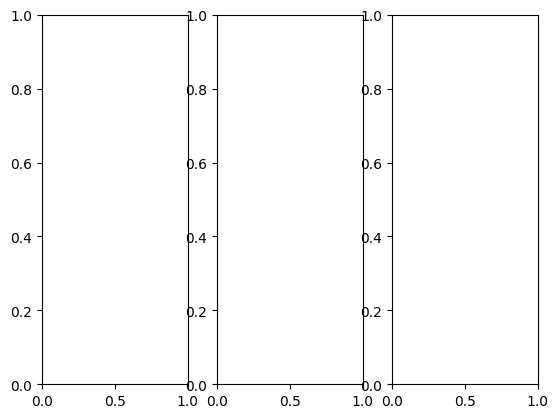

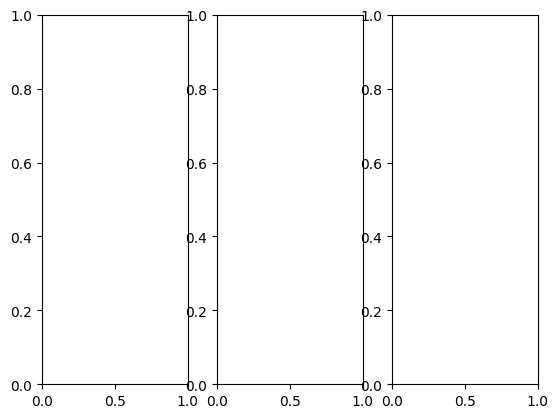

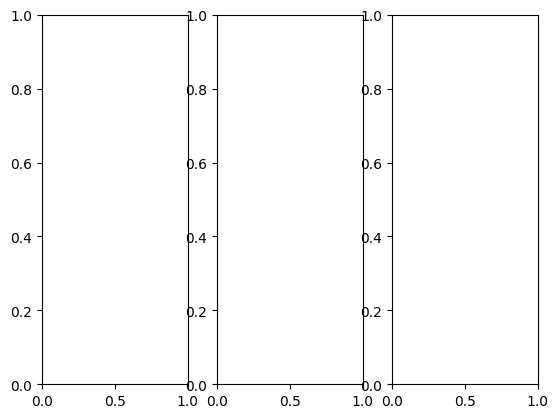

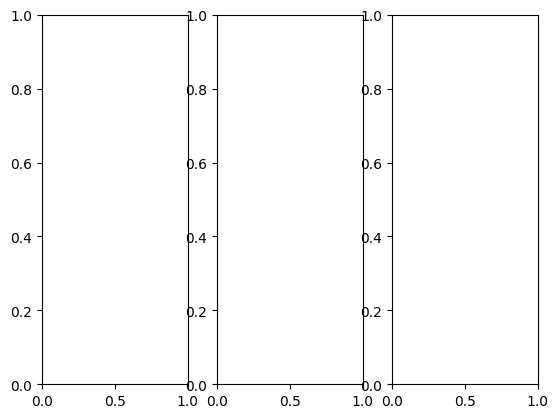

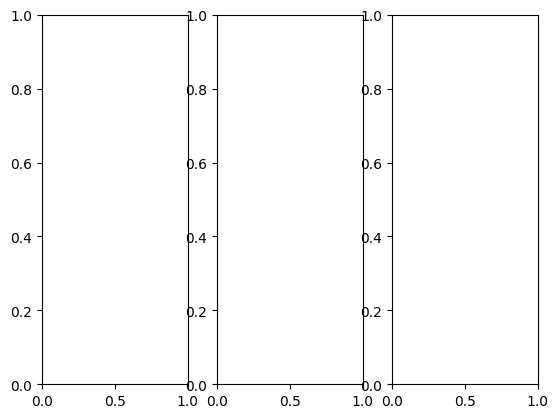

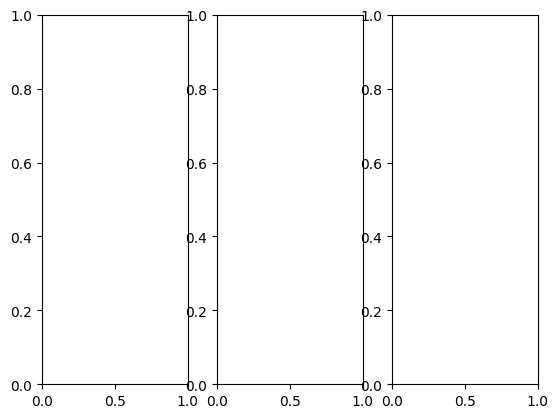

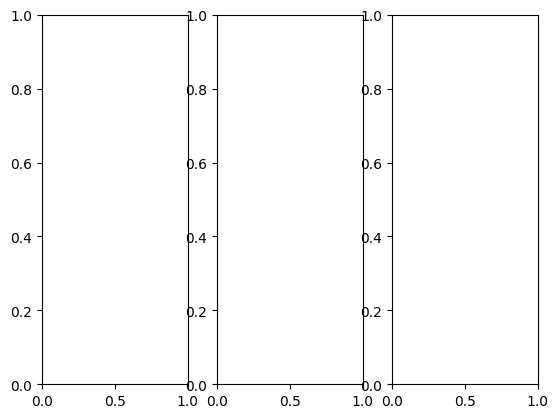

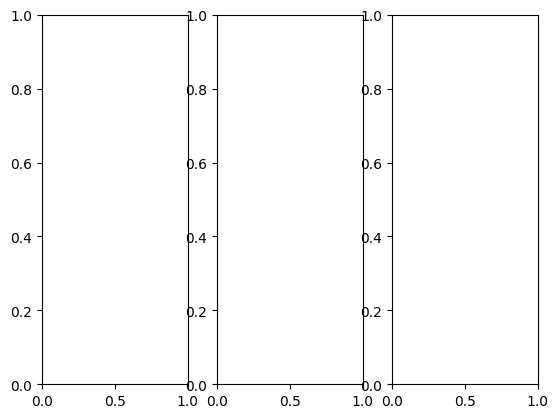

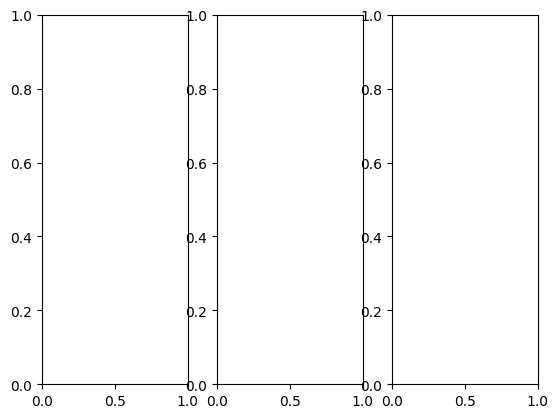

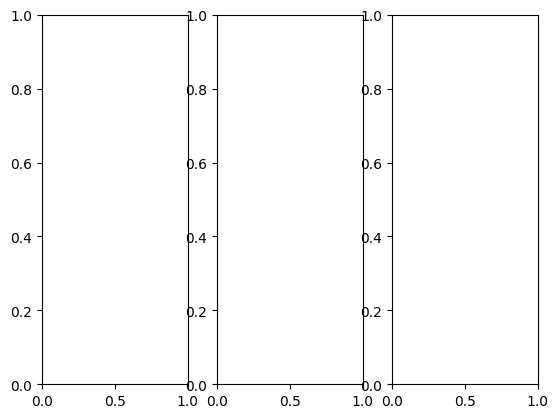

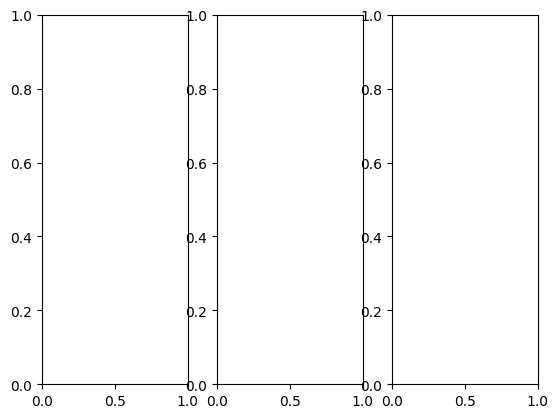

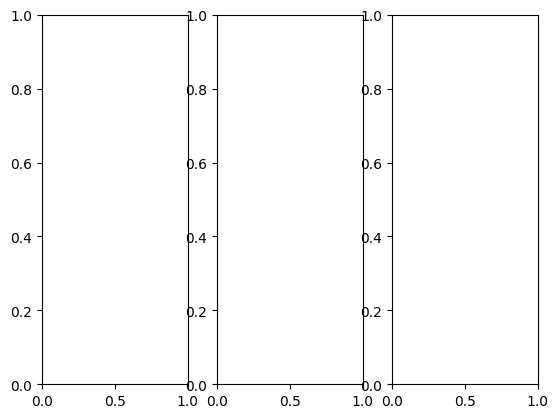

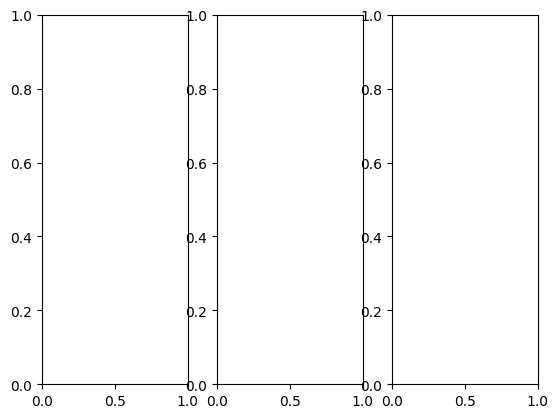

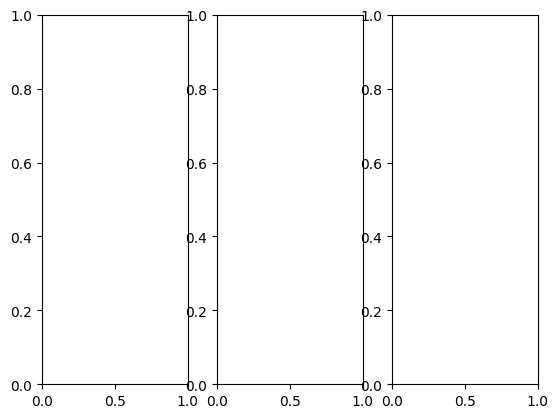

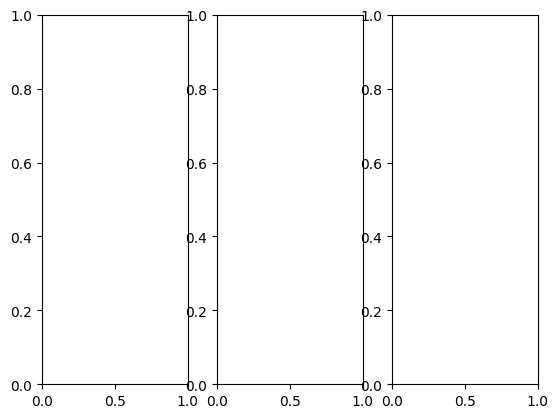

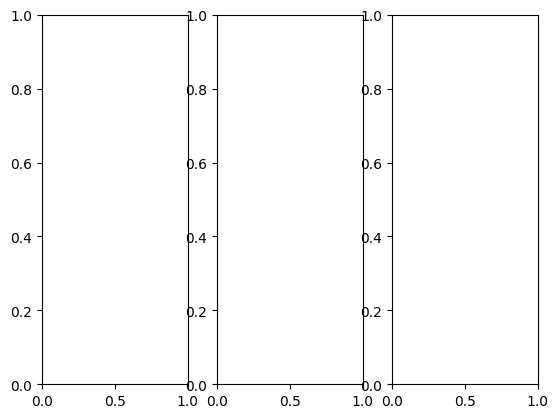

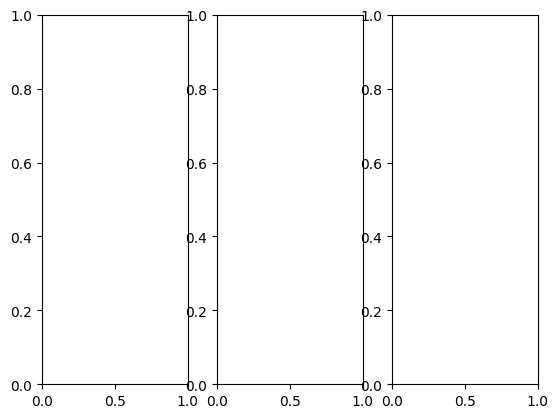

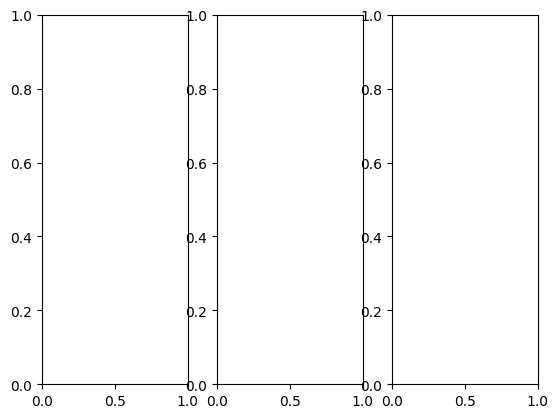

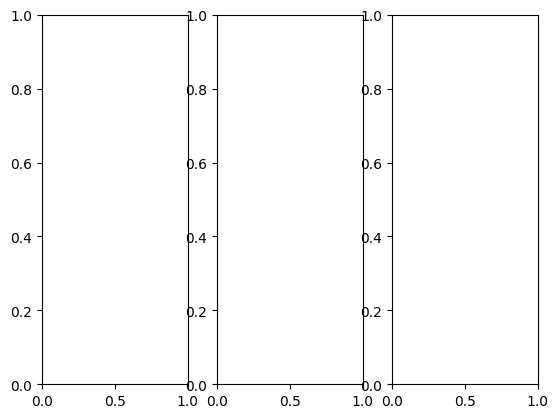

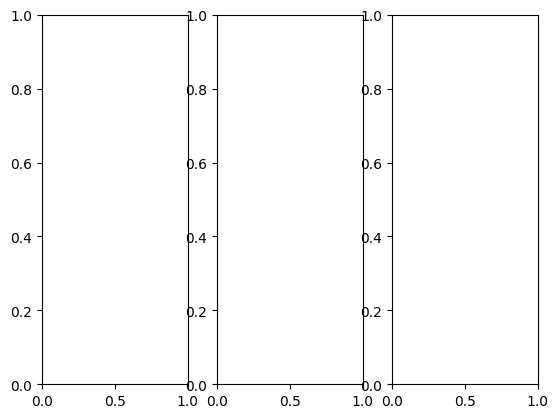

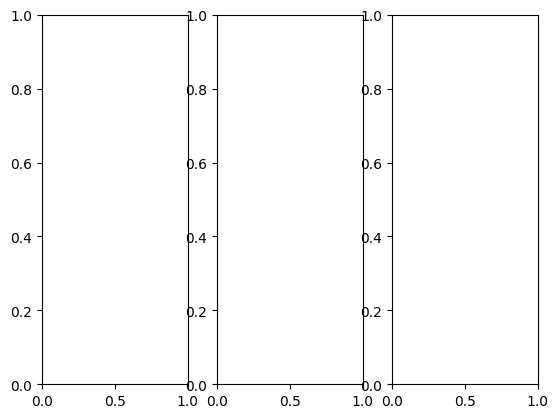

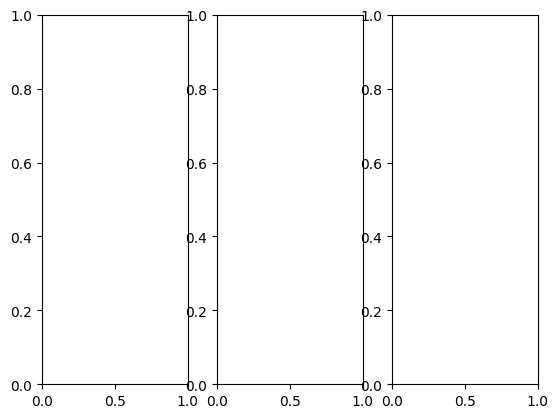

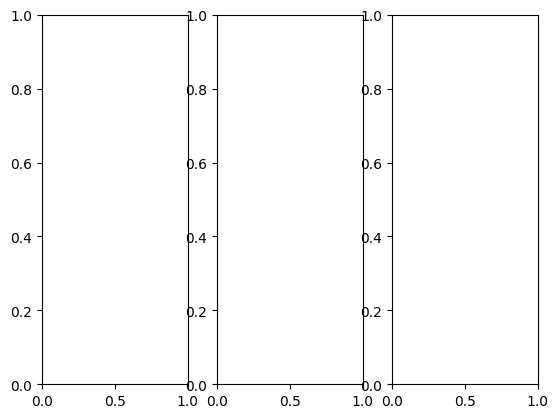

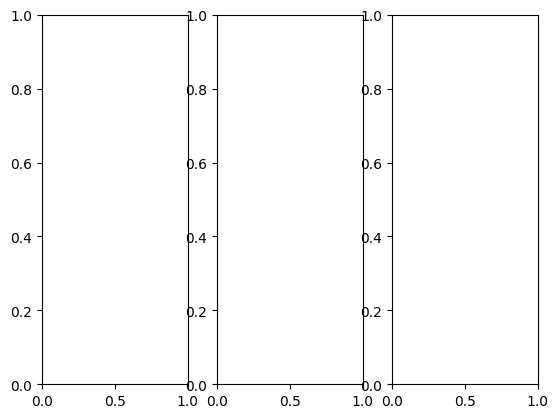

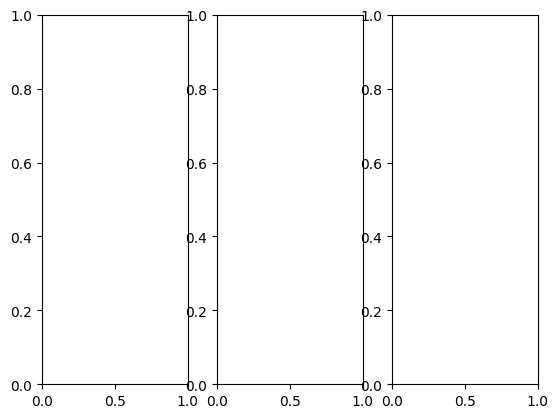

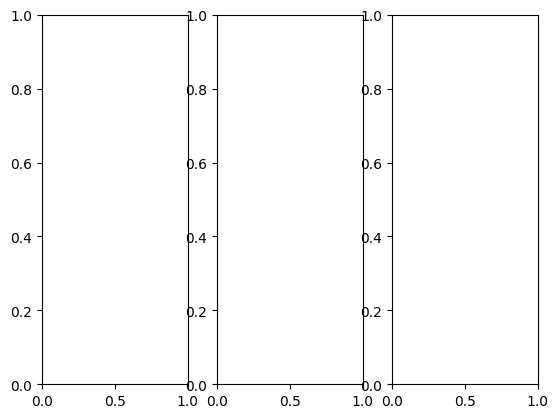

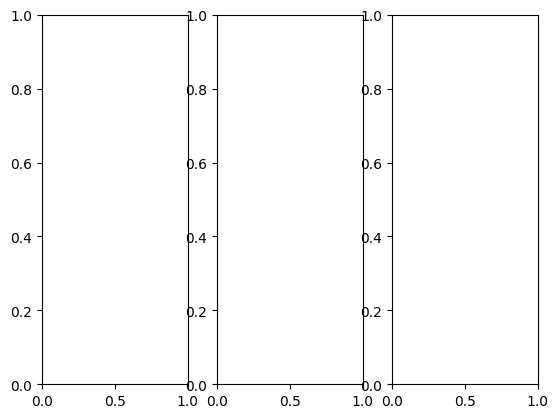

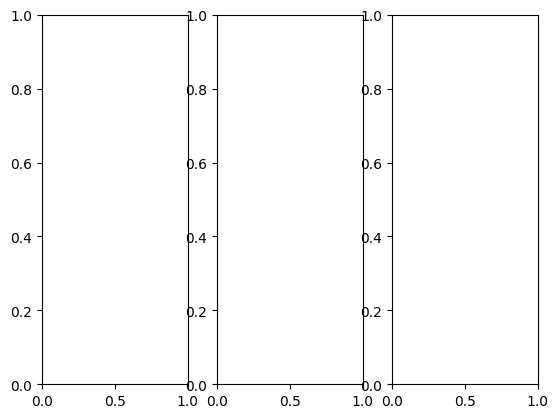

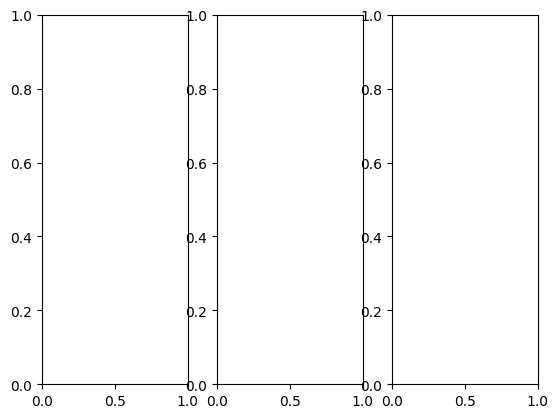

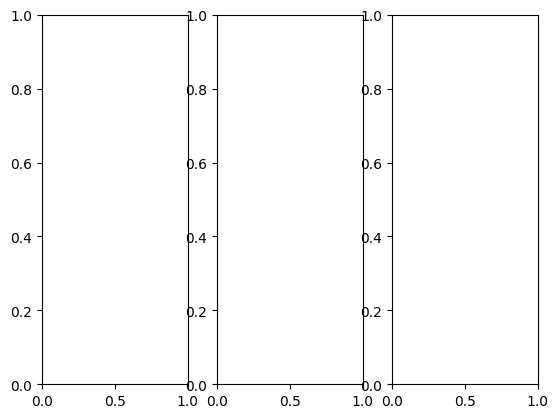

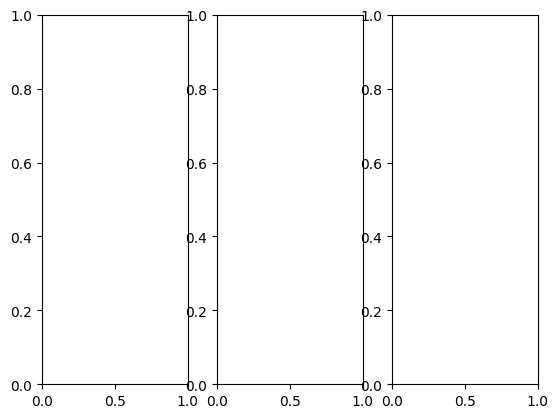

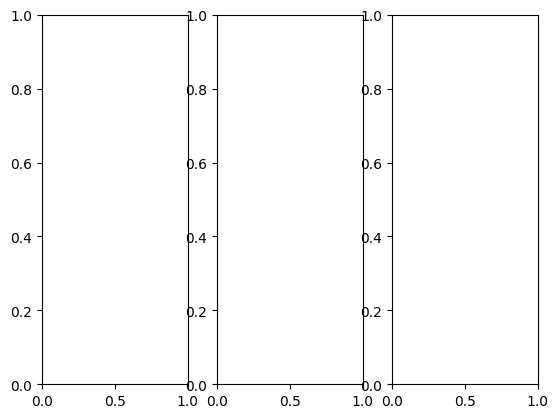

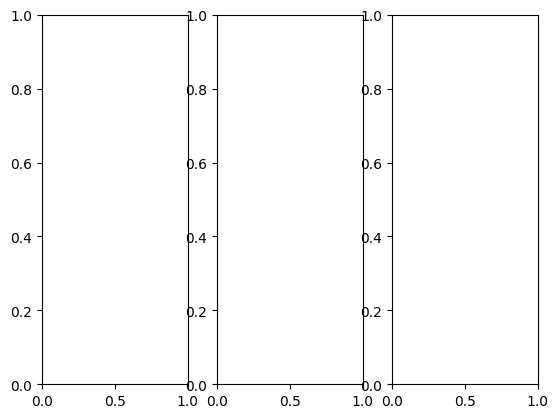

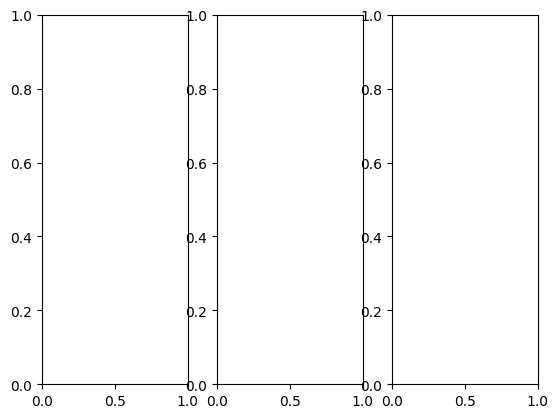

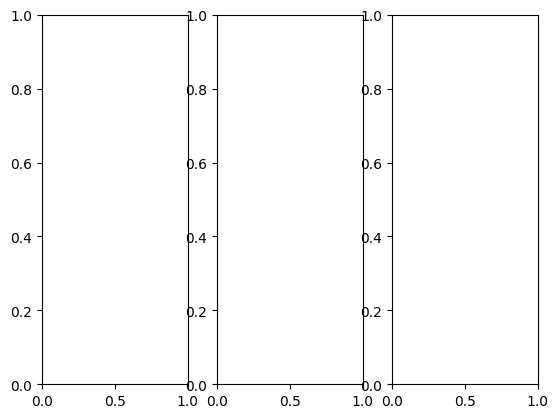

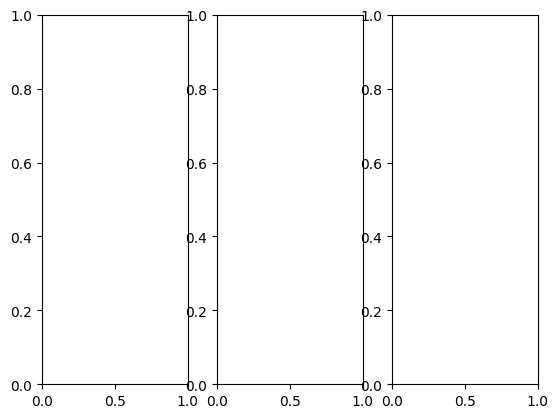

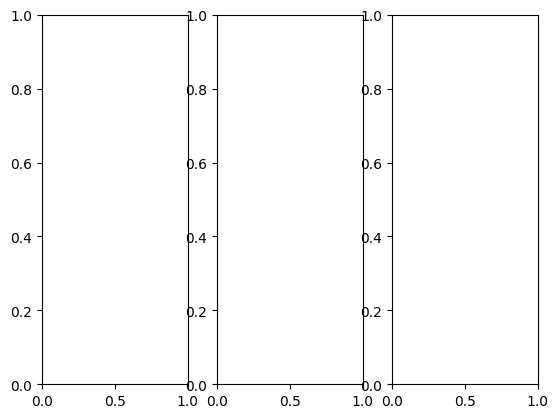

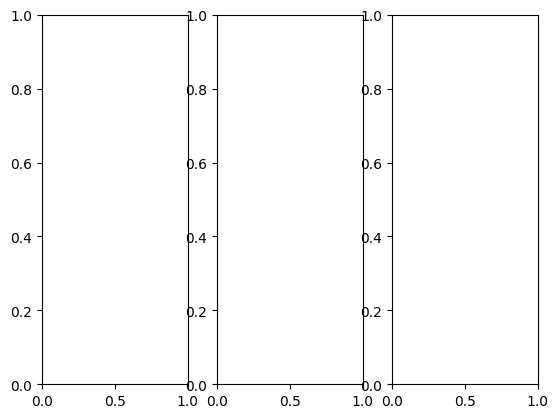

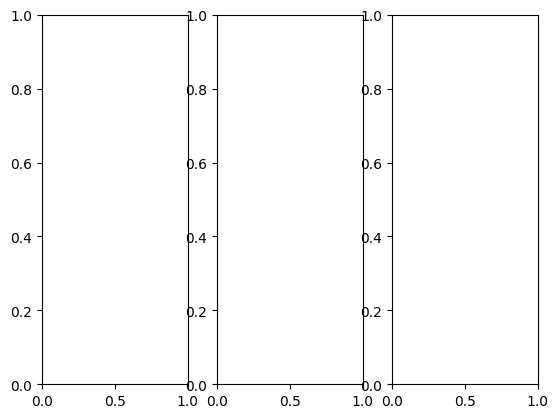

In [12]:
for i, (cam_type, max_eplen, rep) in enumerate(product(cam_types, max_eplens, range(repeats))):

  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 

  # max_eplen = 250 if cam_type == CamType.WRIST else "demo_max"


  rets, done = run_grasp_with_agent(
    env, task, agent, demos, max_eplen = max_eplen, ## TODO: try 'demo_max'?? 

    training_params=training_params, 
    task_params=task_params,
    
    print_index=i
  )

  df.loc[i] = {
    "task_name": get_task_name(task),
    "cam_type": cam_type,
    "demo_count": 1,
    "max_eplen": max_eplen,
    "is_success": done,
    "min_distance": min(rets["distances"]),
    "final_distance": rets["distances"][-1],
    "gripper_image_paths": rets["gripper_image_paths"]

  }
  df.to_csv("vision_single_static-just_wrist-results.csv", index=True)



## (Static) Grasping with combinations of cameras


In [6]:
list(filter(lambda ct: ct not in cam_types, CamType.all_combinations()))

[<CamType.LEFT_SHOULDER: 2>,
 <CamType.WRIST|LEFT_SHOULDER: 3>,
 <CamType.RIGHT_SHOULDER: 4>,
 <CamType.WRIST|RIGHT_SHOULDER: 5>,
 <CamType.LEFT_SHOULDER|RIGHT_SHOULDER: 6>,
 <CamType.WRIST|LEFT_SHOULDER|RIGHT_SHOULDER: 7>]

In [7]:
cam_types_single = cam_types
## all cameras
cam_types = list(filter(lambda ct: ct not in cam_types_single, CamType.all_combinations()))

task = Vision_Static
## configure the task, so that it is always the same per test here
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": 1000,
  "minibatch_size": 64,
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": False,
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5
}

max_eplens = ["demo_max", 150]

repeats = 20
cam_types

[<CamType.LEFT_SHOULDER: 2>,
 <CamType.WRIST|LEFT_SHOULDER: 3>,
 <CamType.RIGHT_SHOULDER: 4>,
 <CamType.WRIST|RIGHT_SHOULDER: 5>,
 <CamType.LEFT_SHOULDER|RIGHT_SHOULDER: 6>,
 <CamType.WRIST|LEFT_SHOULDER|RIGHT_SHOULDER: 7>]

In [8]:
df = pd.DataFrame(columns=[
  "task_name", "cam_type", "demo_count", "max_eplen",
  "is_success", "min_distance", "final_distance",
  "gripper_image_paths"
  
], index = range(repeats * len(cam_types) * 2))

Running Vision_Static with l_shoulder and 1 demo, repeat: 0
[simple_policy] - Policy] Using l_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: l_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 207.36it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-l_shoulder--_May12_12-28.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with l_shoulder and 1 demo, repeat: 1
[simple_policy] - Policy] Using l_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: l_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 227.40it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-l_shoulder--_May12_12-28.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with l_shoulder and 1 demo, repeat: 2
[simple_policy] - Policy] Using l_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: l_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



...

Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist+l_shoulder+r_shoulder--_May12_12-55.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist+l_shoulder+r_shoulder and 1 demo, repeat: 18
[simple_policy] - Policy] Using wrist+l_shoulder+r_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: wrist+l_shoulder+r_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:08<00:00, 113.10it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist+l_shoulder+r_shoulder--_May12_12-56.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist+l_shoulder+r_shoulder and 1 demo, repeat: 19
[simple_policy] - Policy] Using wrist+l_shoulder+r_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: wrist+l_shoulder+r_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:08<00:00, 121.94it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist+l_shoulder+r_shoulder--_May12_12-56.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)


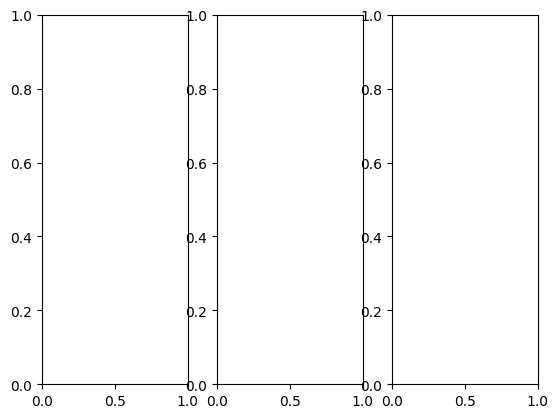

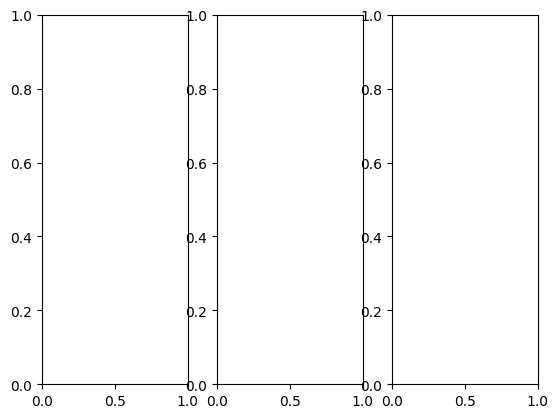

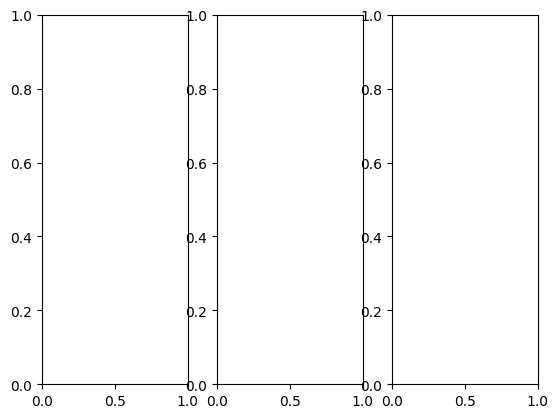

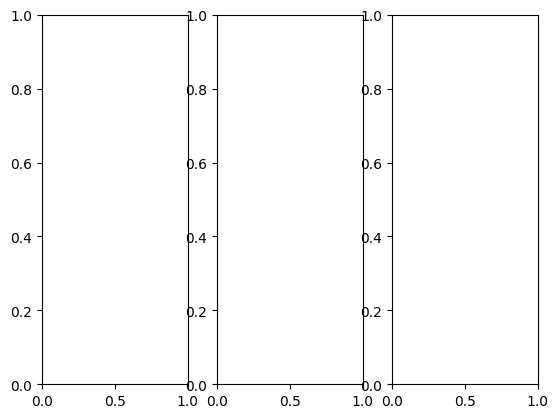

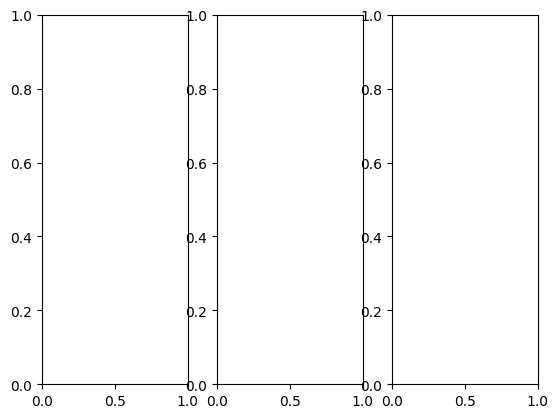

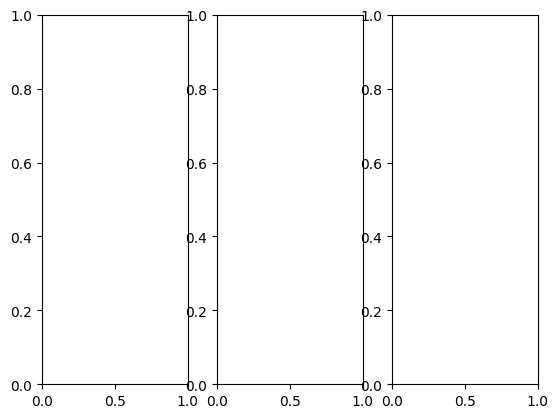

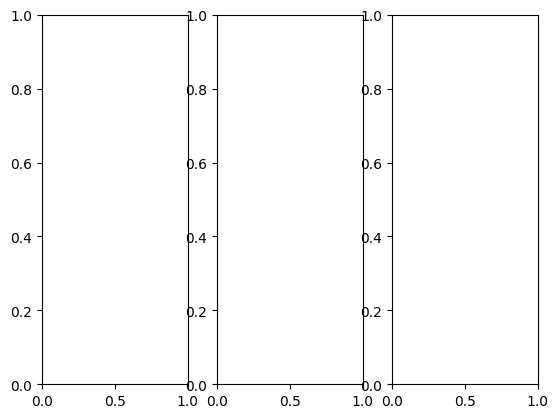

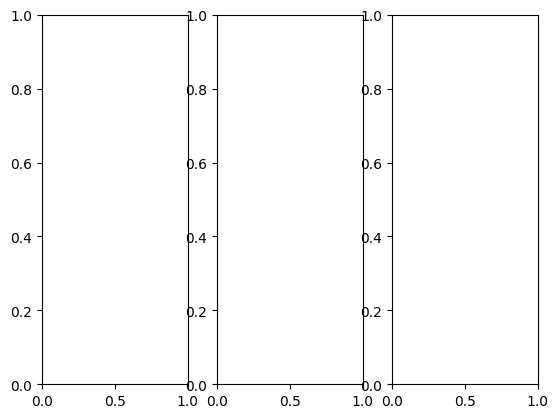

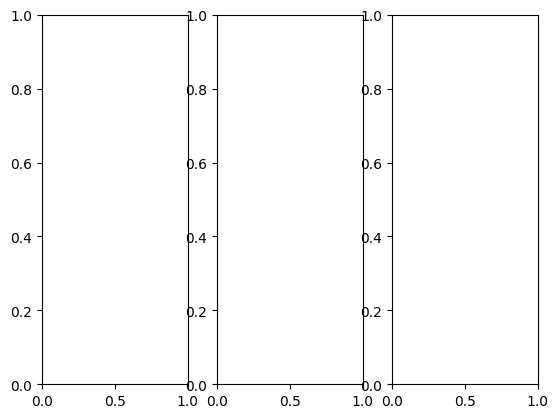

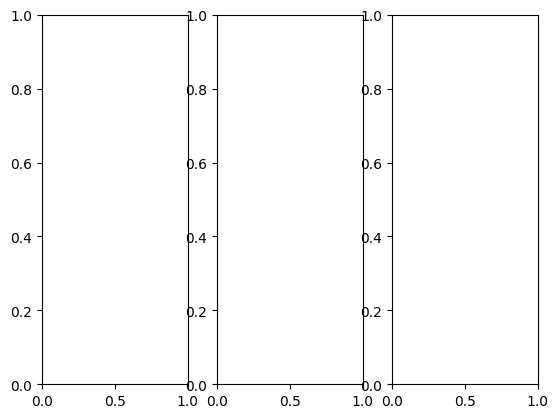

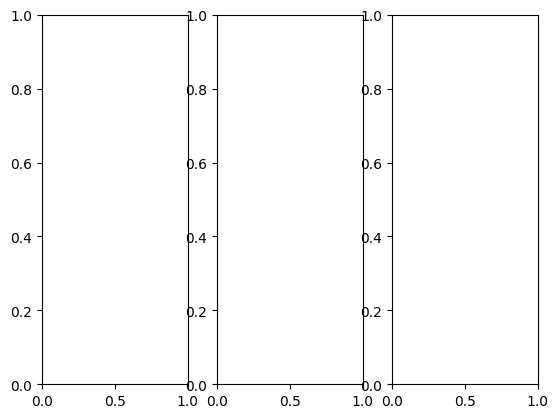

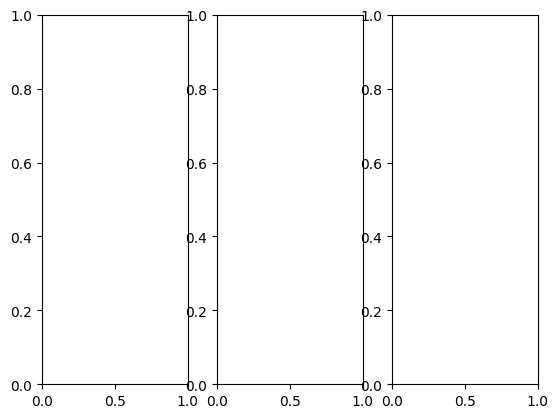

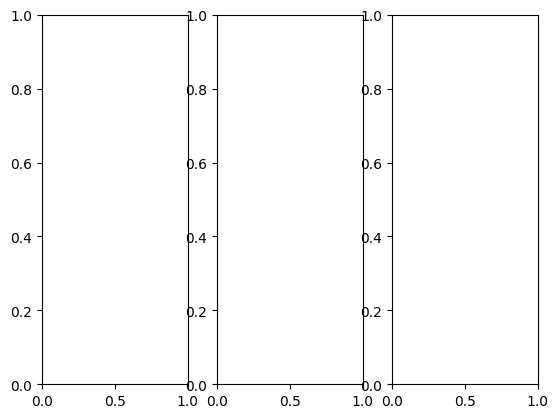

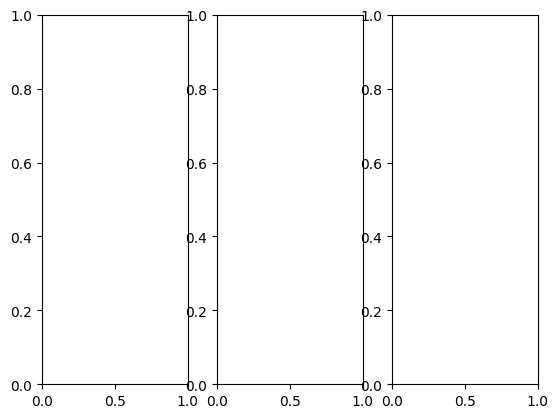

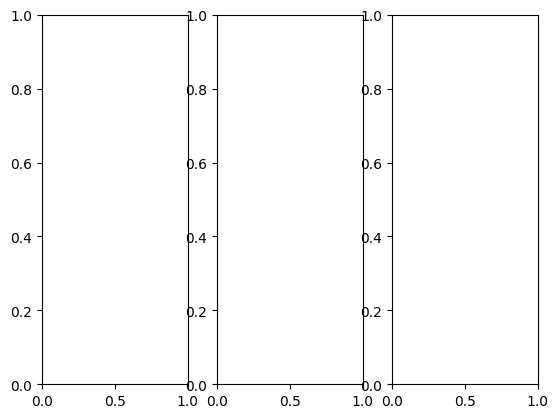

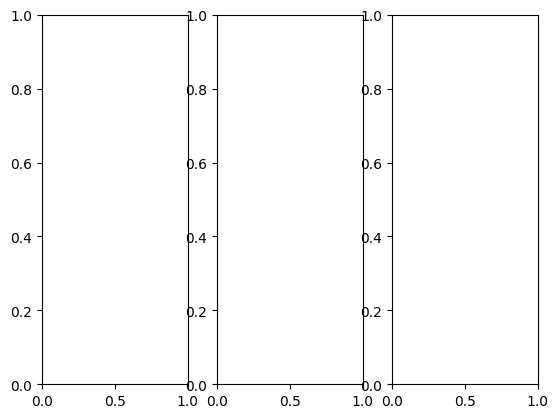

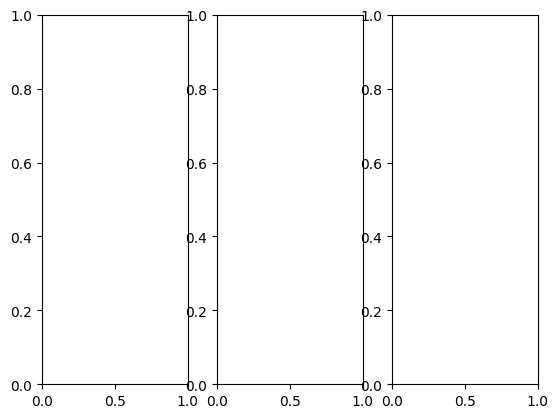

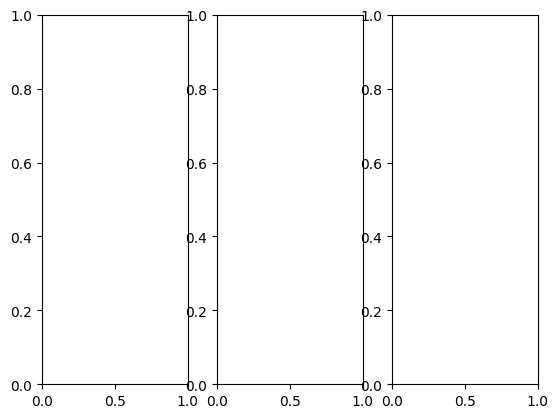

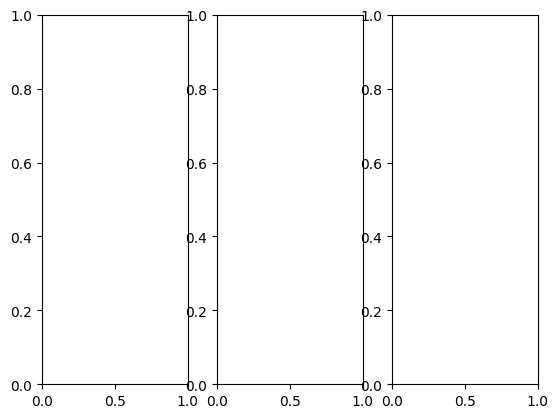

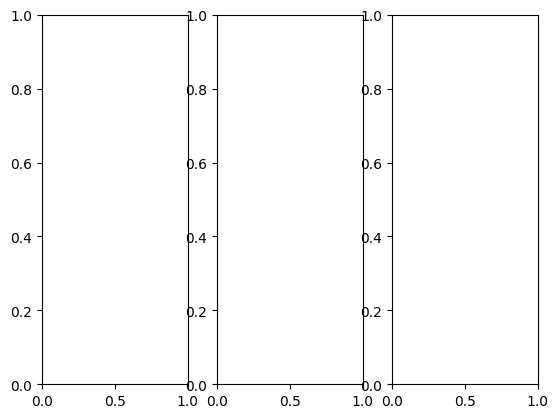

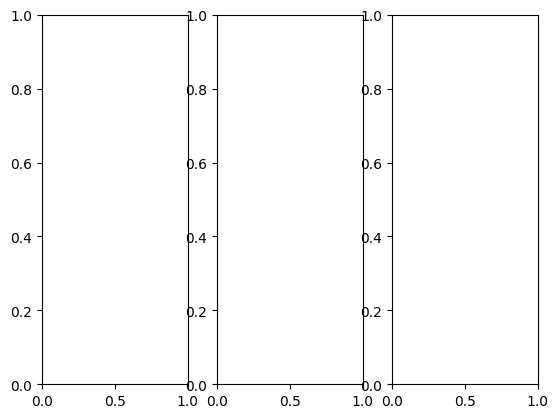

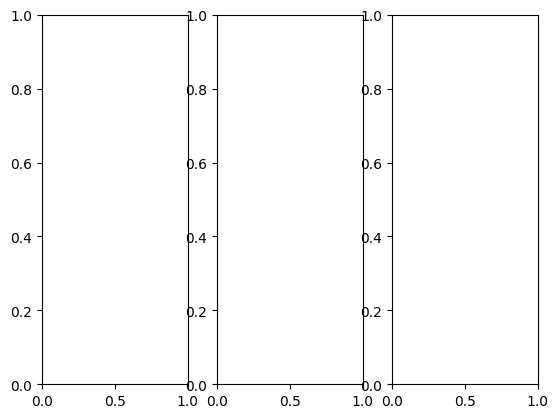

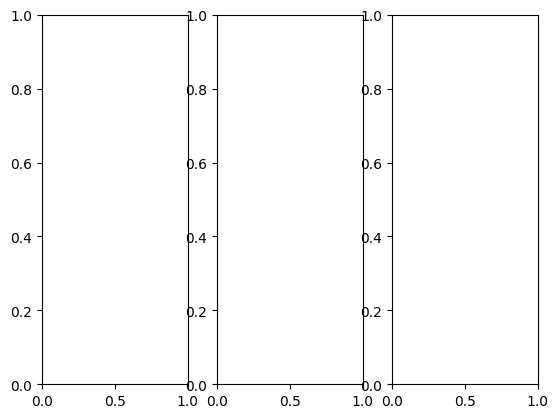

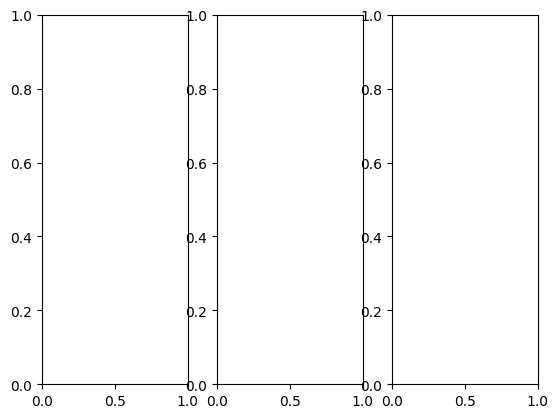

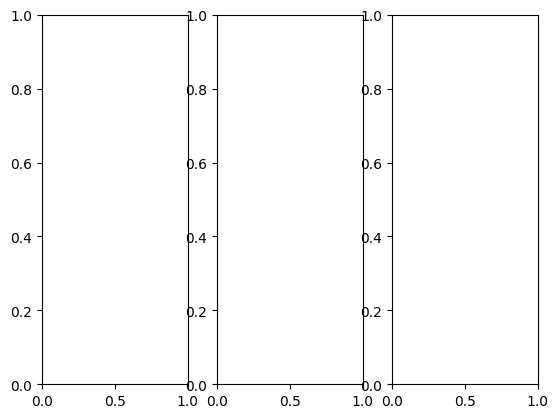

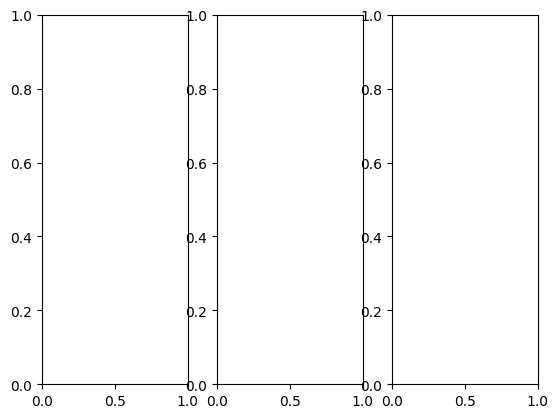

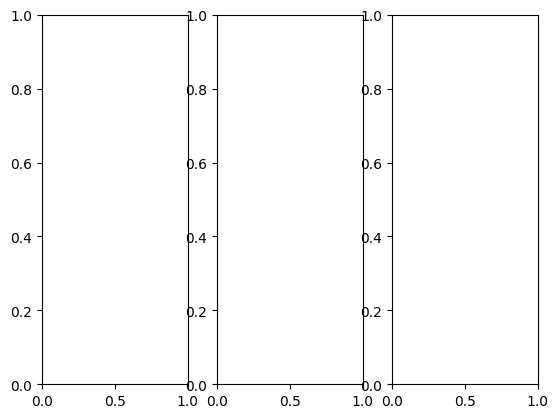

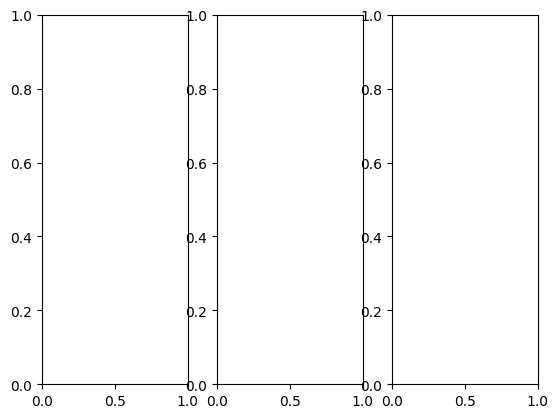

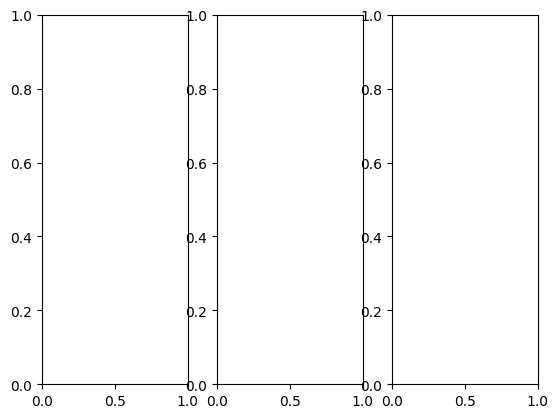

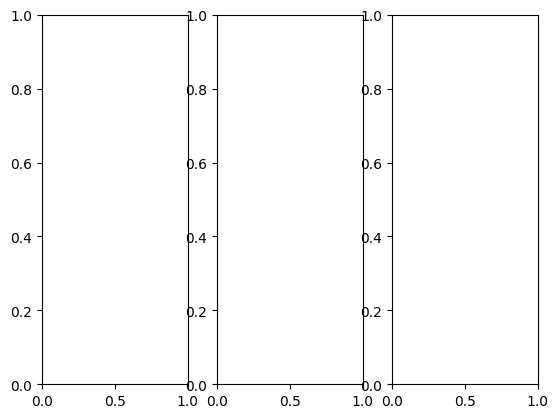

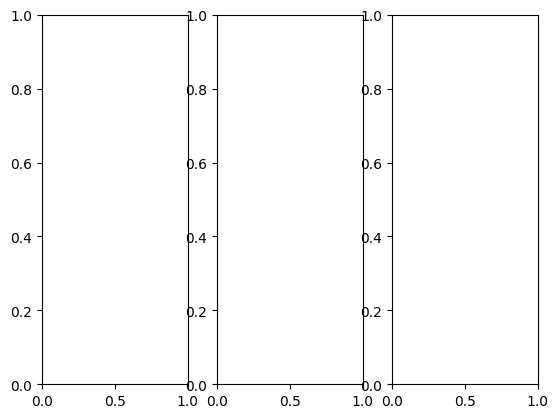

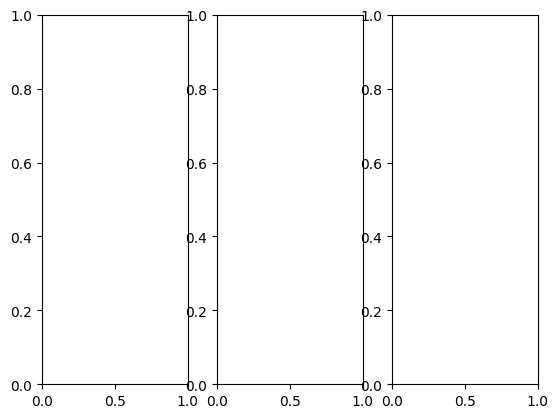

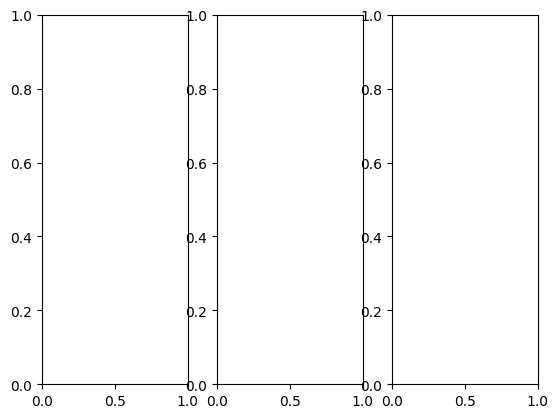

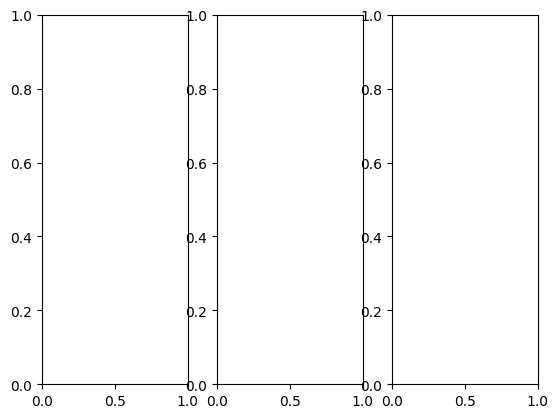

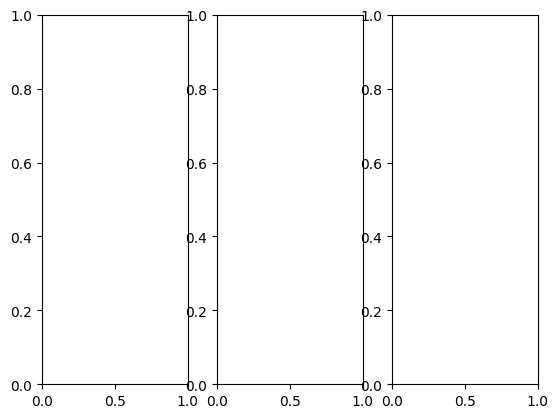

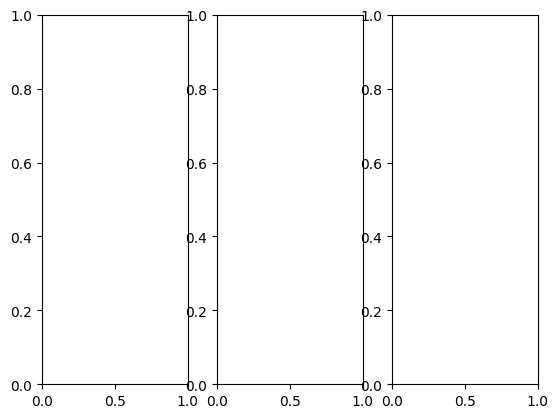

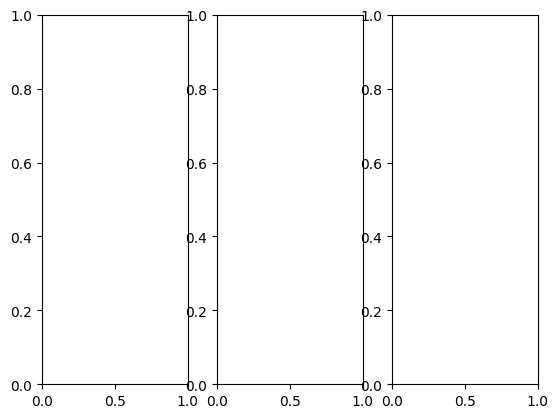

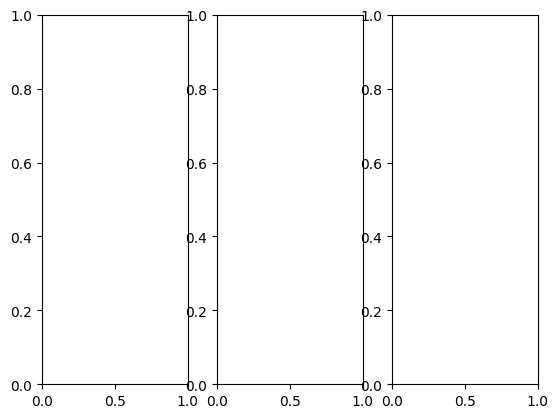

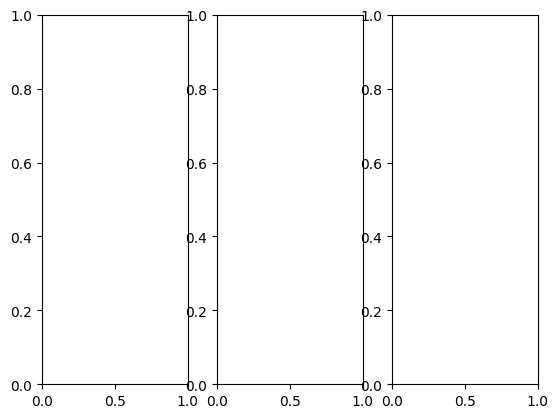

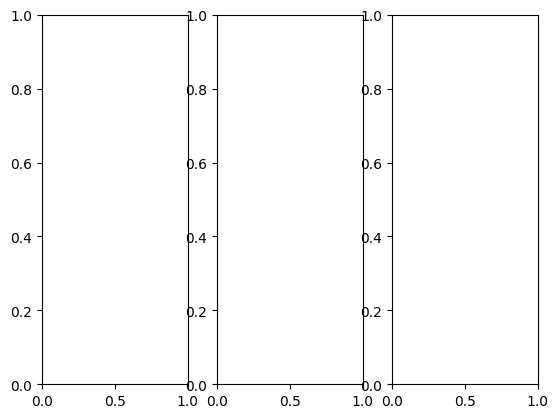

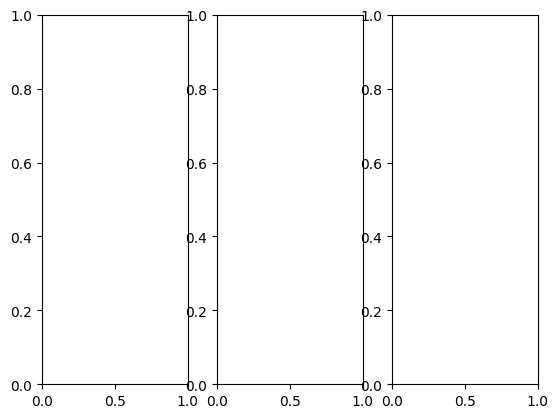

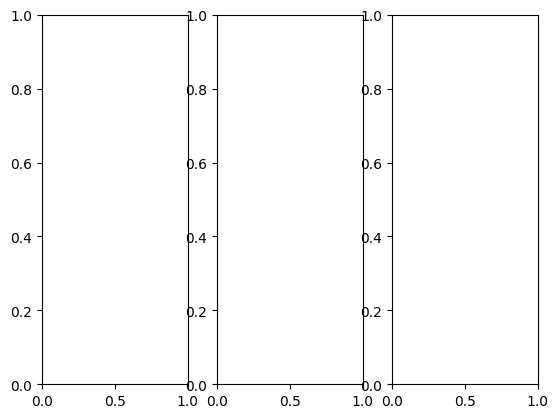

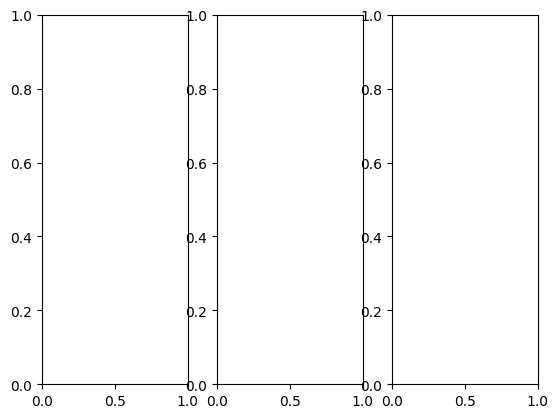

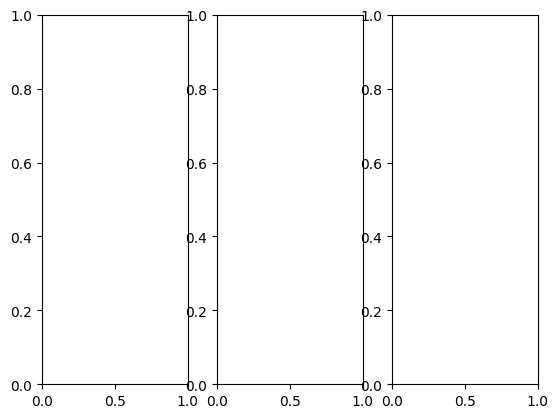

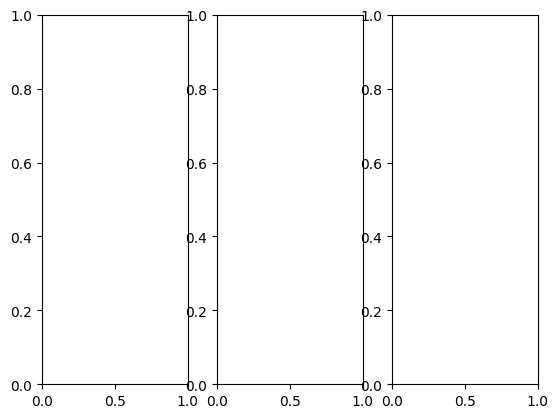

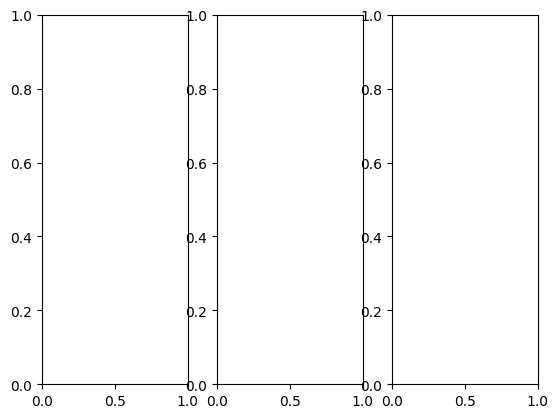

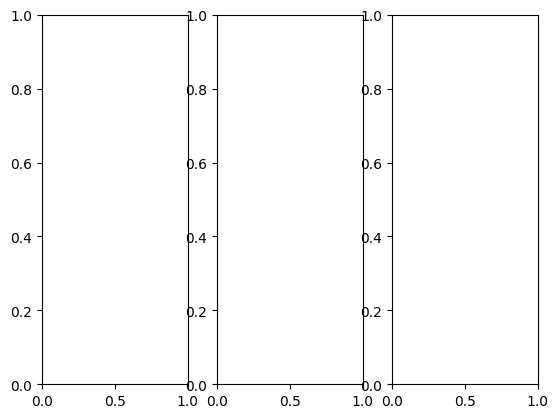

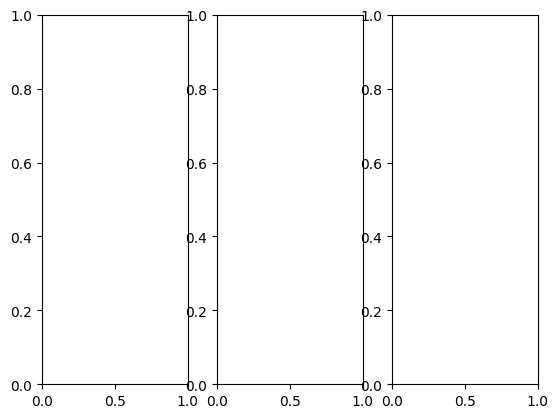

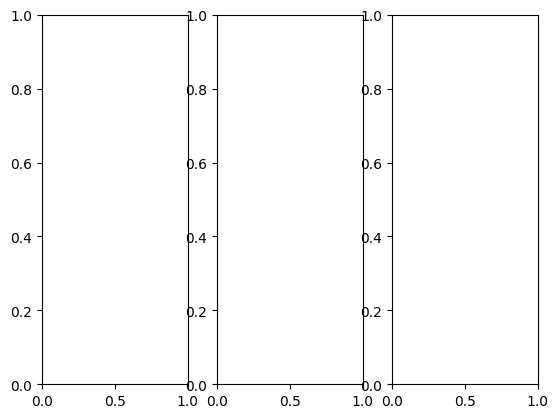

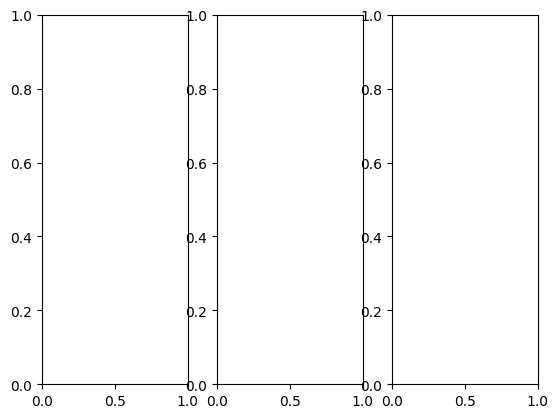

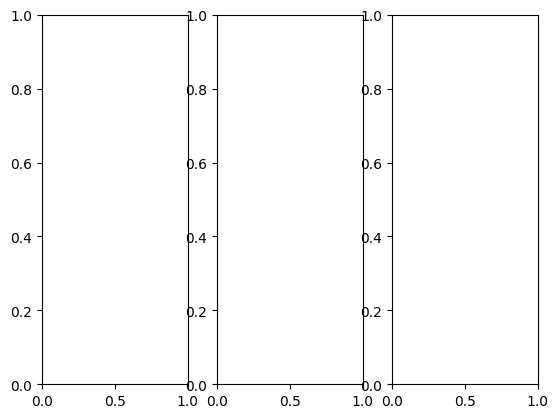

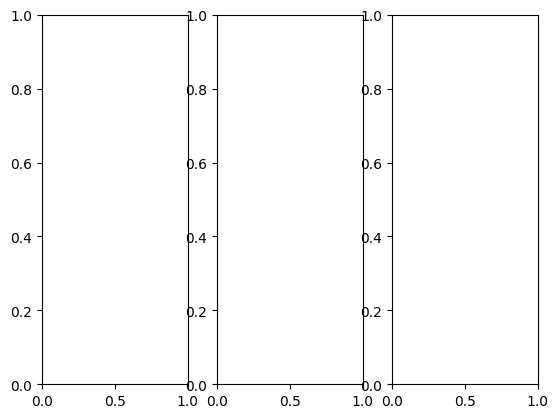

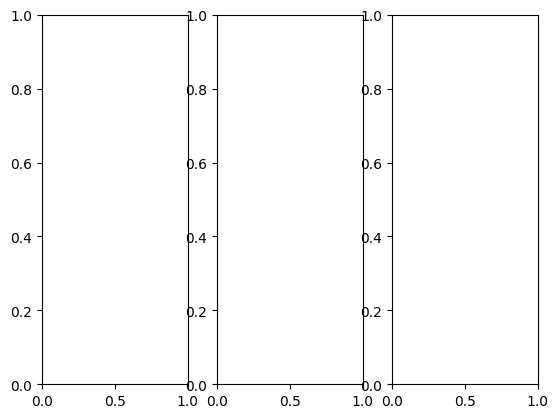

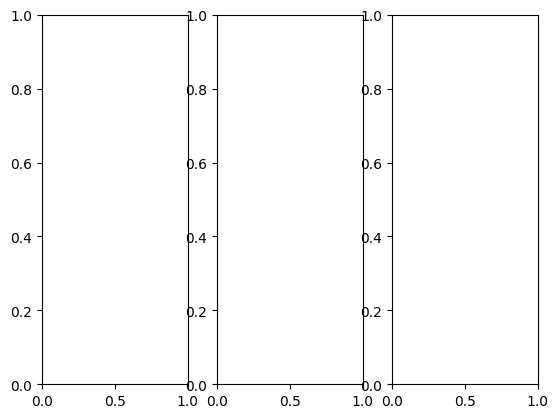

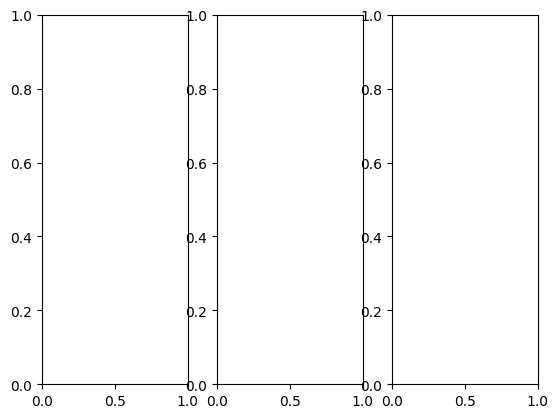

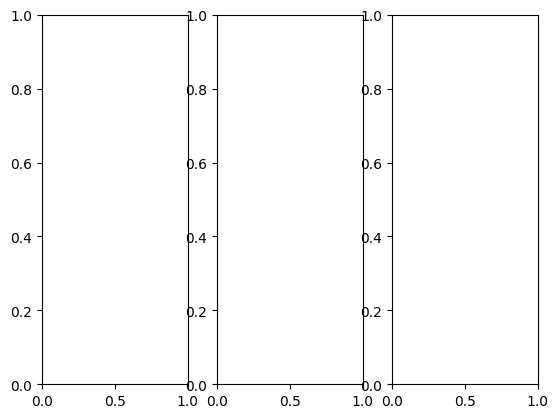

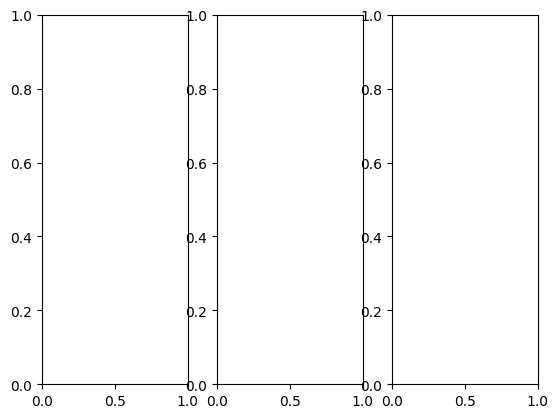

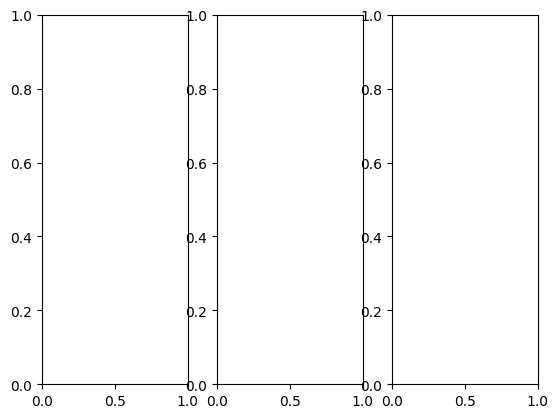

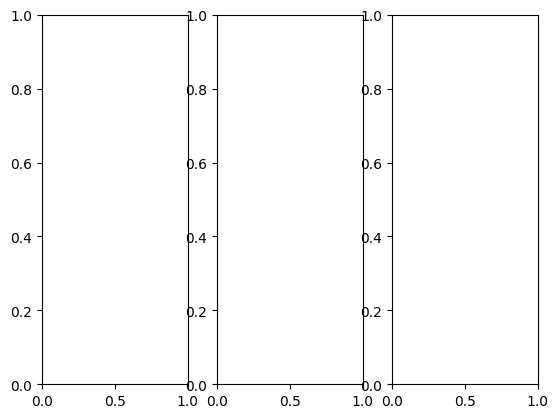

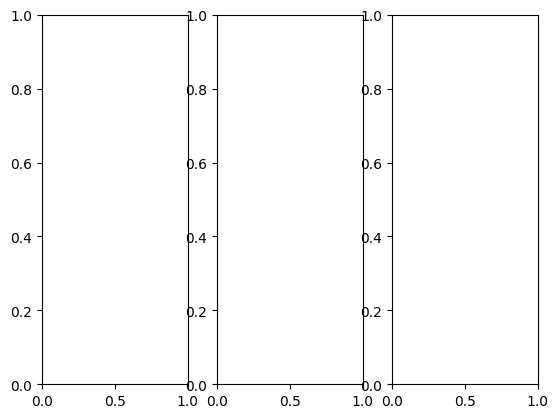

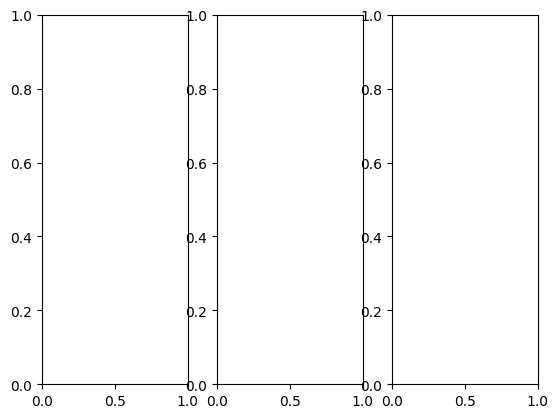

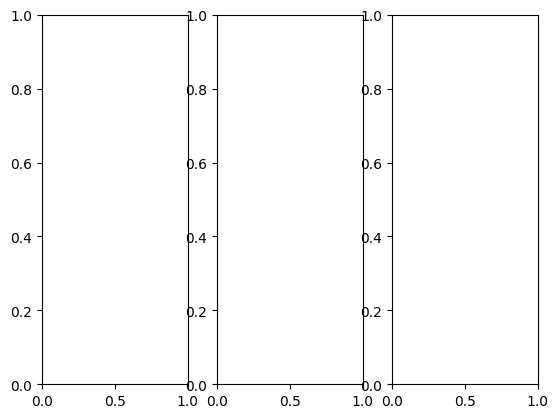

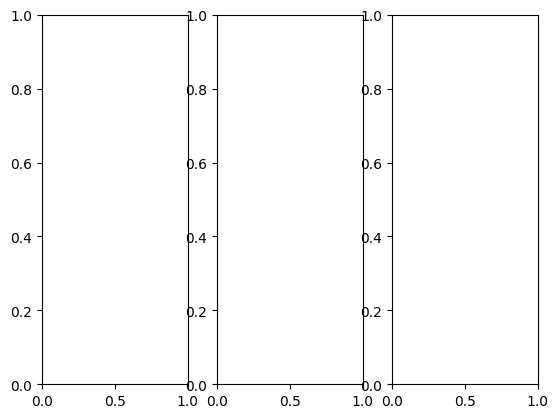

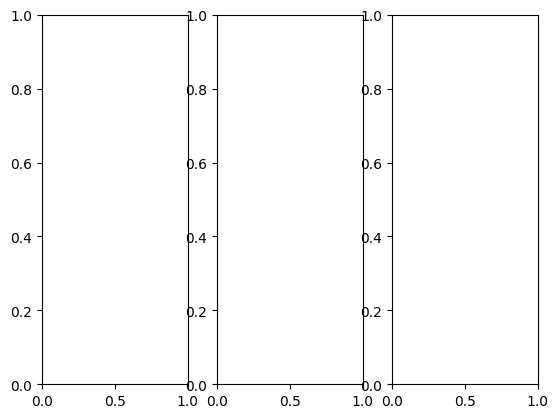

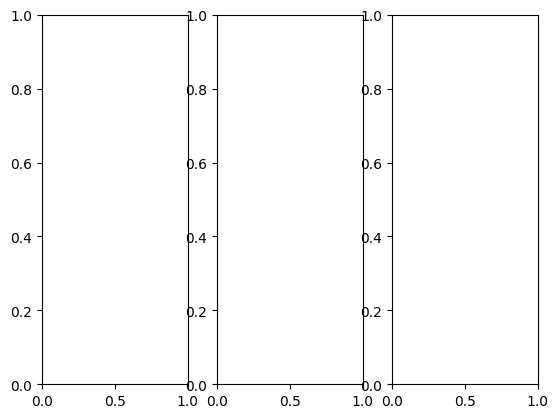

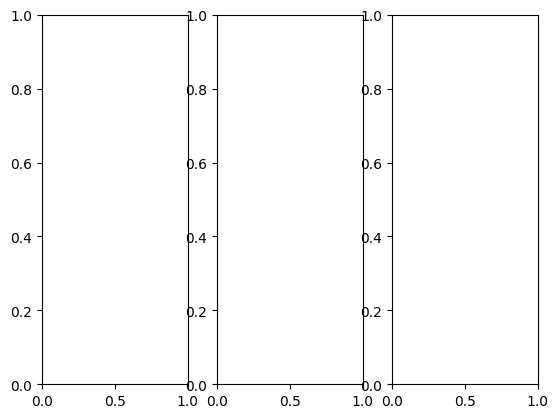

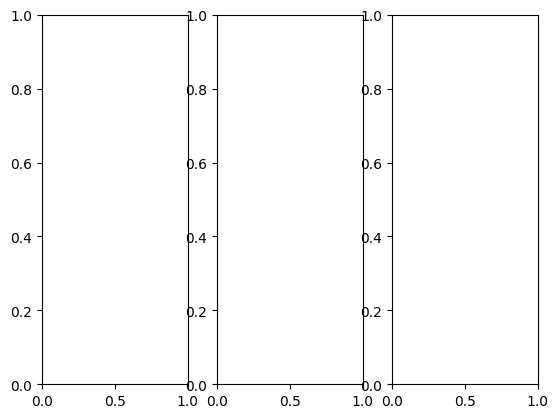

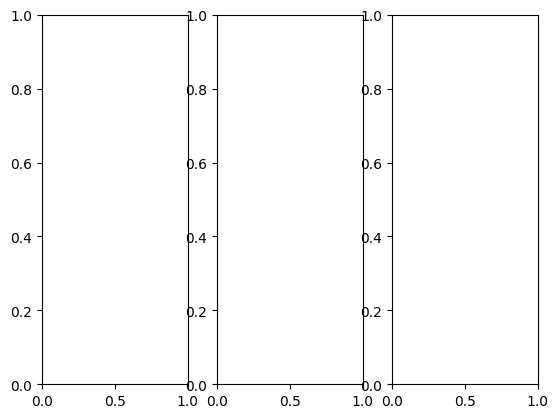

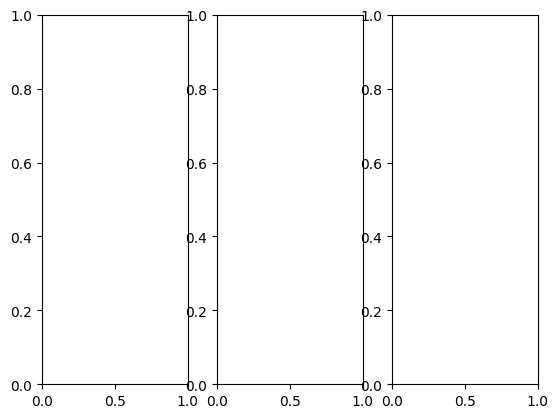

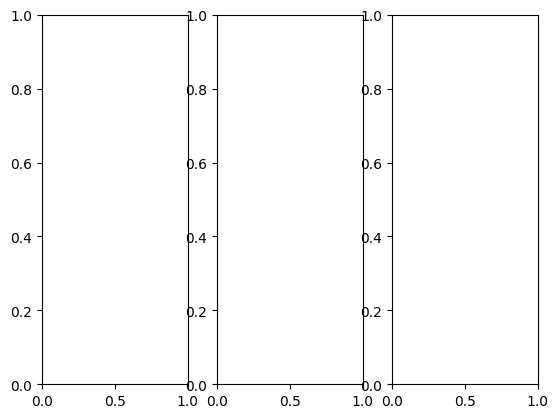

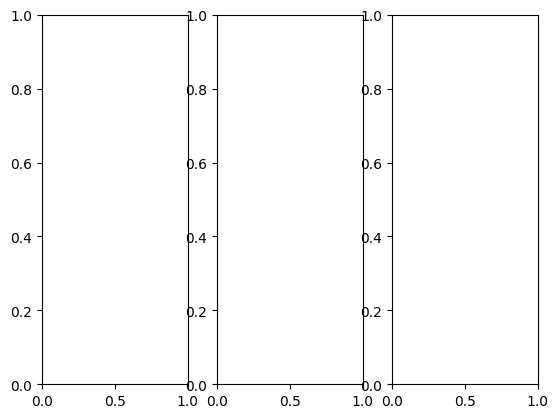

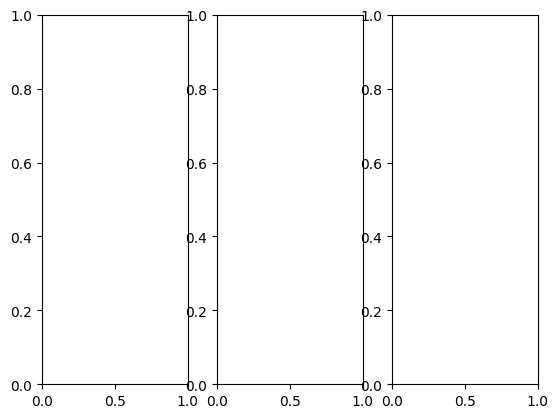

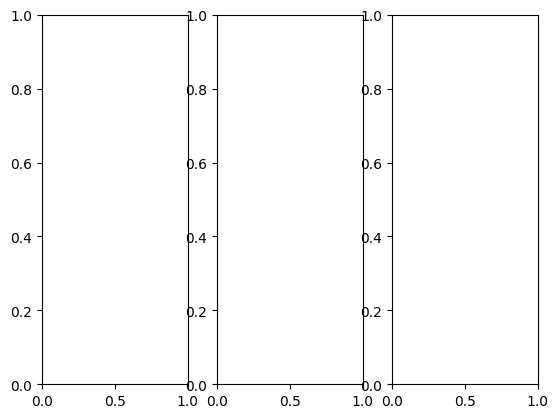

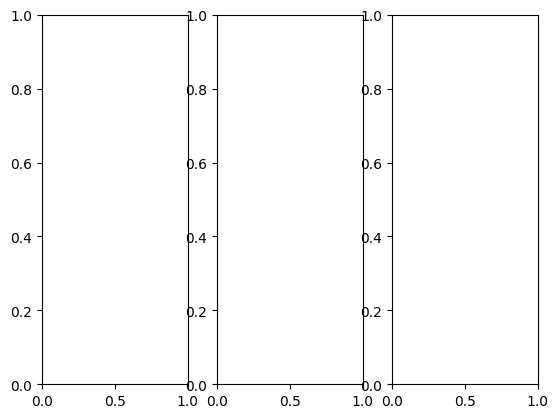

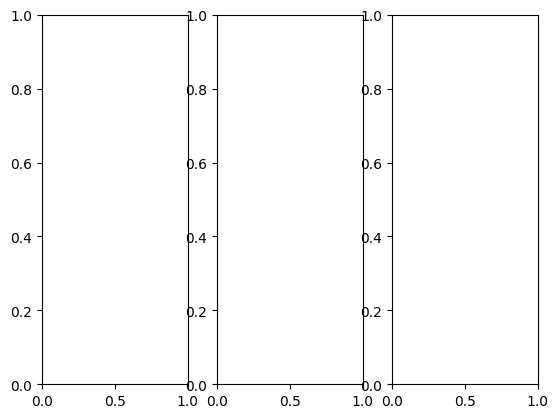

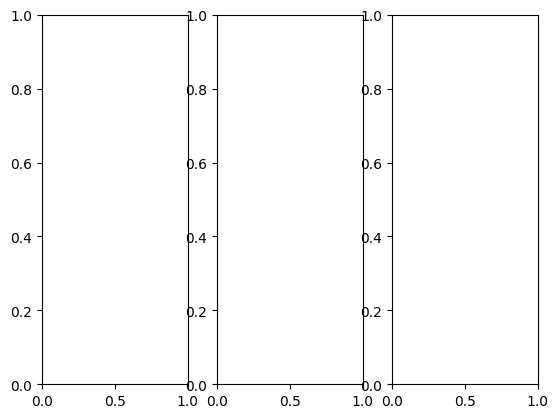

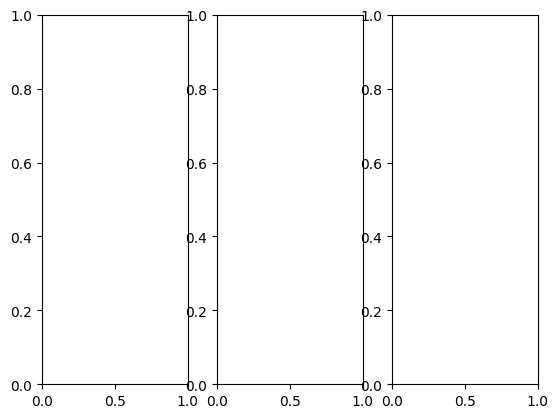

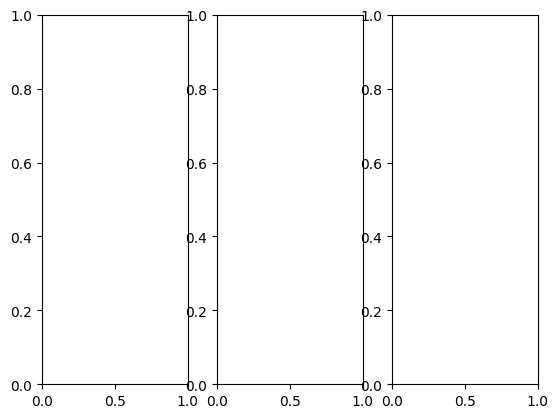

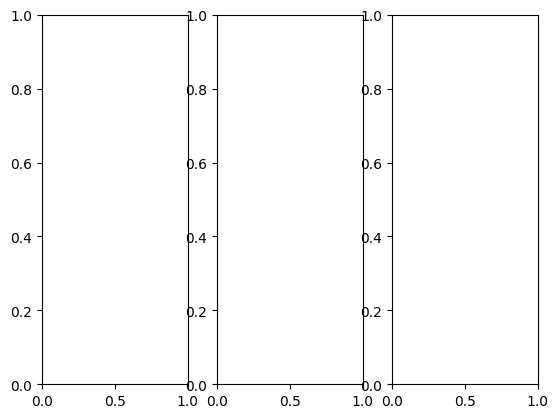

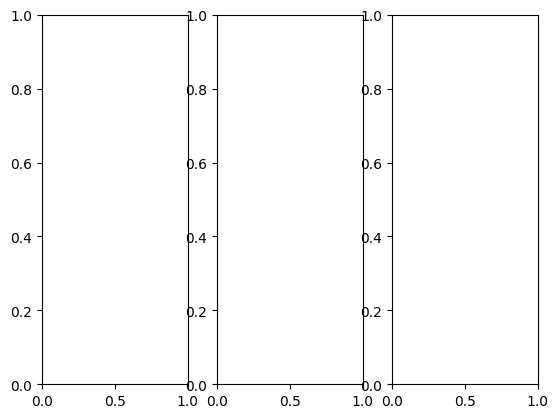

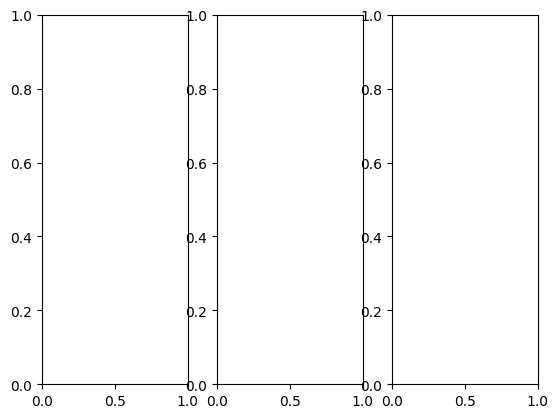

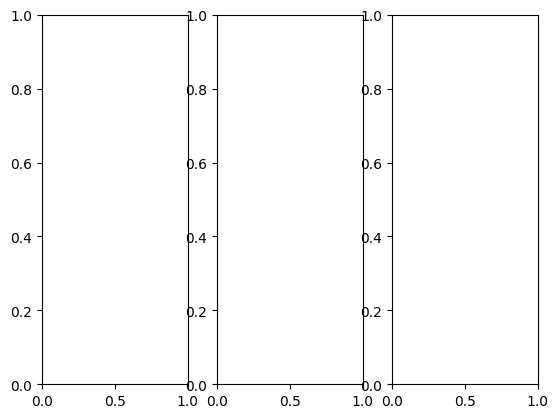

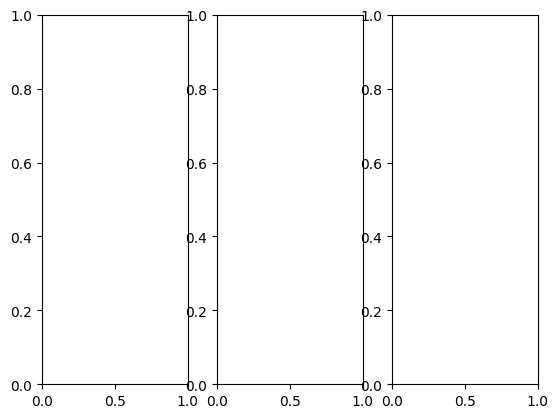

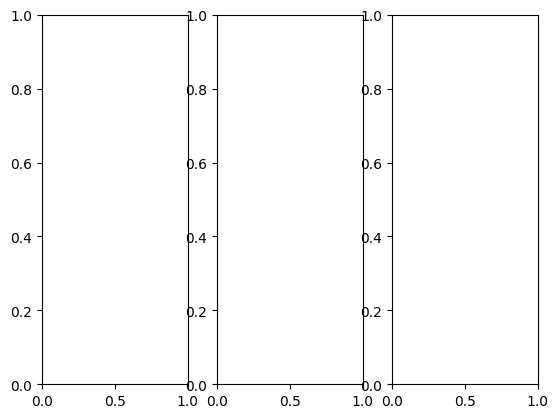

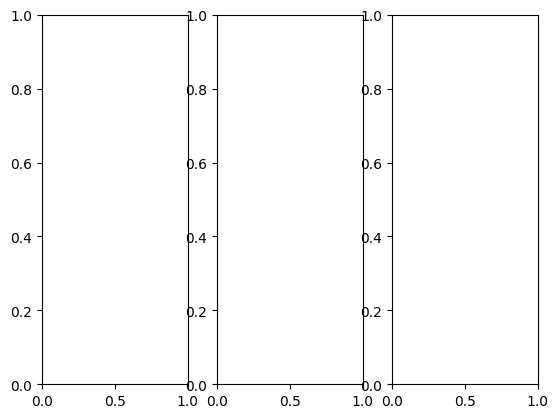

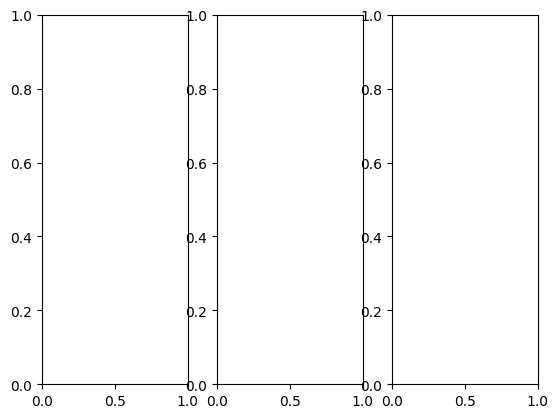

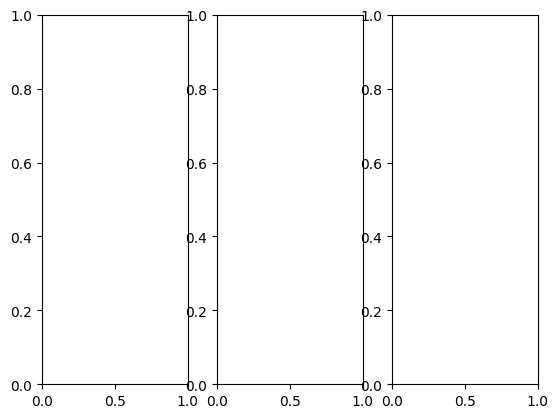

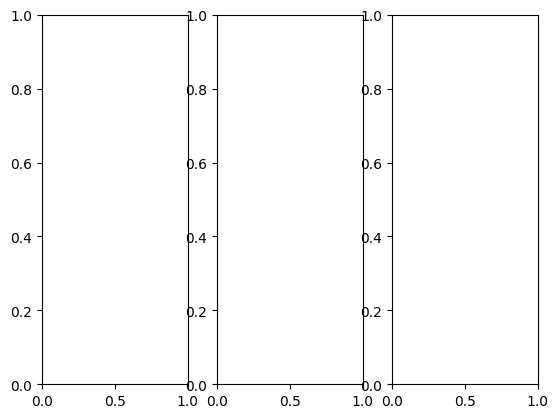

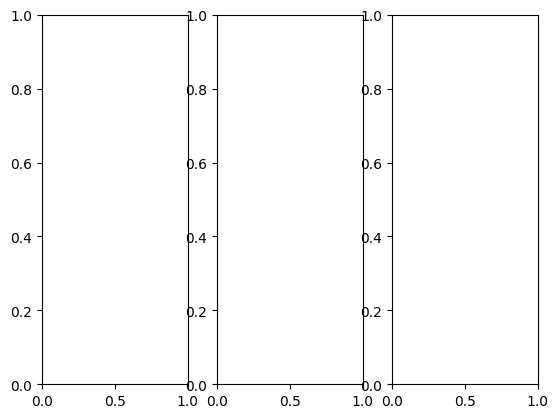

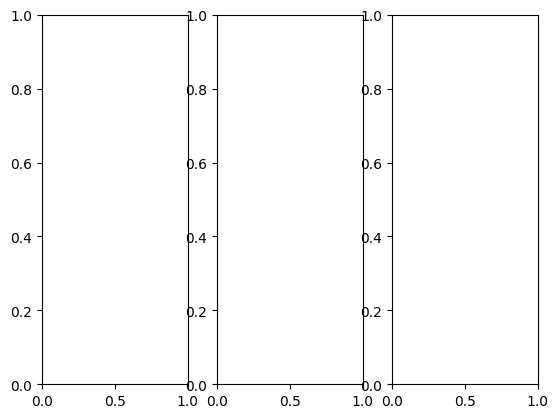

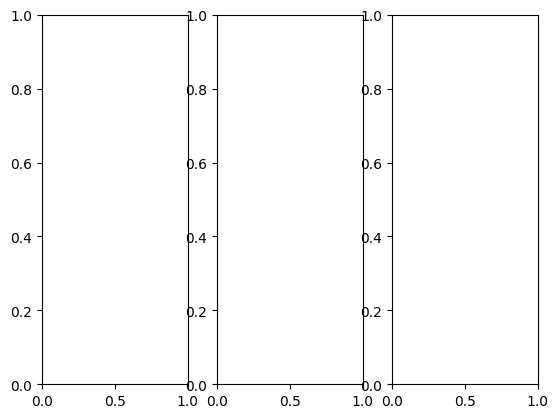

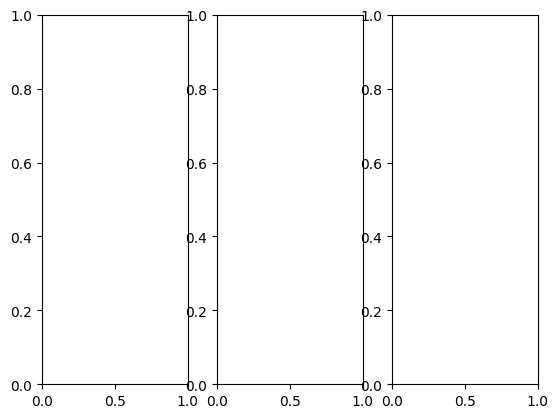

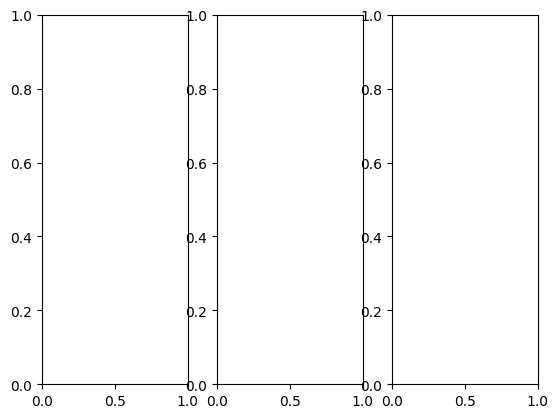

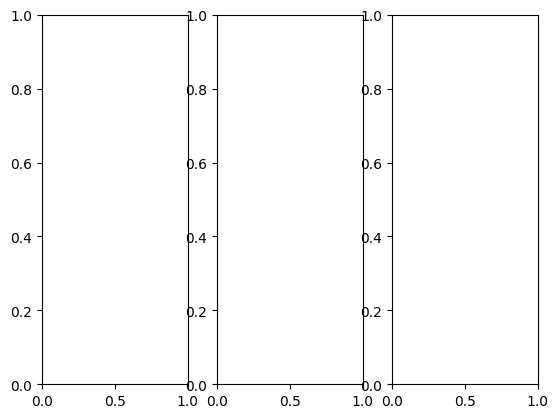

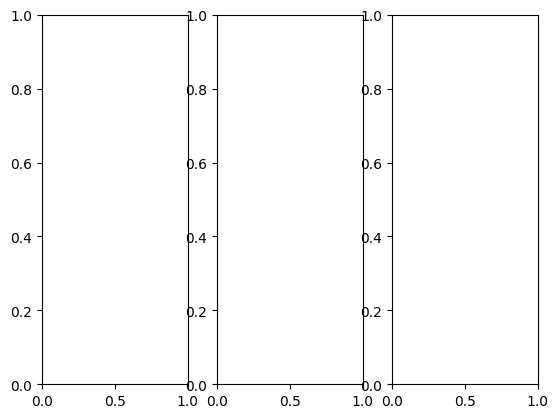

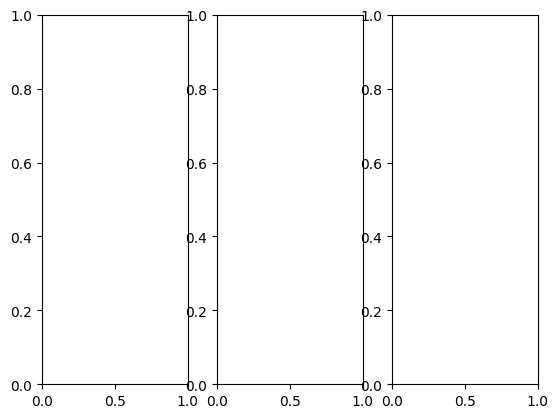

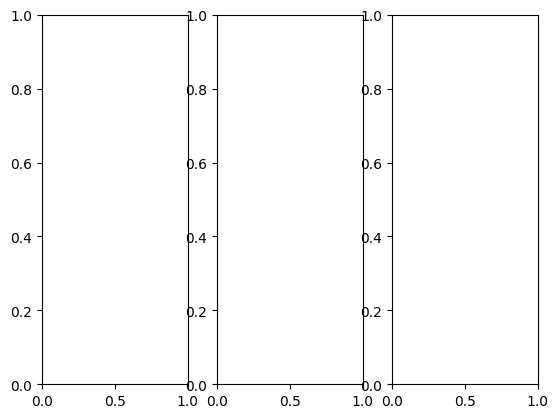

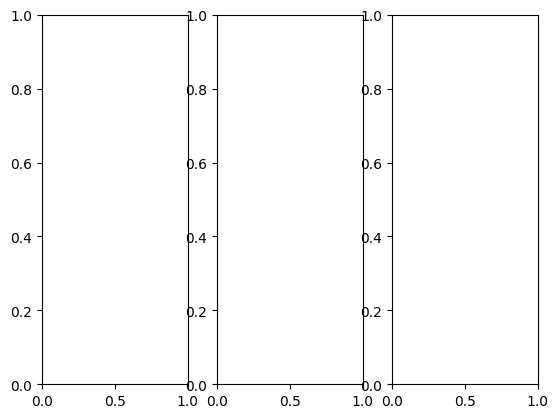

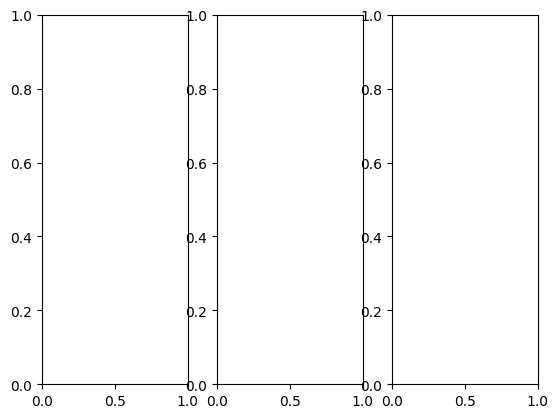

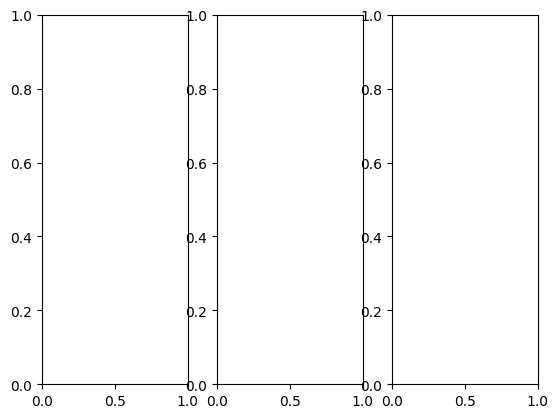

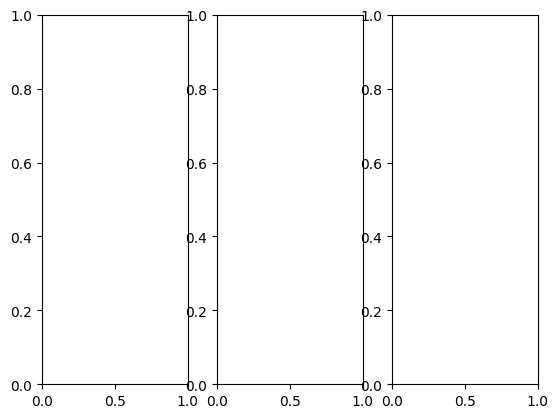

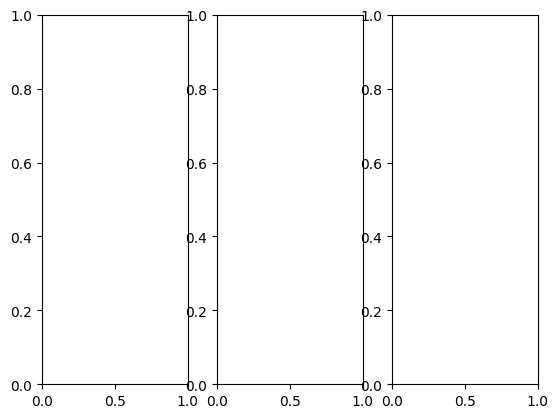

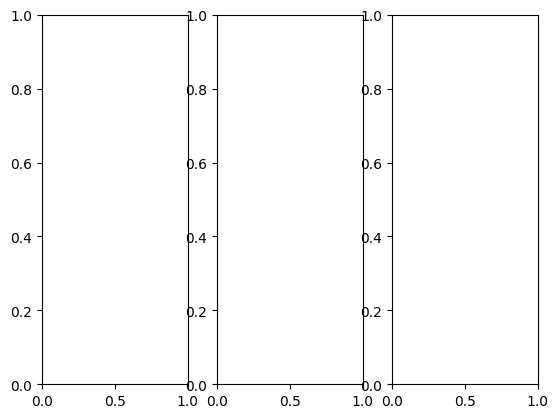

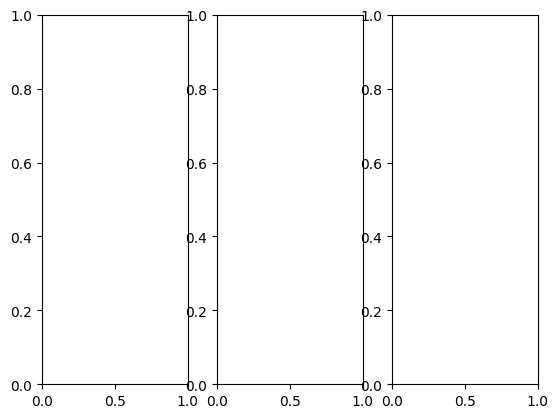

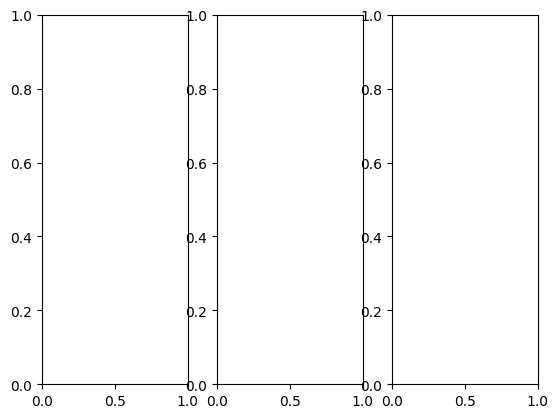

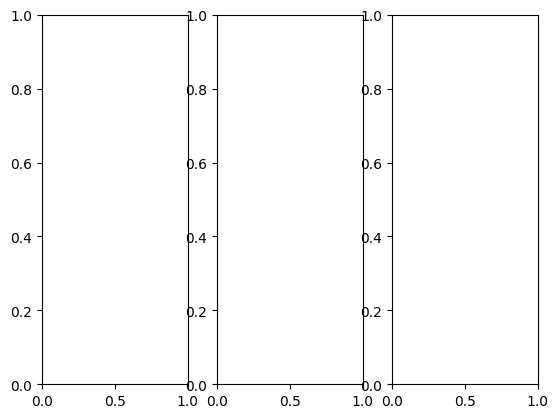

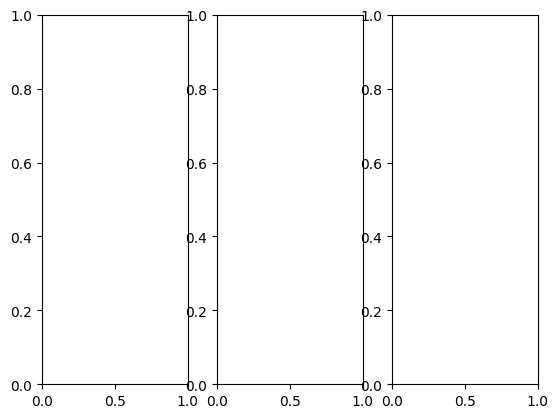

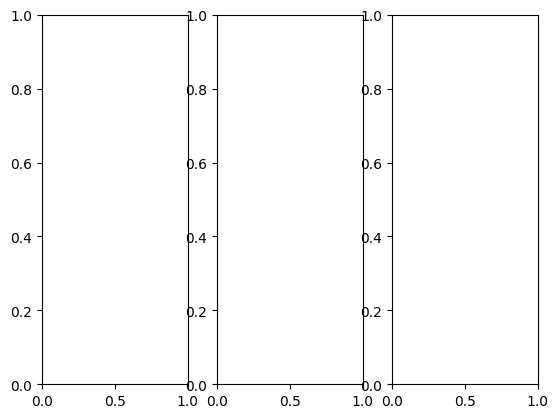

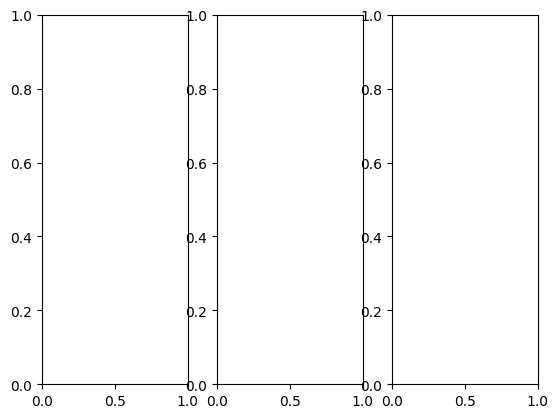

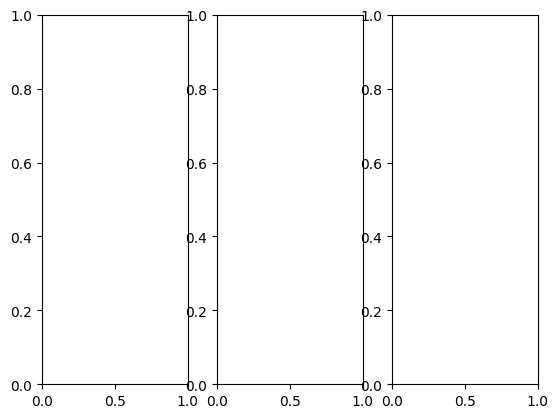

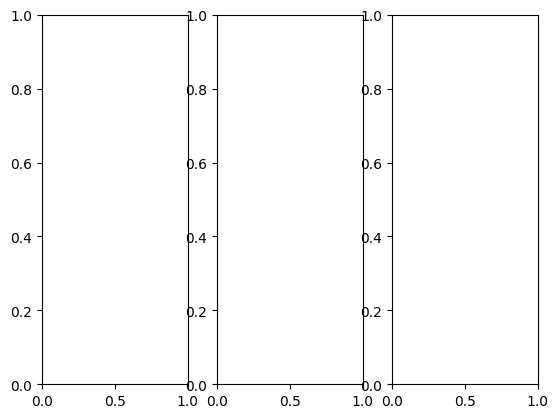

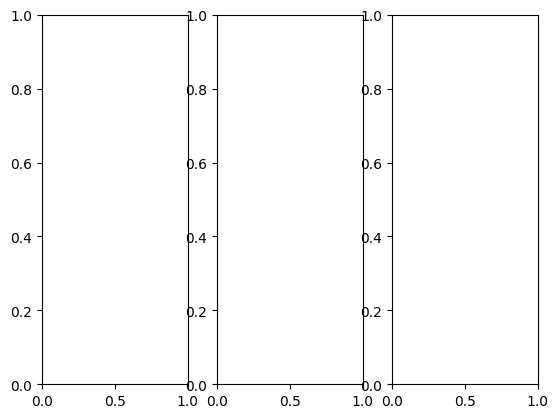

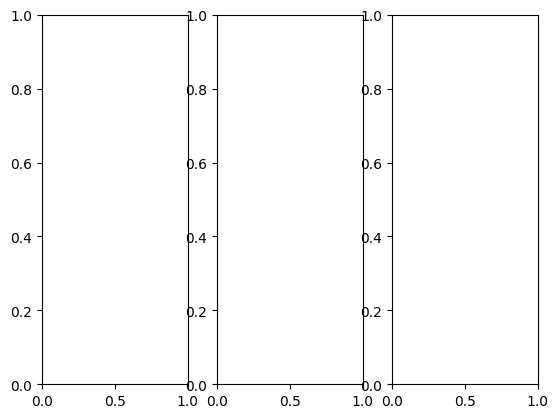

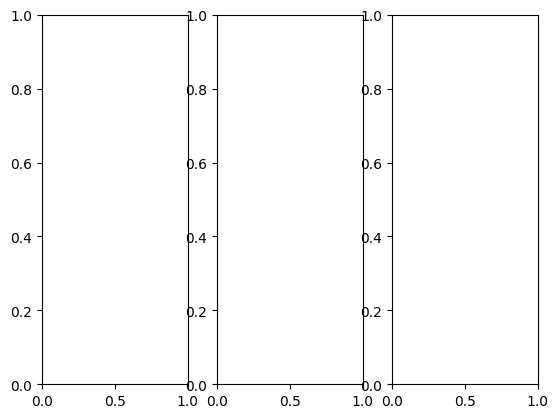

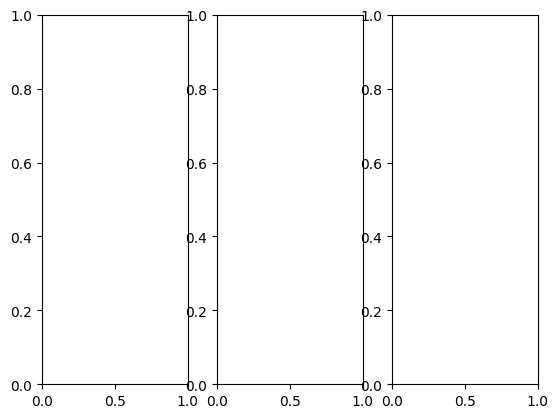

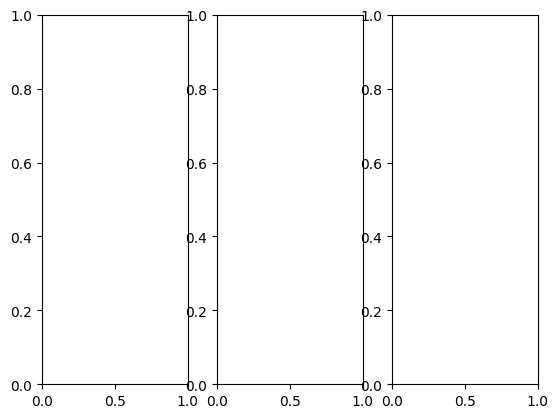

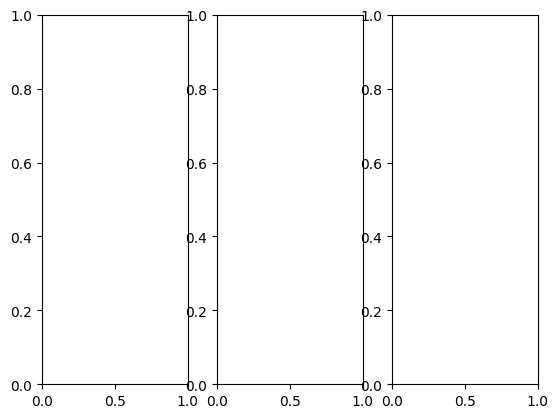

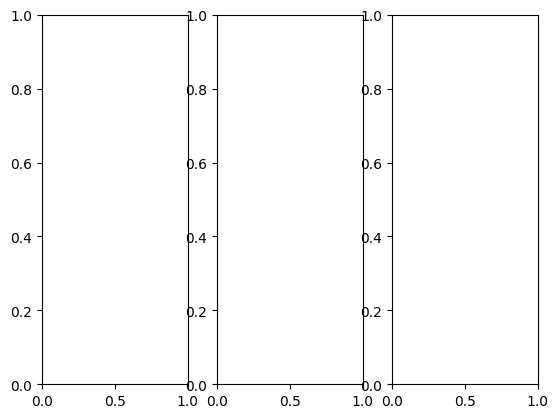

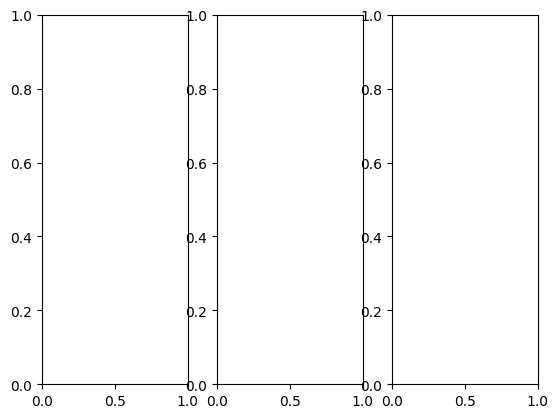

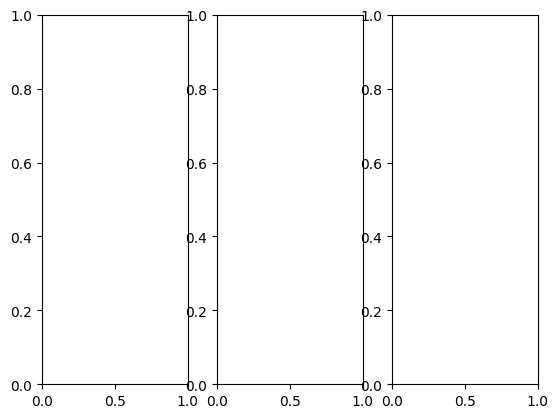

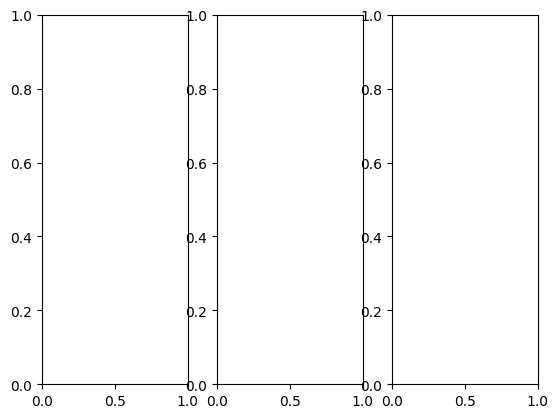

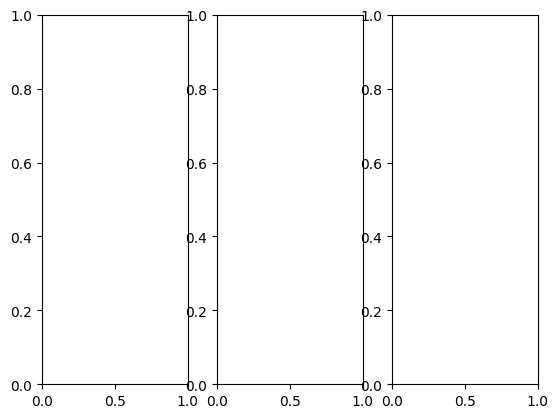

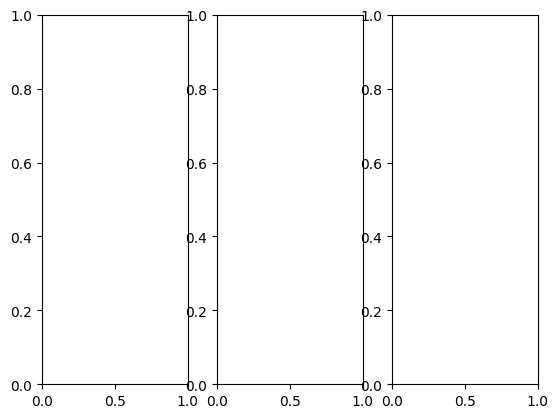

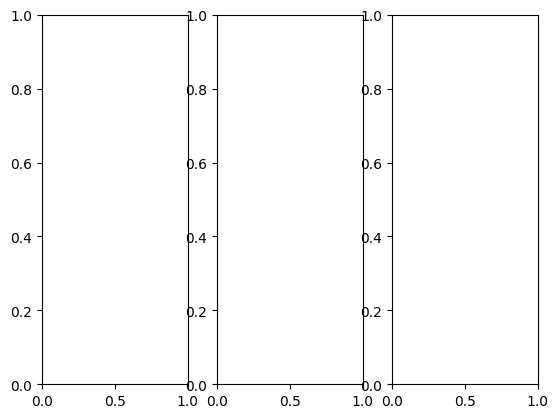

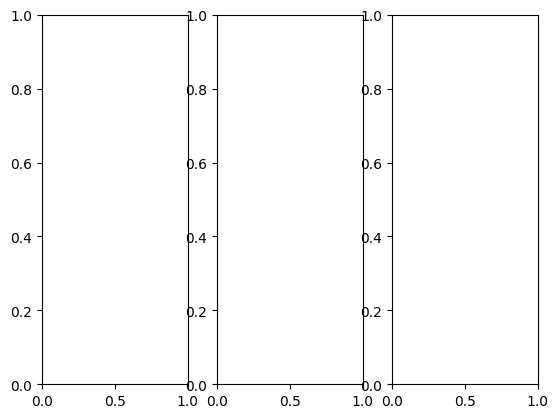

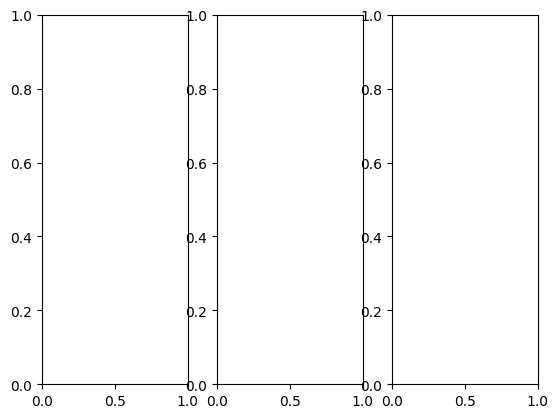

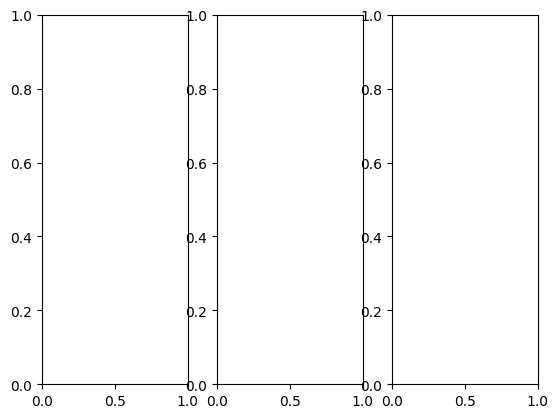

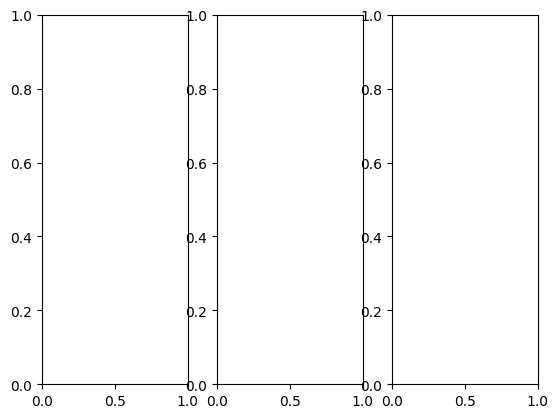

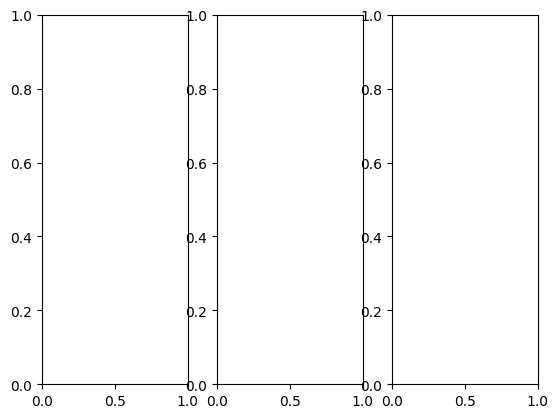

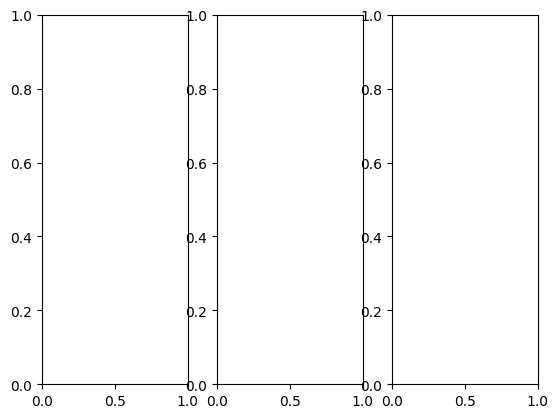

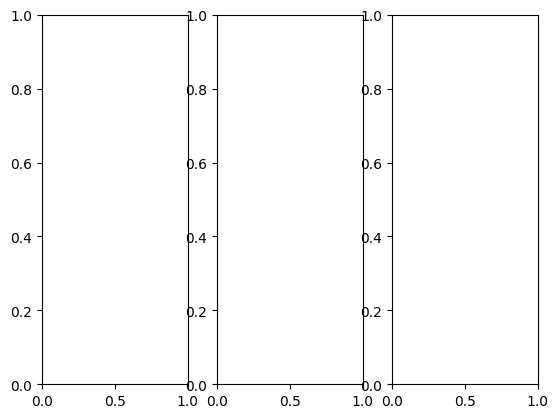

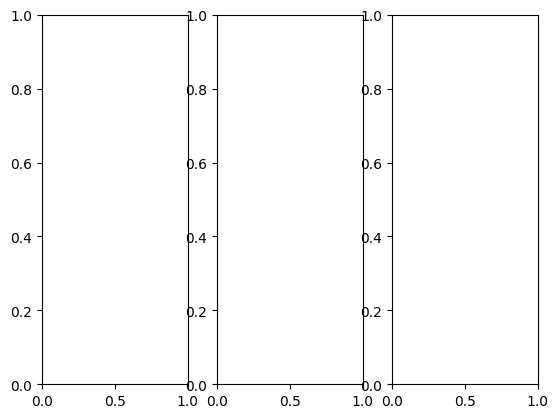

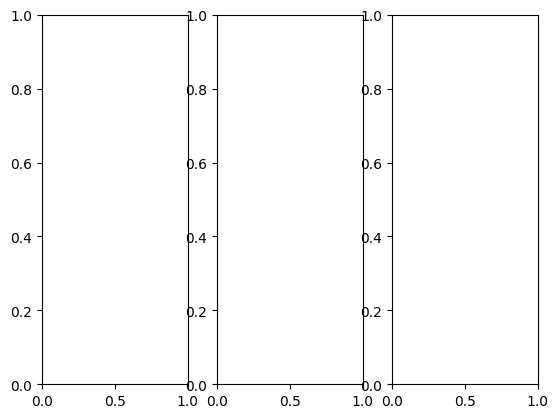

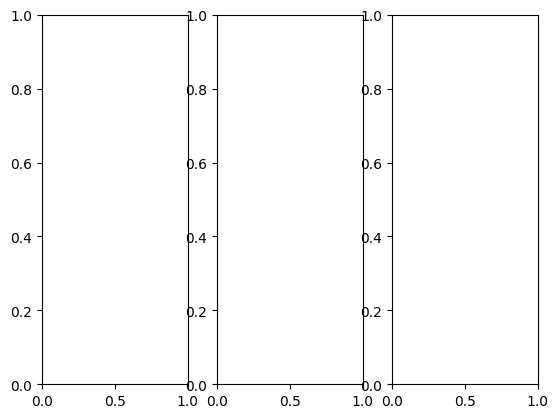

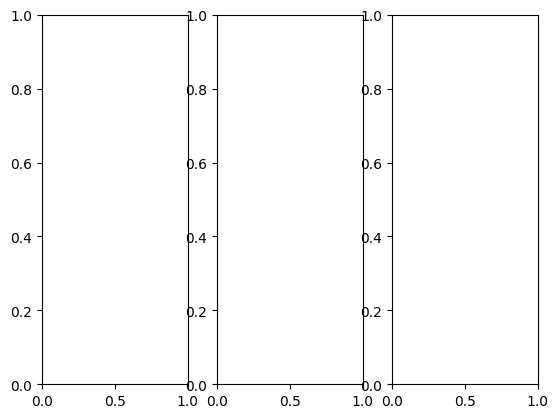

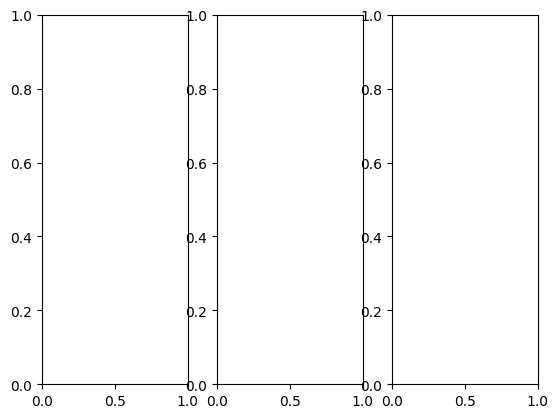

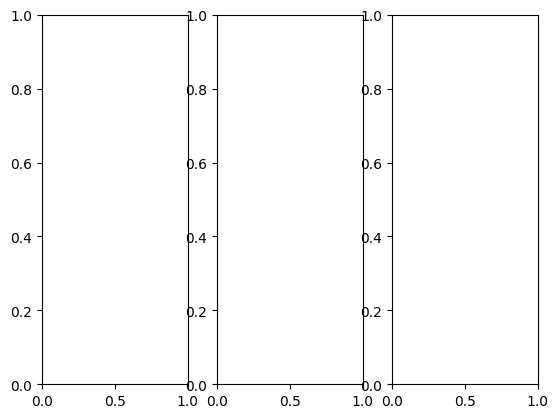

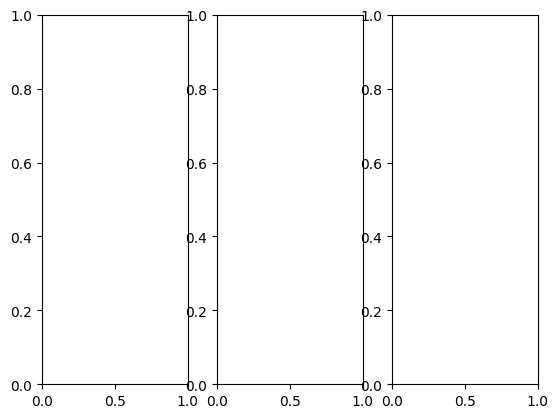

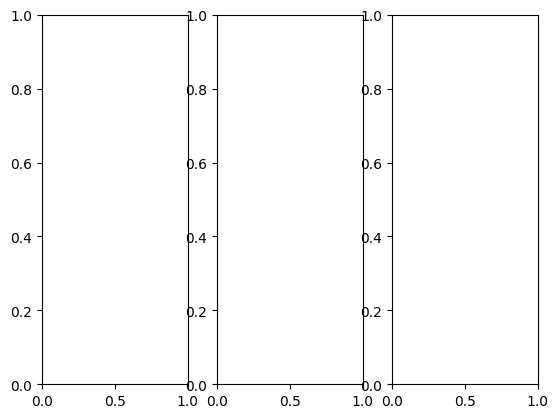

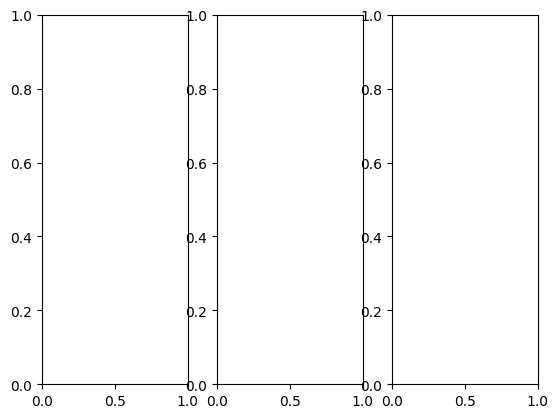

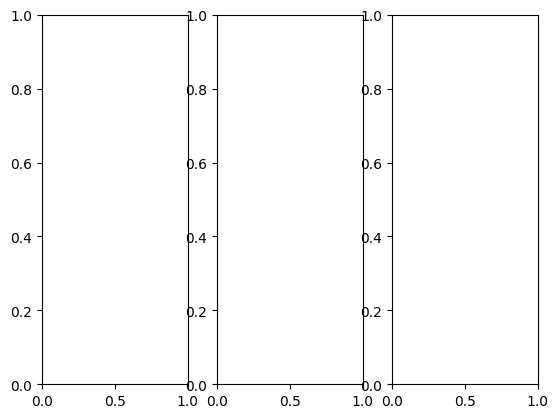

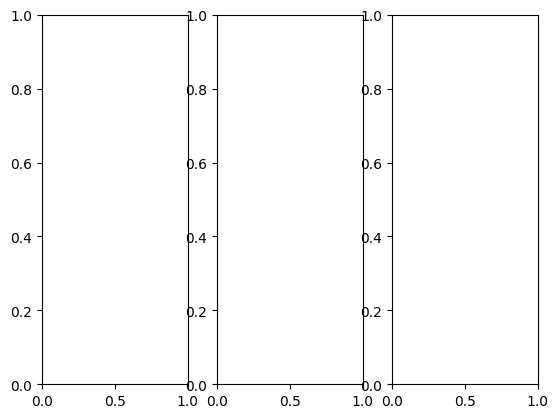

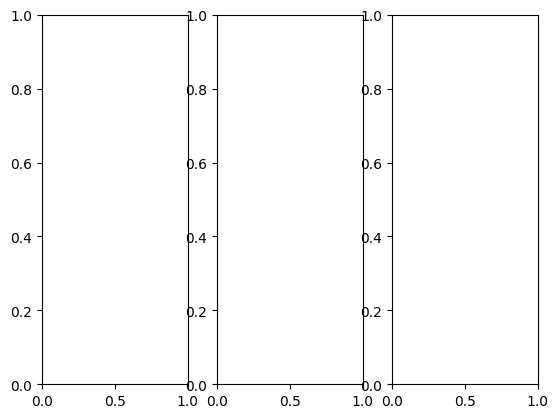

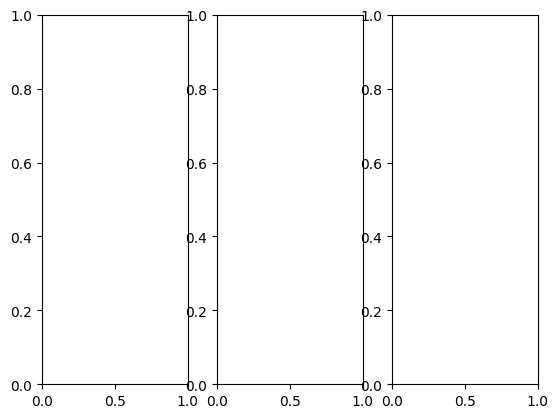

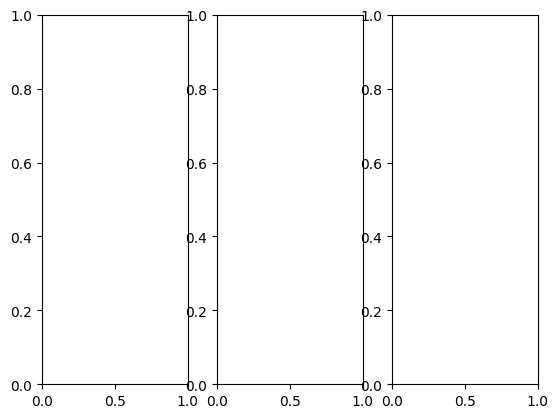

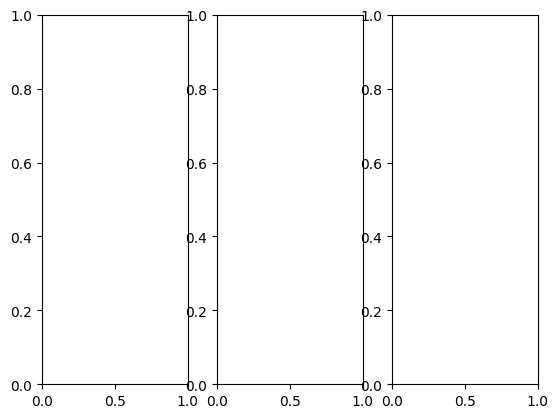

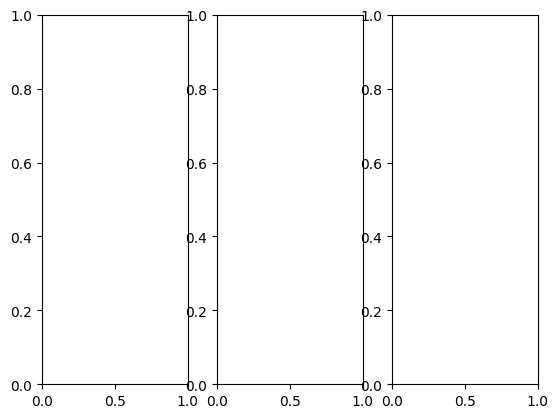

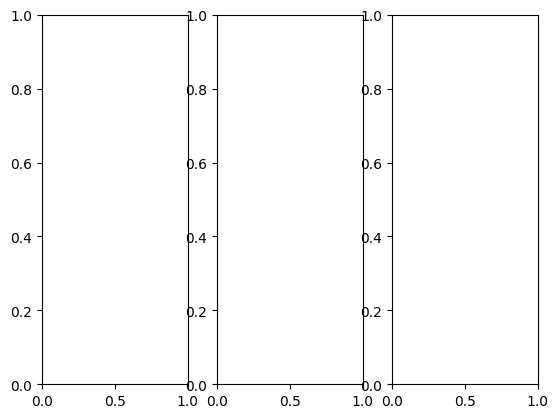

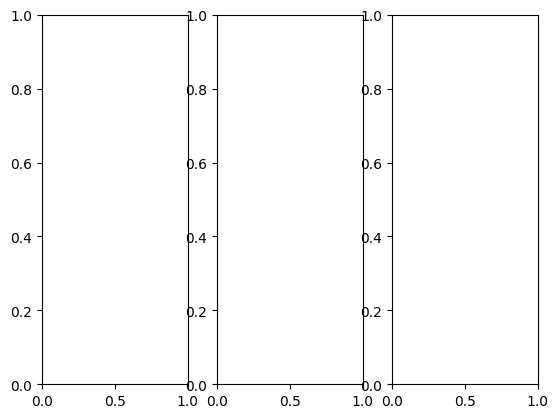

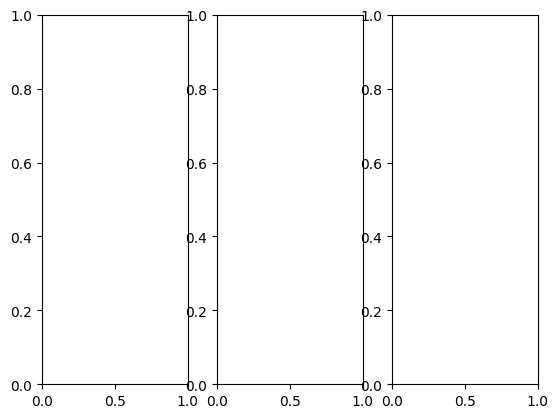

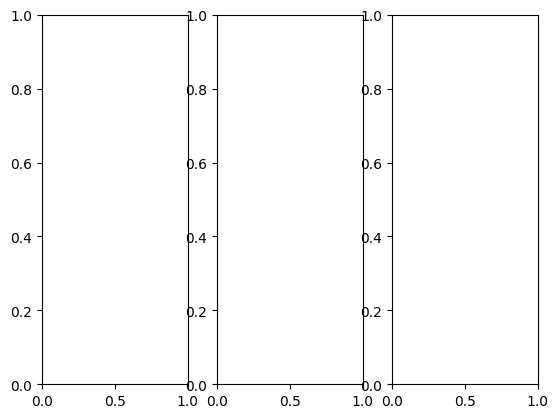

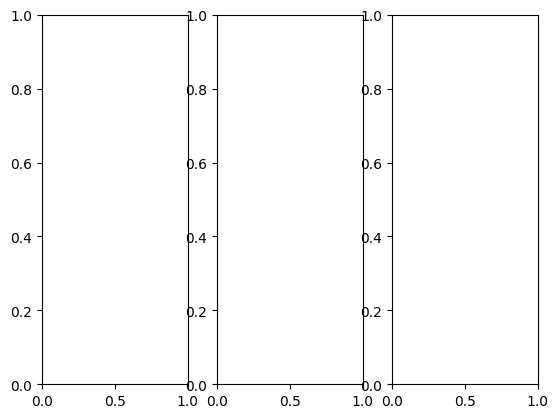

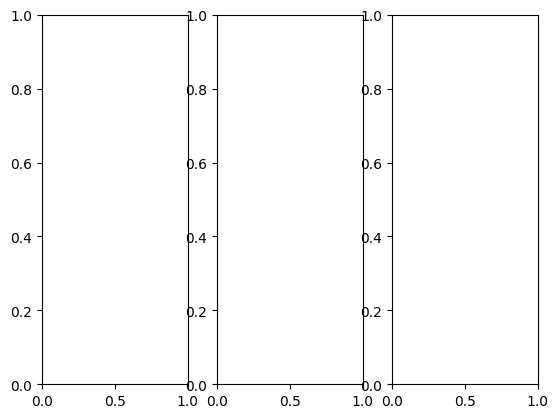

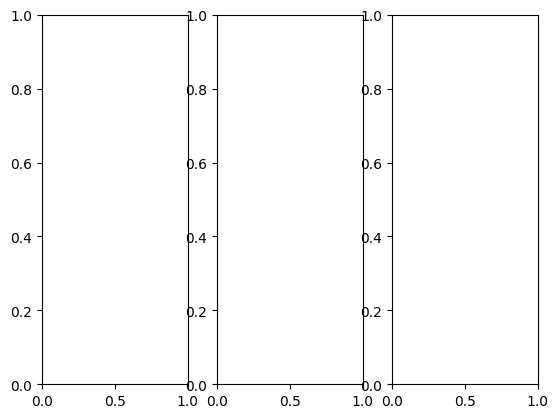

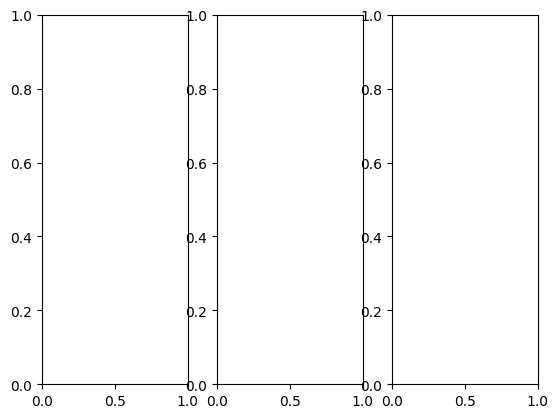

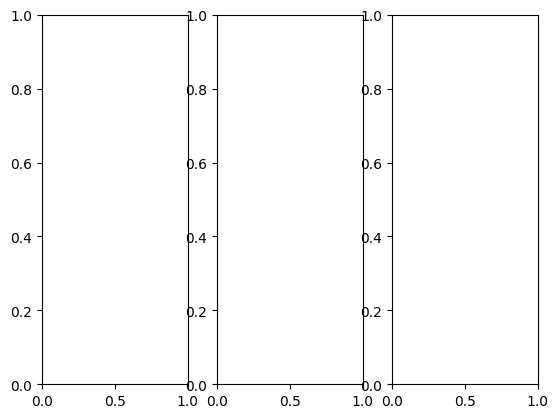

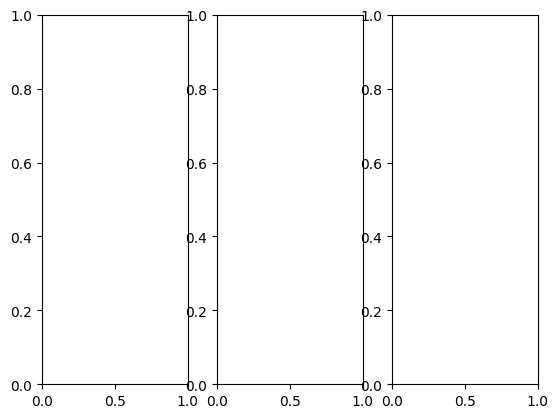

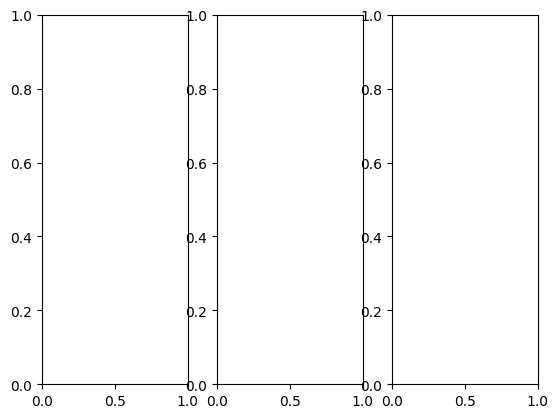

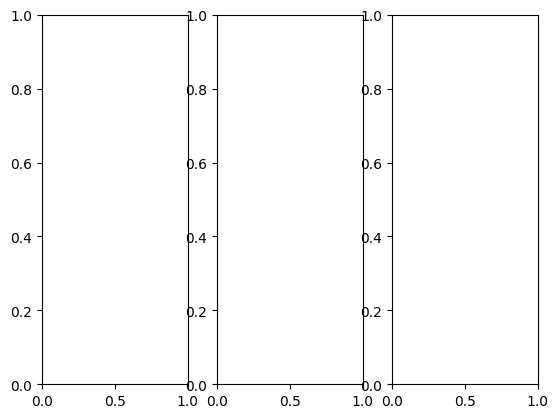

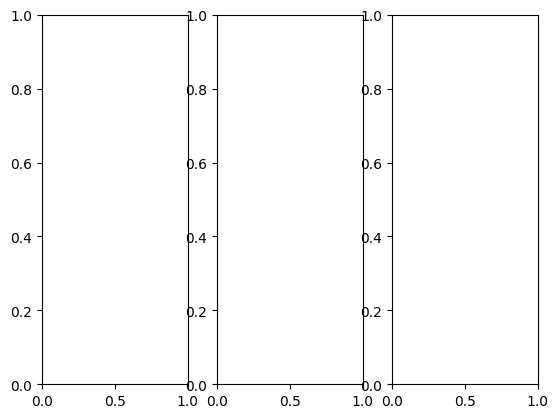

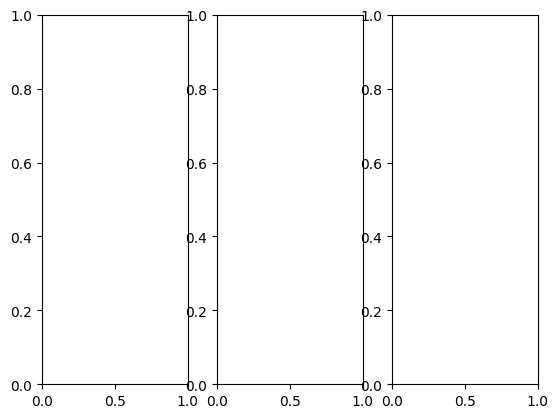

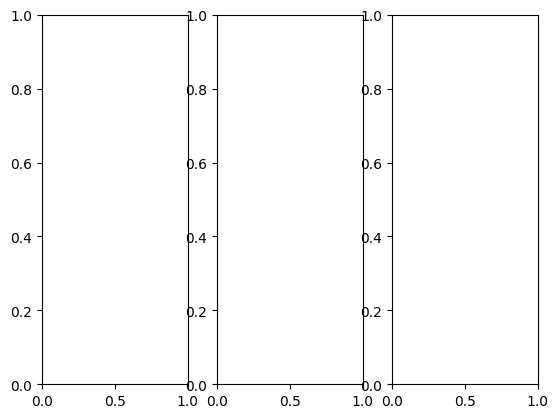

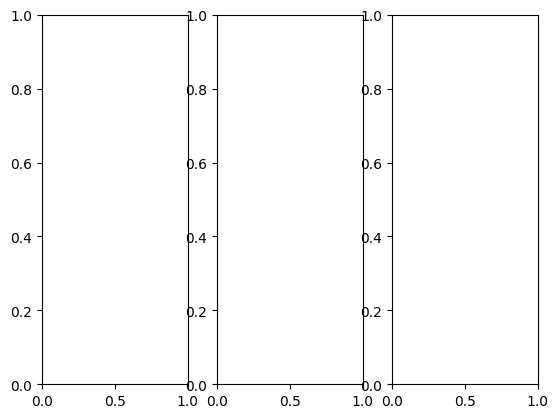

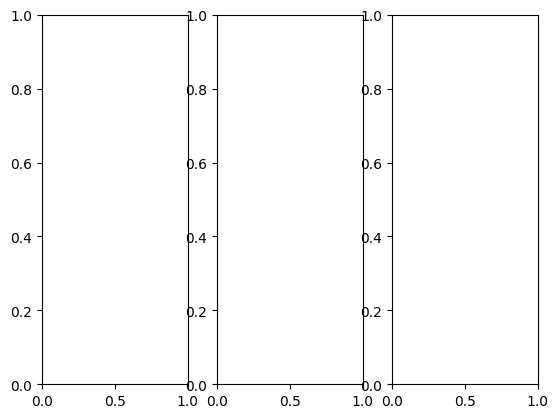

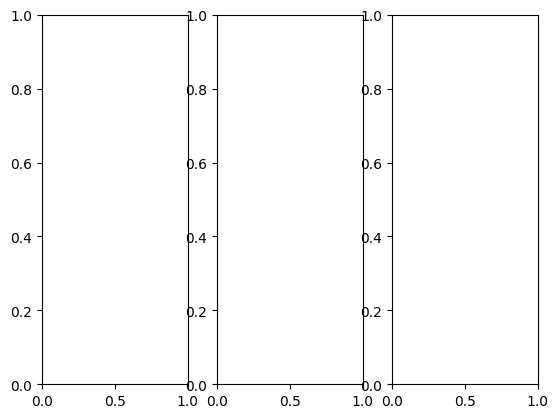

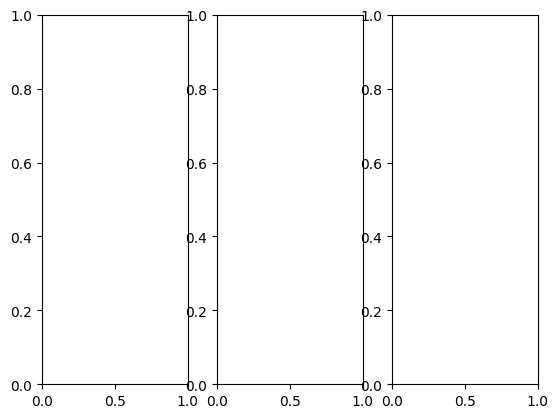

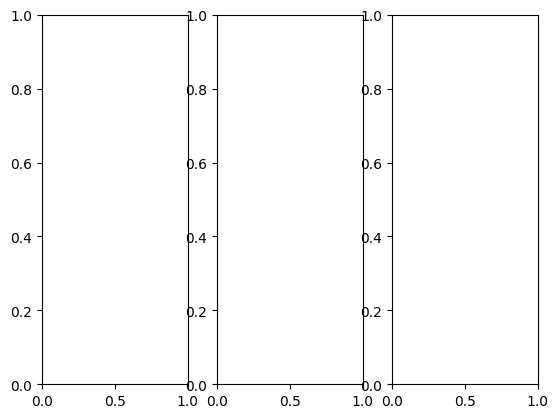

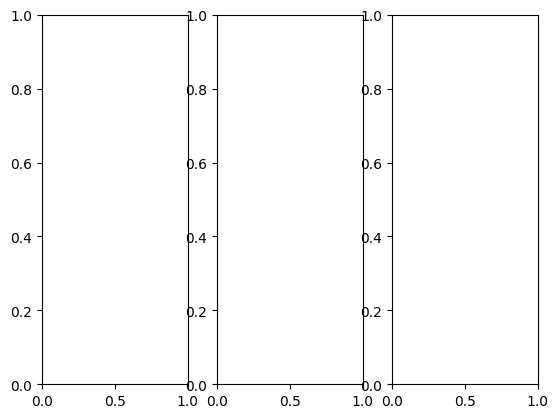

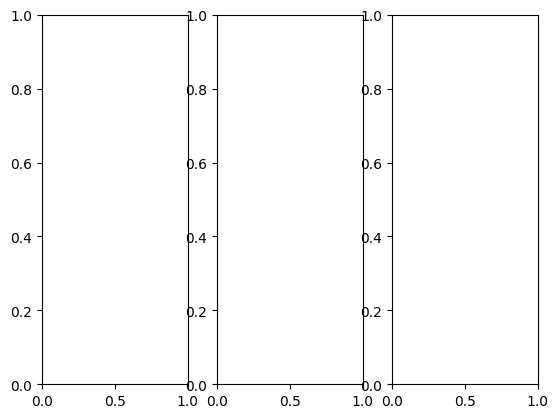

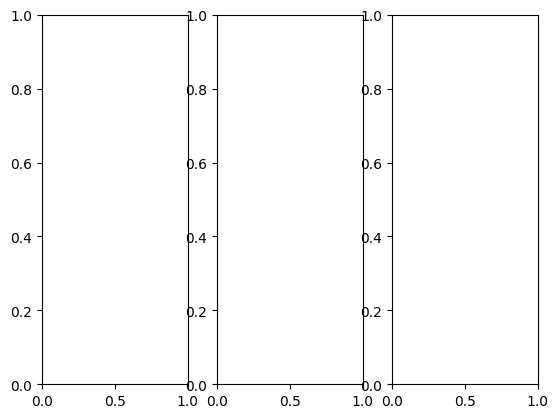

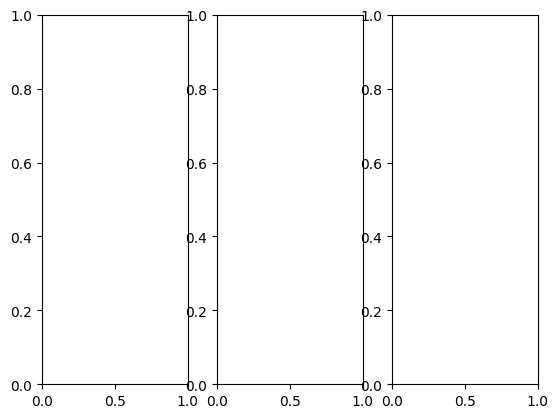

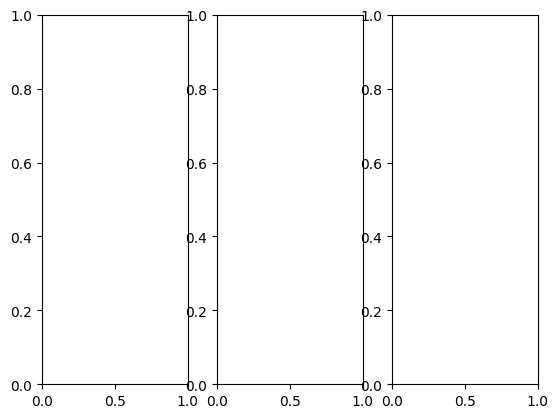

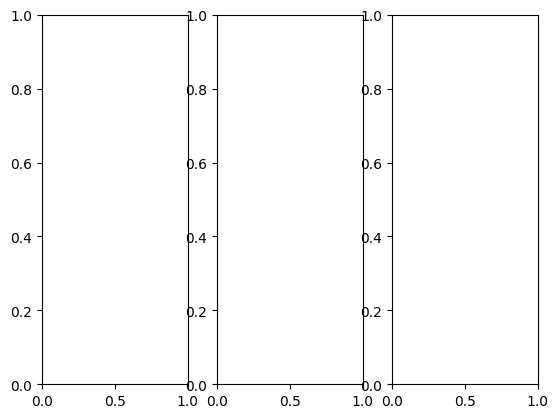

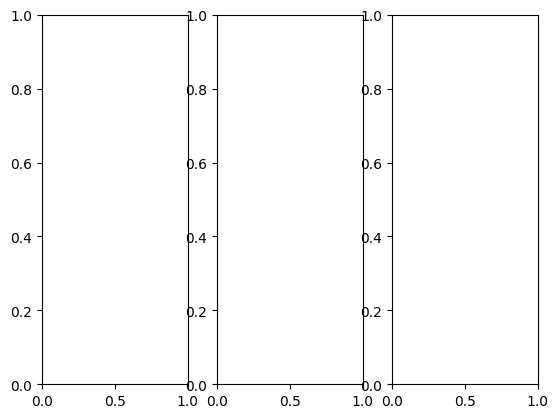

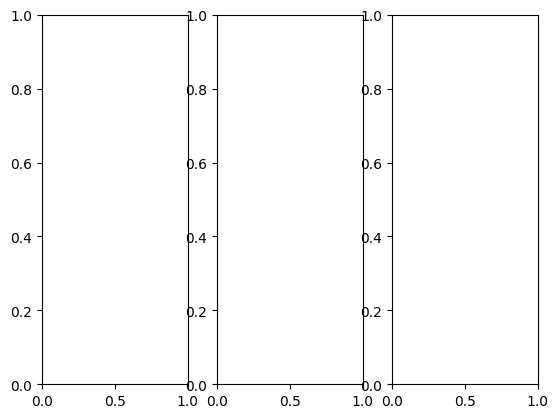

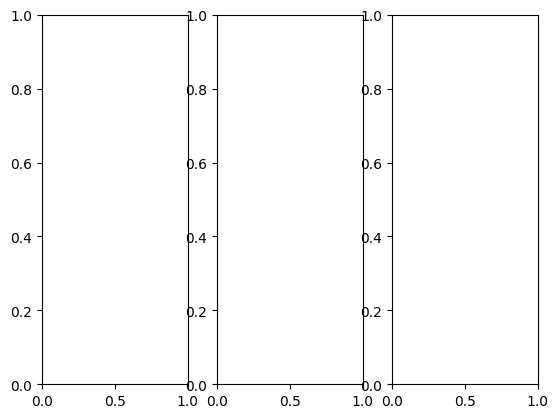

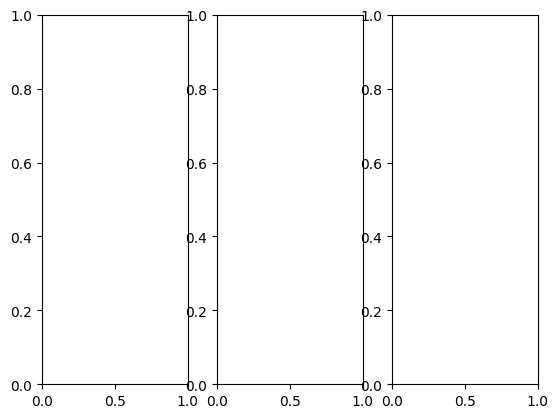

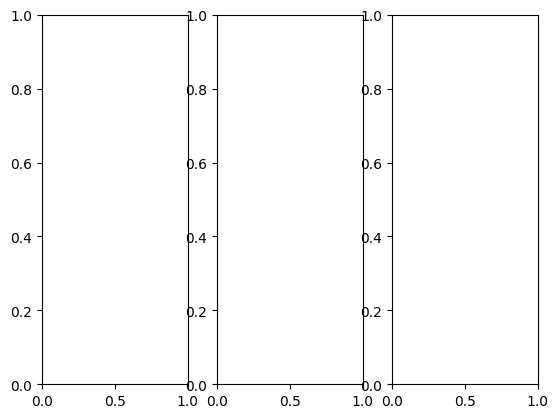

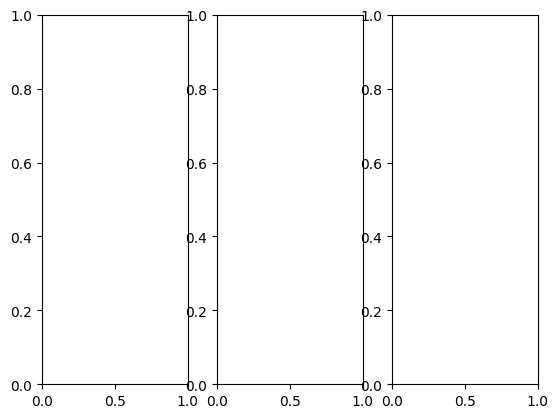

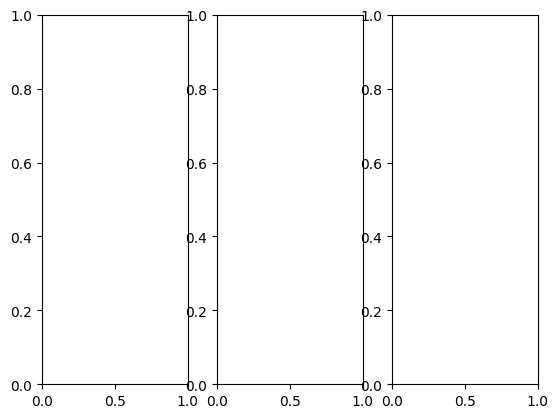

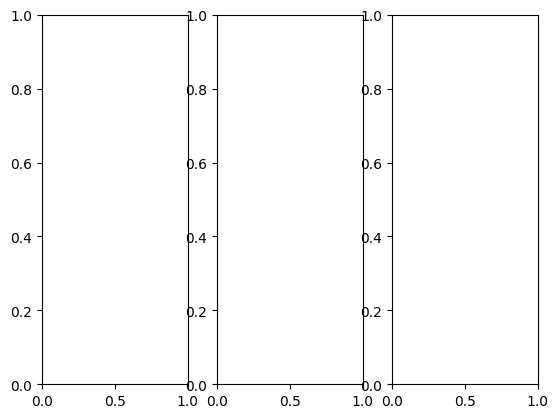

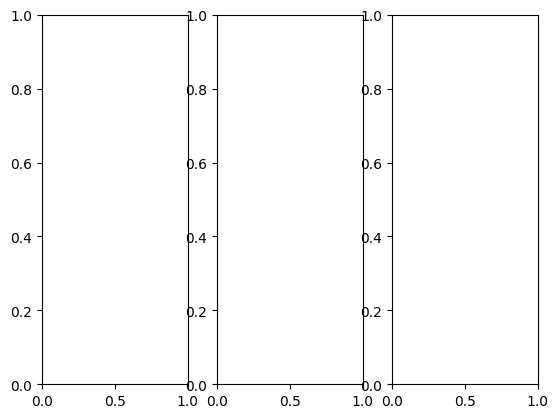

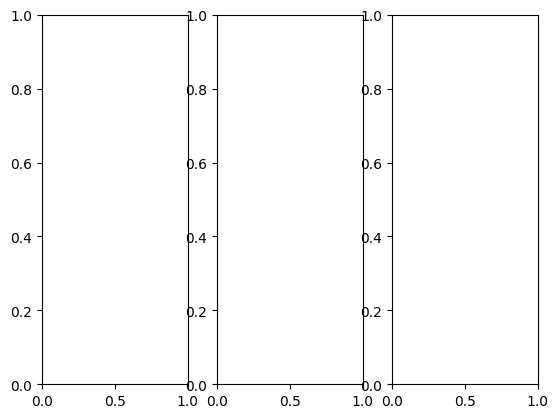

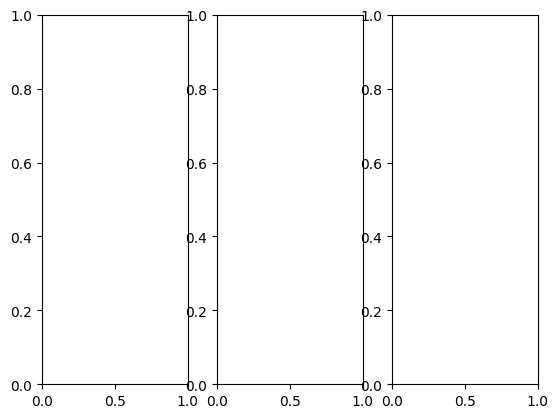

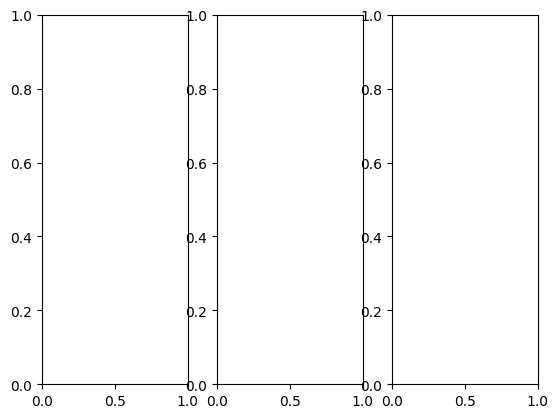

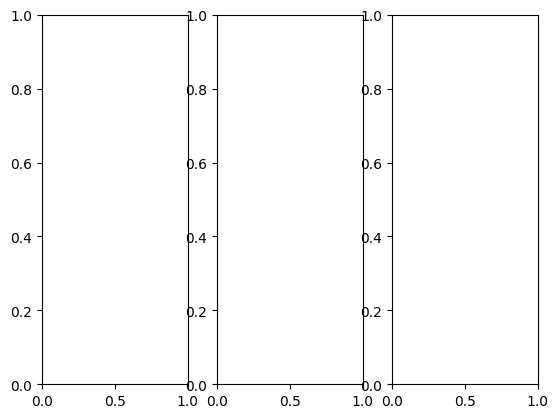

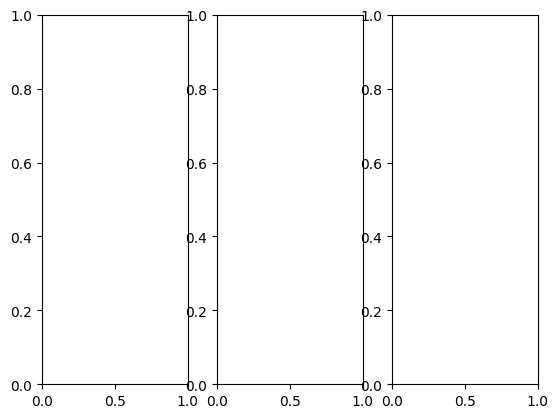

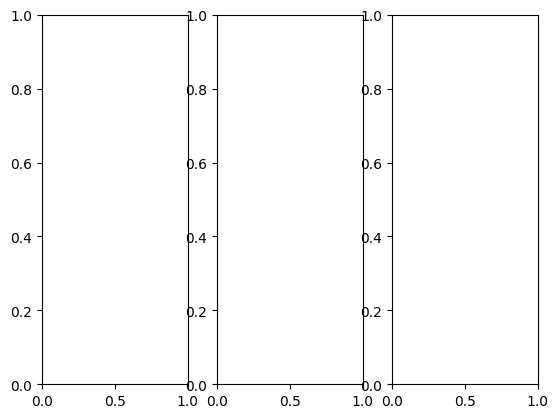

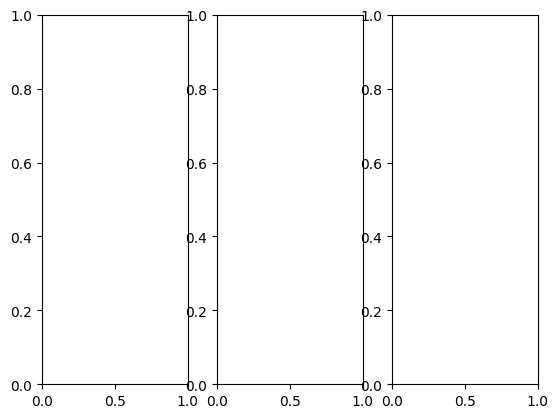

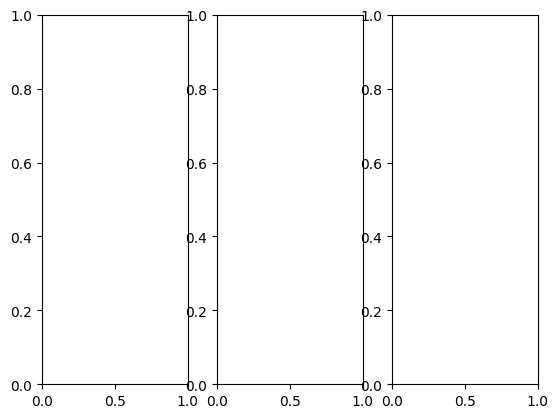

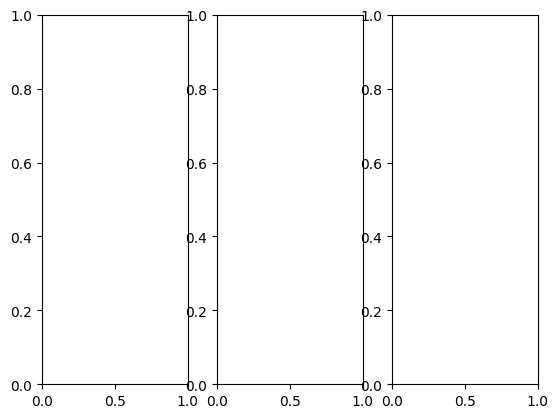

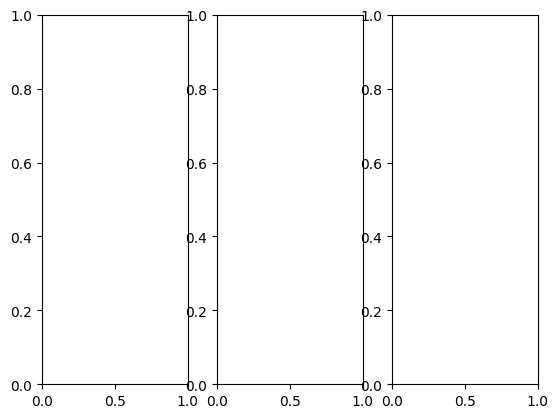

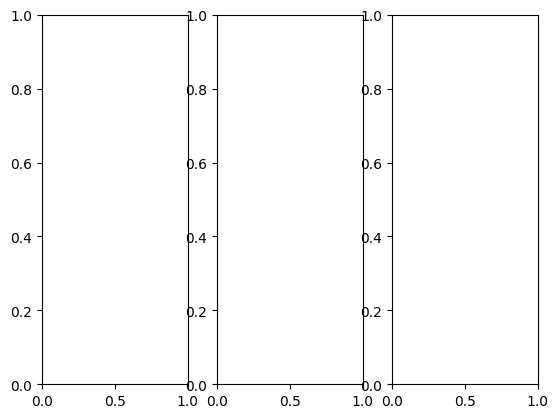

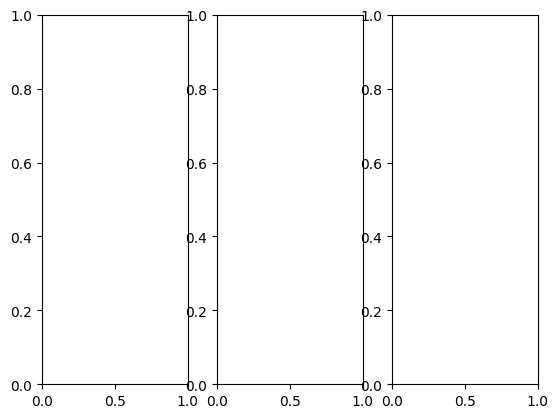

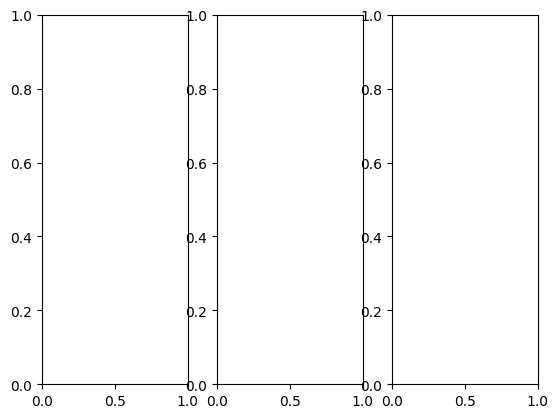

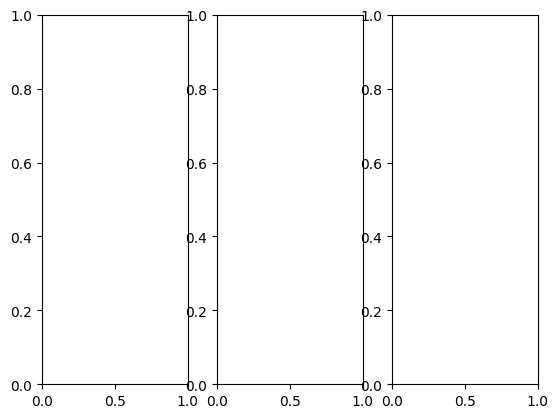

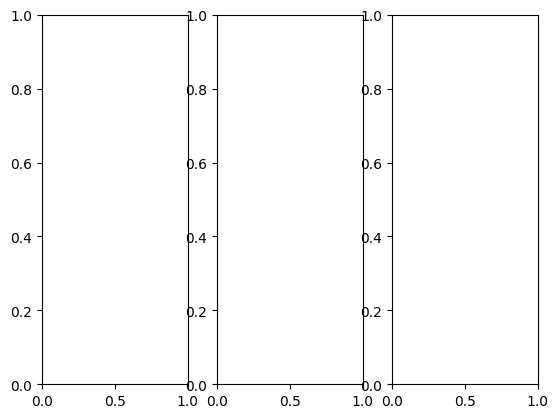

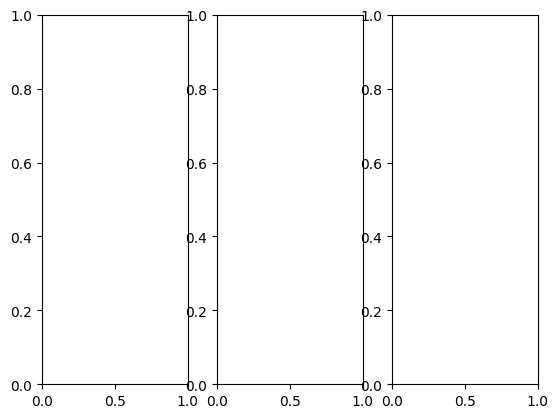

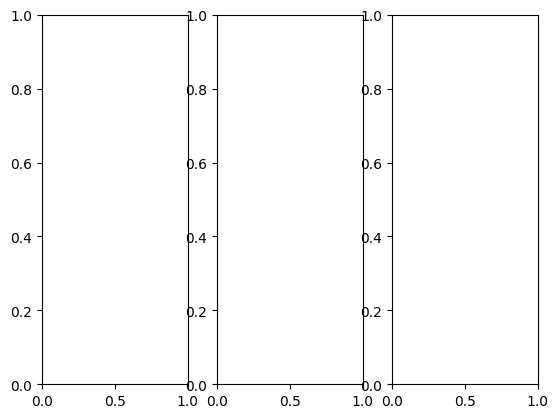

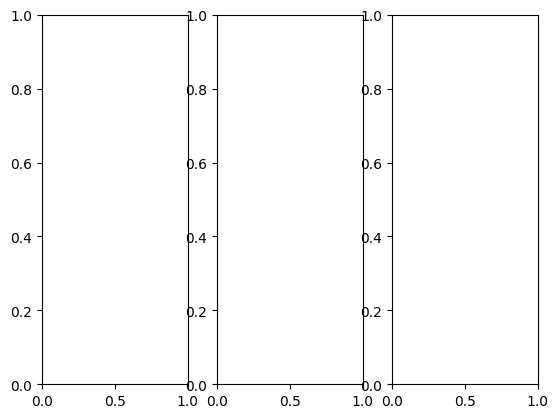

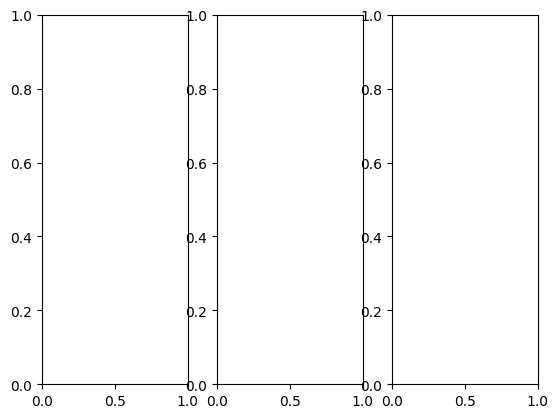

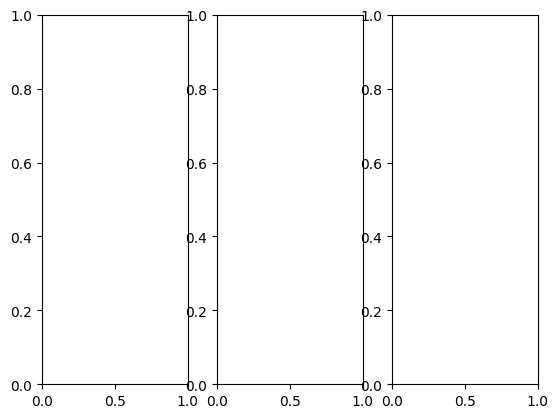

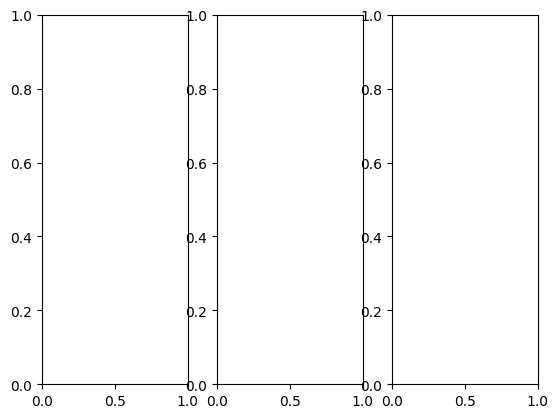

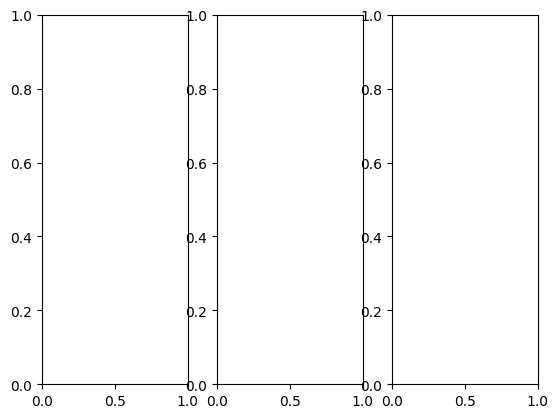

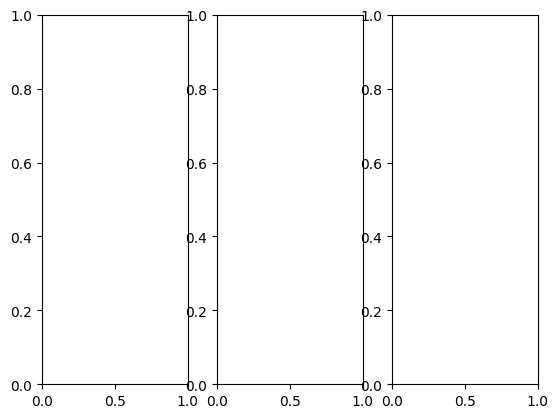

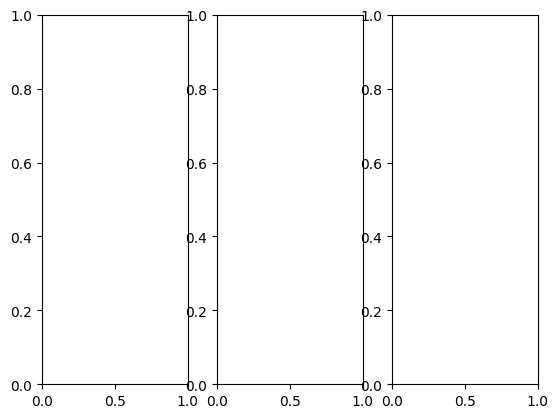

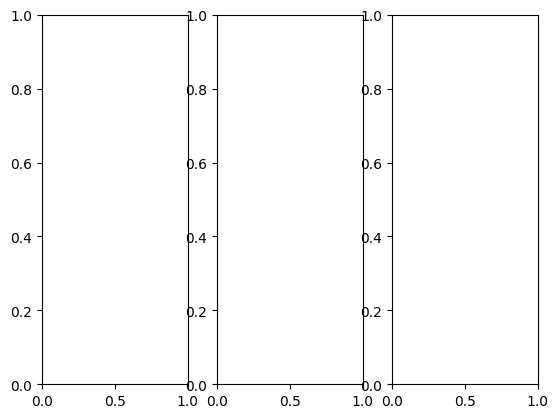

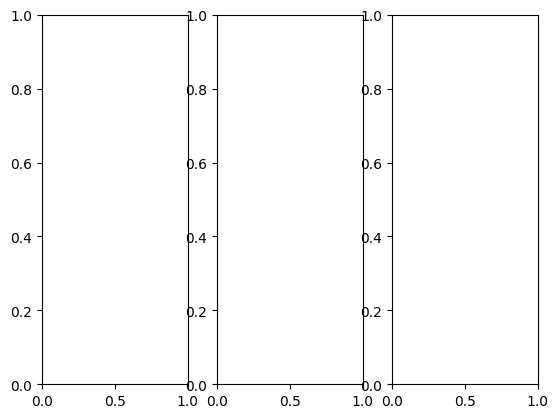

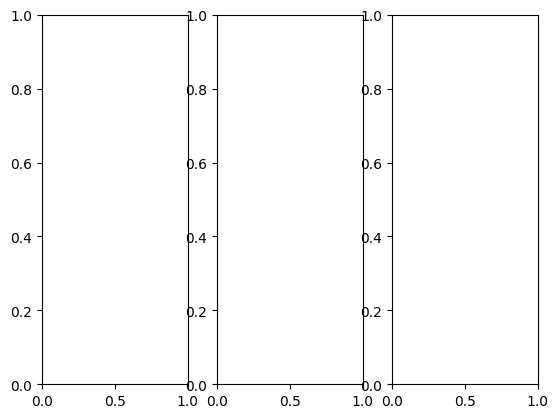

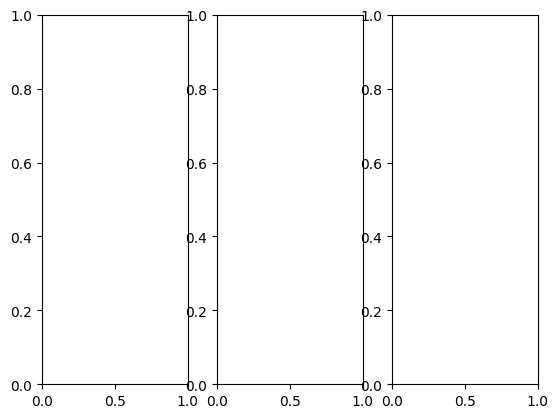

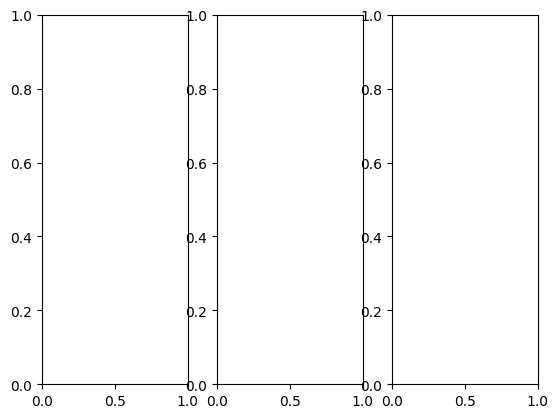

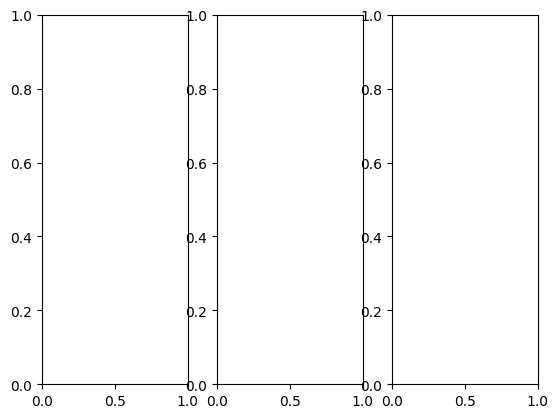

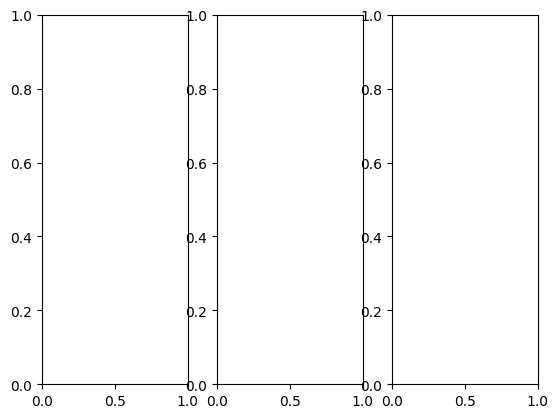

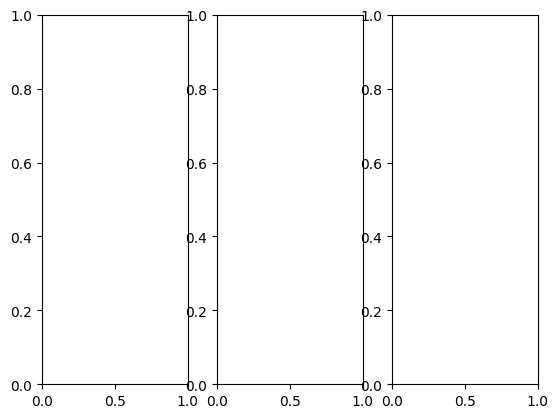

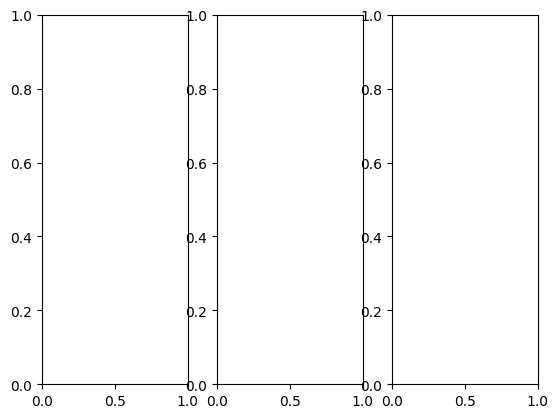

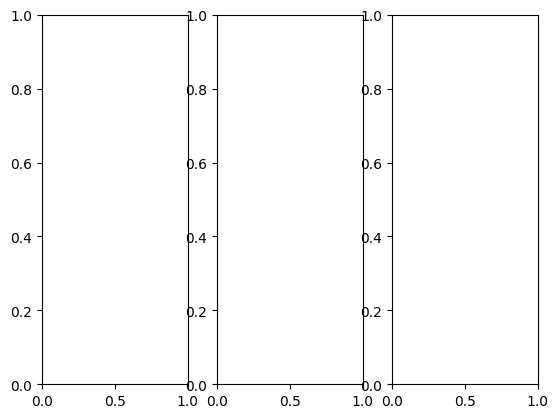

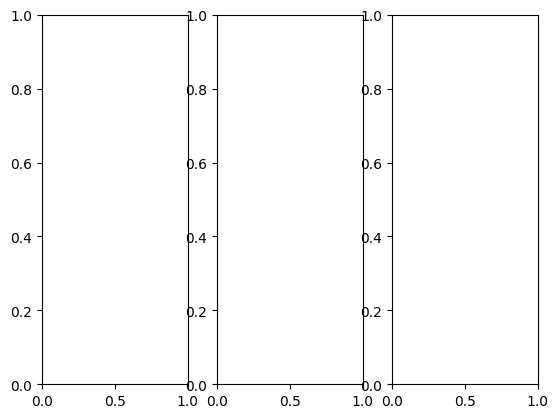

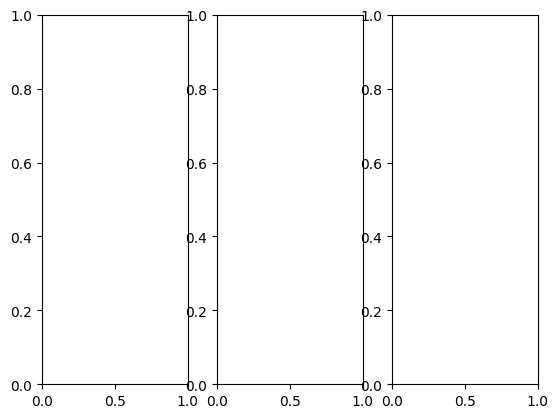

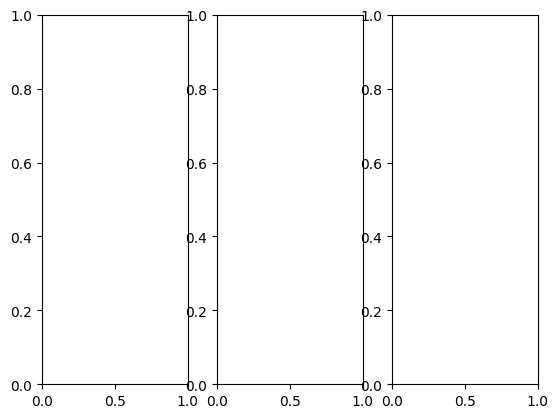

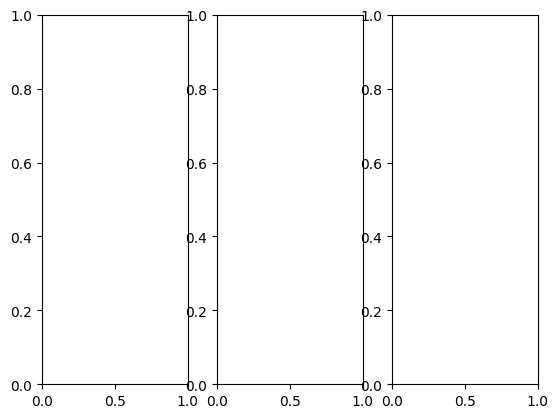

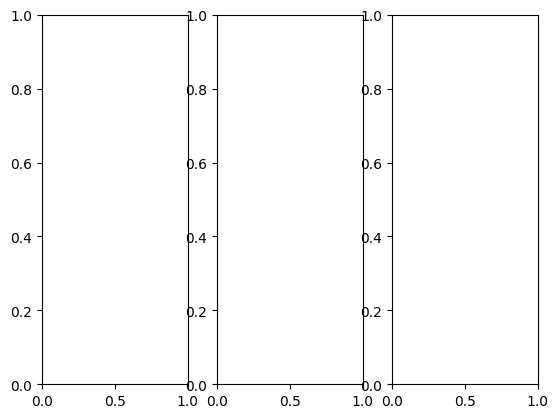

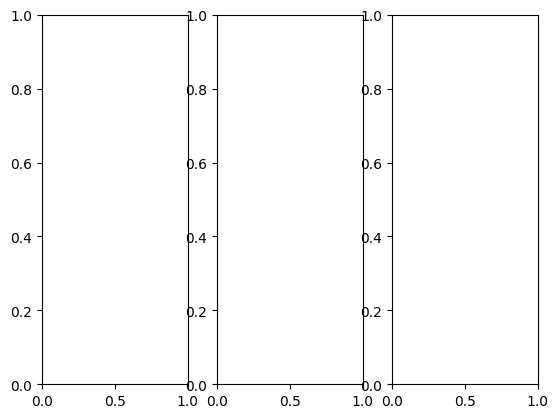

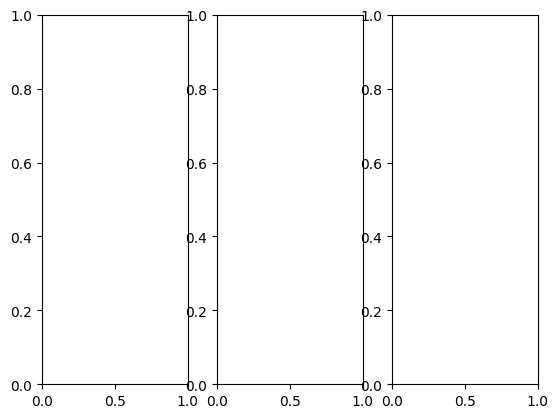

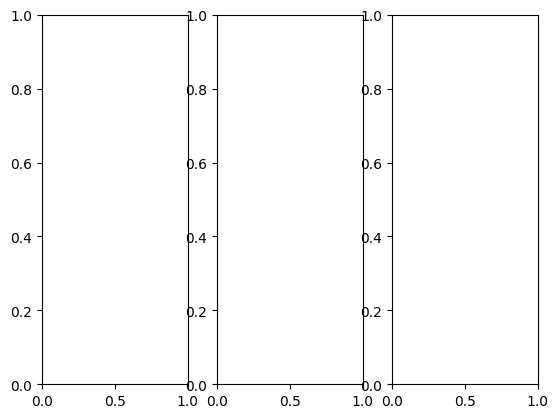

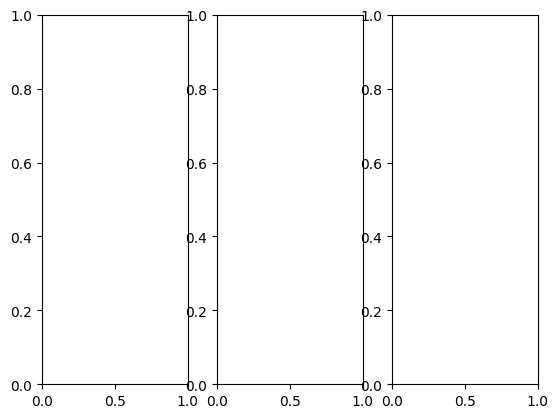

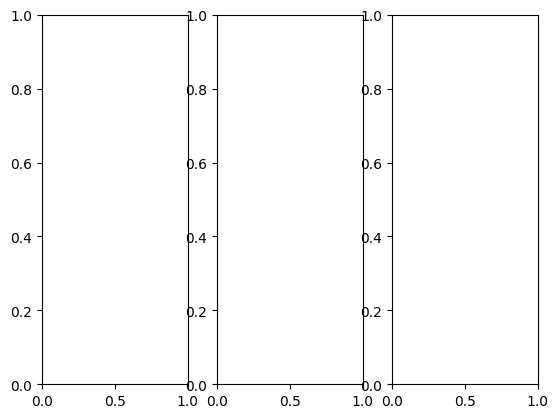

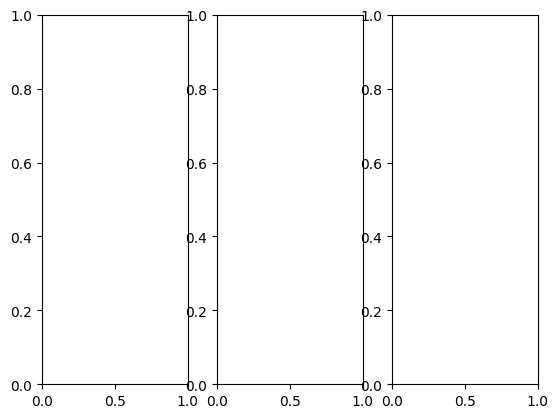

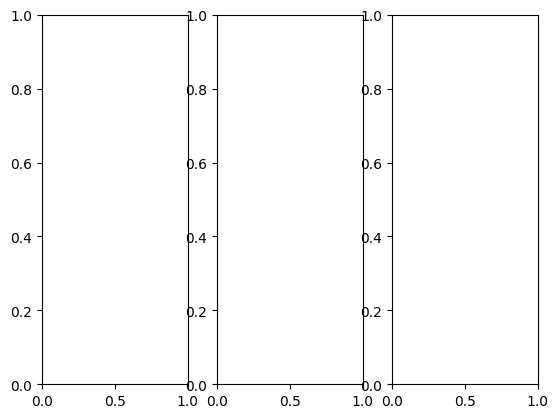

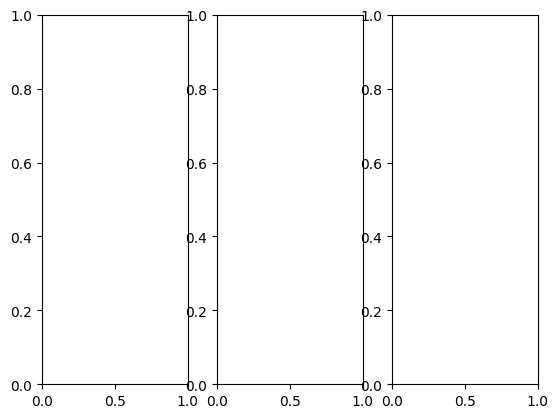

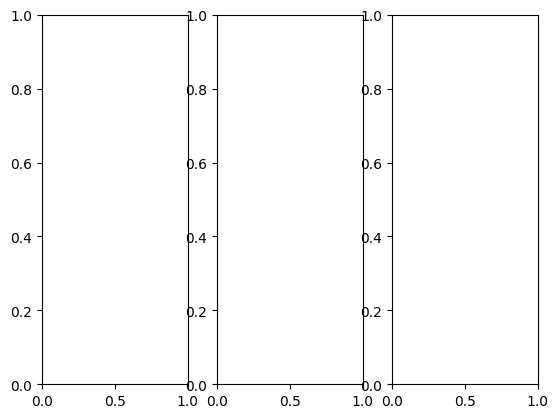

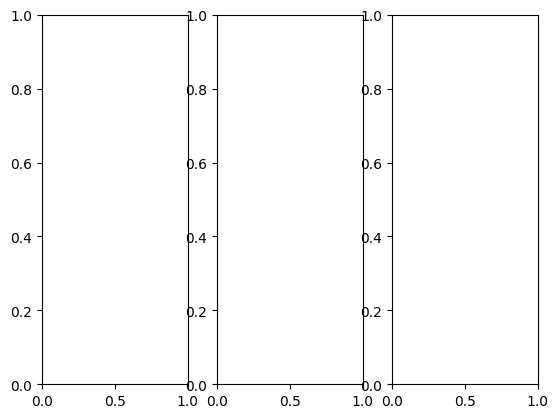

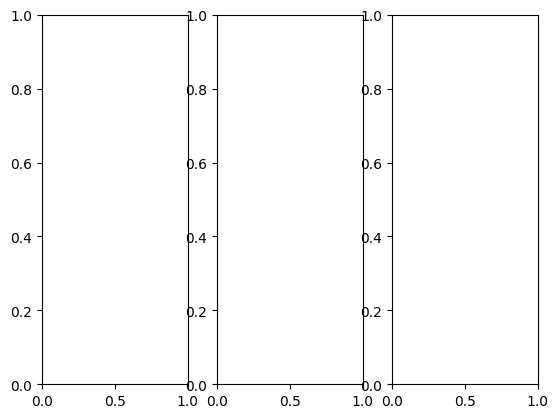

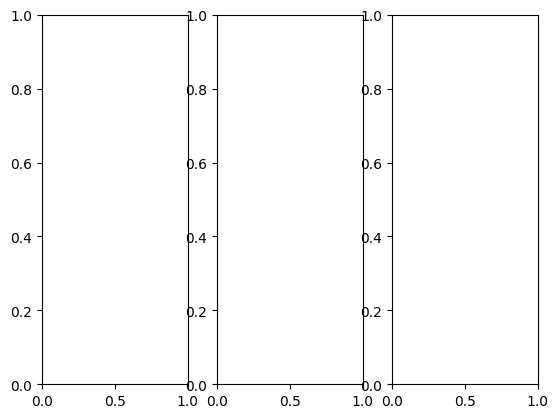

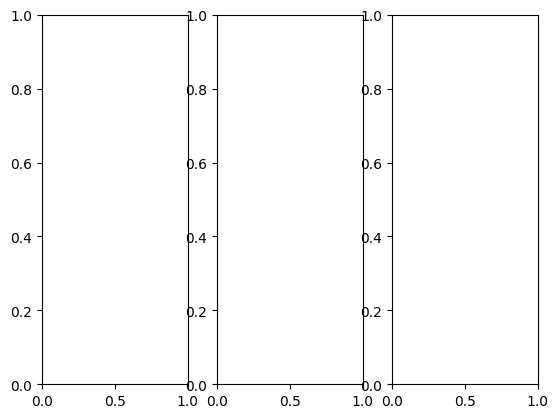

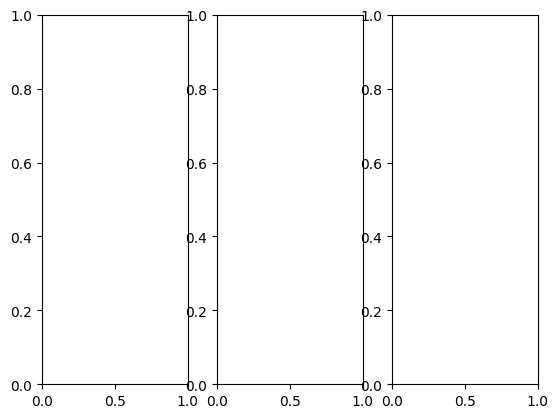

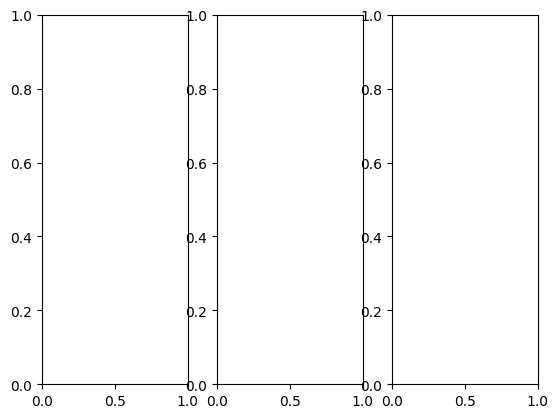

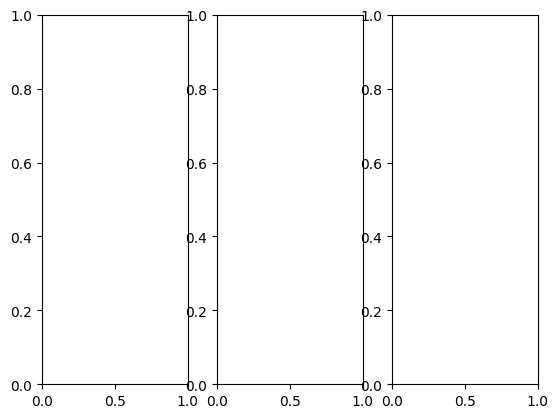

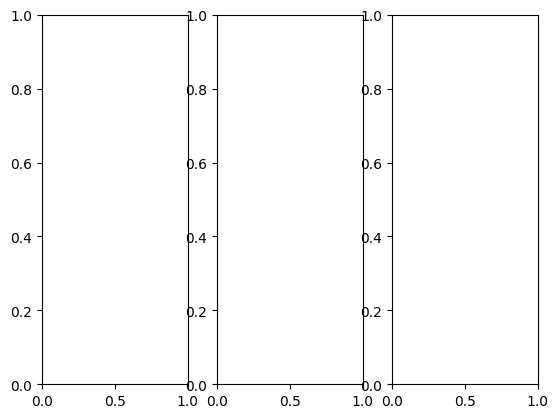

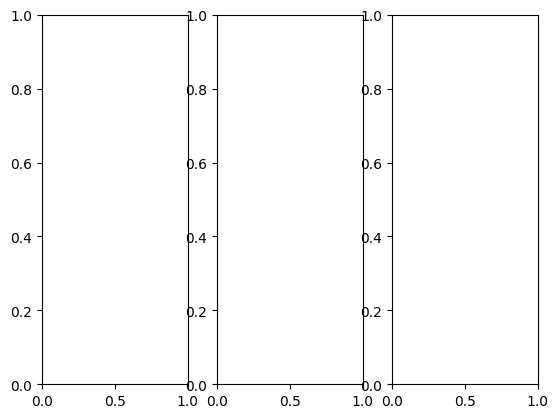

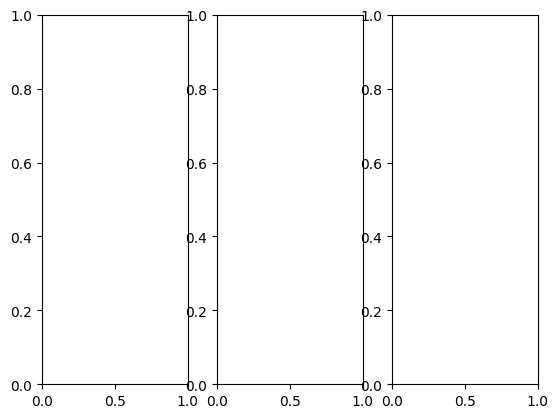

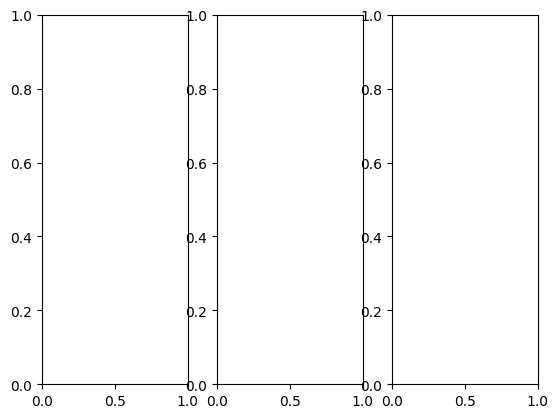

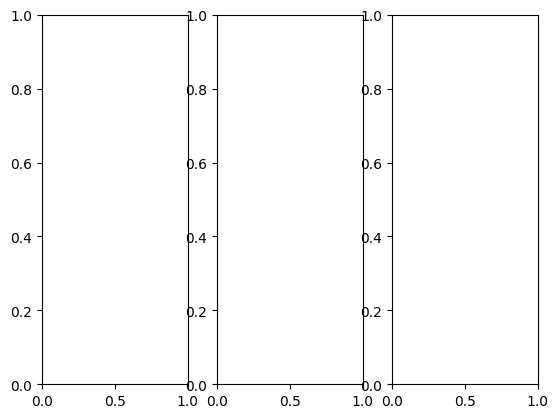

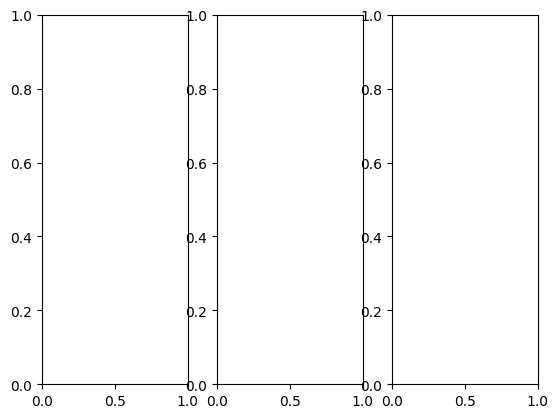

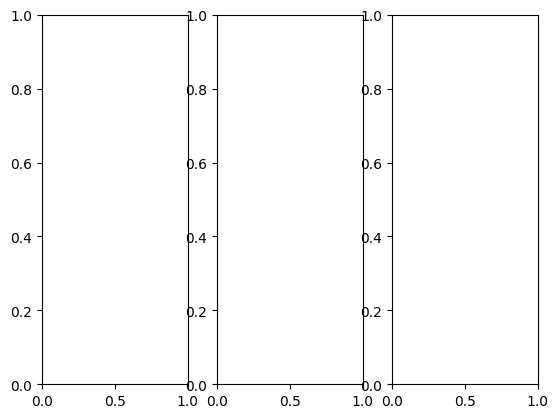

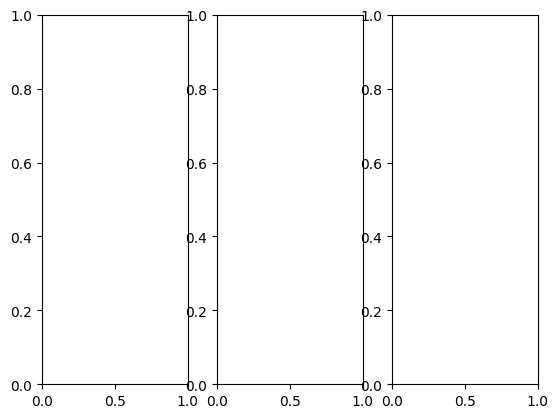

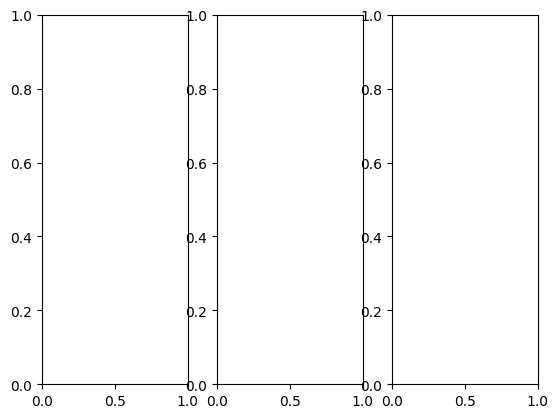

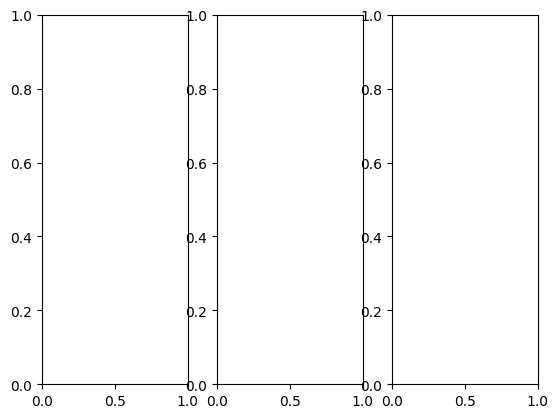

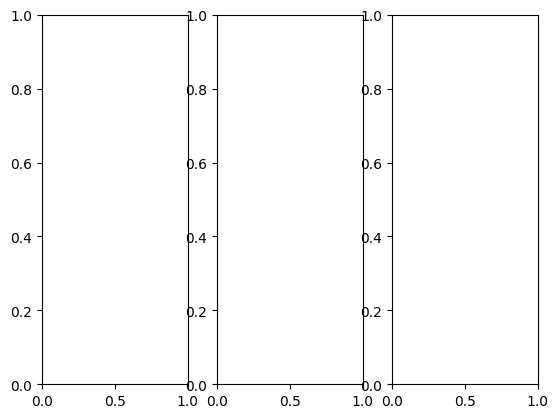

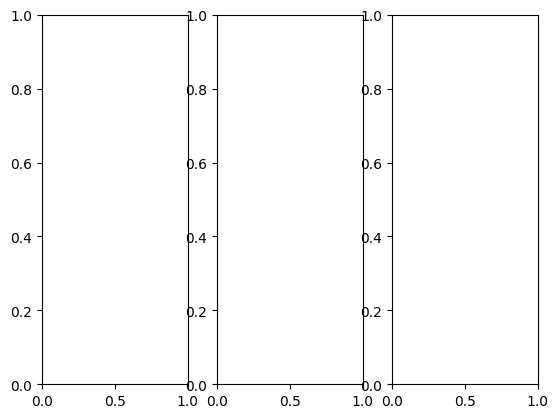

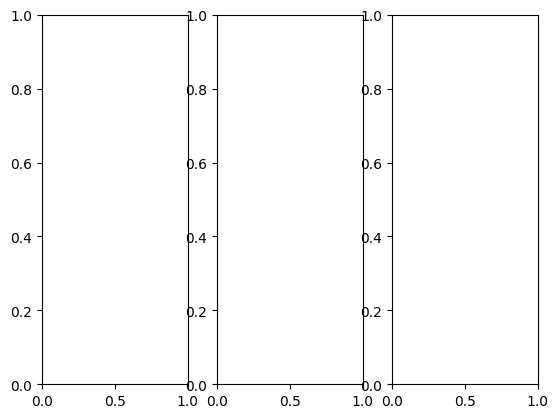

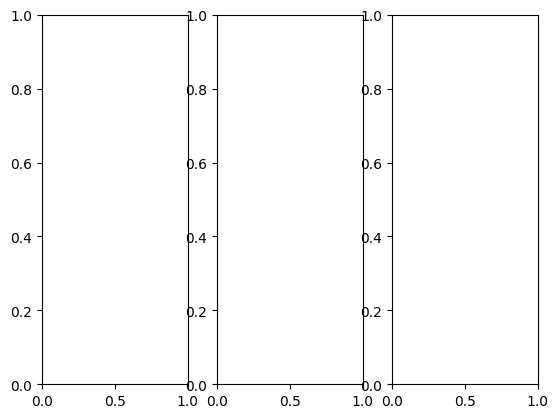

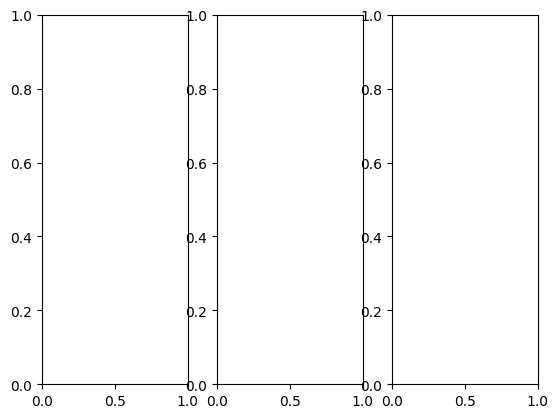

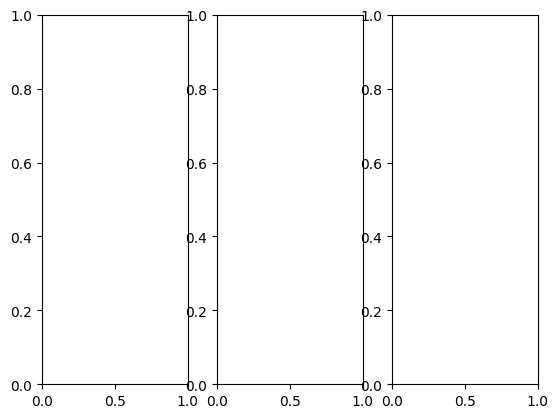

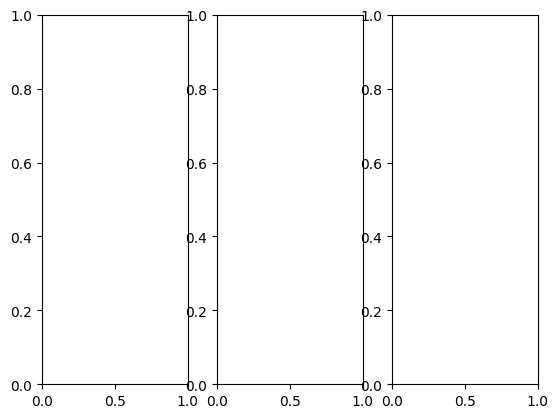

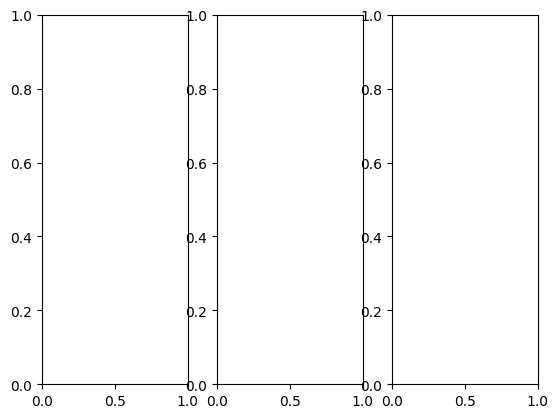

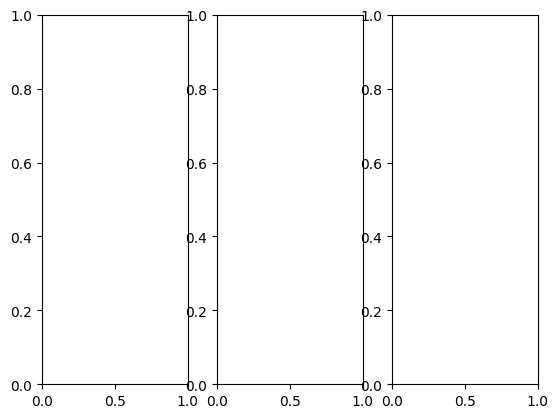

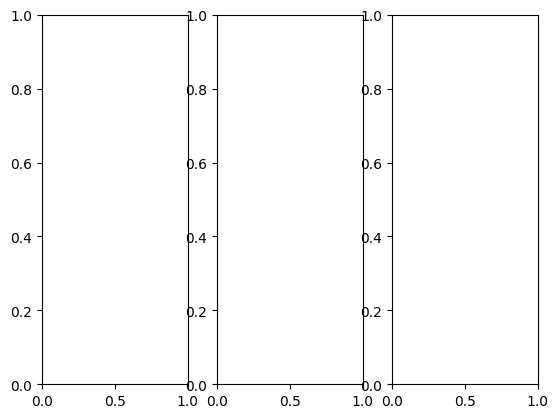

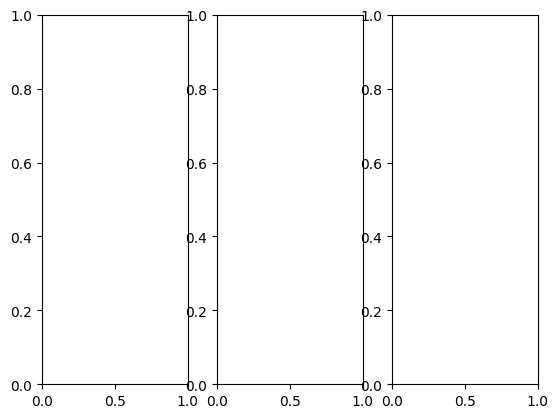

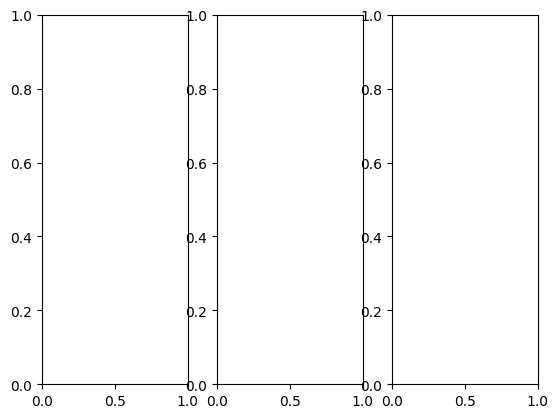

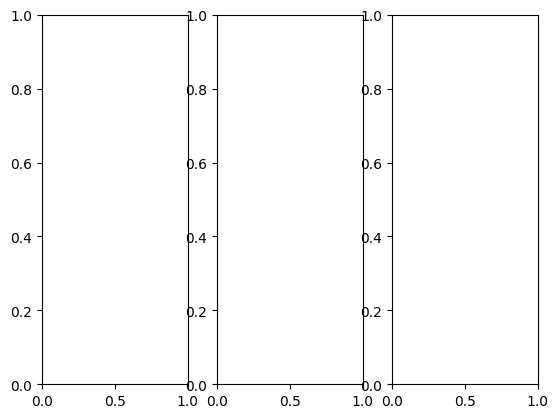

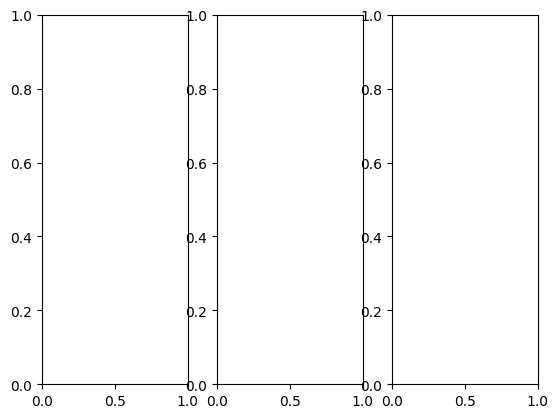

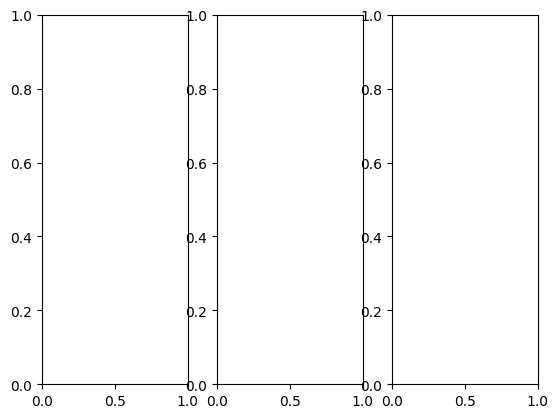

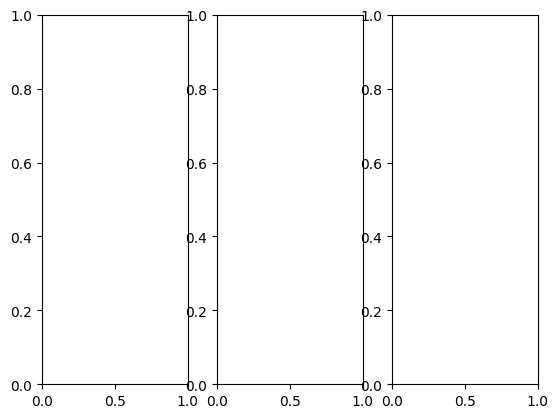

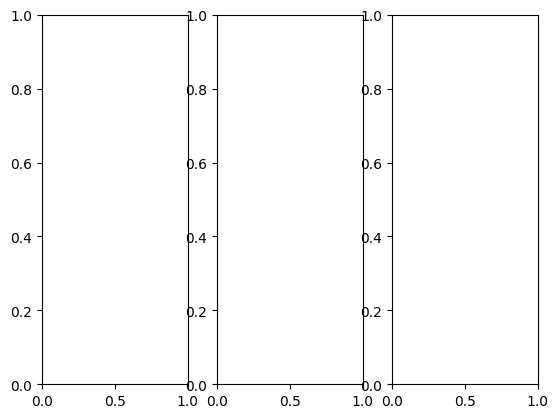

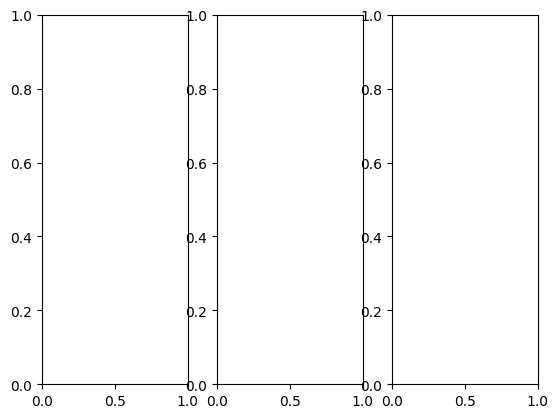

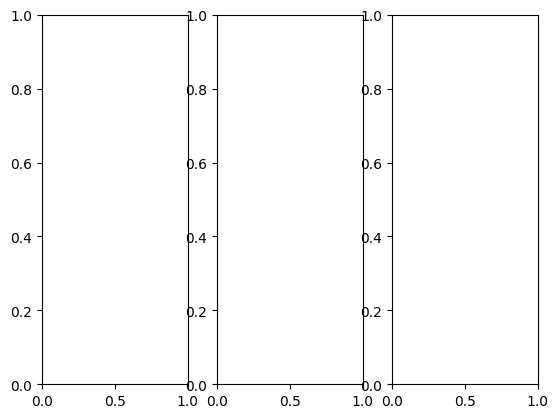

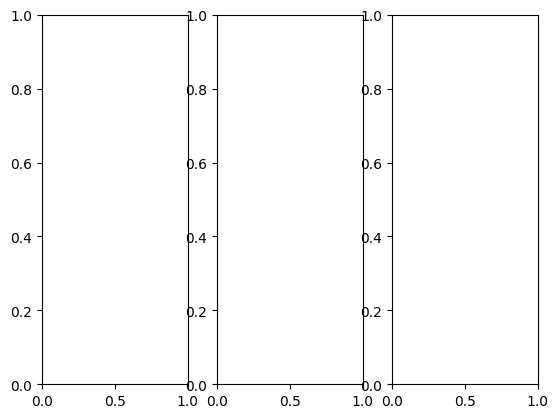

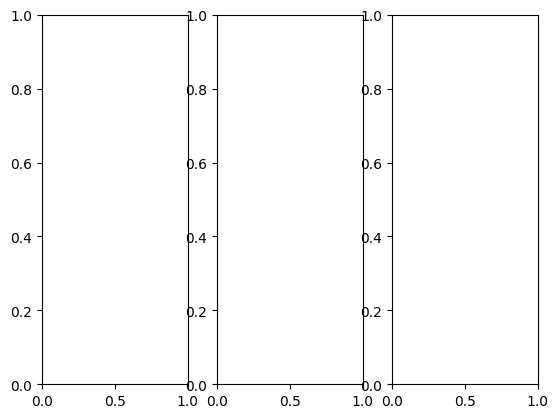

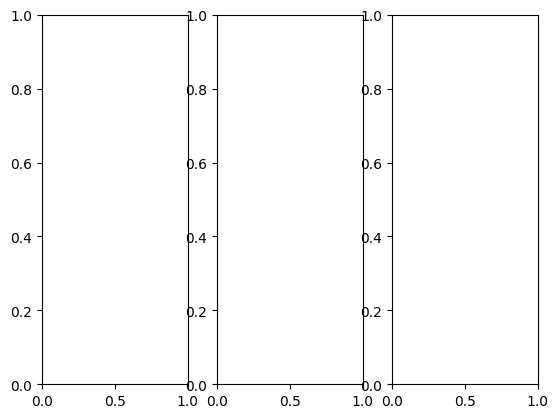

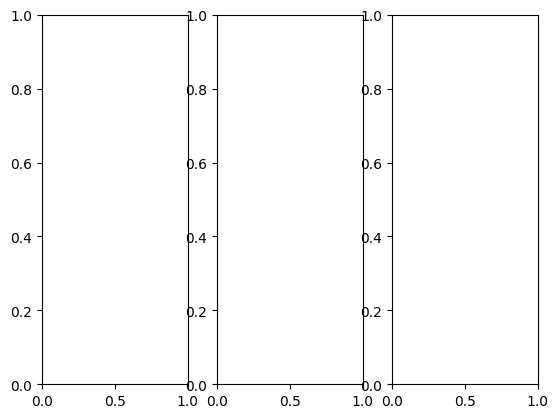

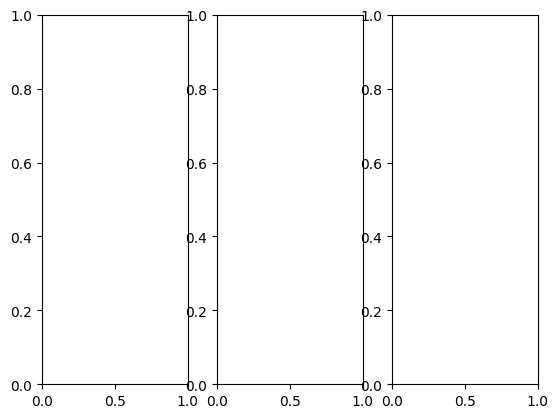

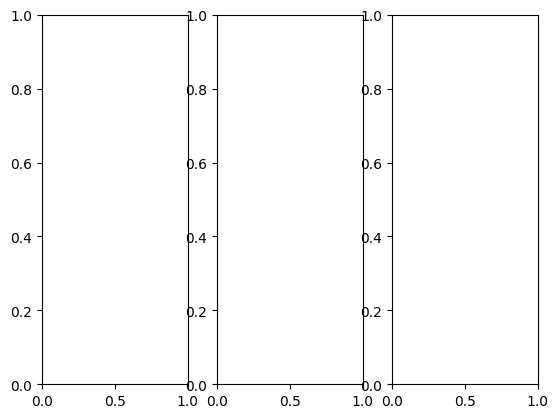

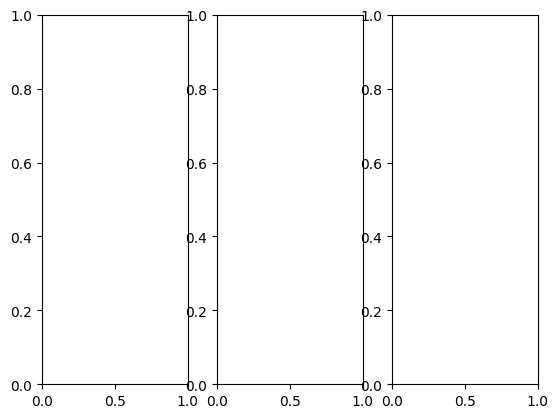

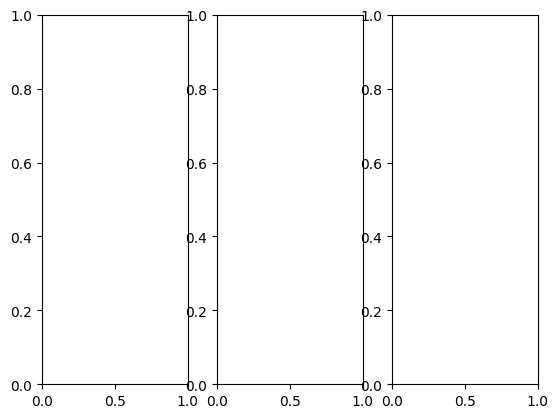

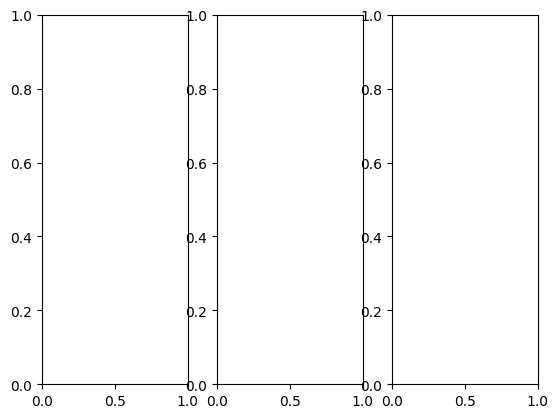

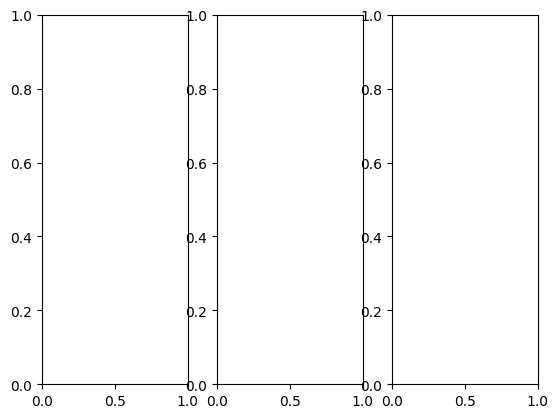

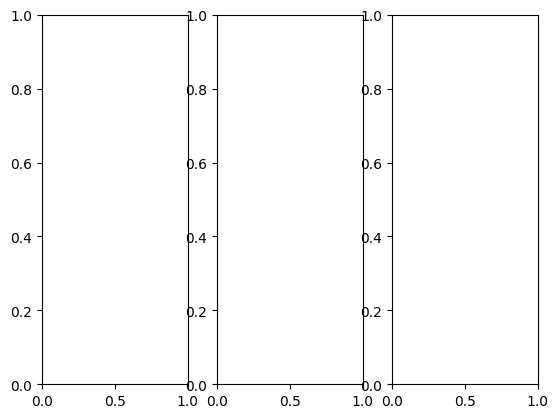

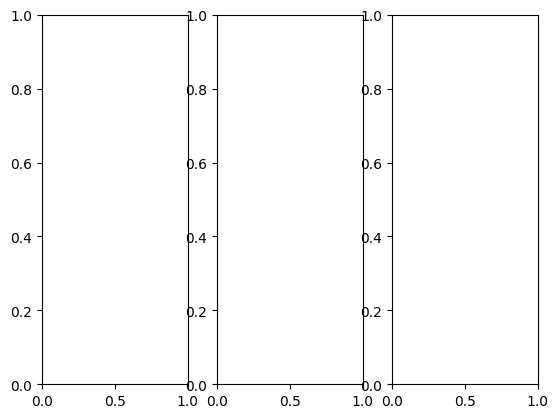

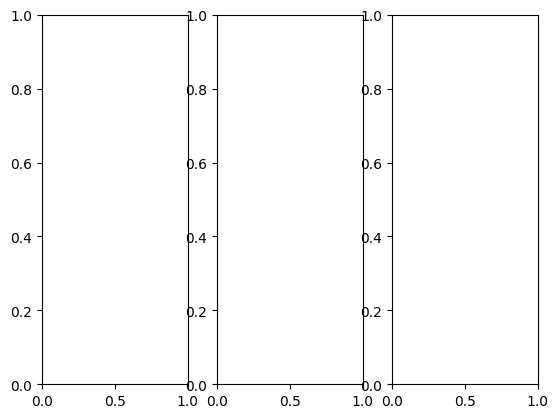

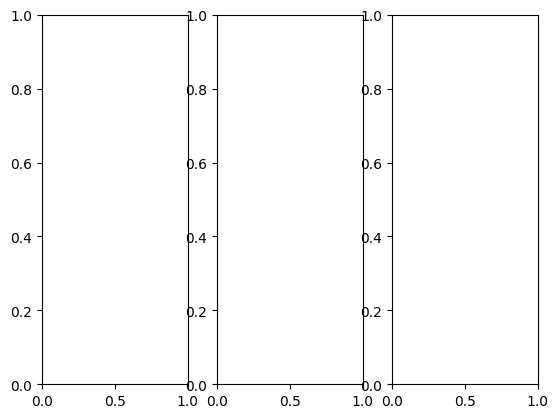

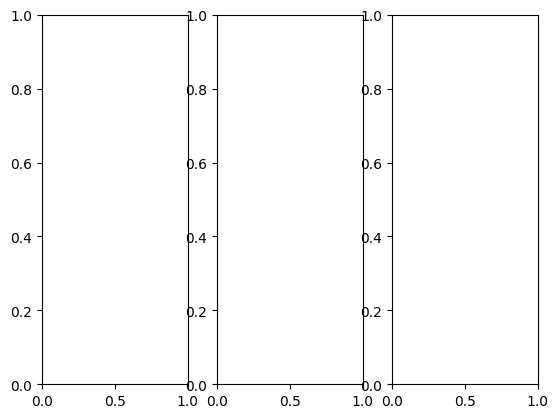

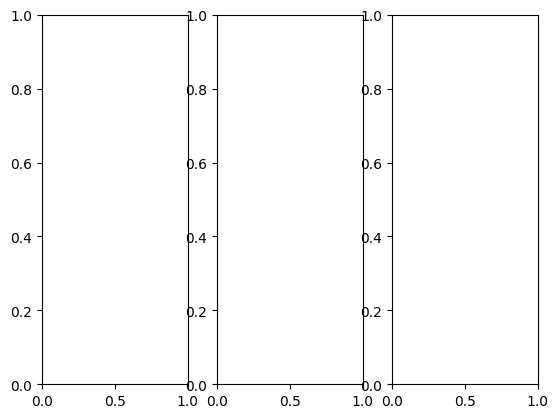

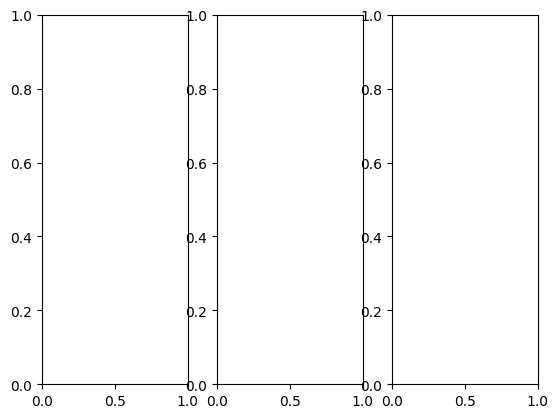

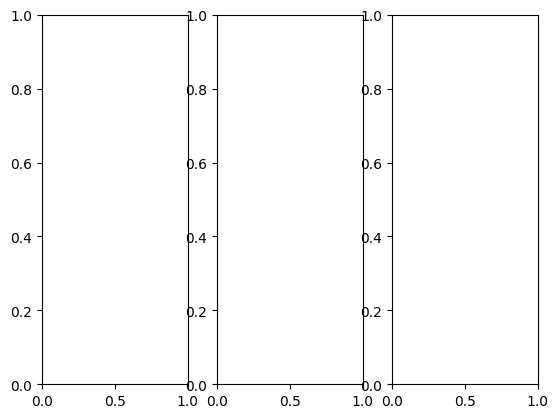

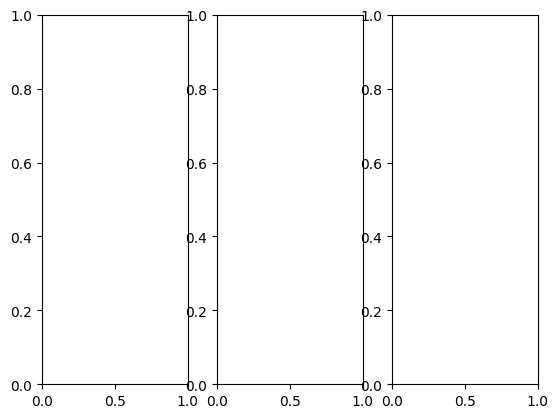

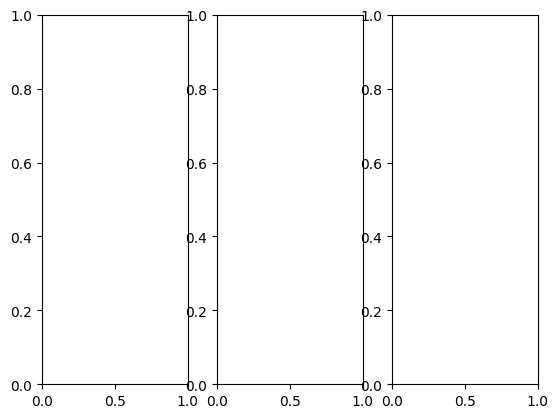

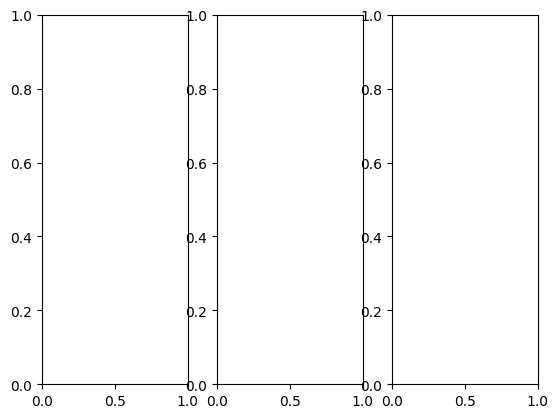

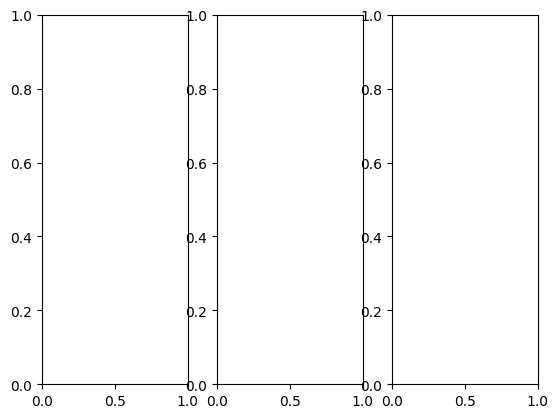

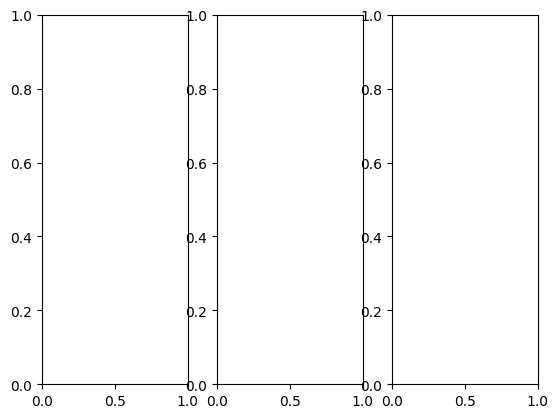

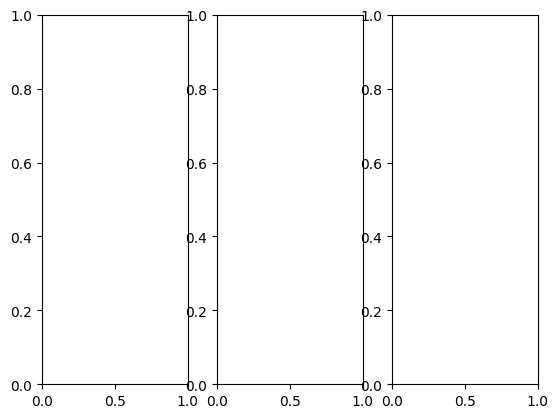

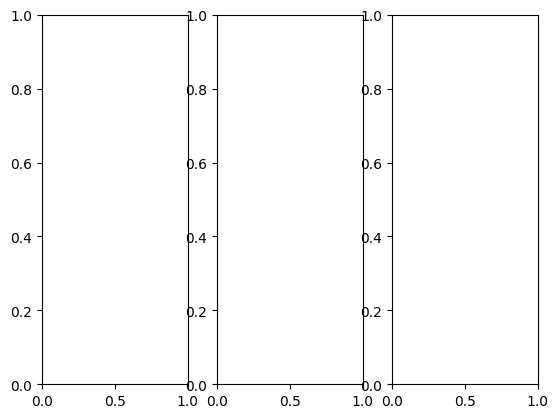

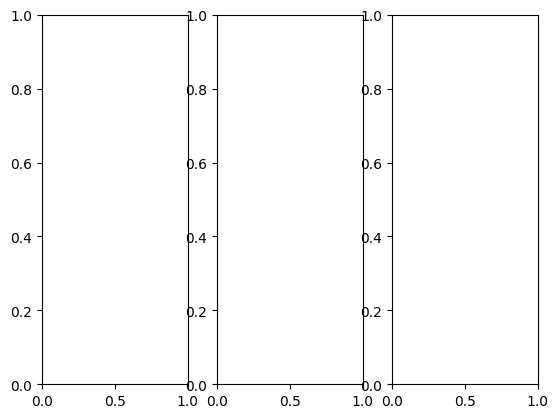

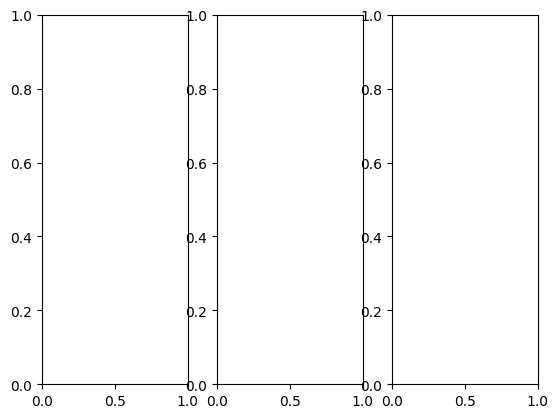

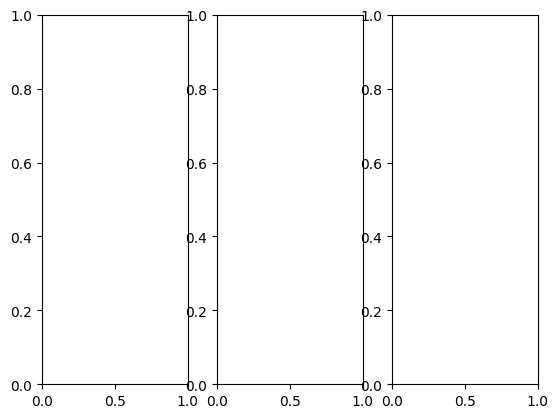

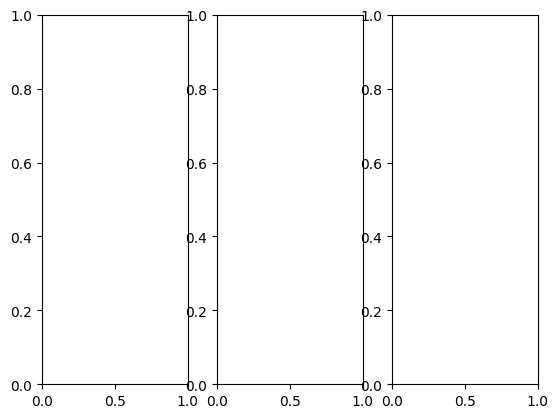

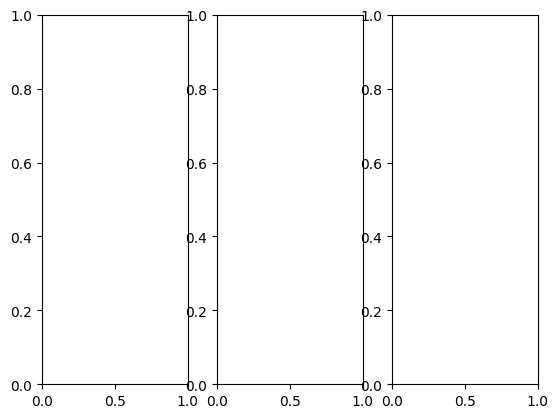

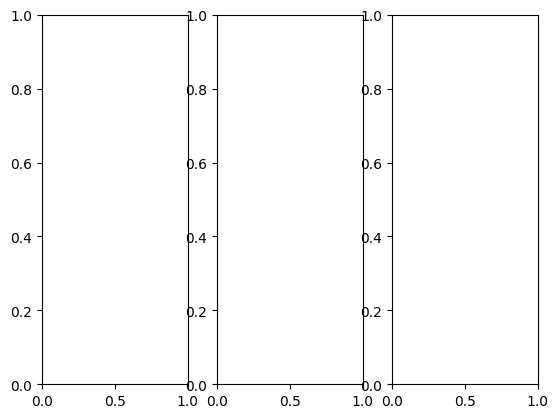

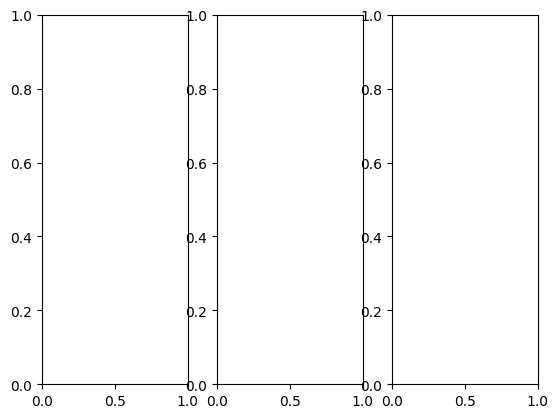

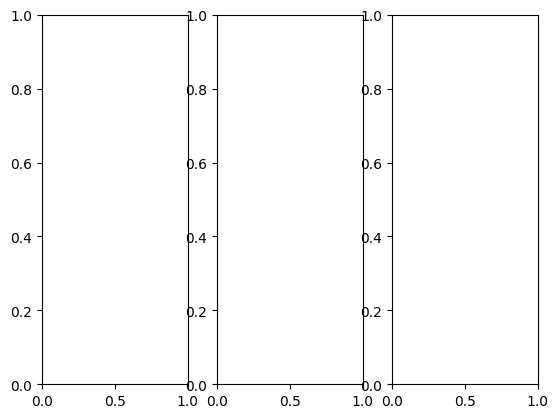

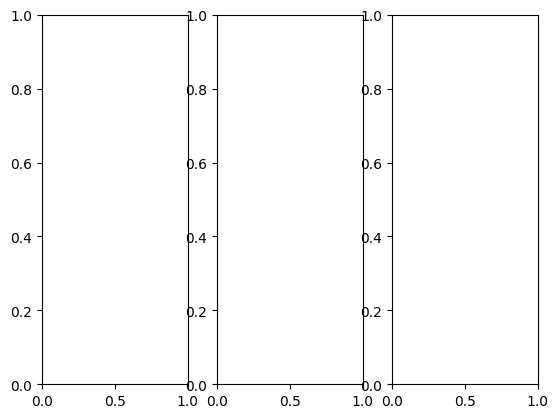

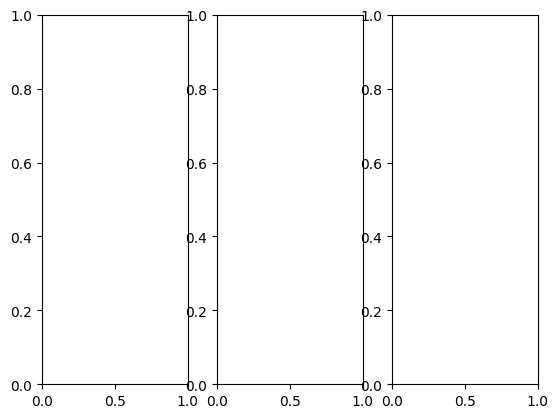

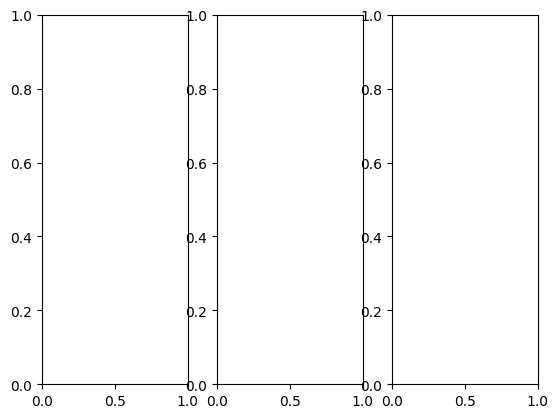

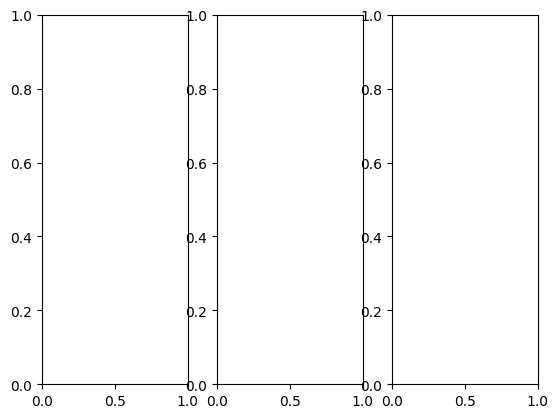

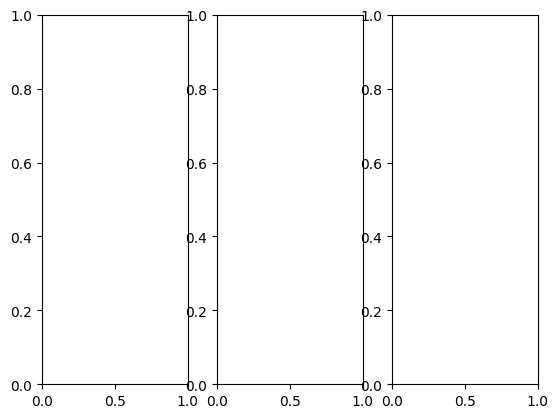

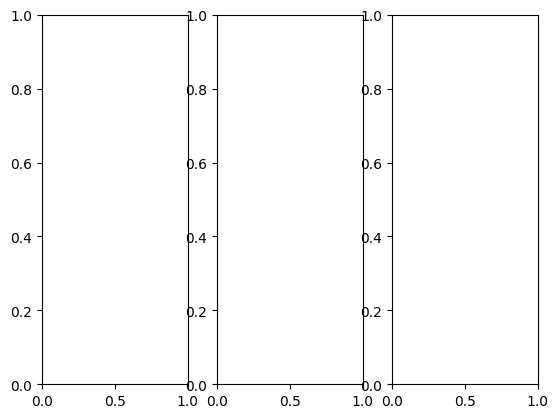

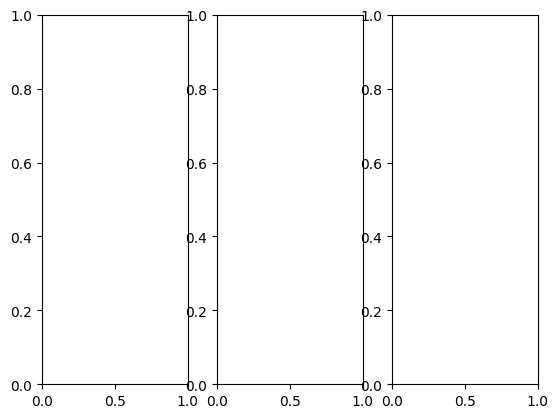

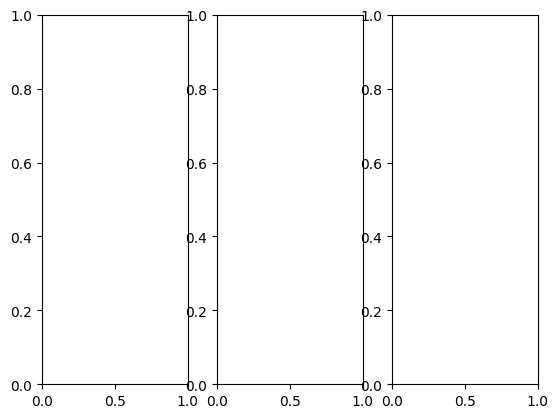

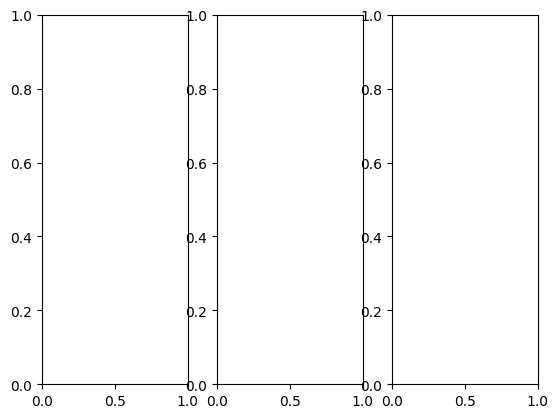

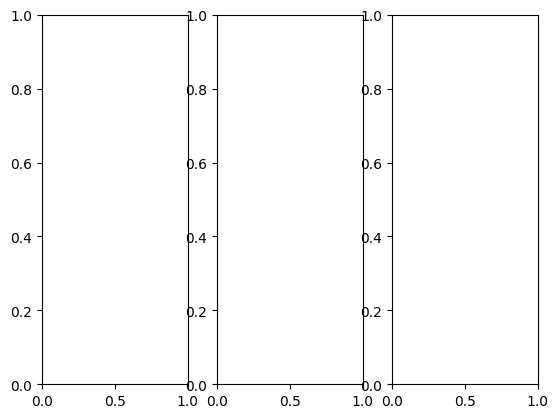

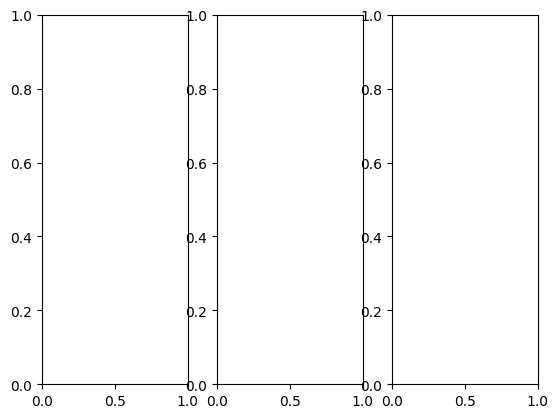

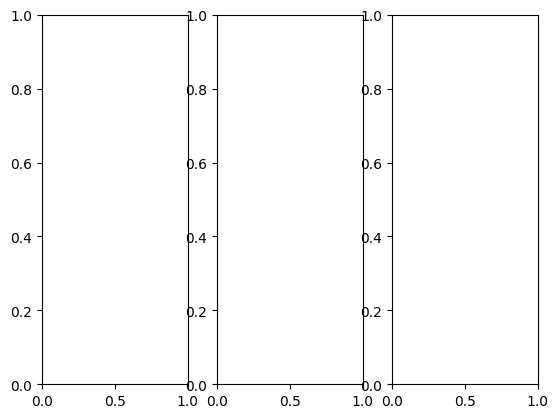

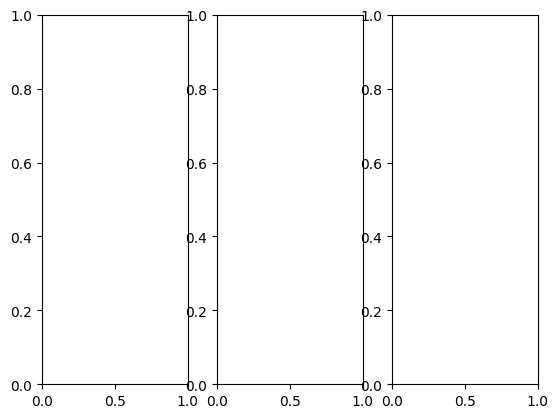

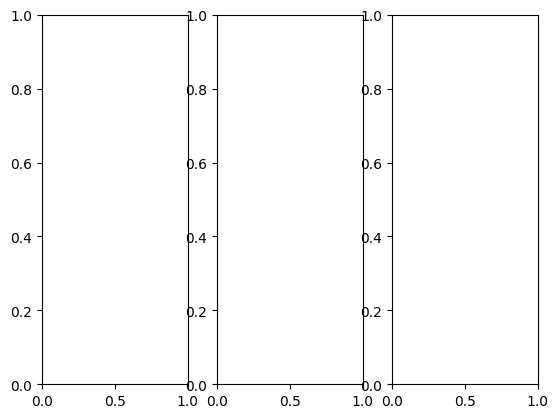

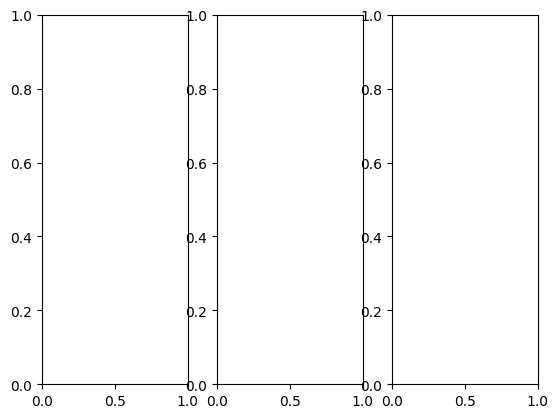

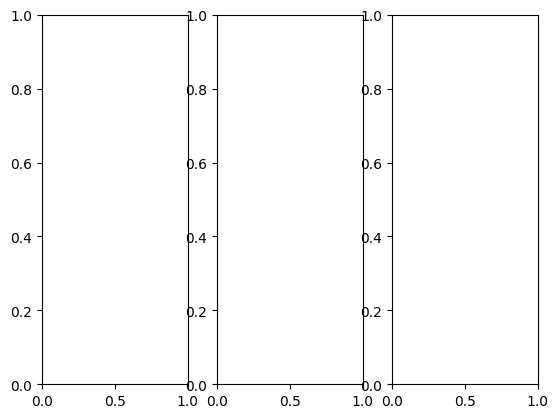

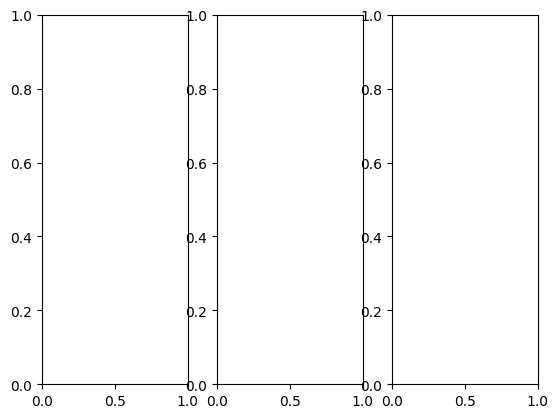

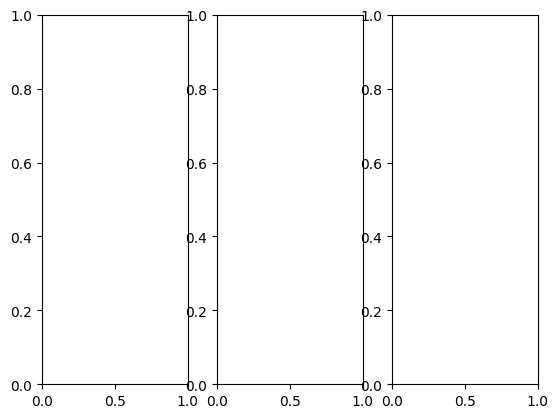

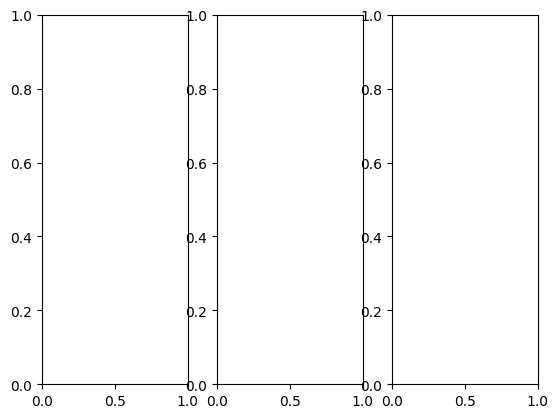

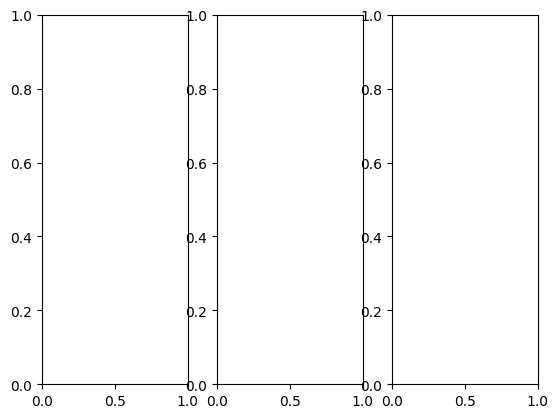

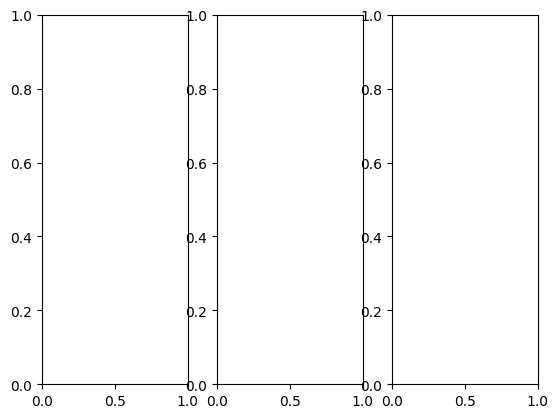

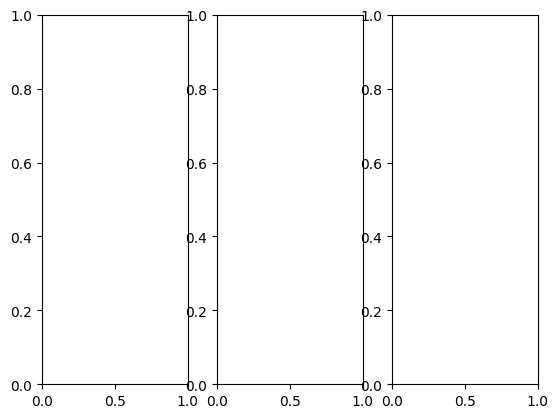

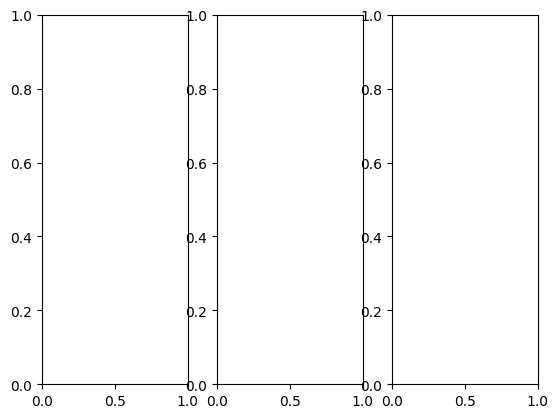

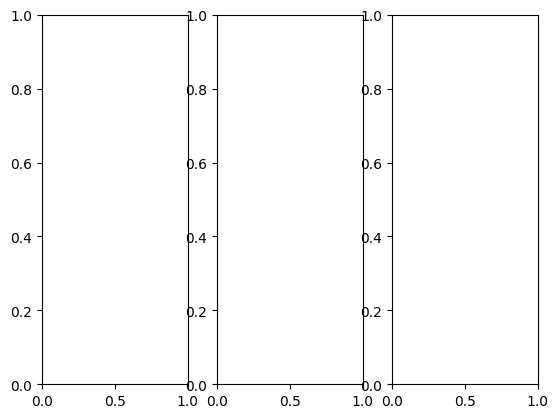

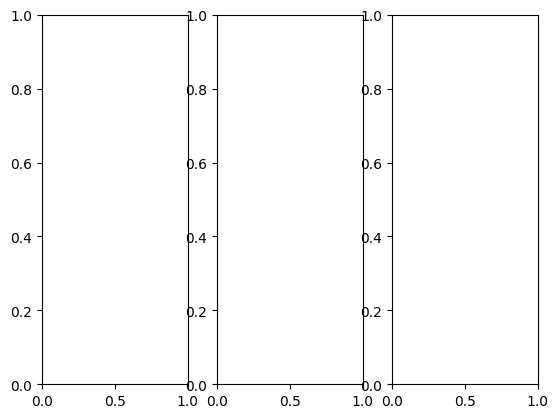

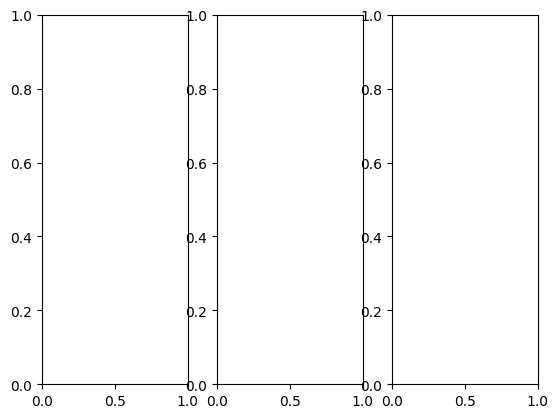

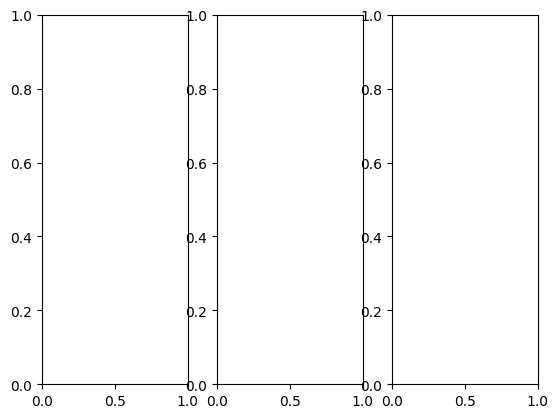

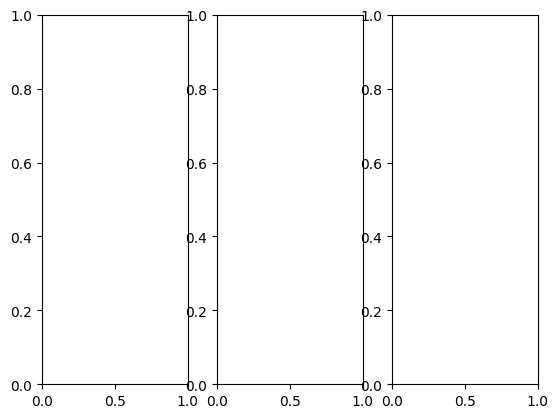

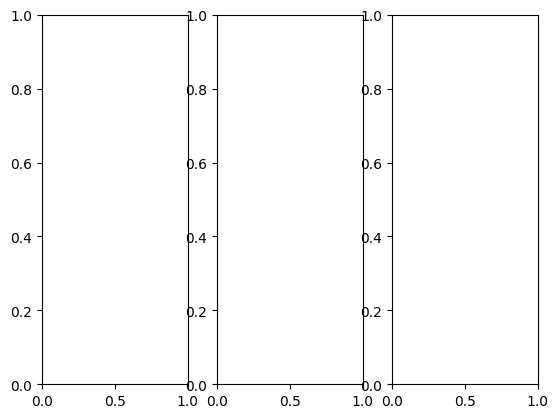

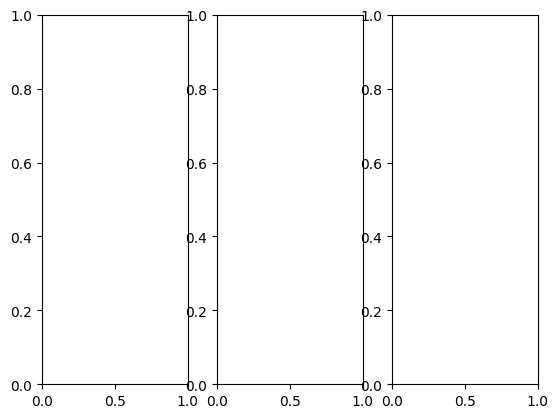

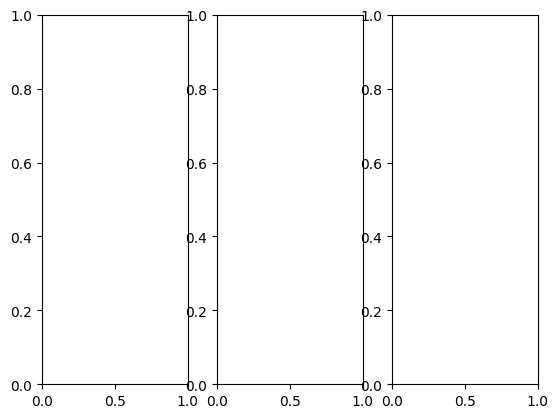

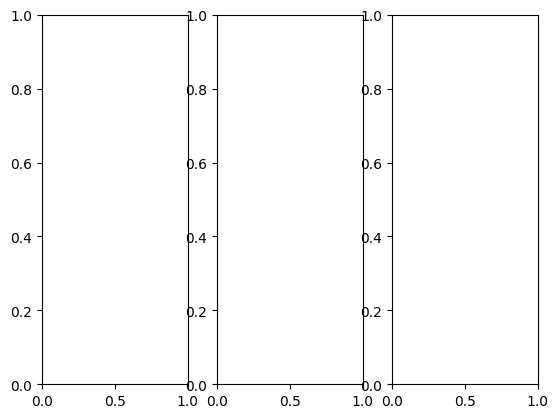

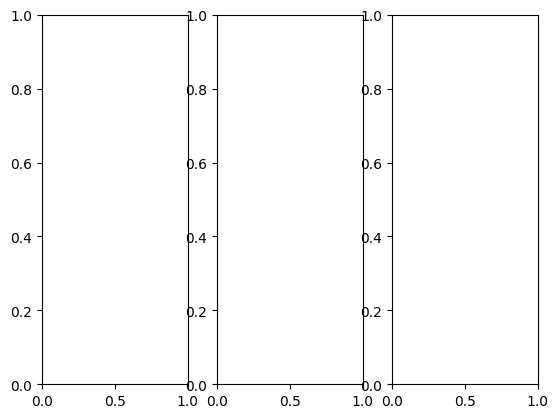

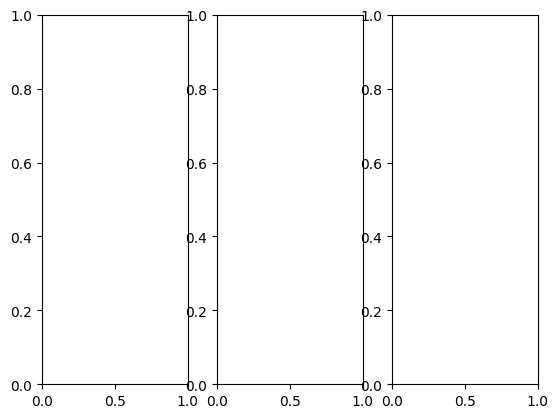

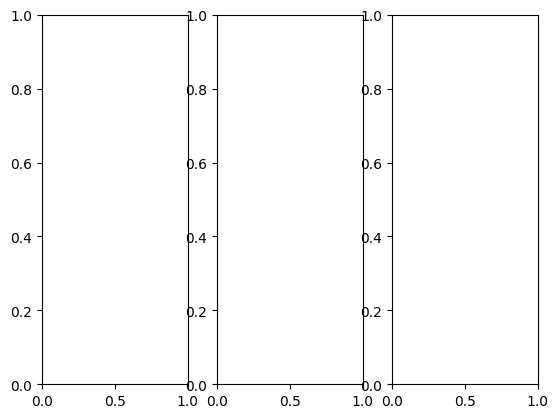

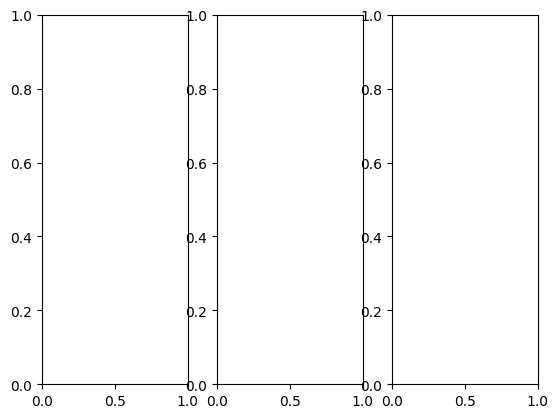

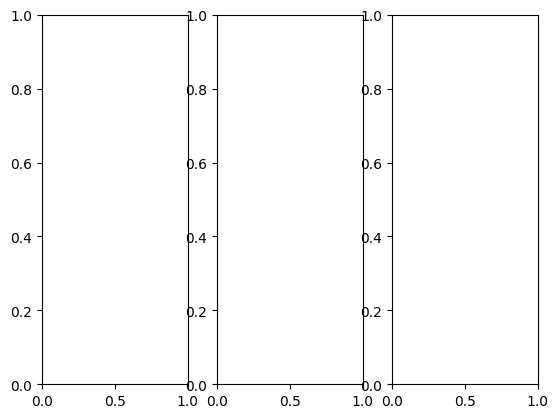

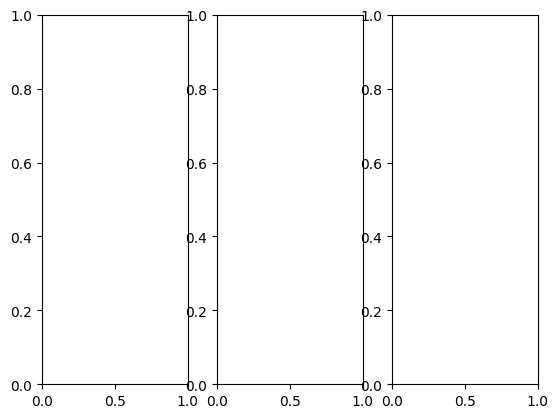

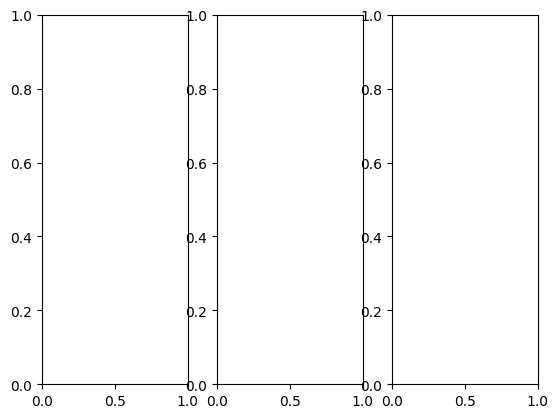

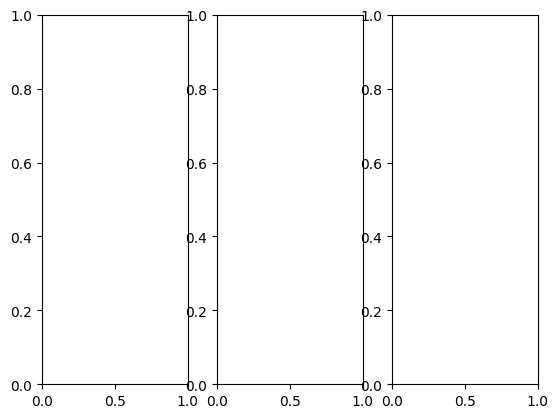

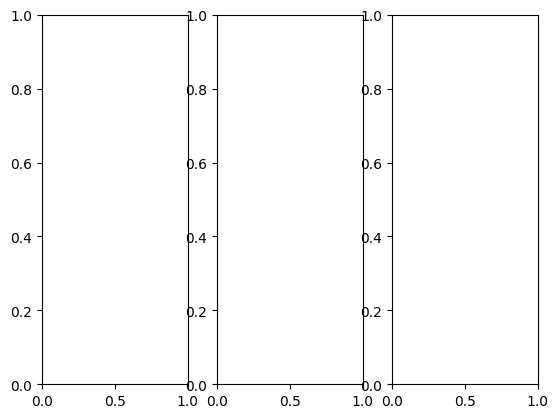

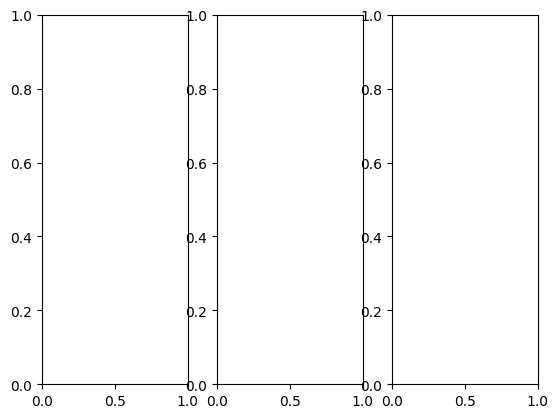

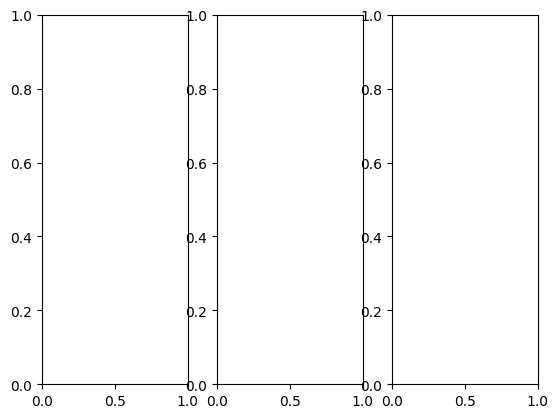

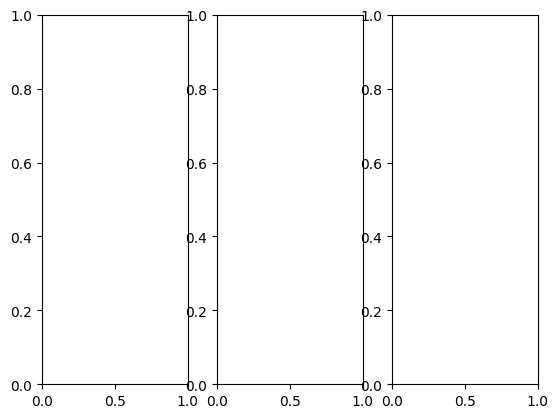

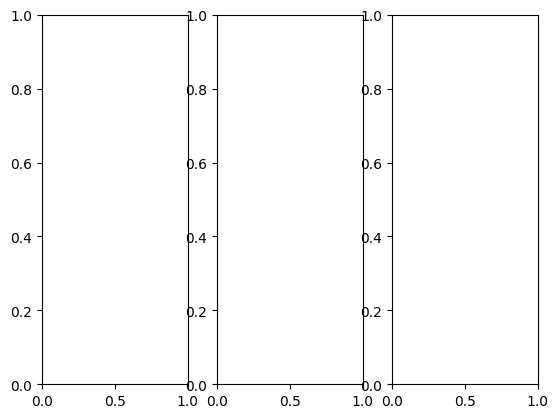

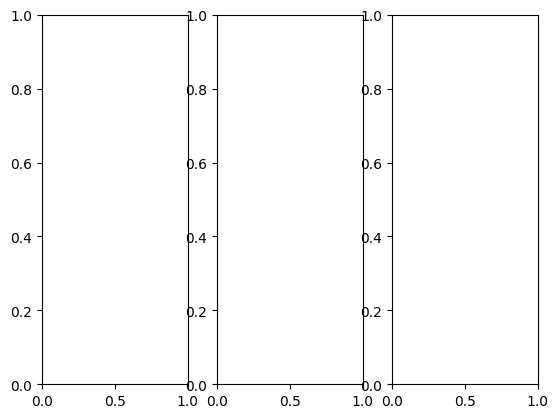

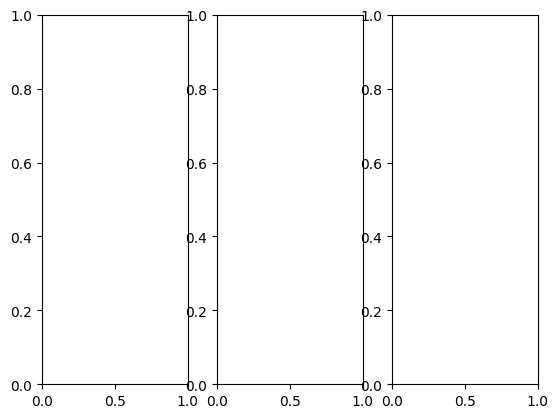

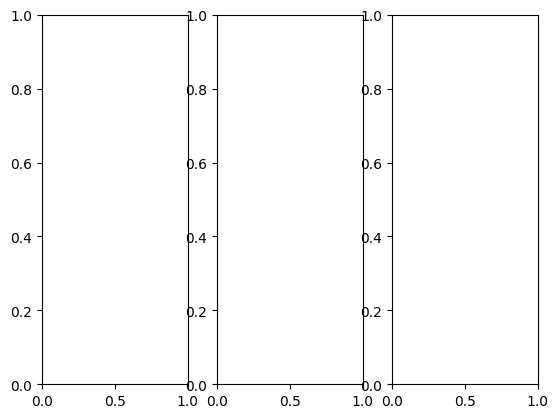

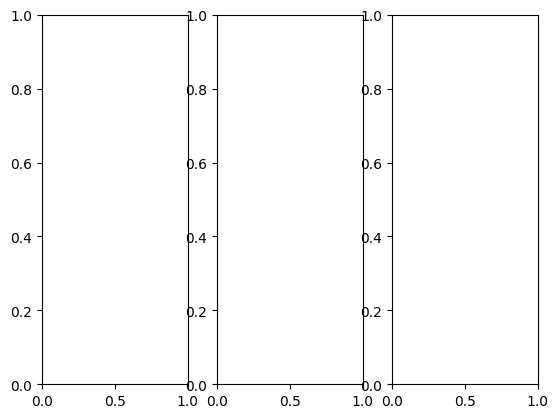

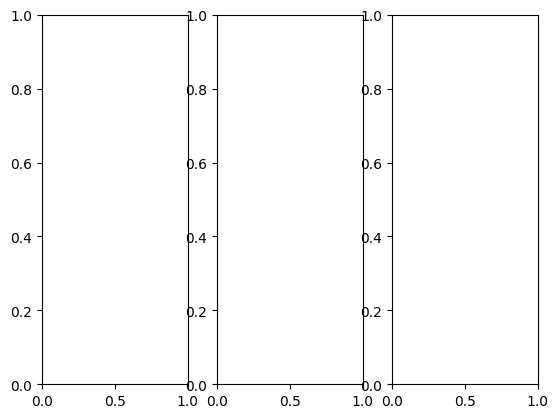

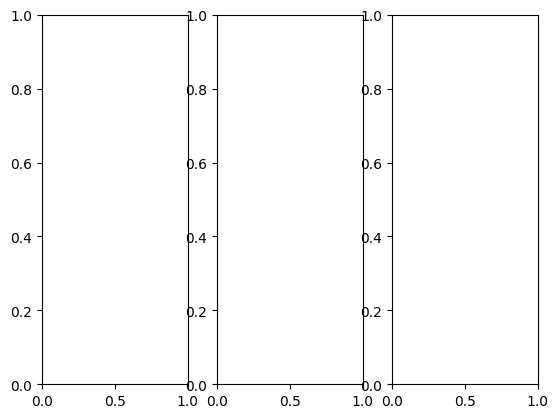

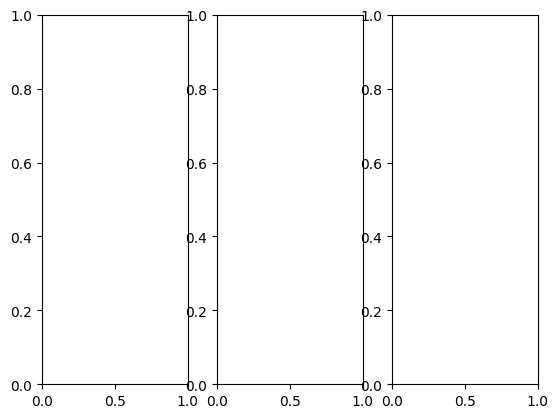

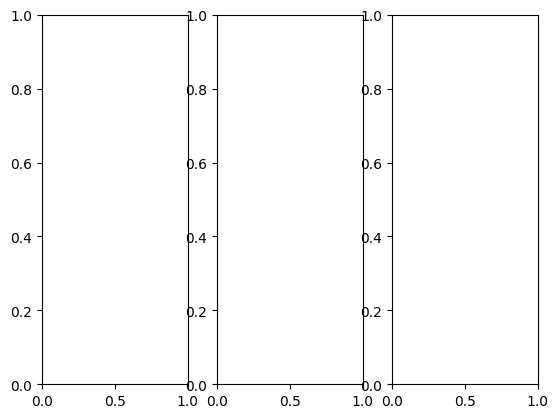

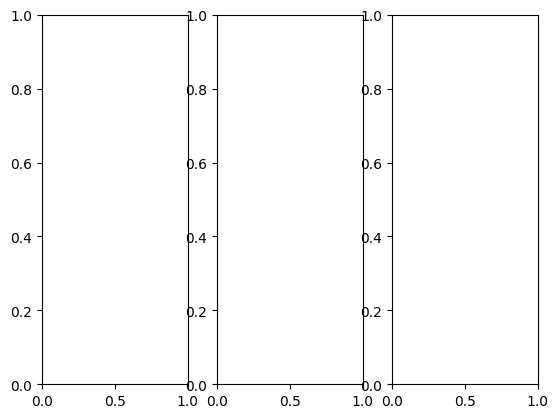

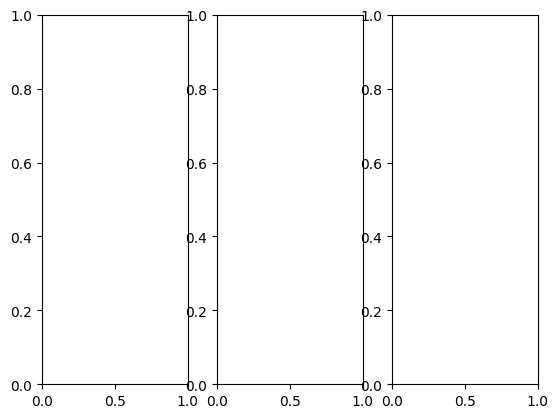

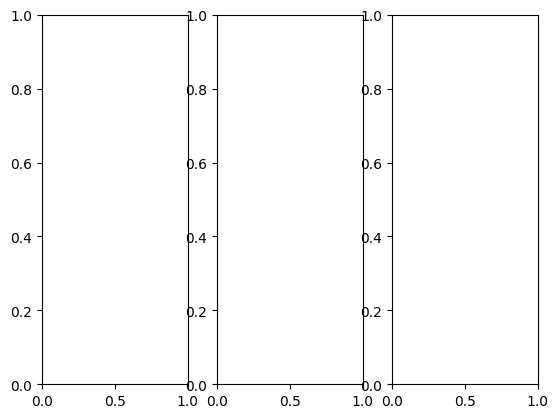

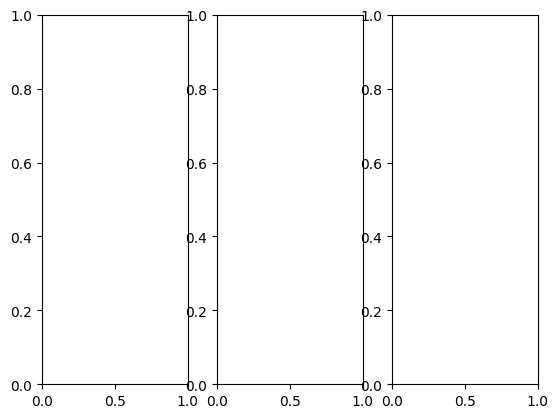

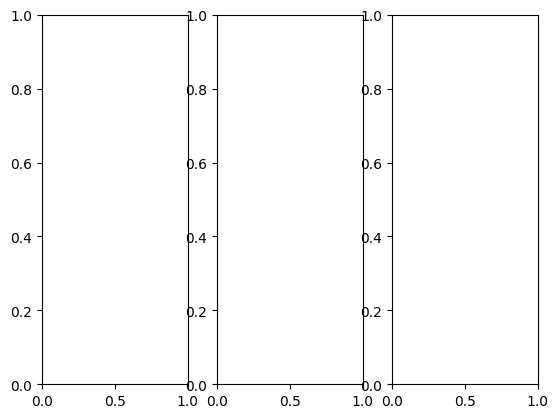

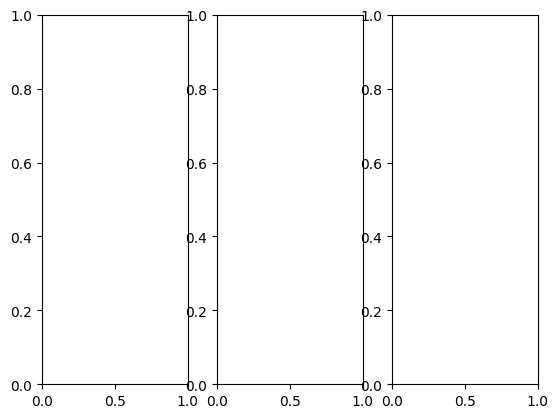

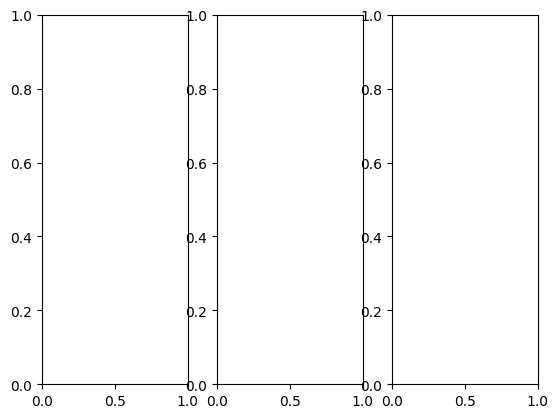

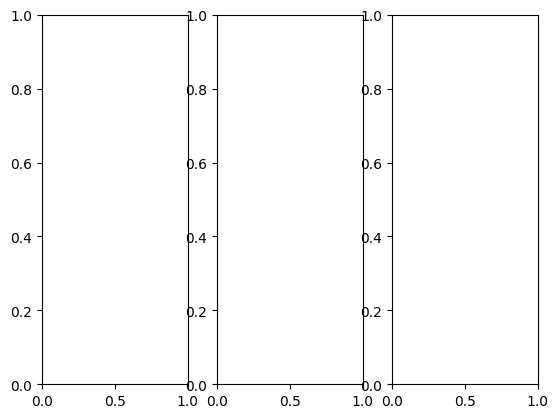

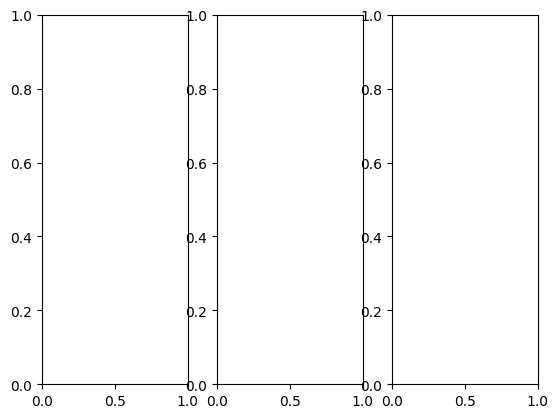

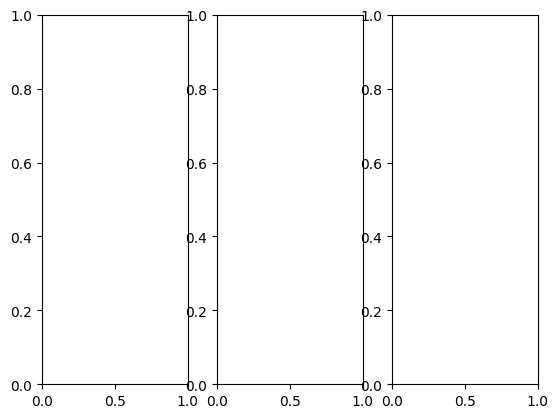

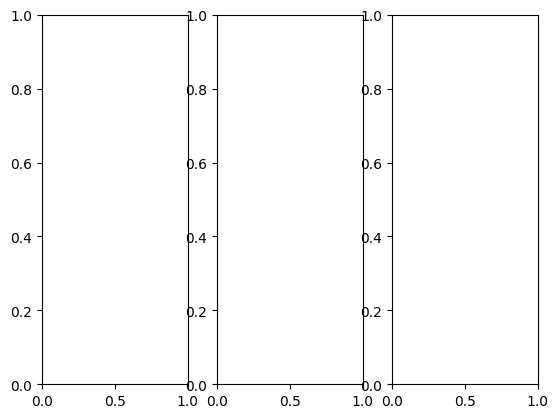

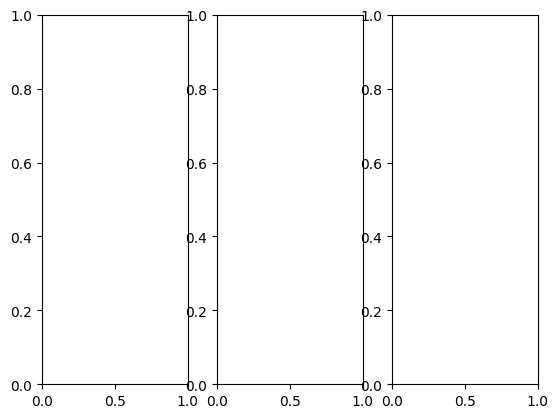

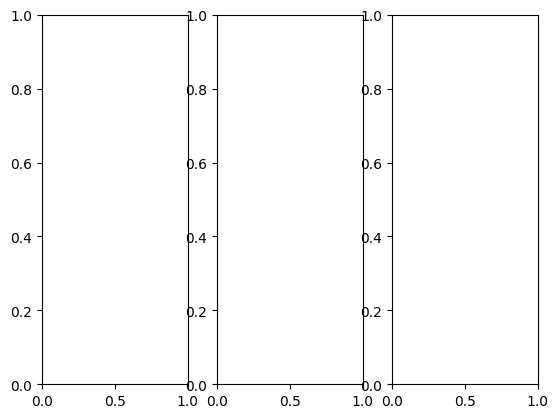

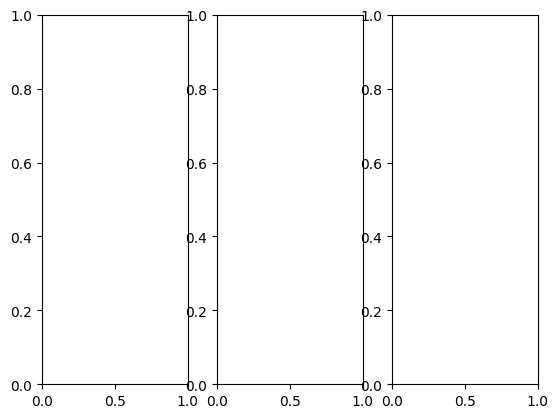

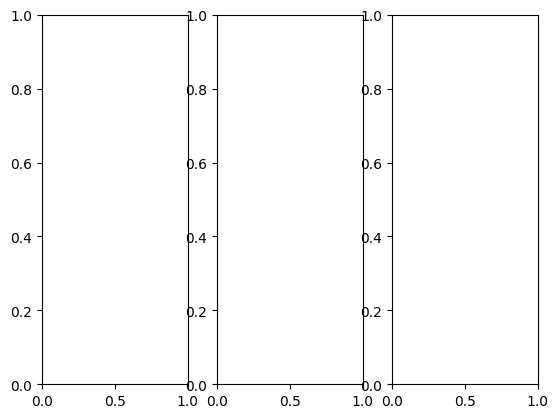

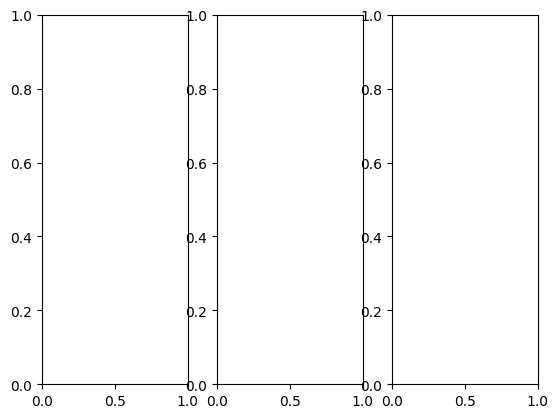

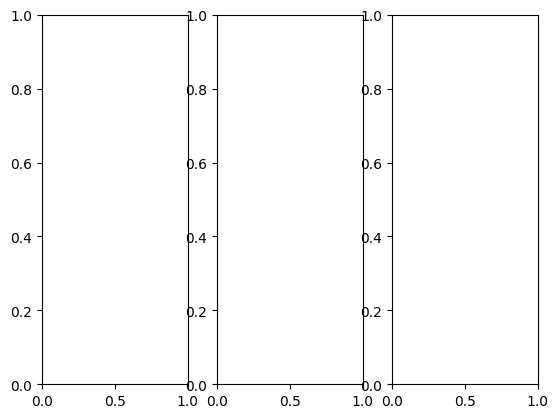

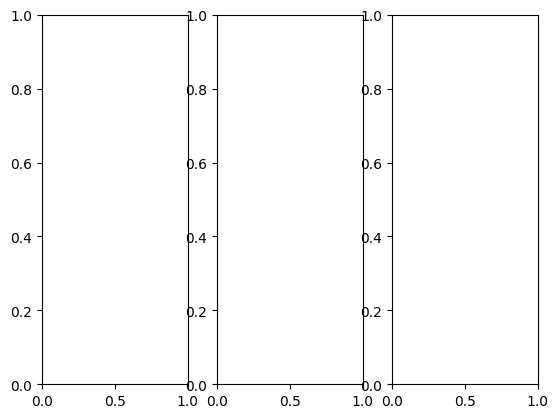

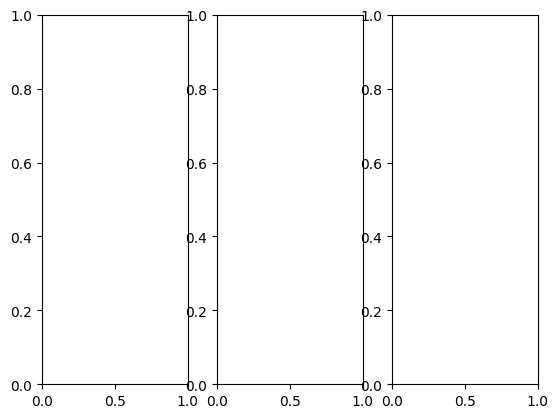

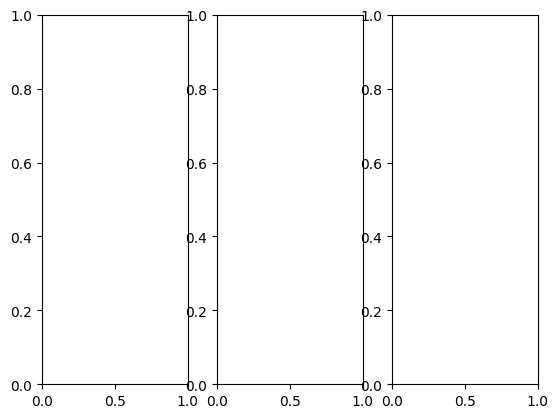

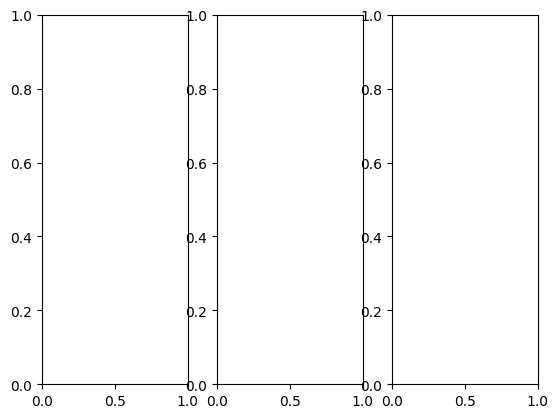

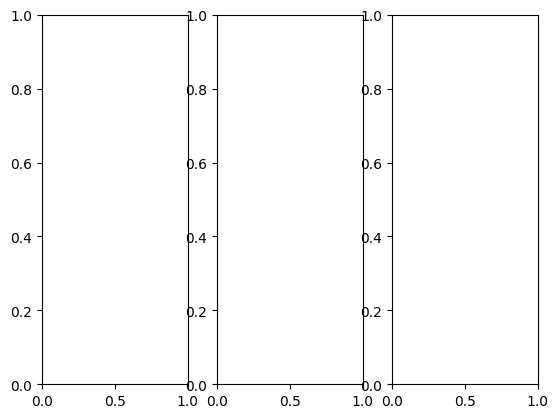

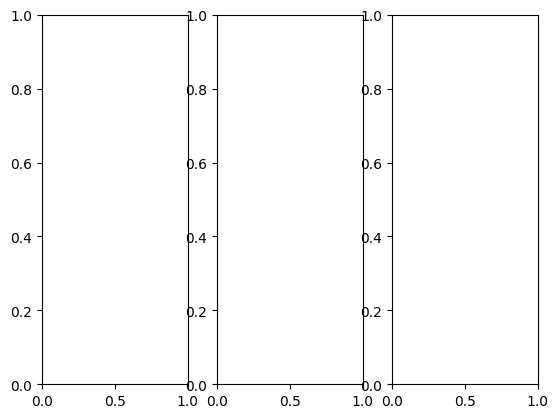

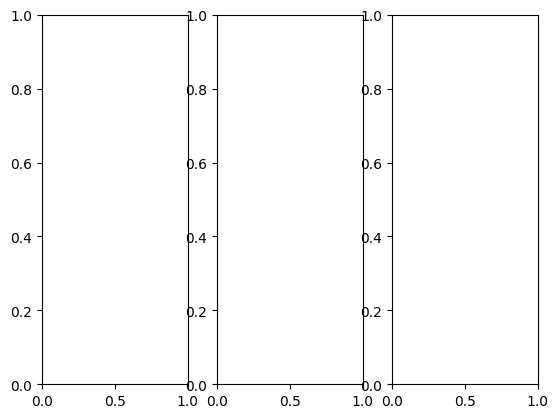

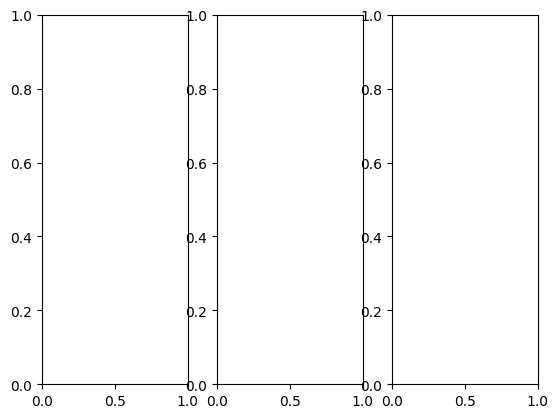

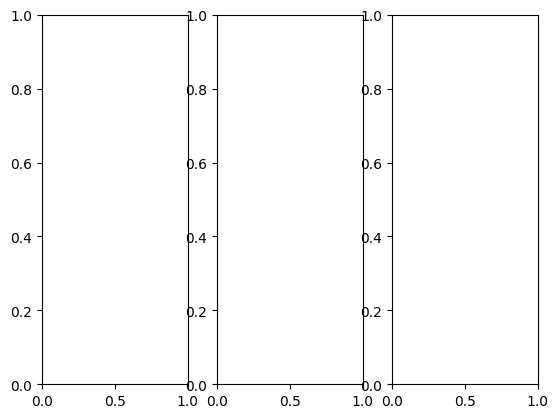

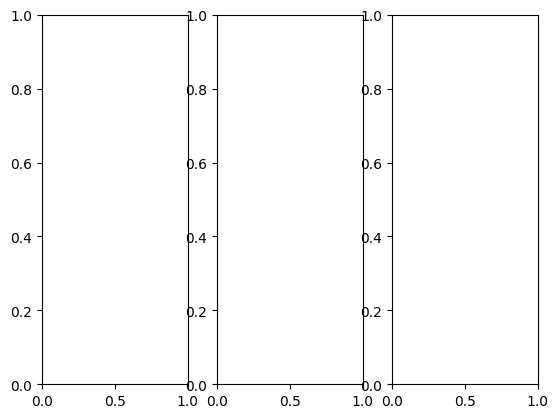

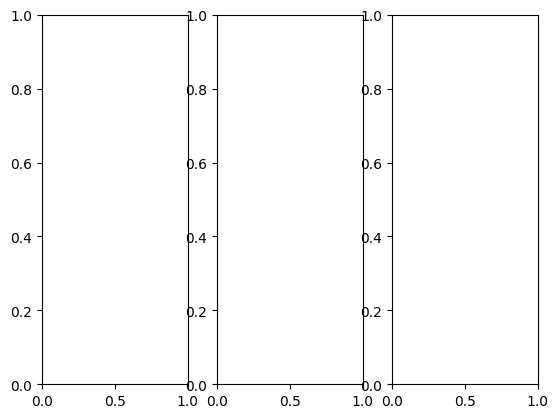

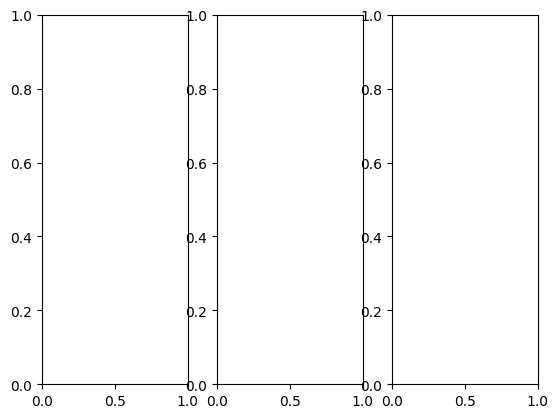

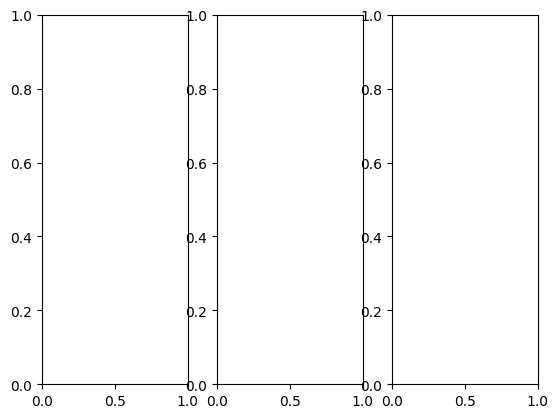

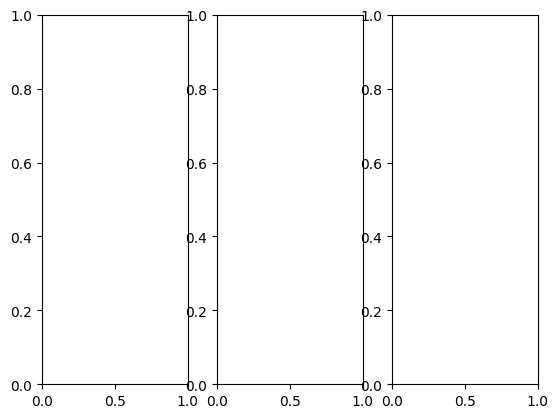

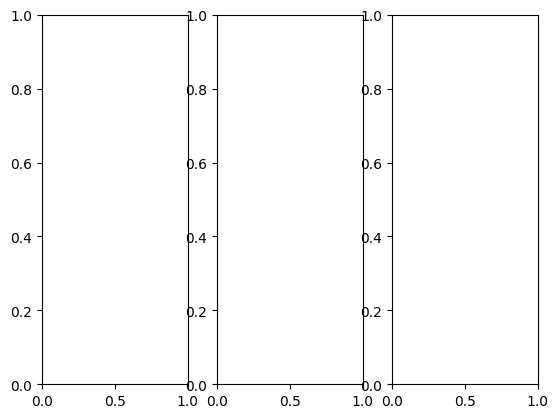

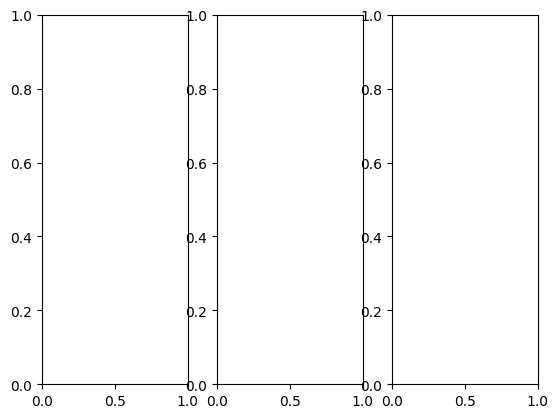

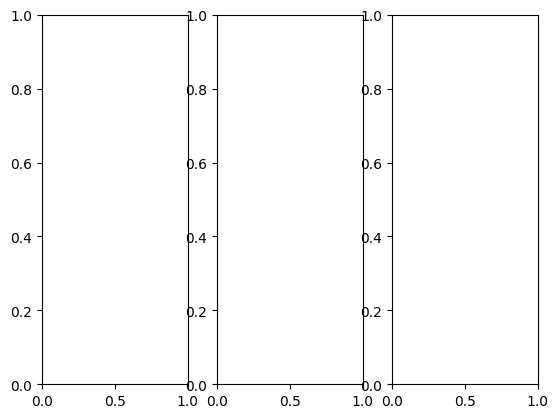

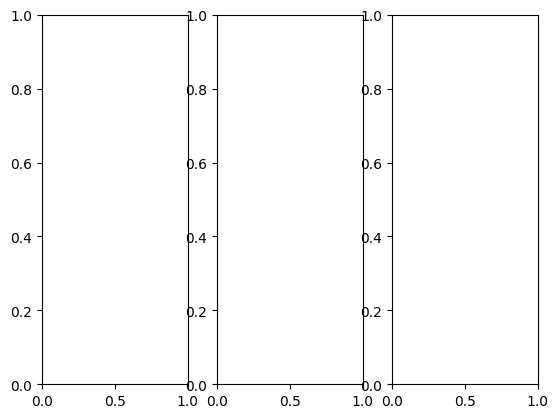

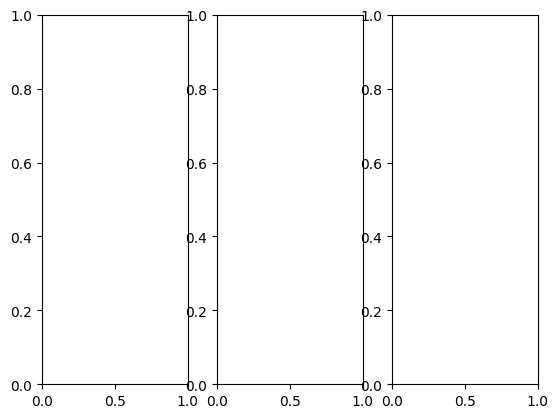

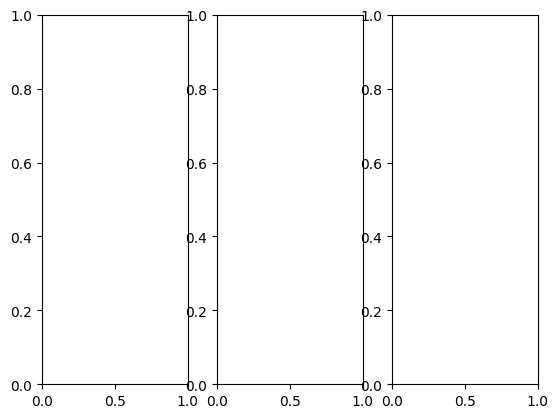

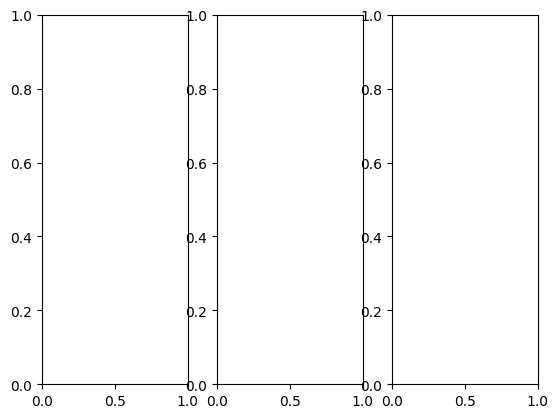

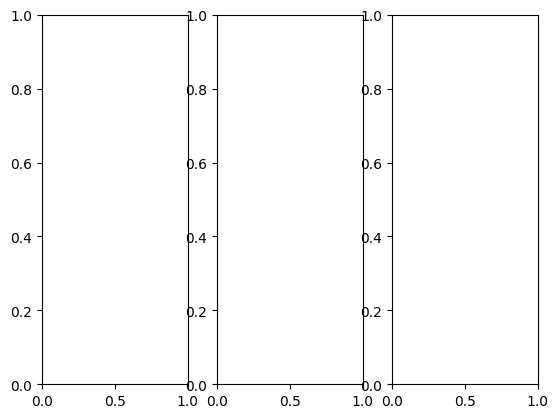

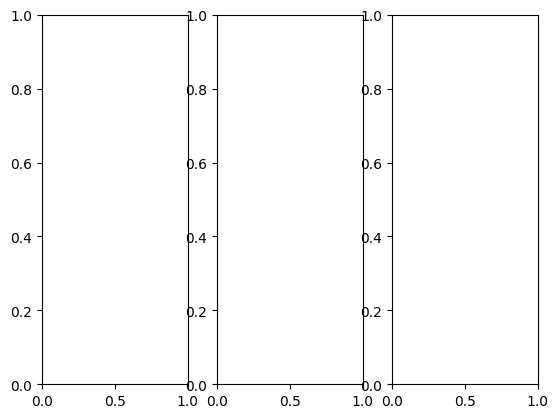

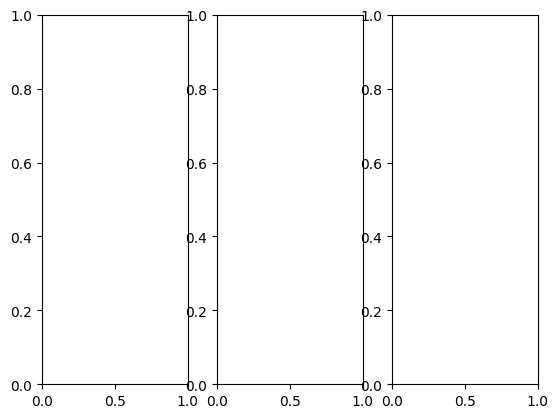

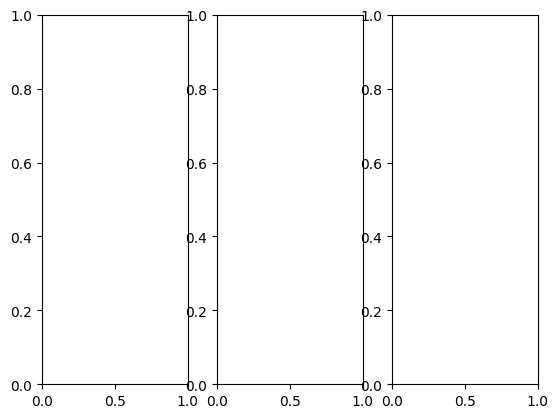

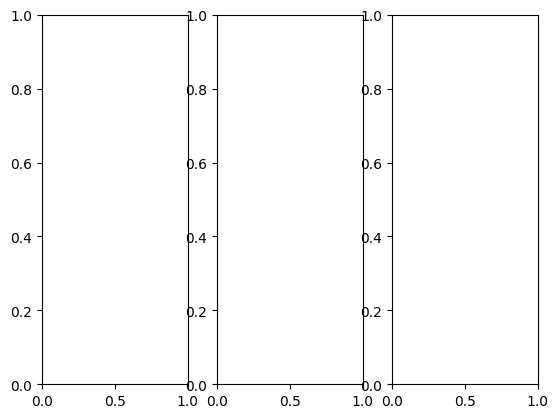

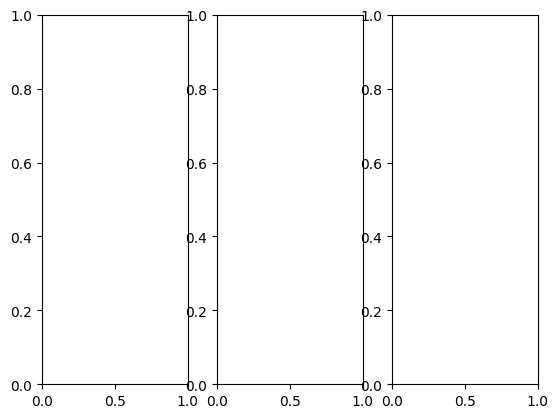

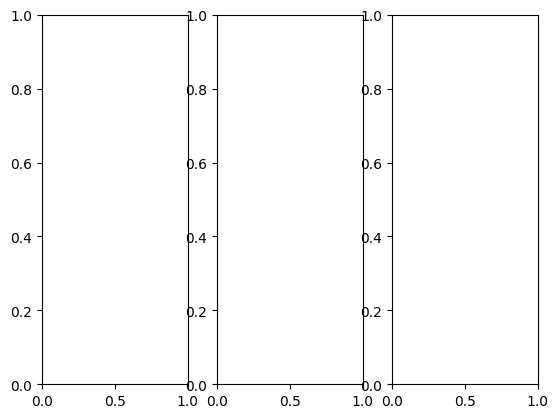

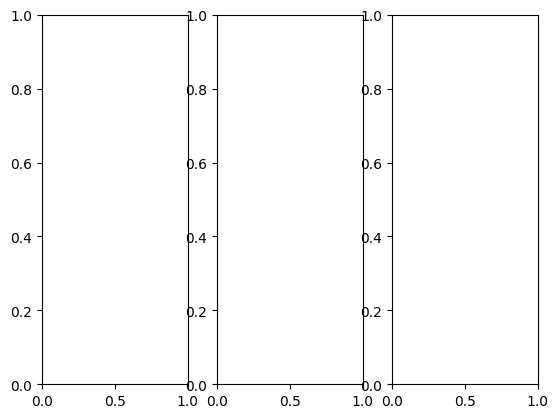

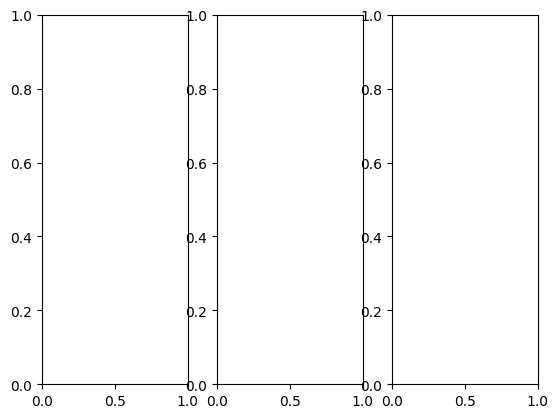

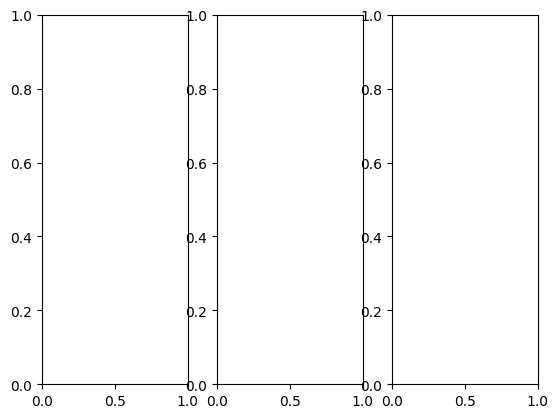

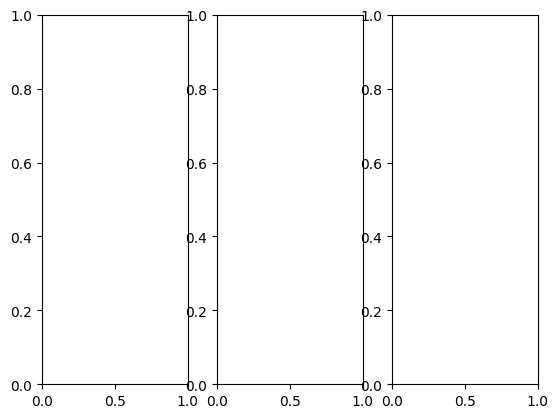

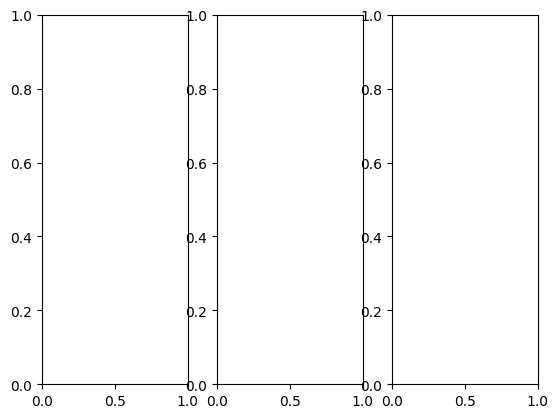

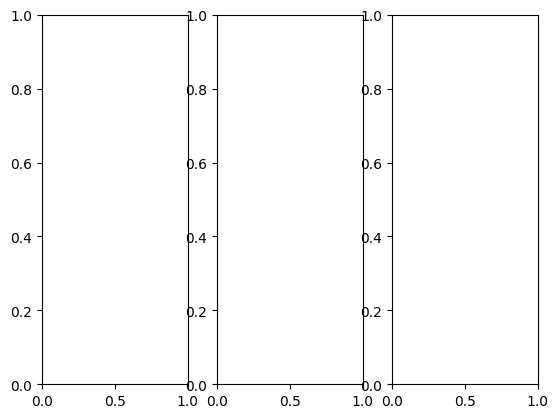

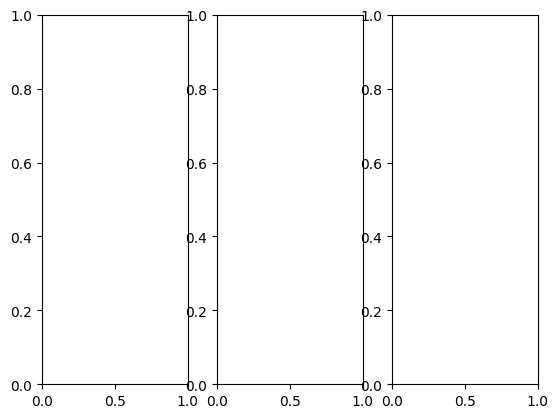

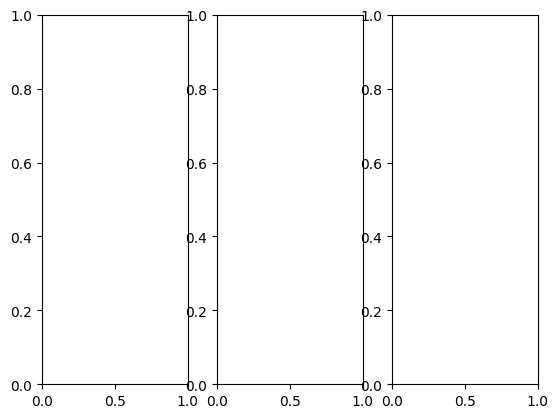

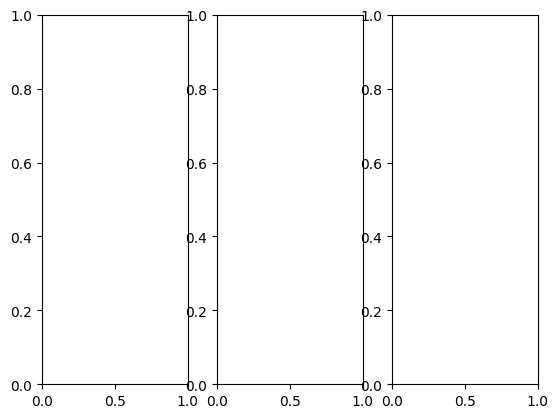

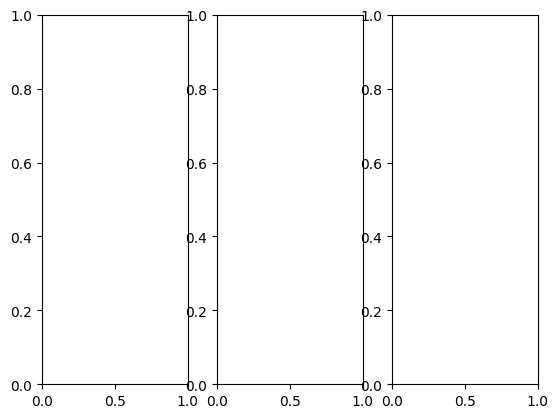

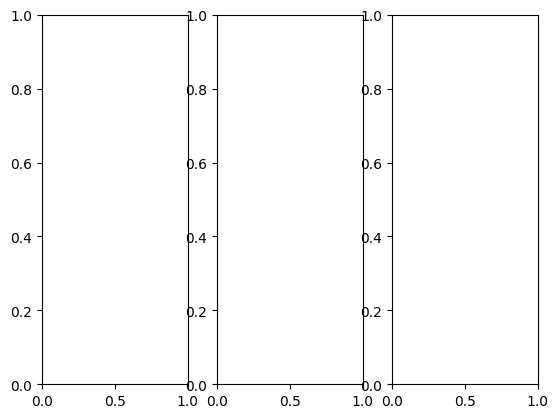

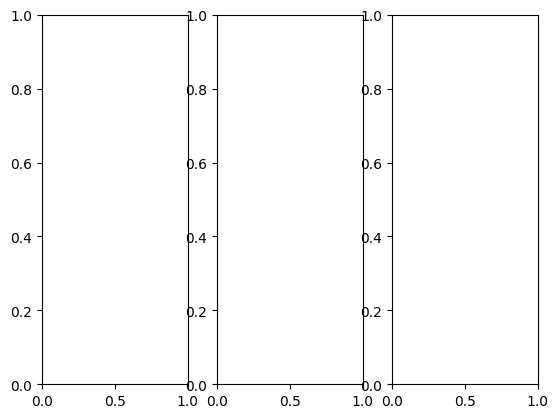

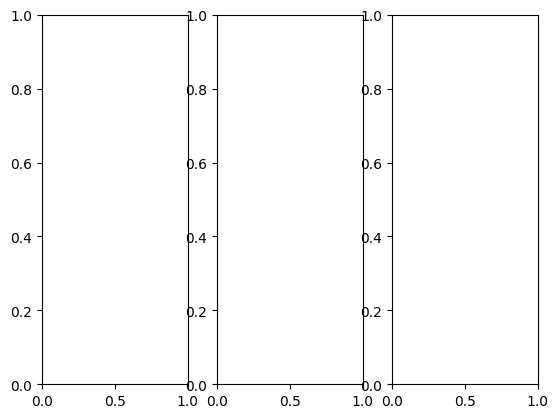

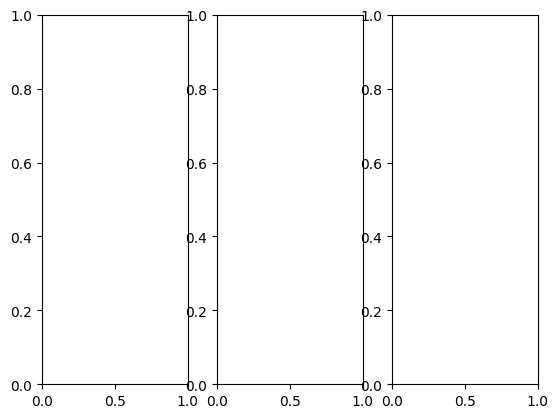

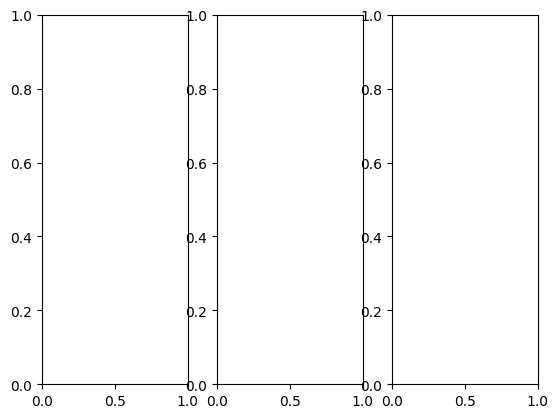

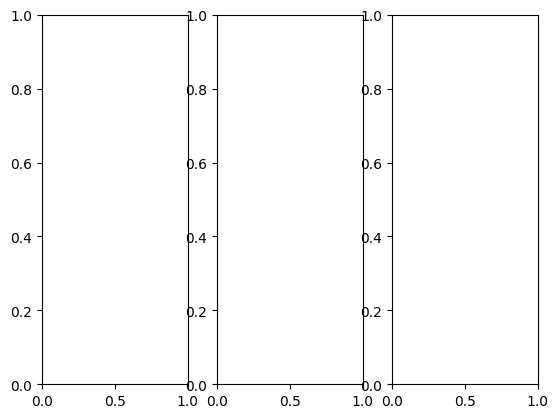

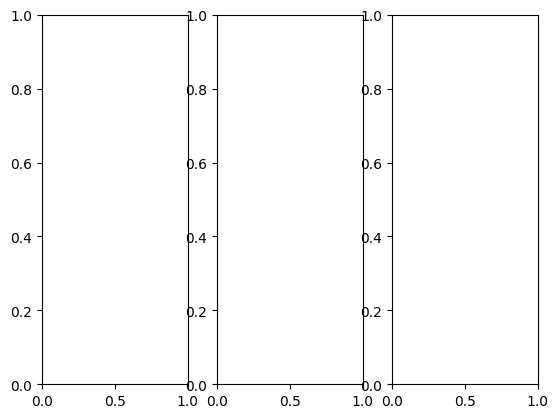

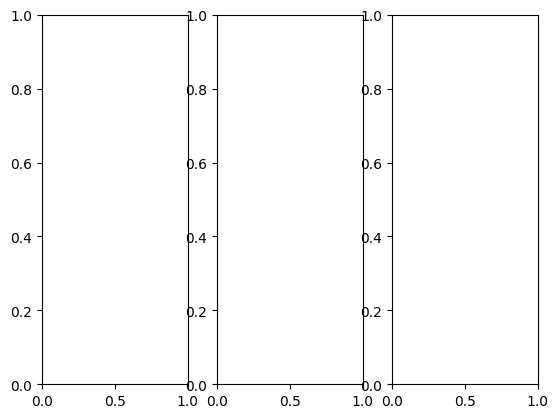

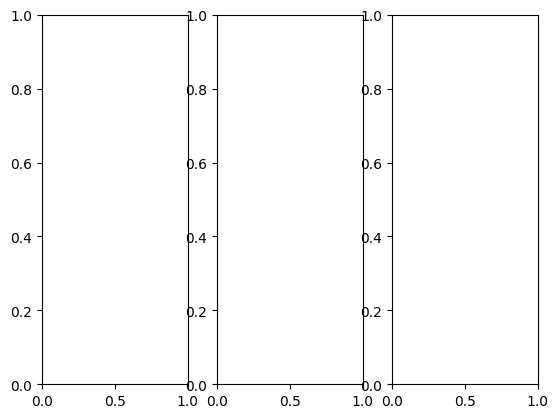

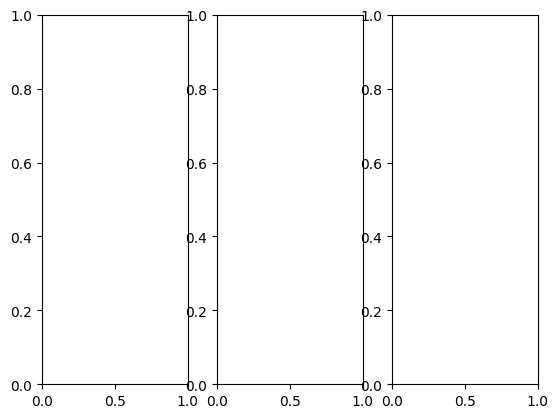

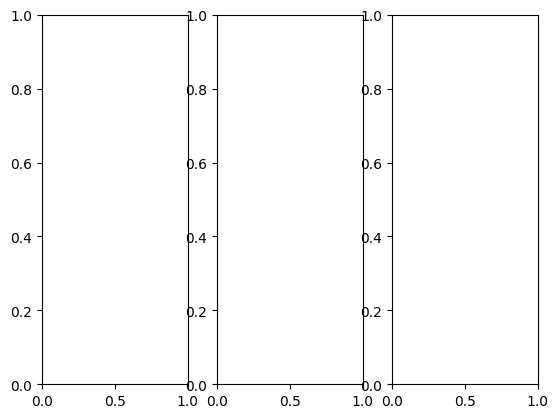

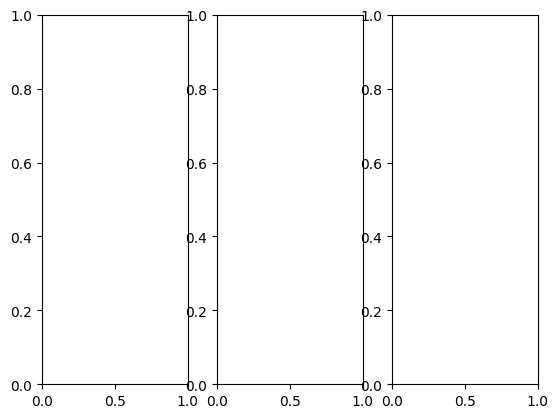

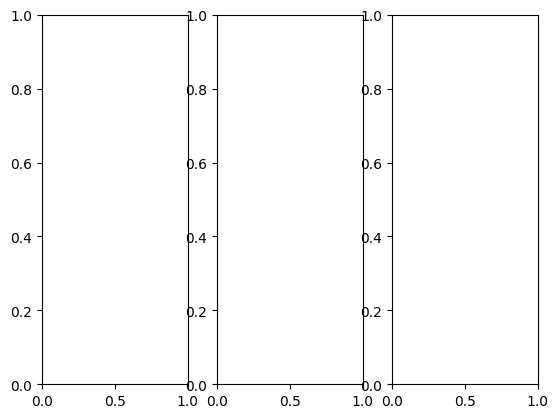

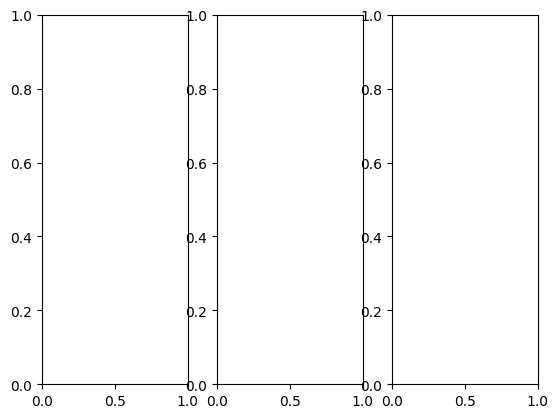

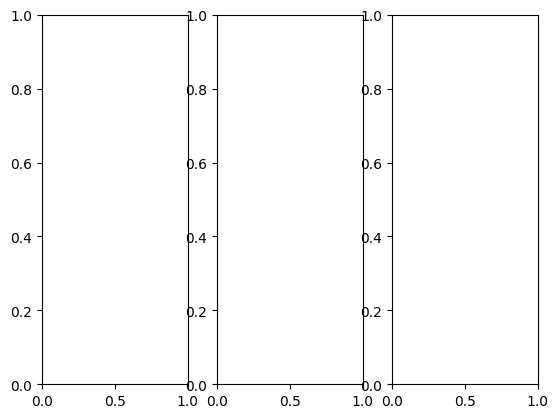

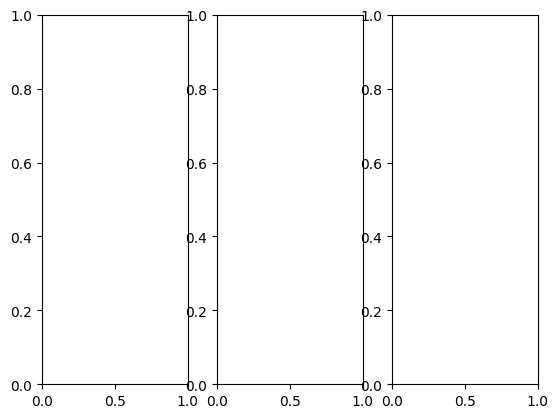

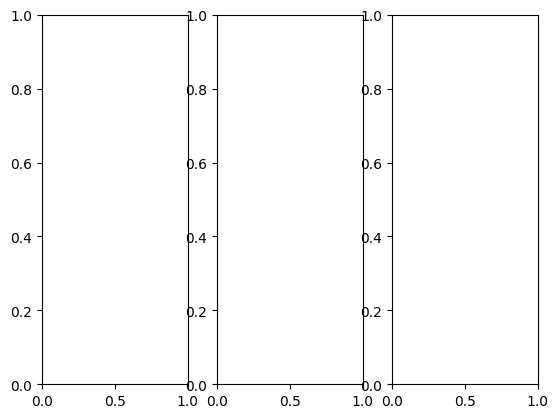

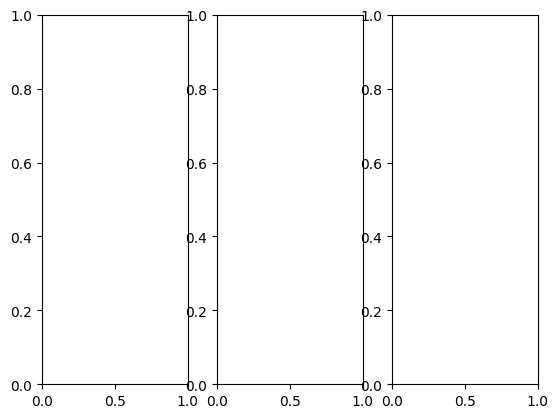

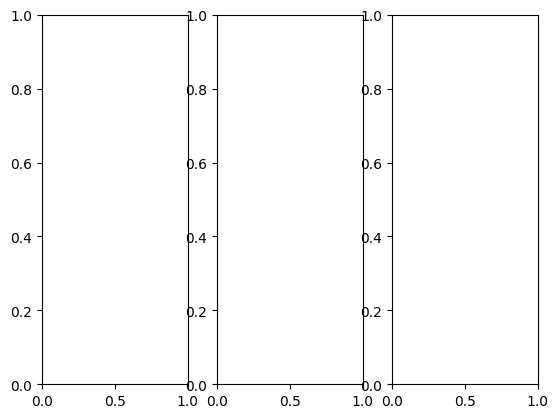

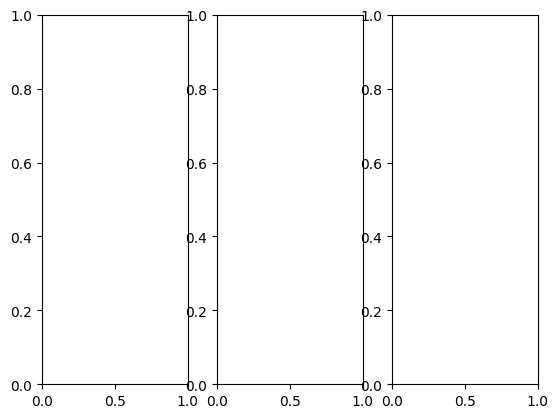

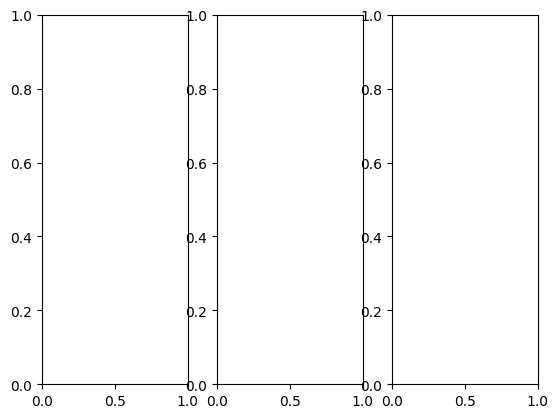

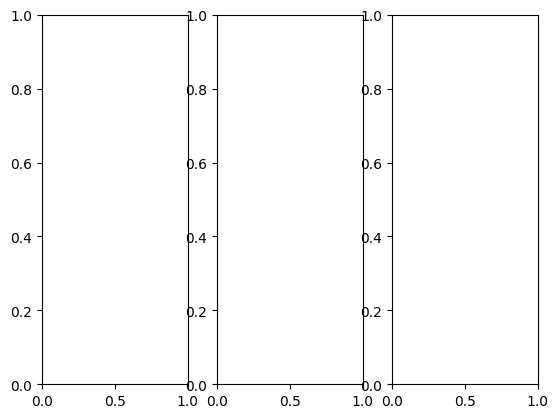

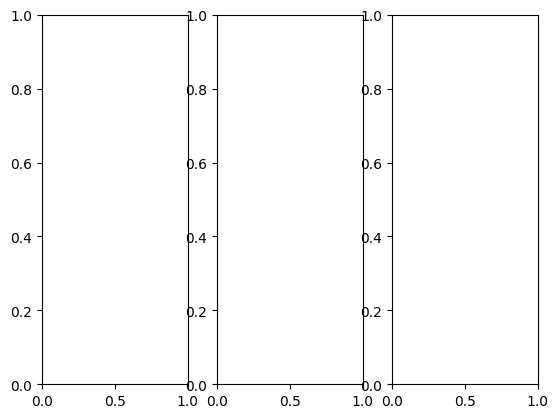

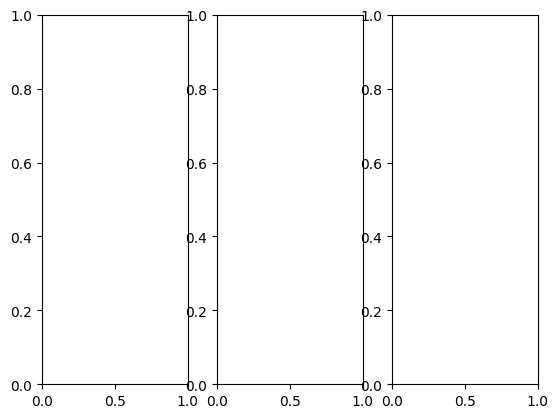

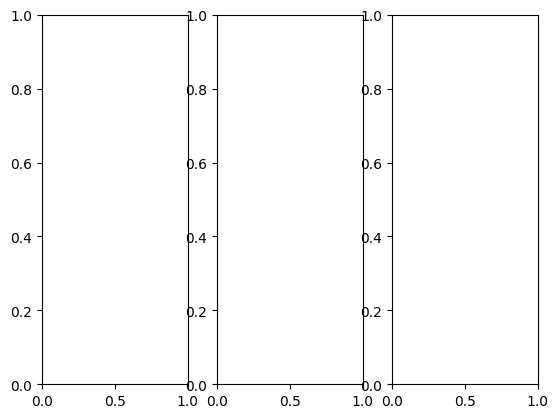

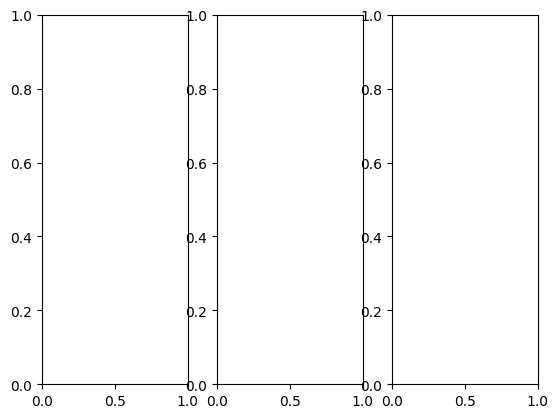

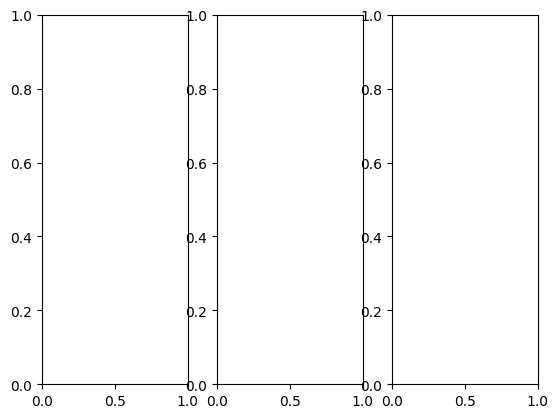

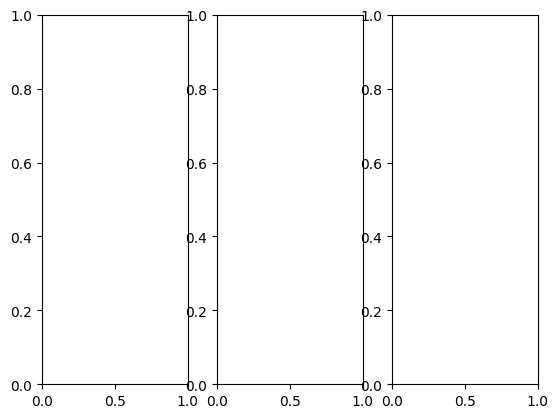

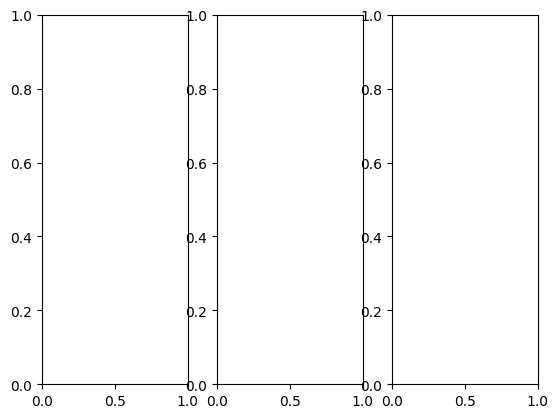

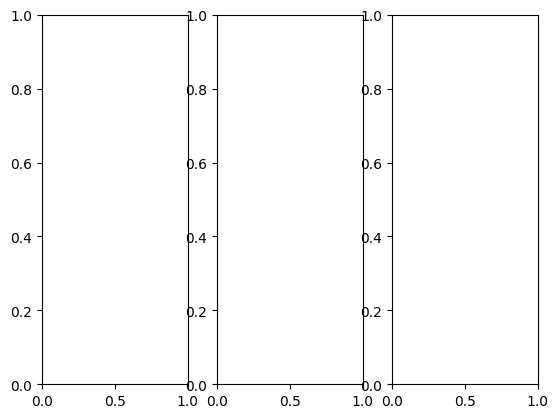

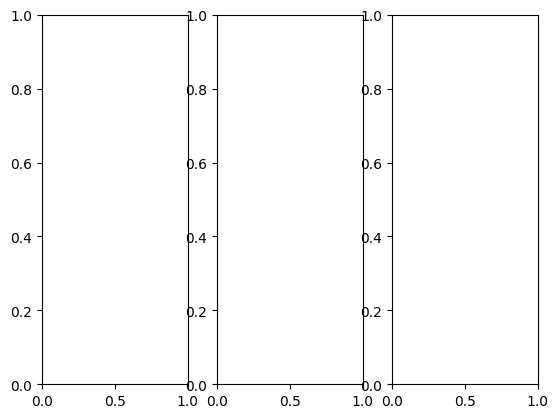

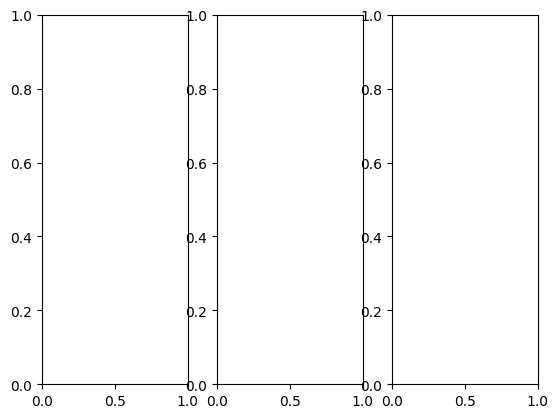

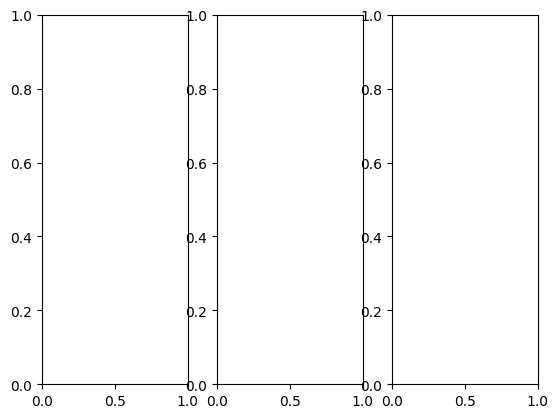

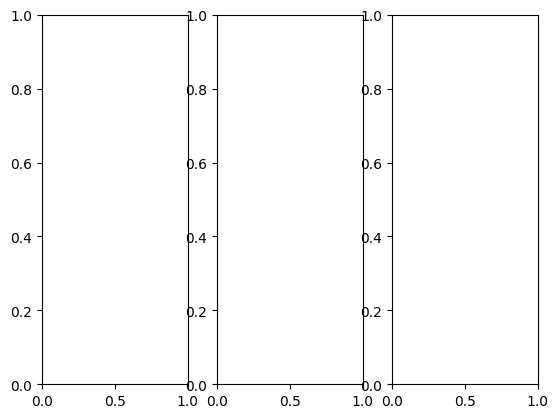

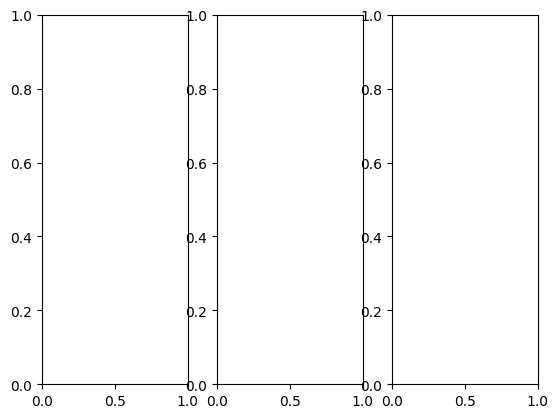

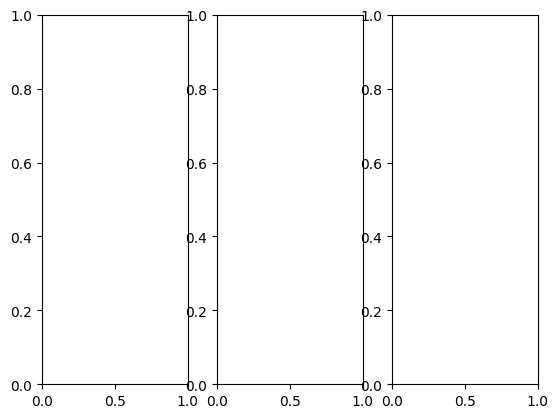

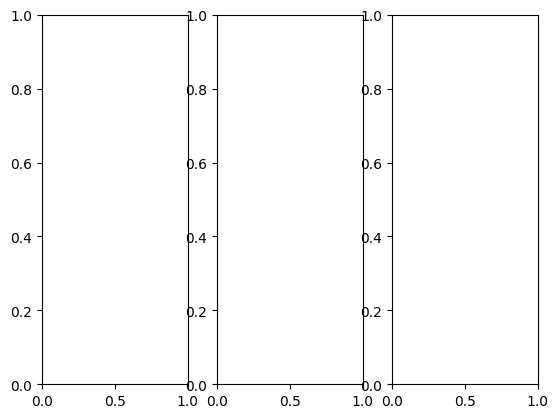

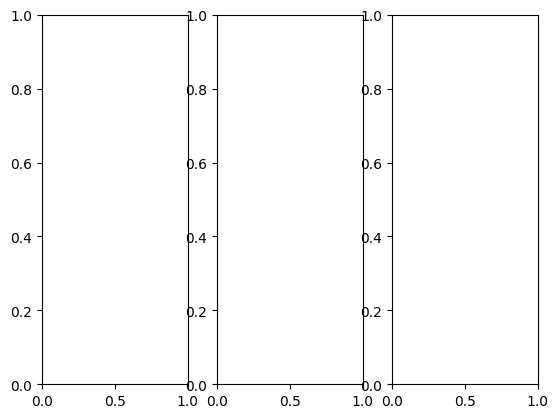

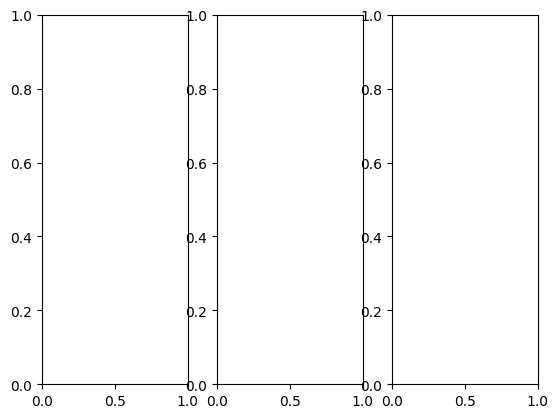

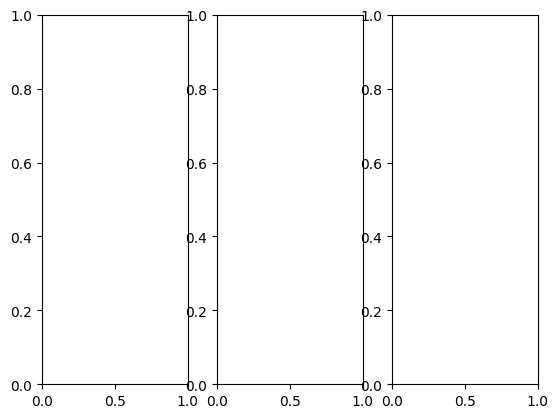

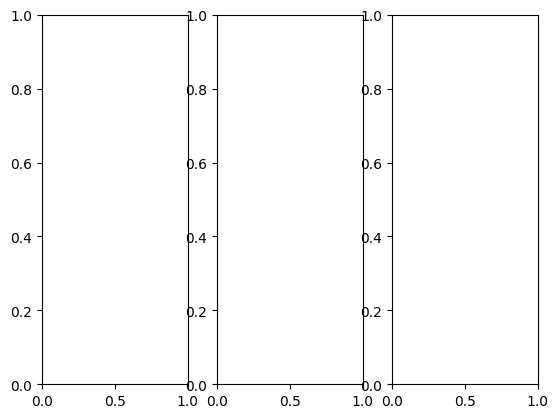

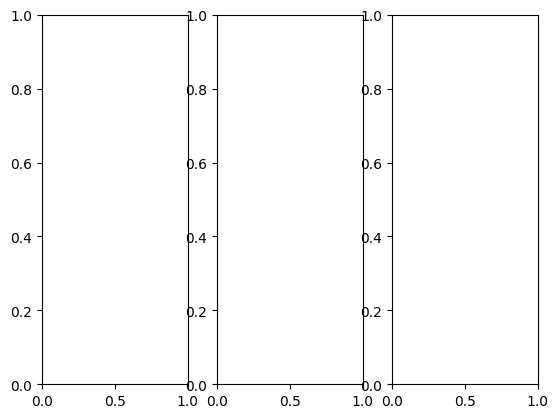

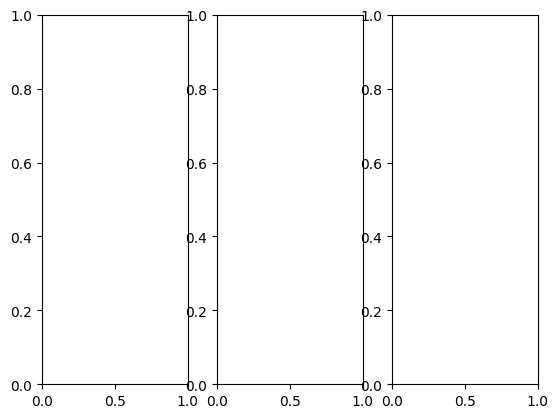

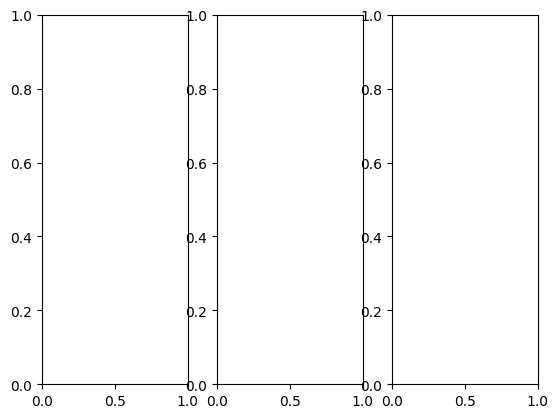

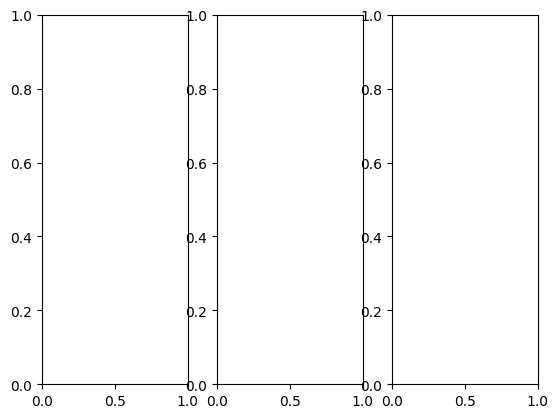

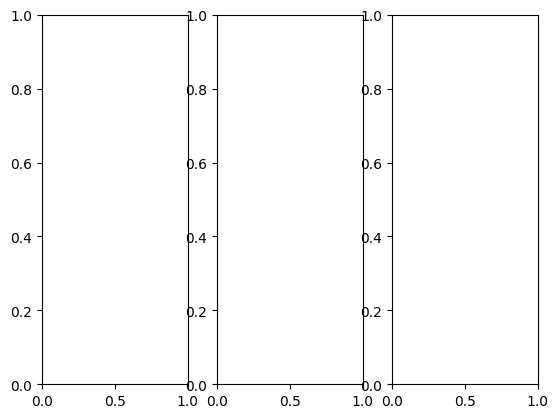

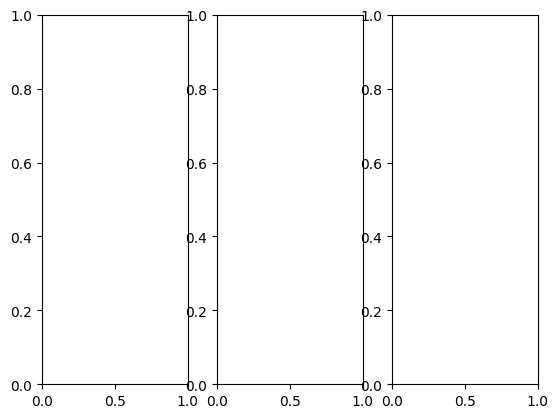

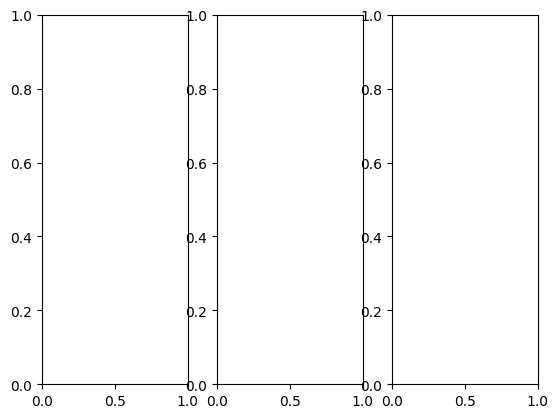

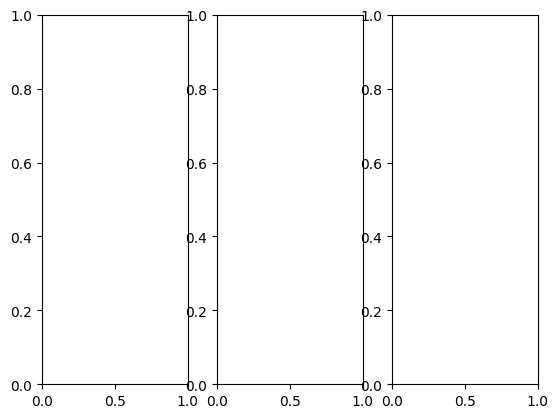

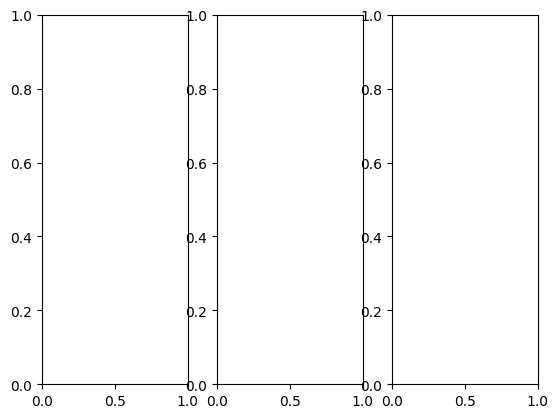

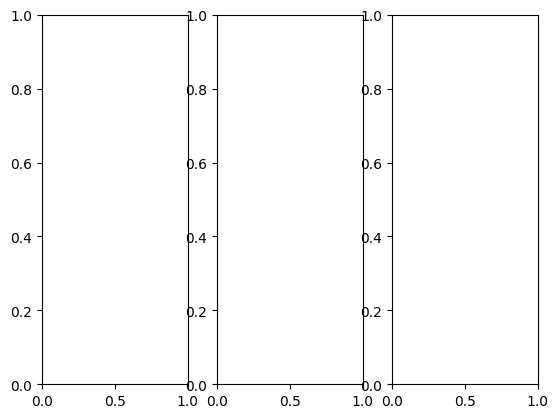

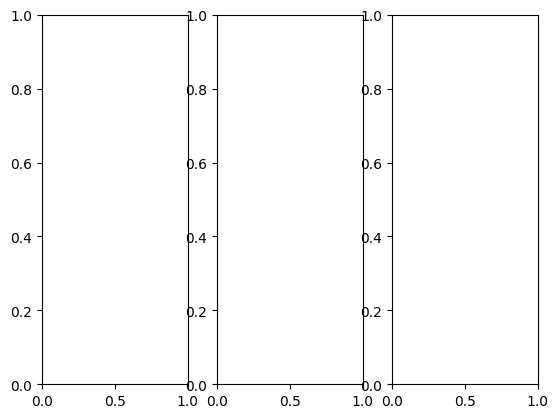

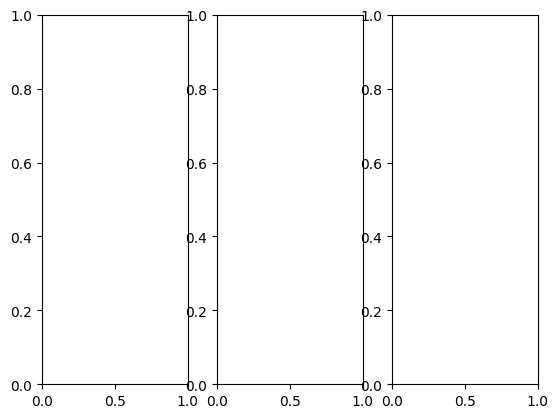

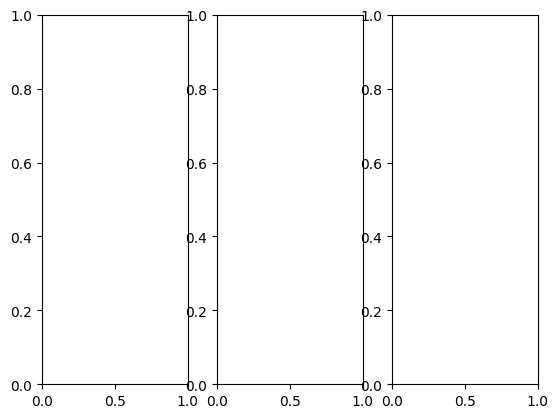

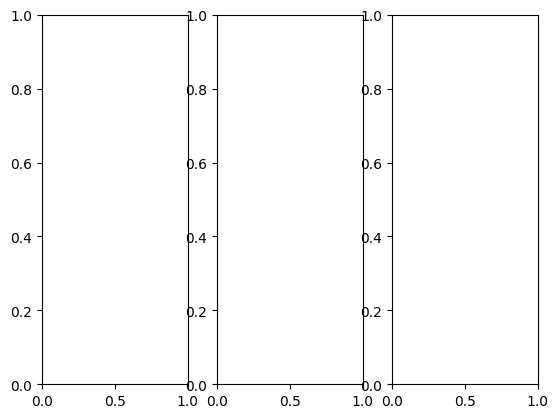

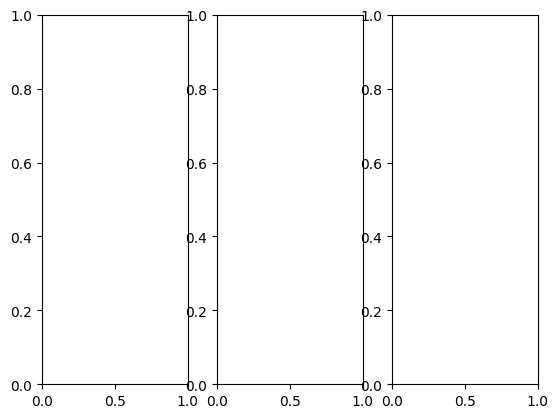

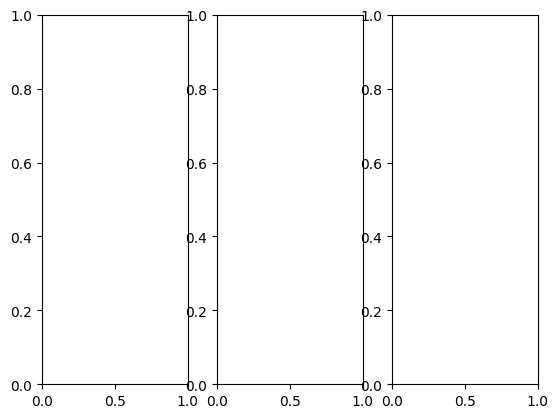

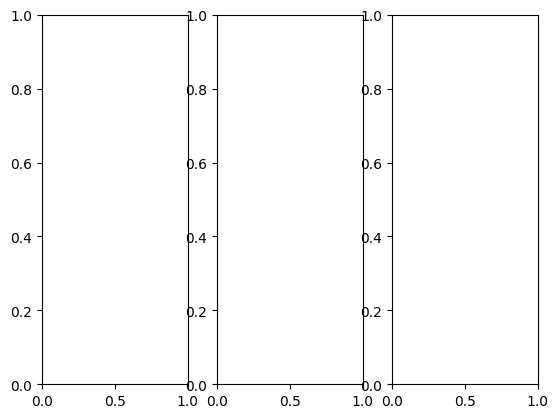

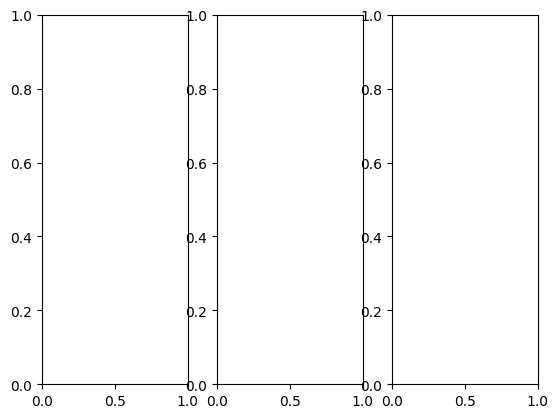

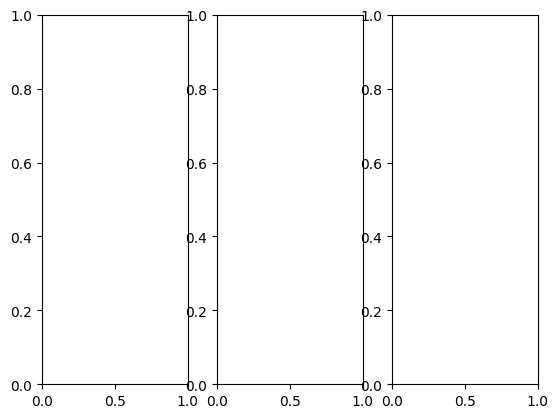

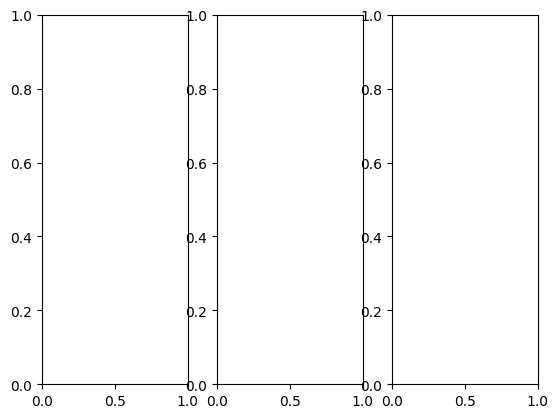

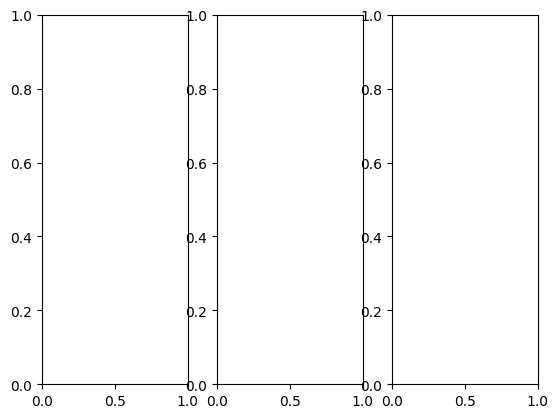

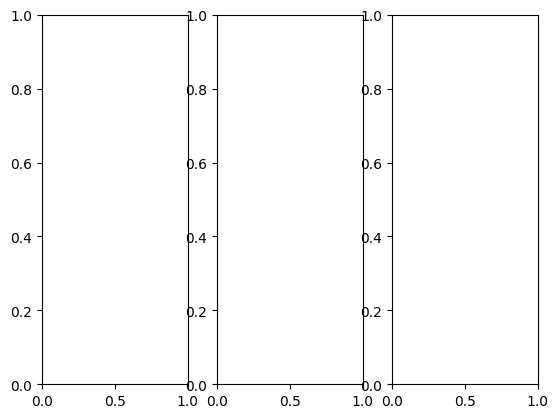

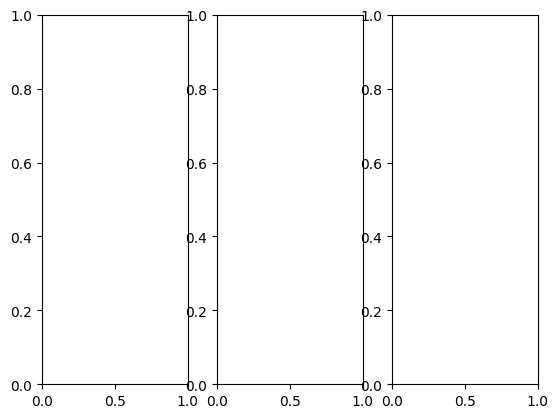

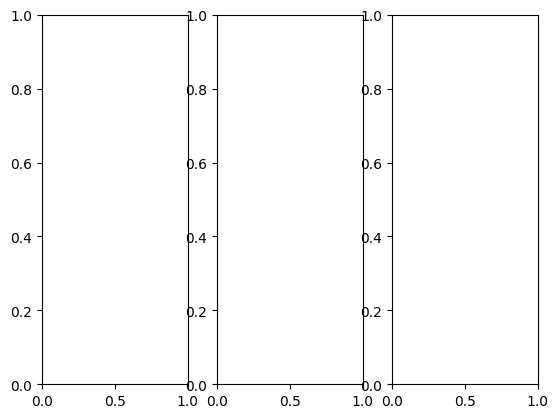

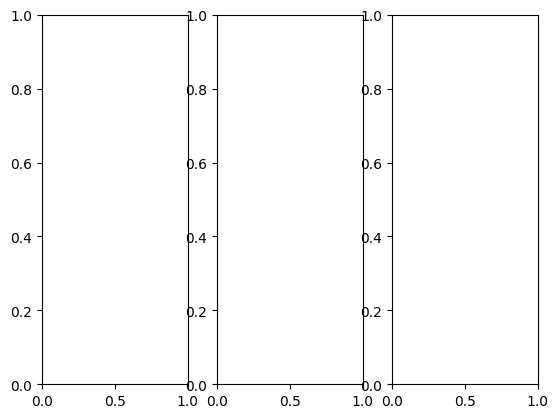

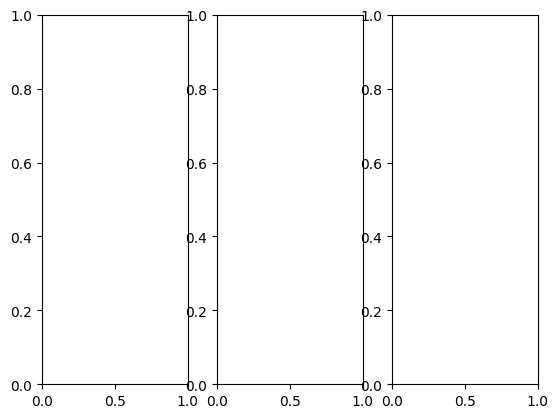

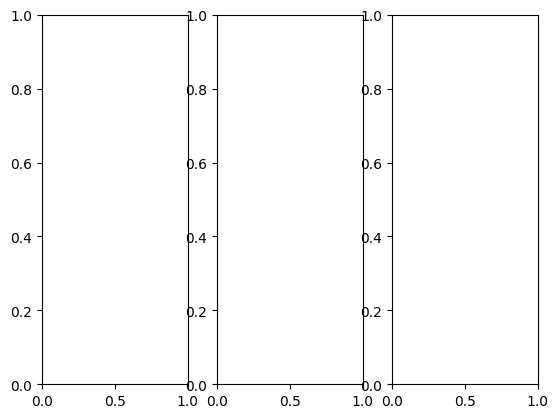

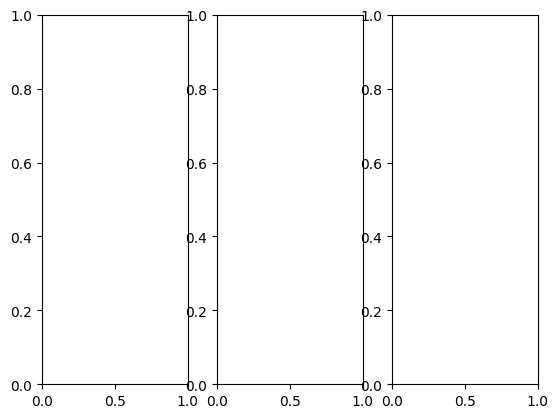

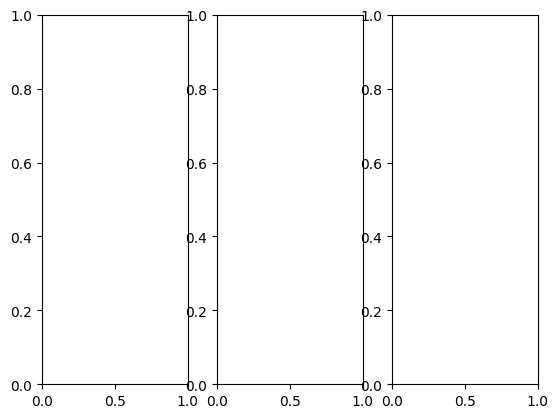

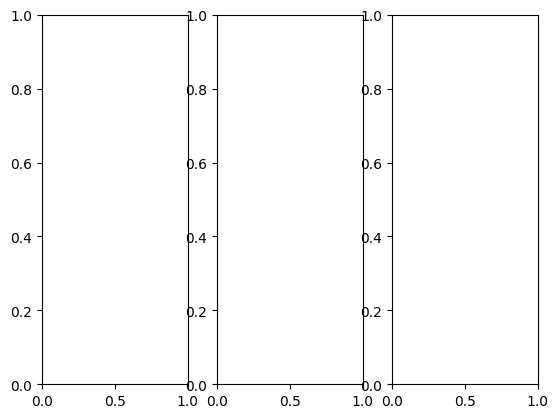

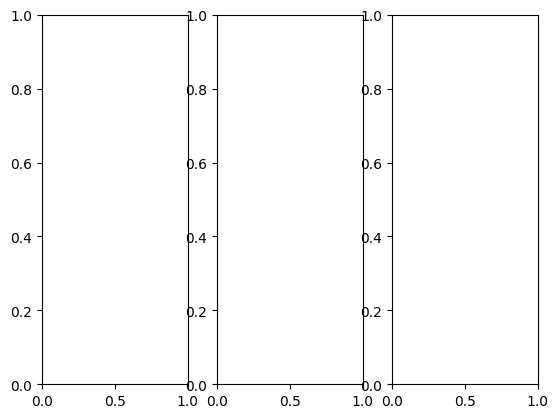

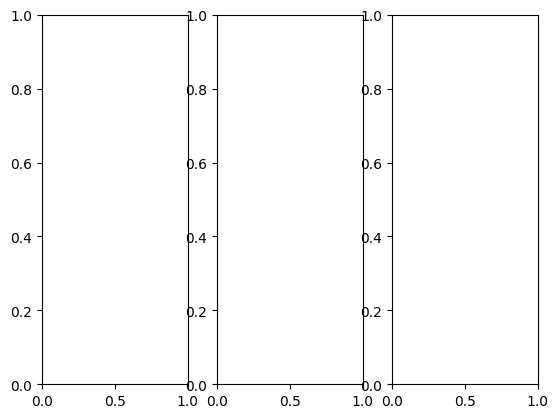

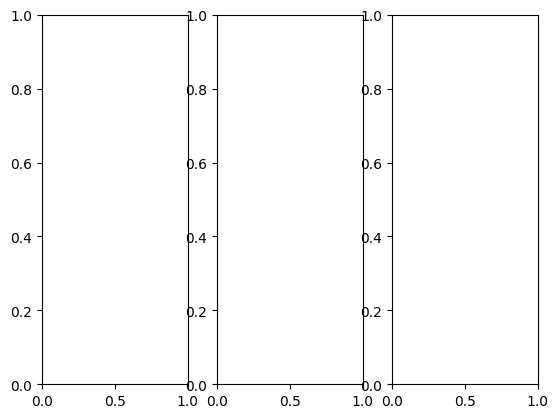

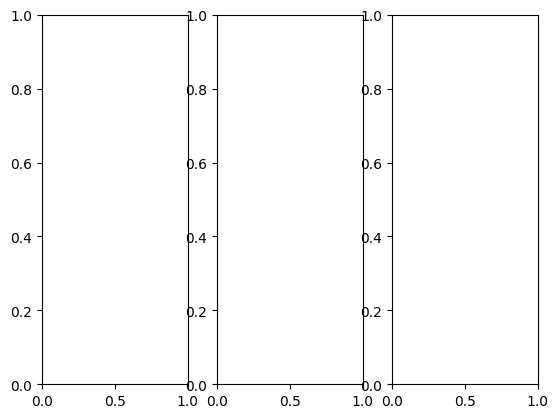

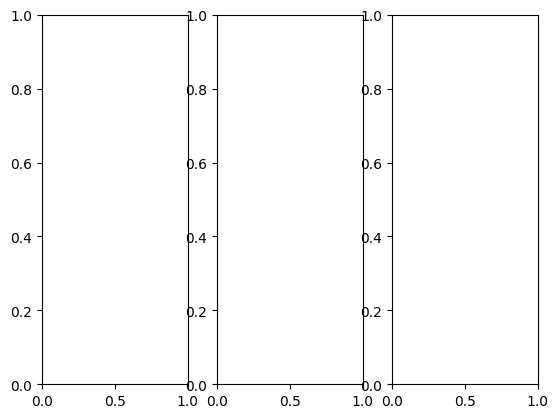

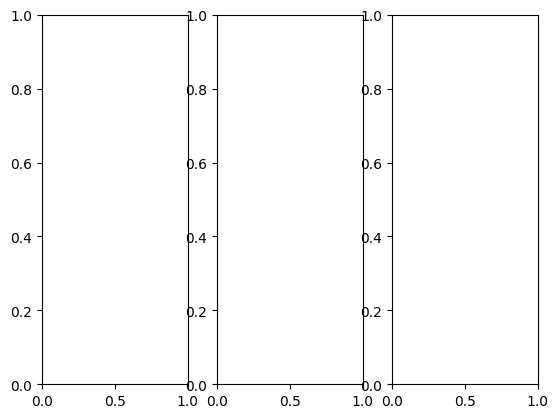

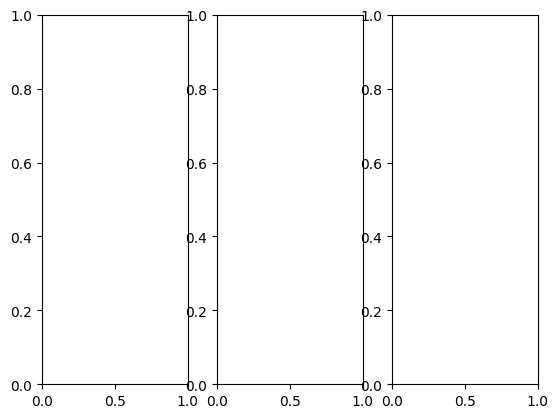

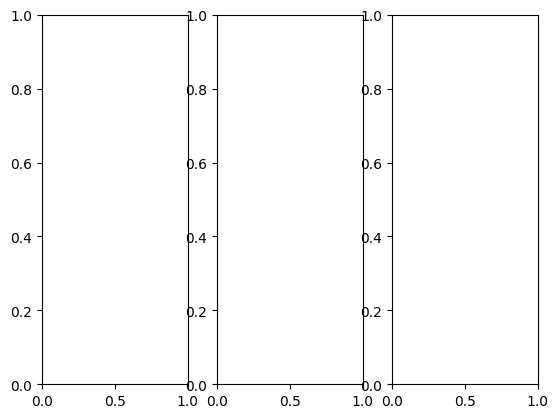

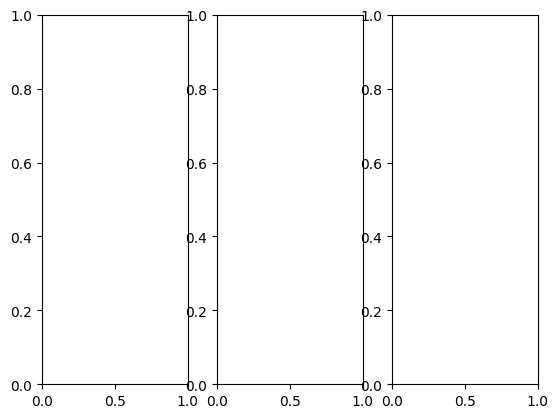

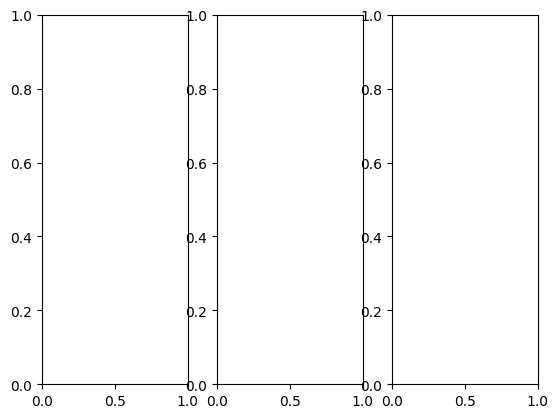

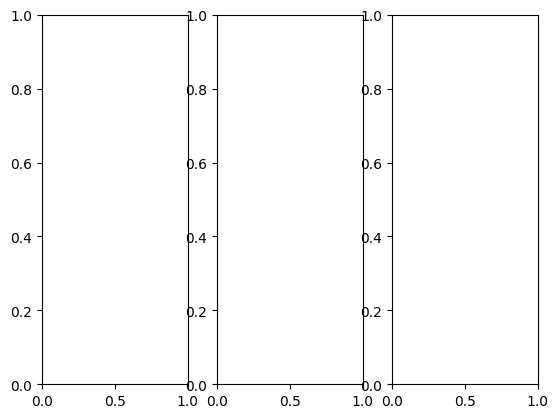

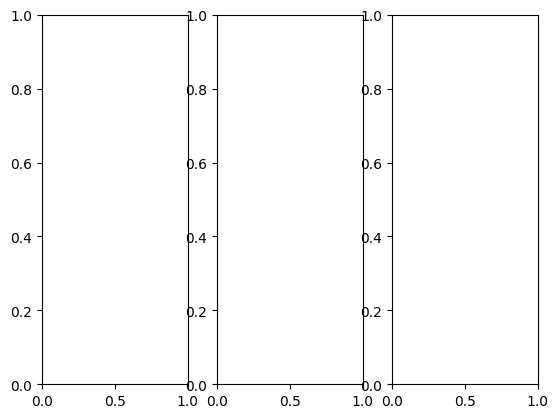

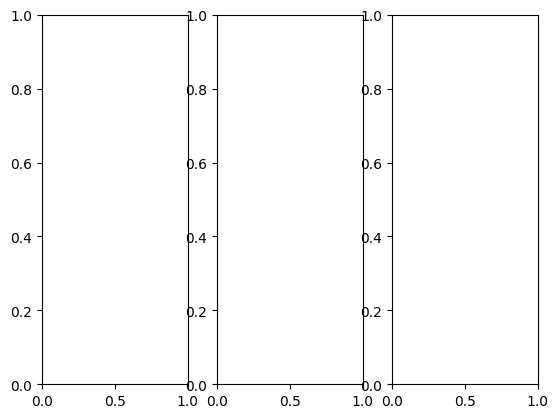

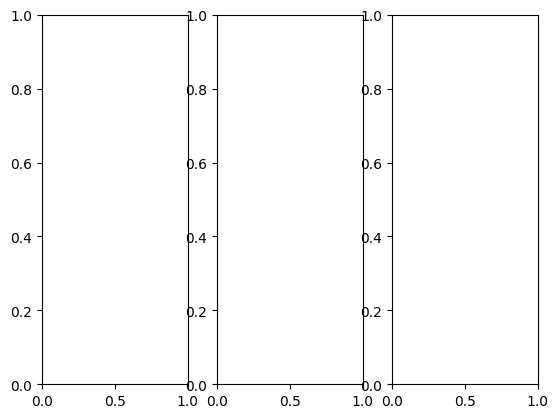

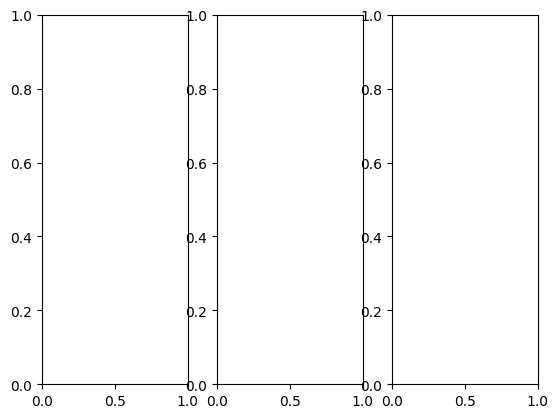

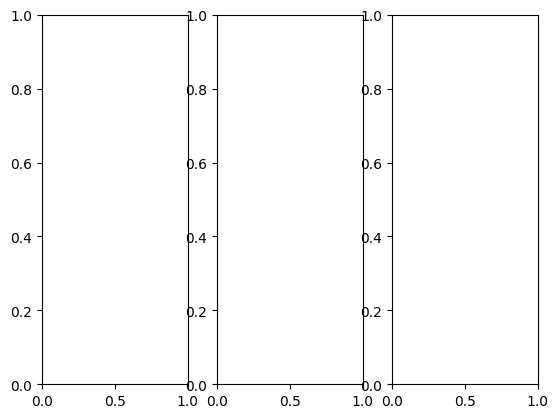

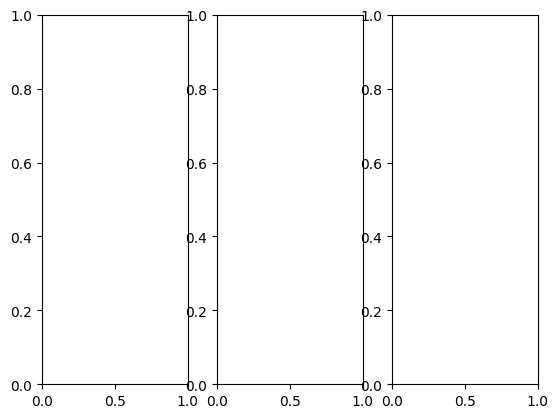

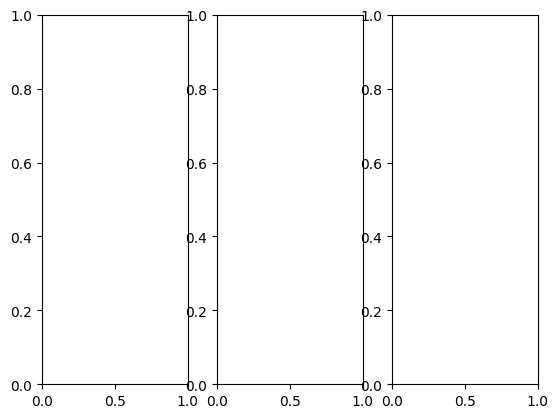

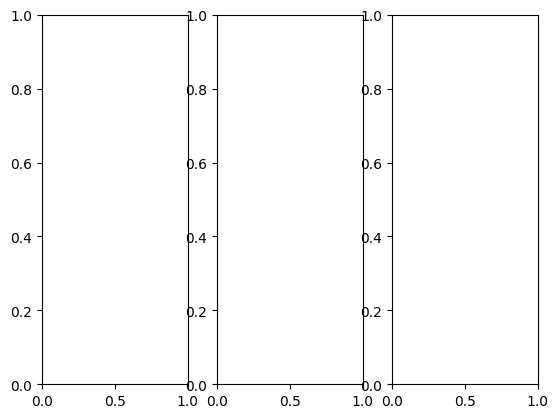

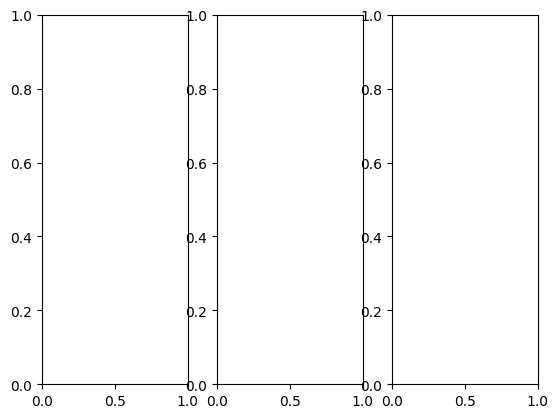

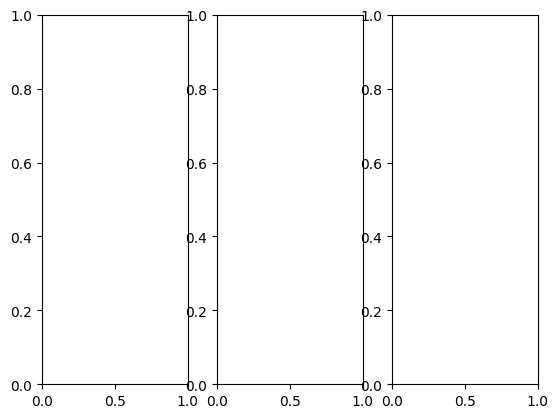

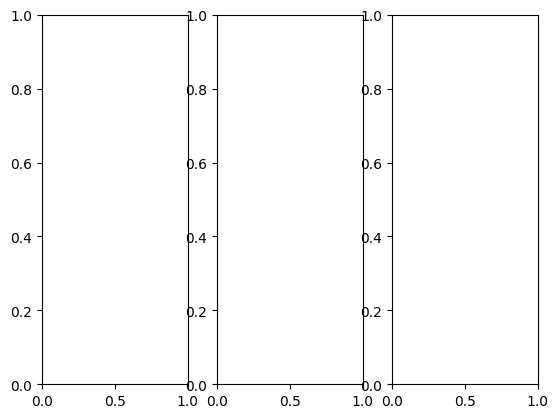

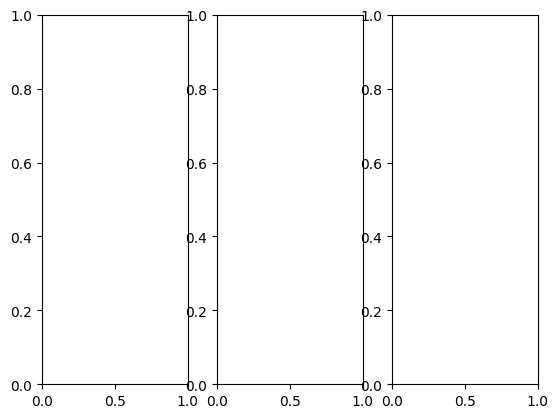

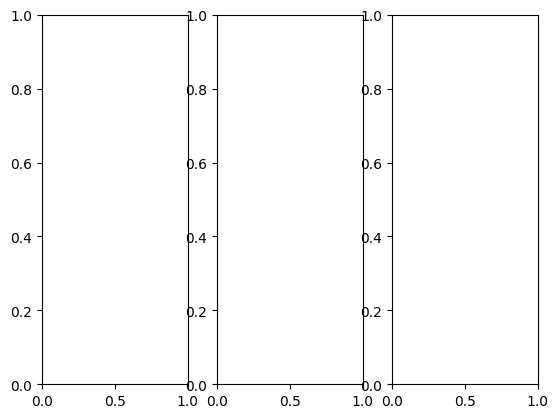

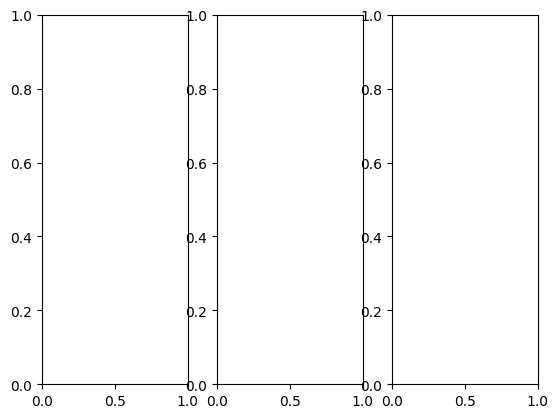

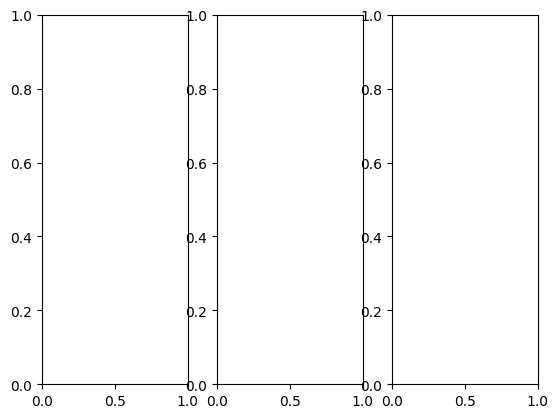

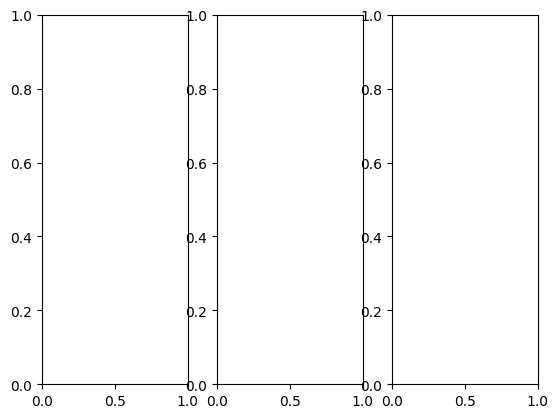

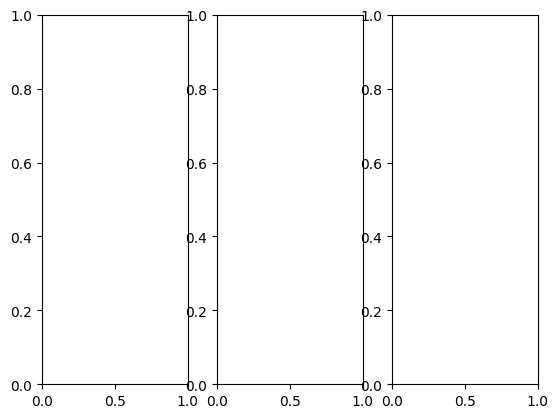

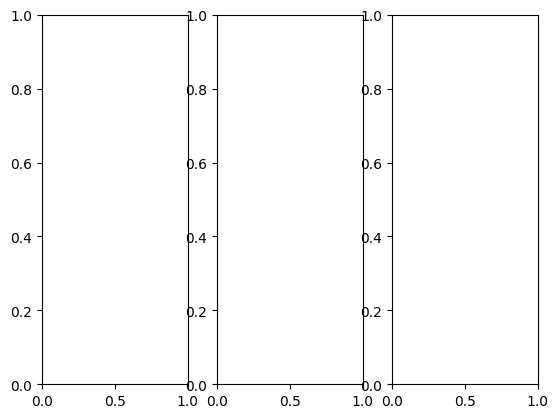

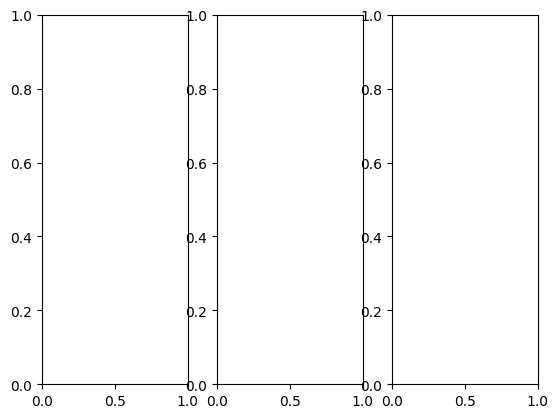

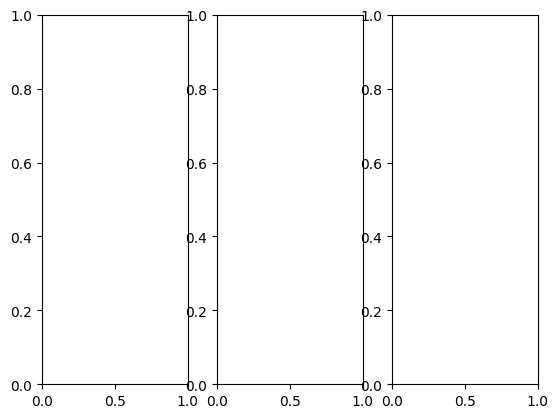

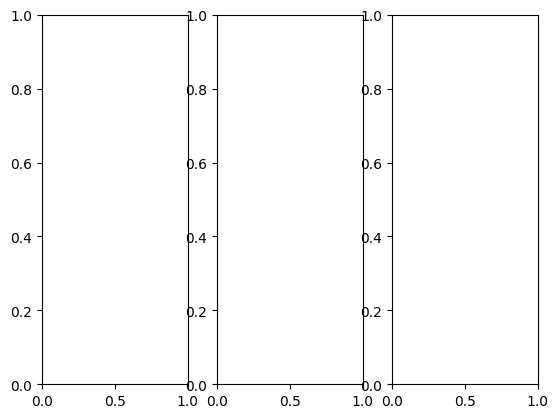

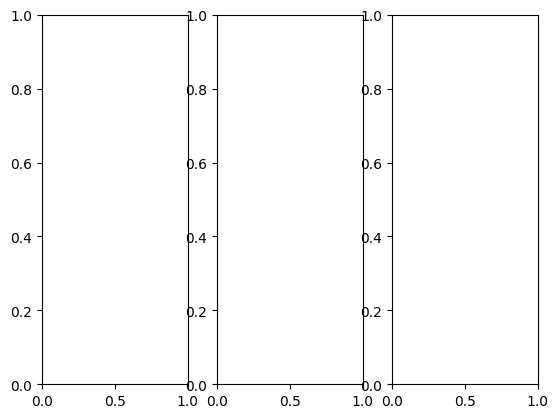

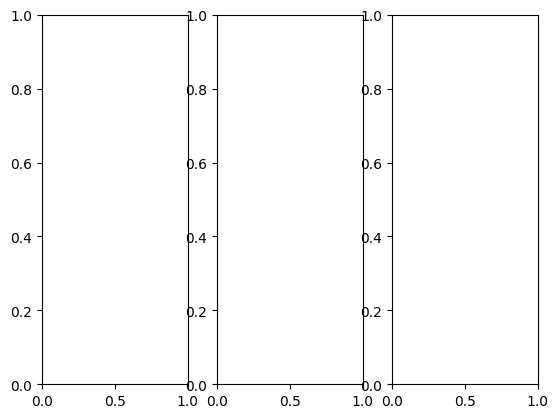

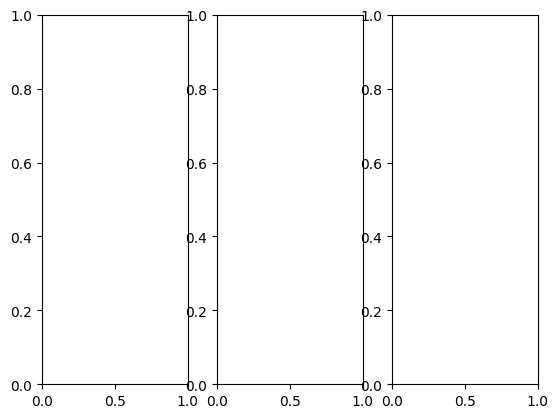

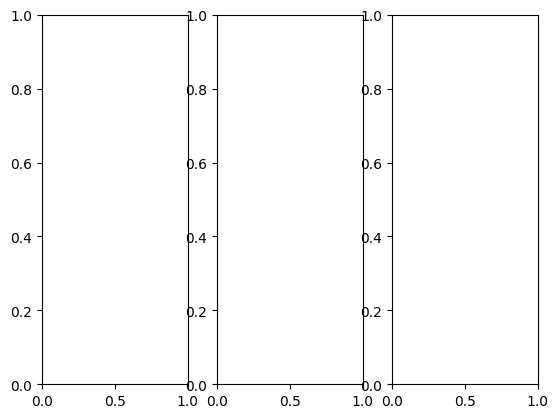

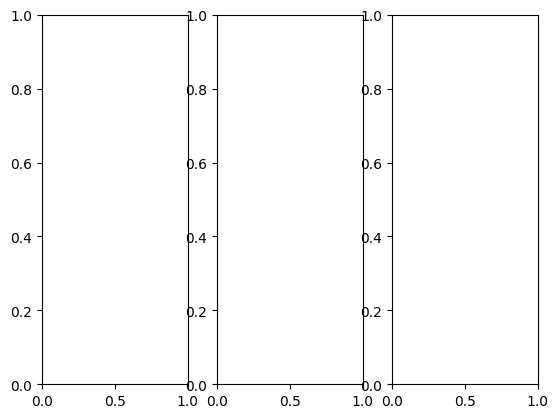

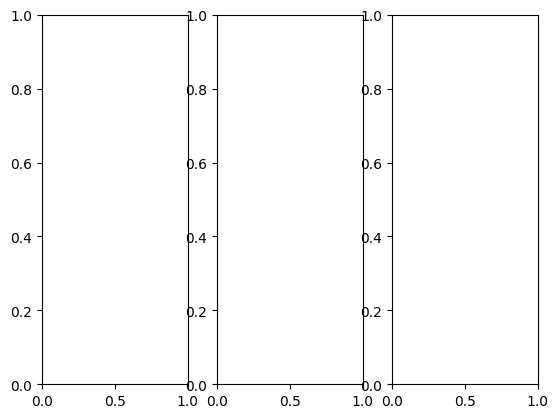

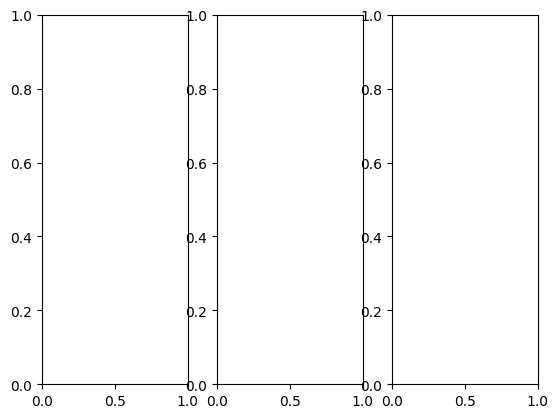

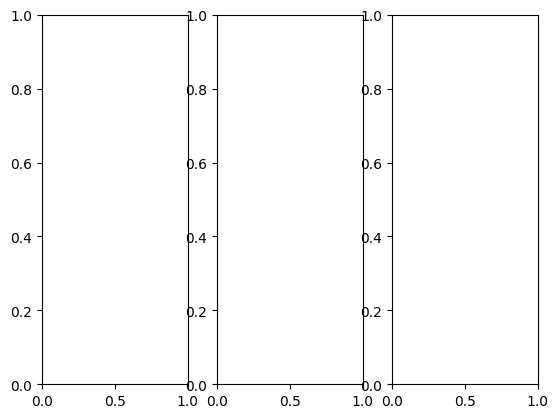

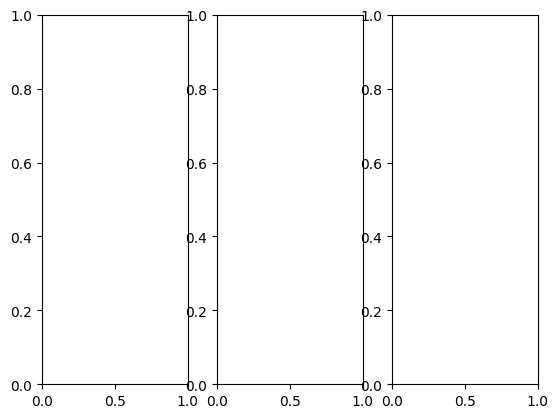

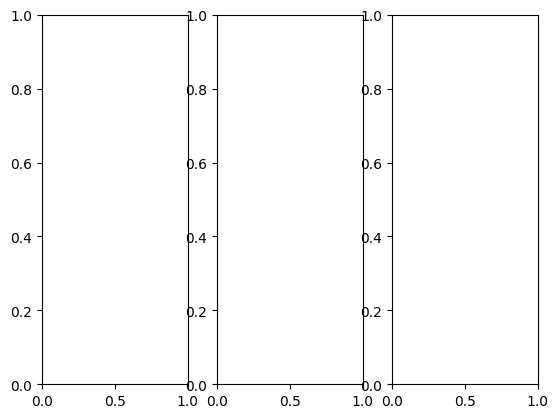

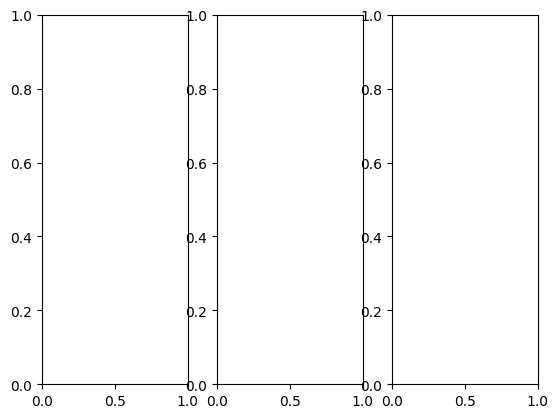

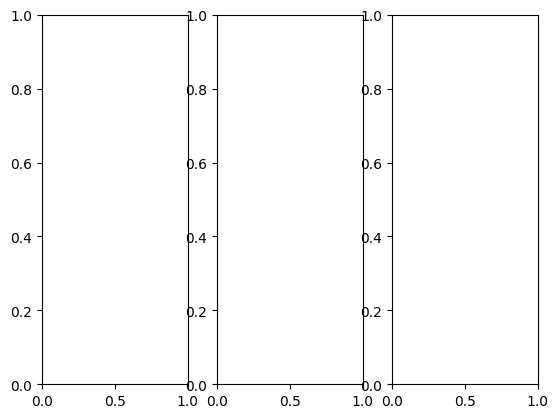

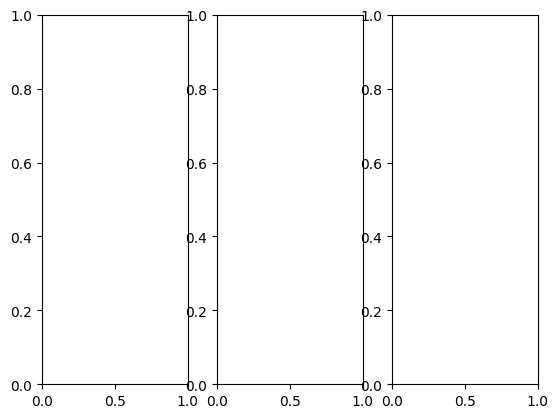

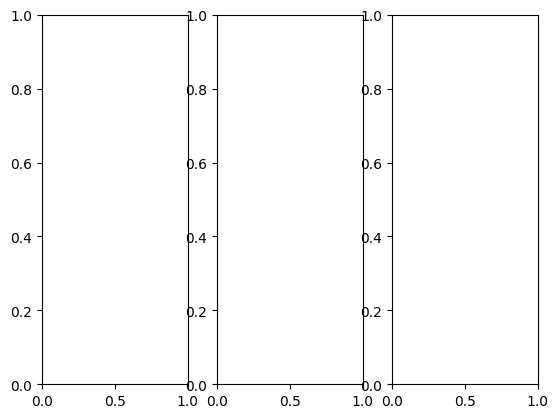

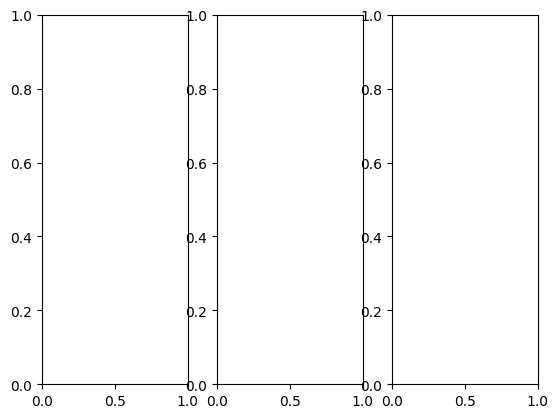

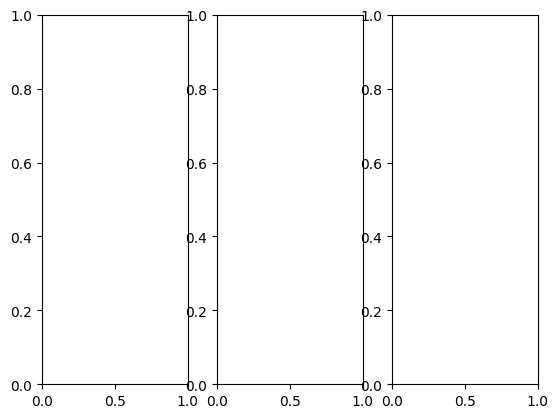

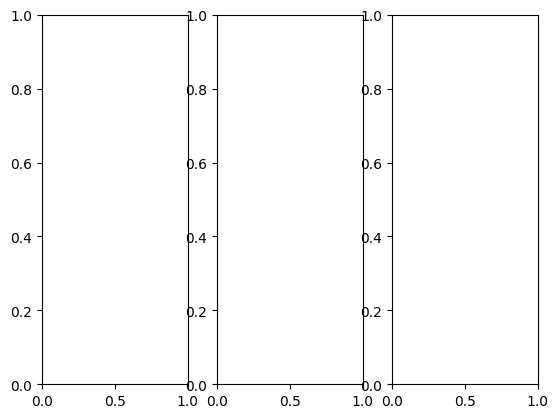

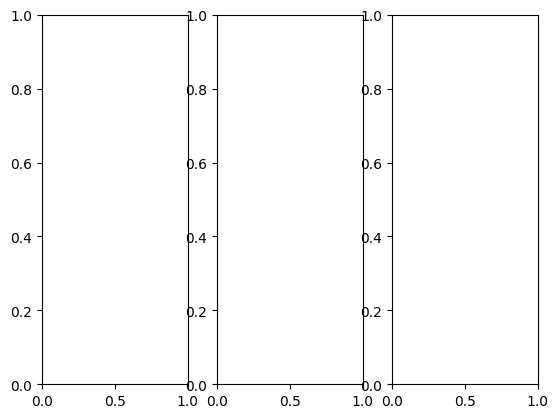

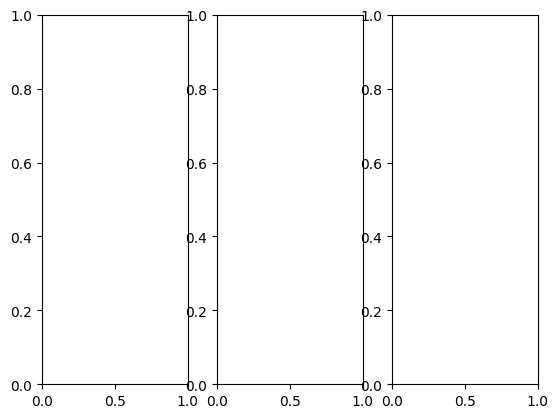

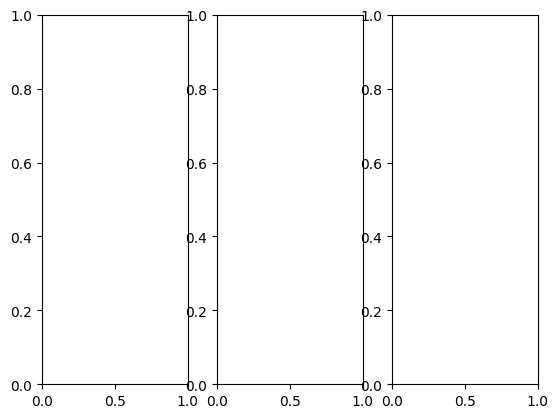

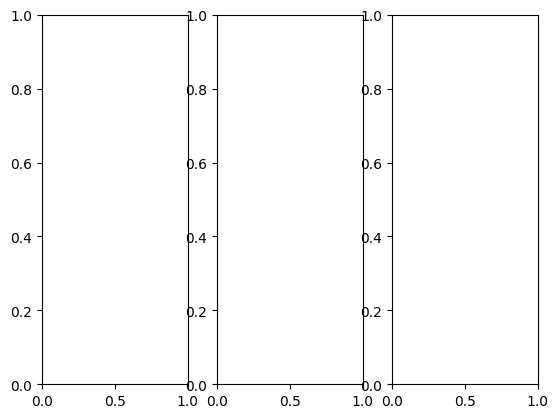

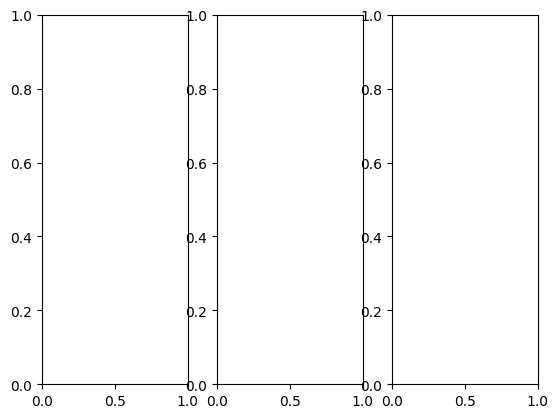

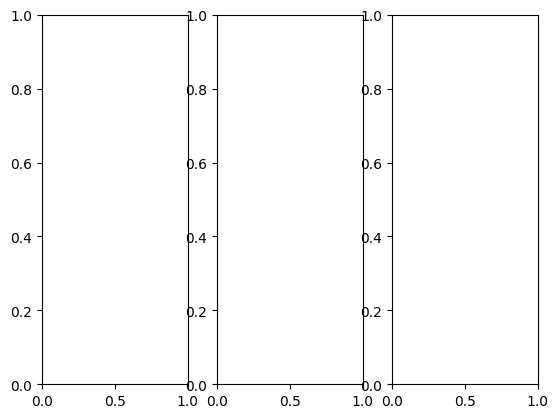

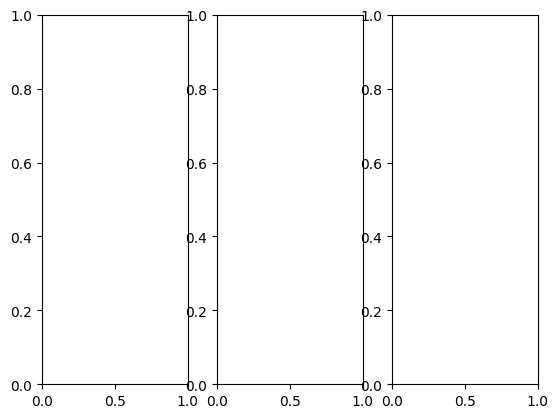

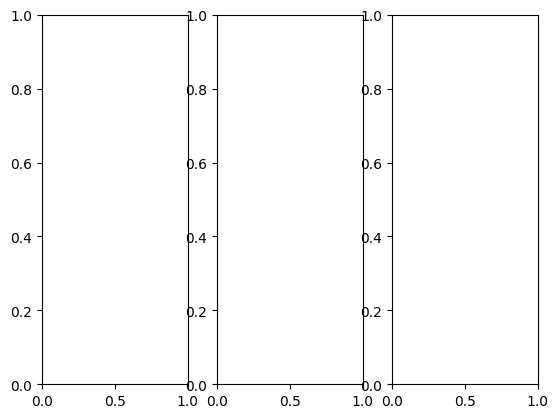

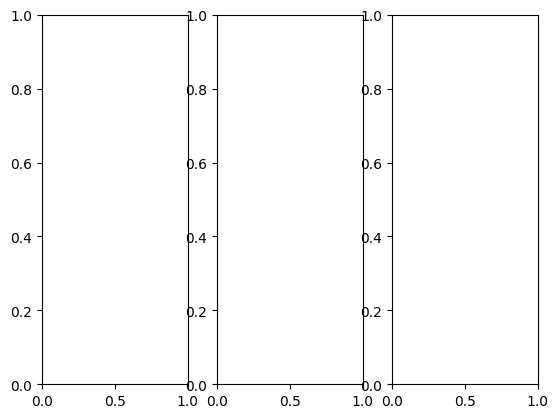

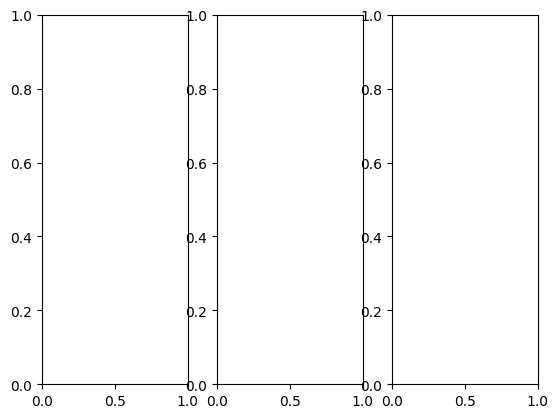

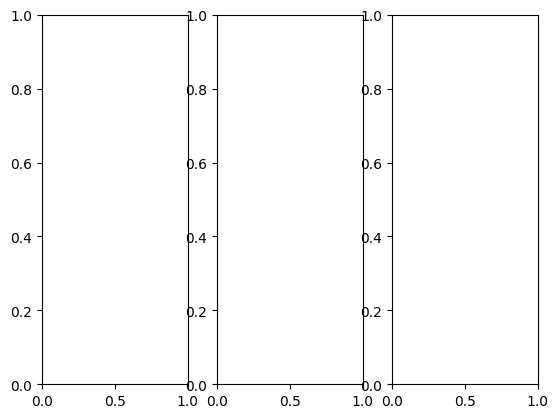

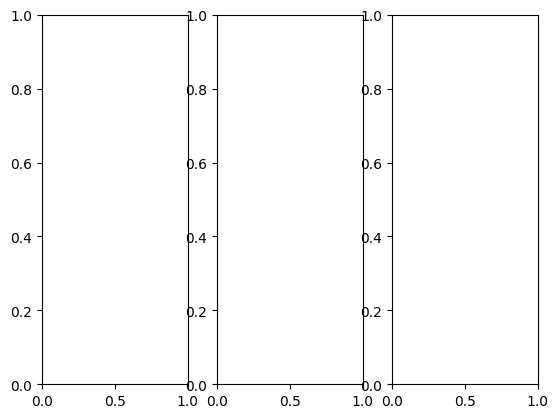

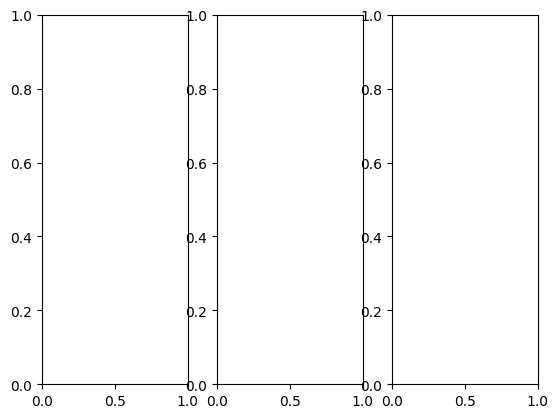

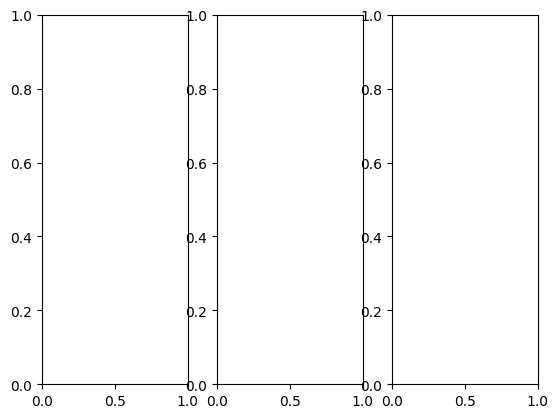

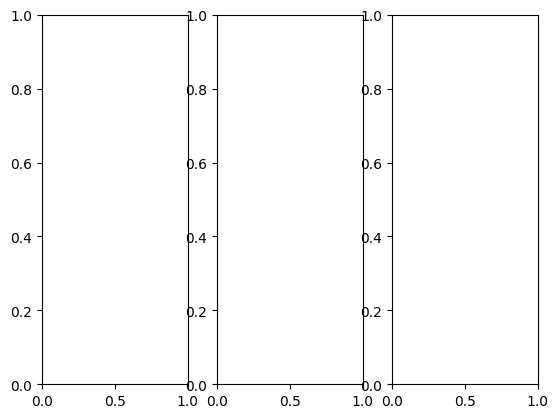

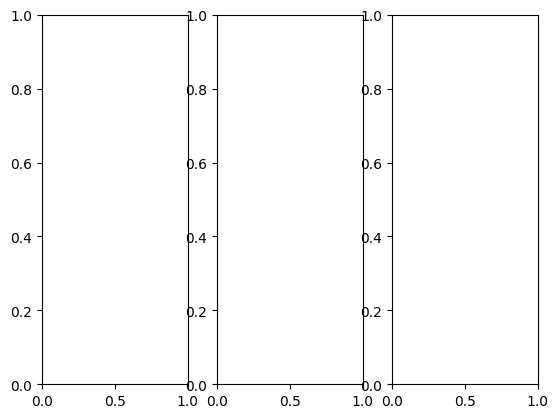

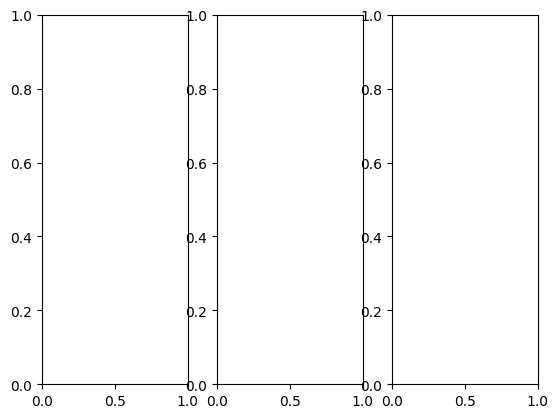

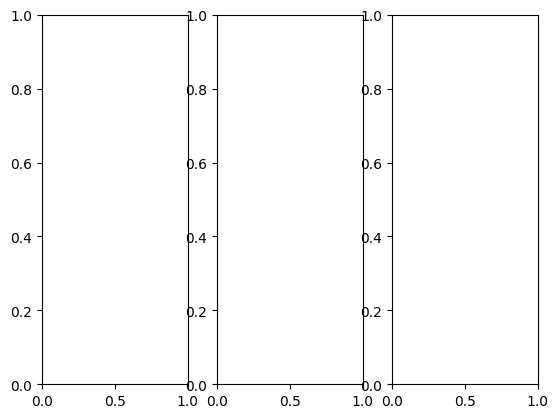

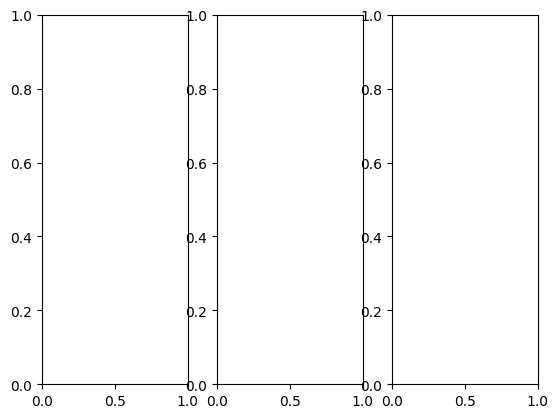

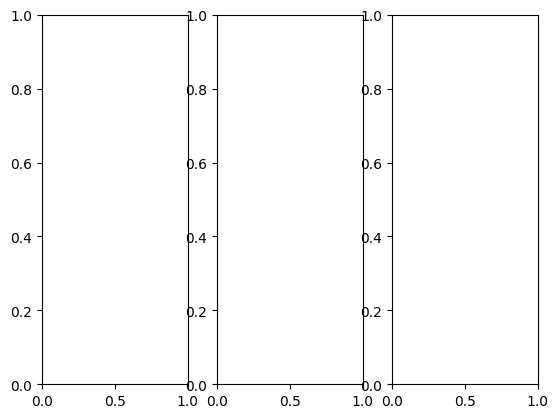

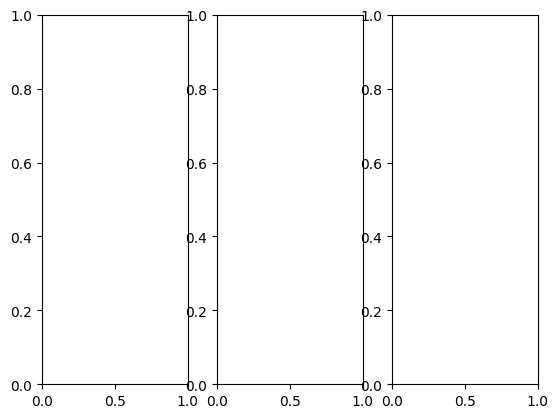

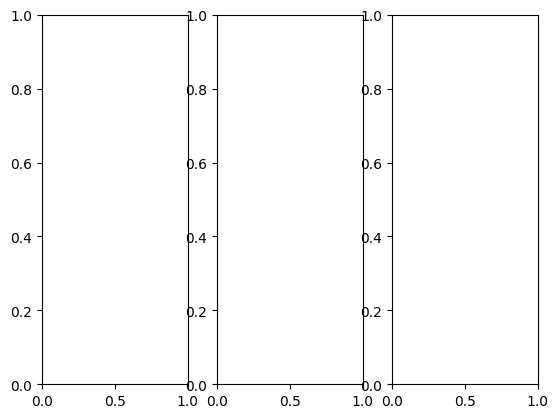

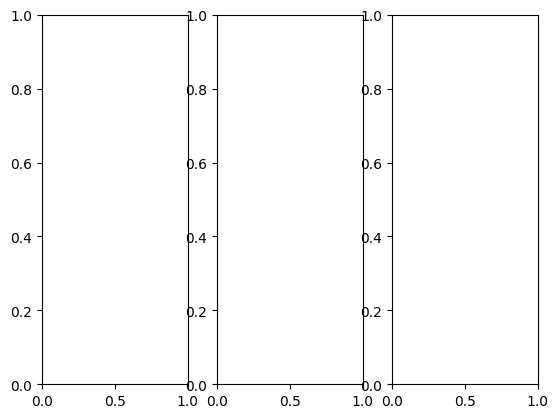

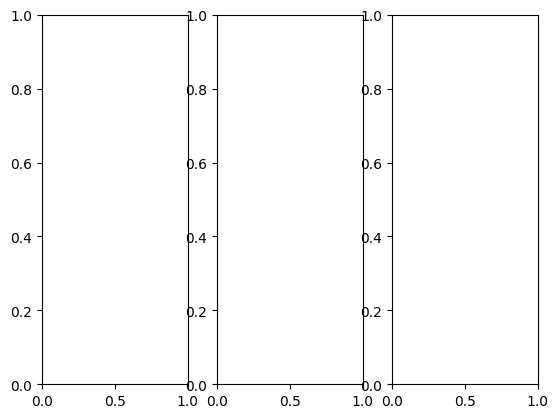

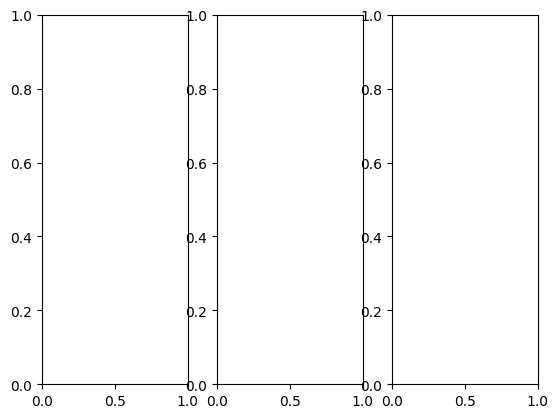

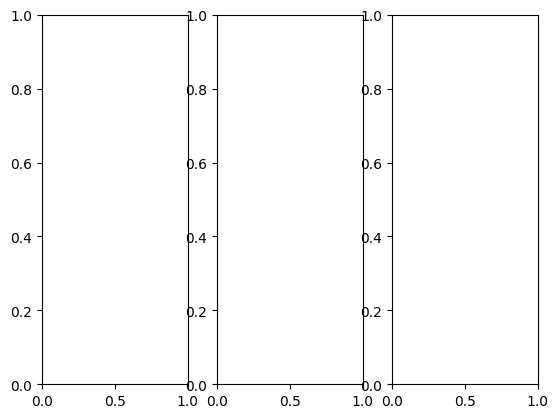

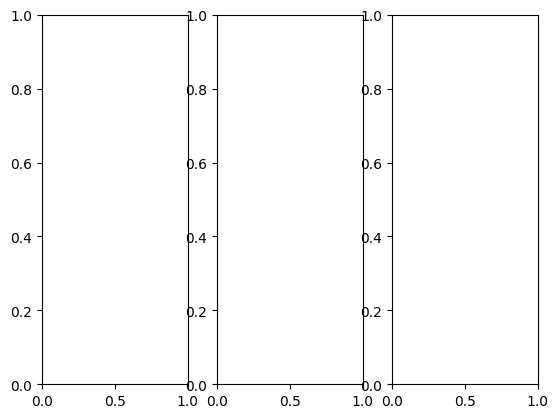

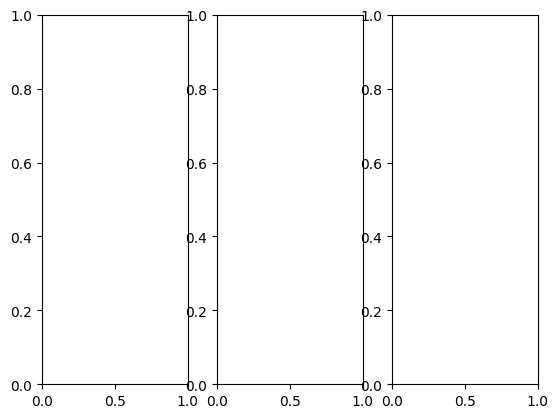

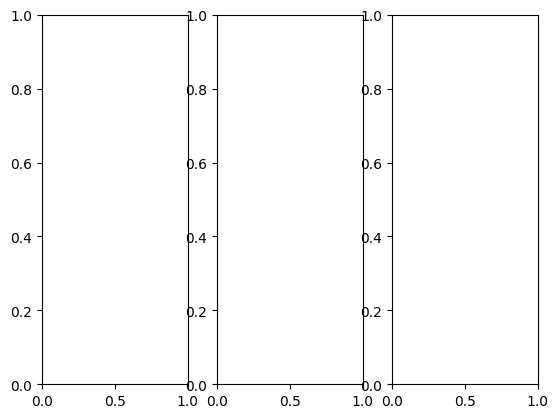

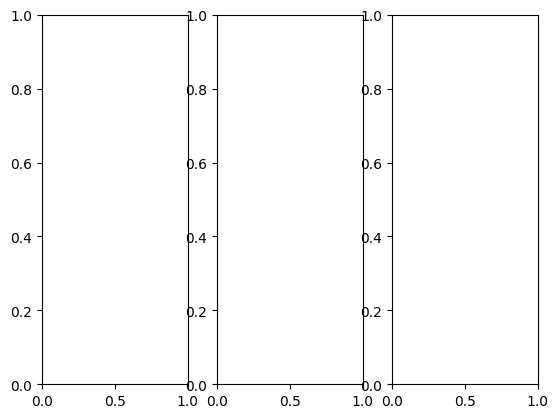

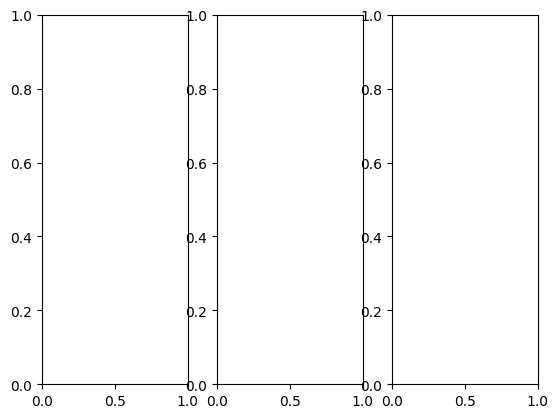

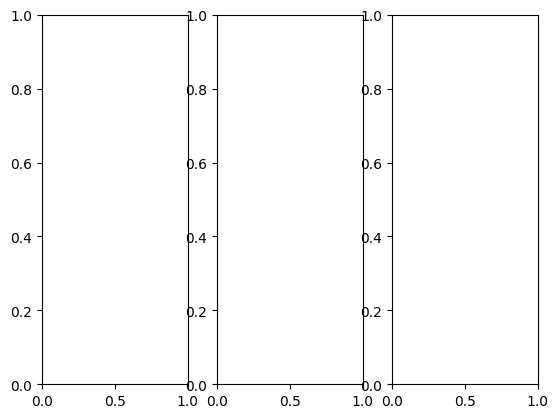

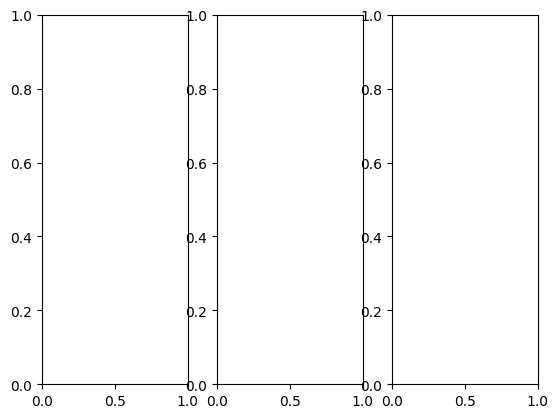

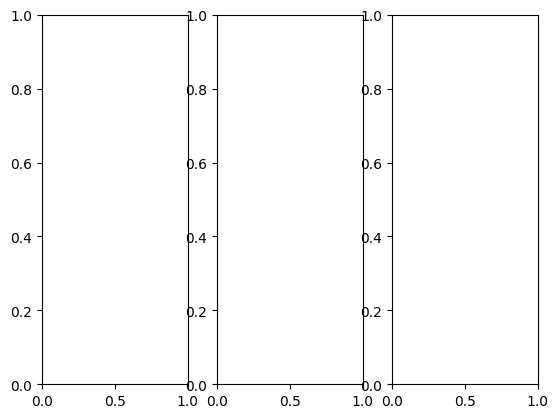

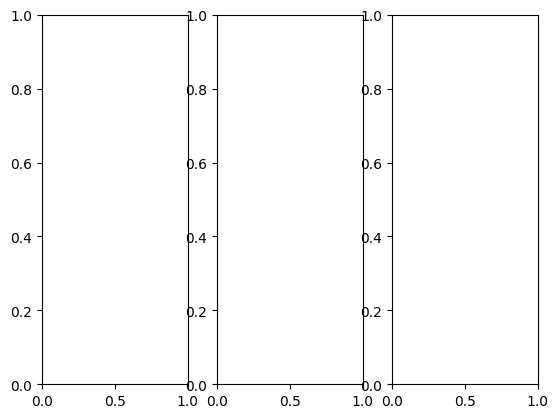

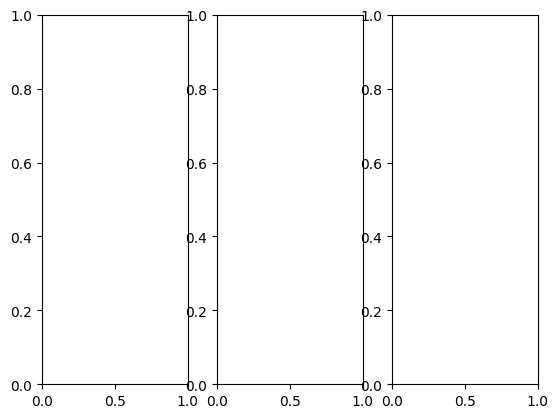

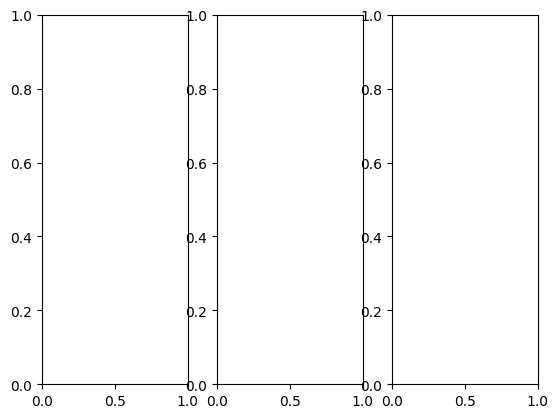

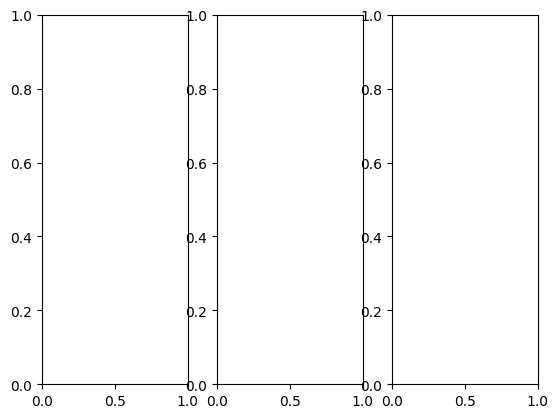

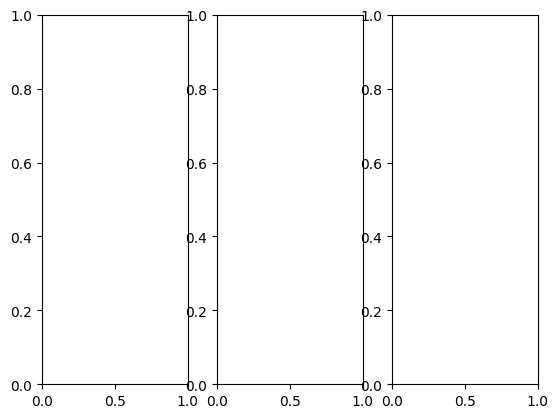

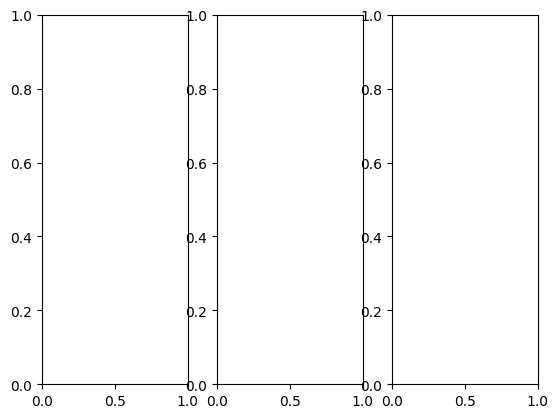

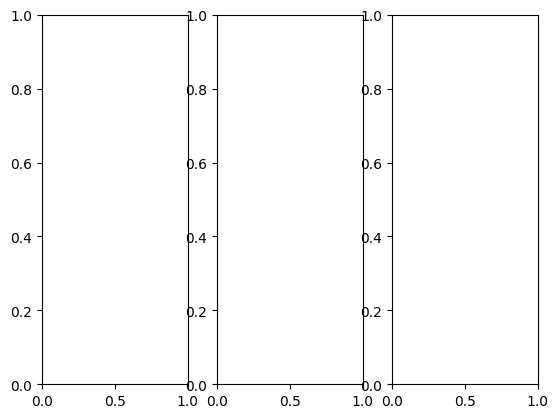

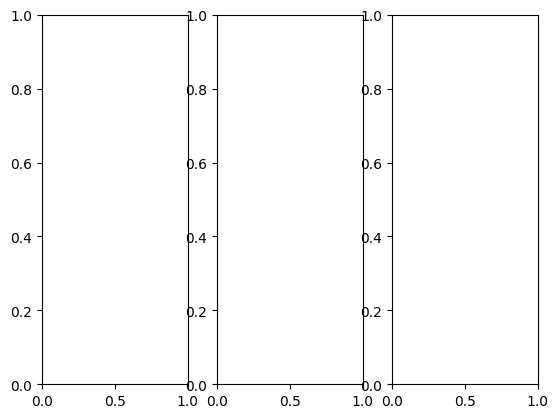

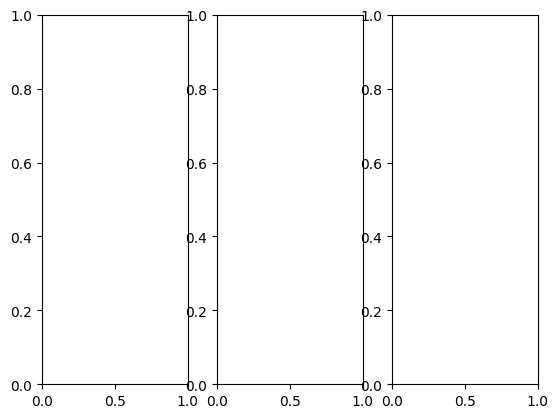

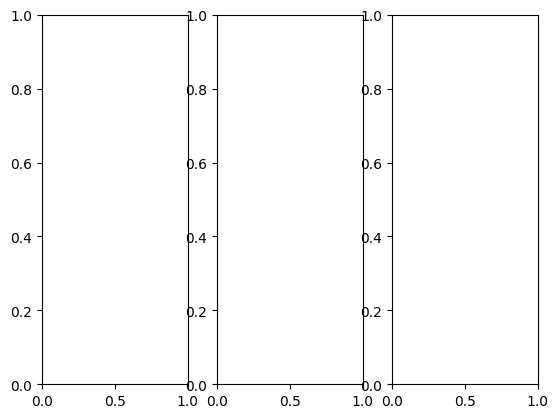

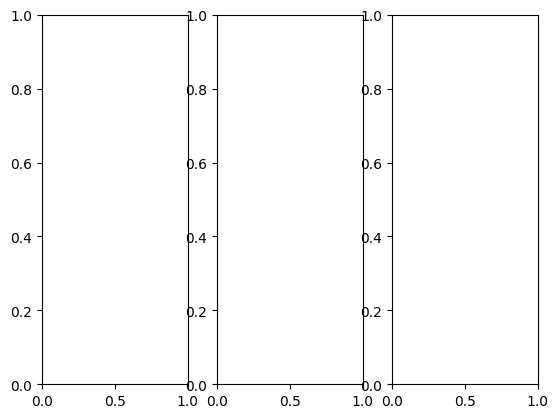

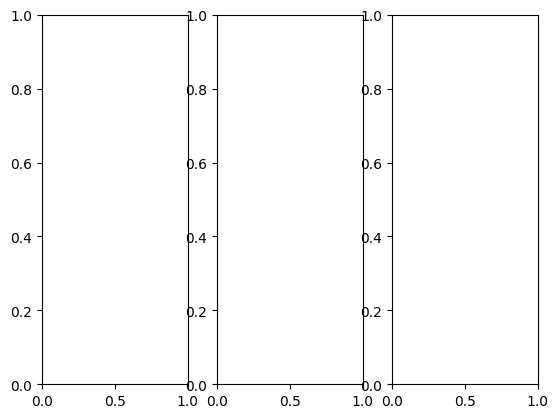

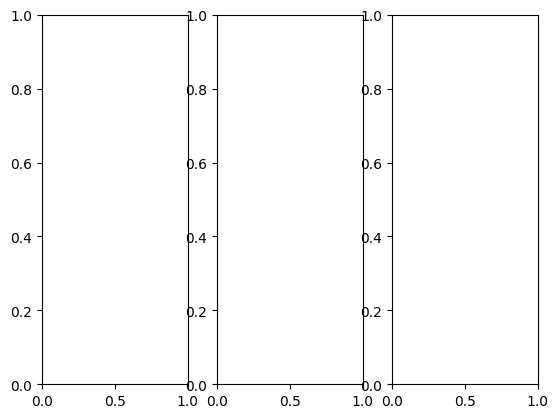

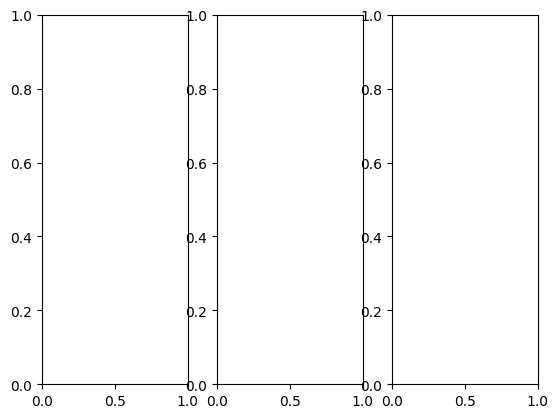

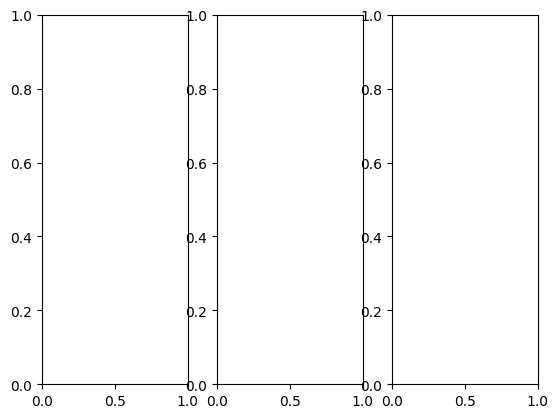

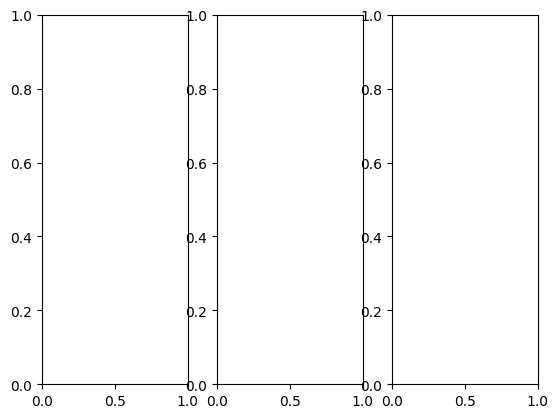

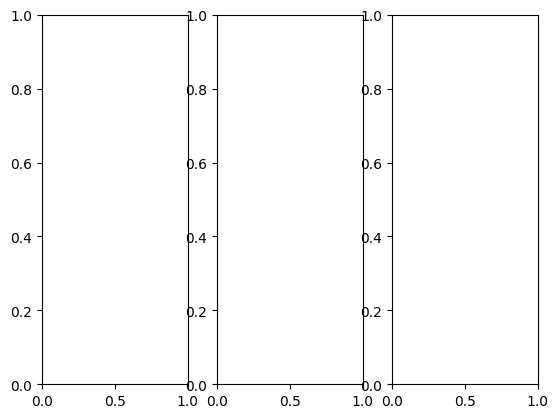

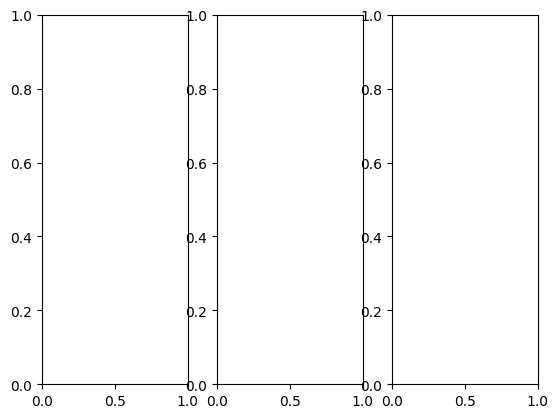

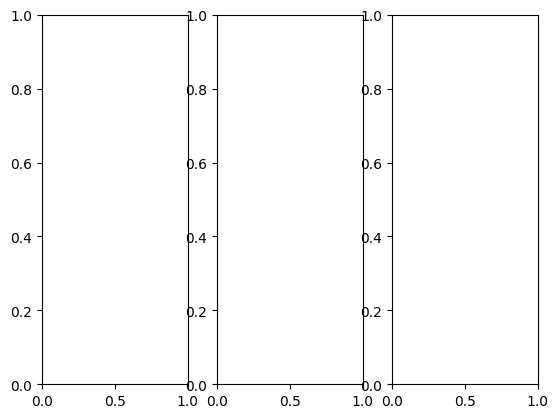

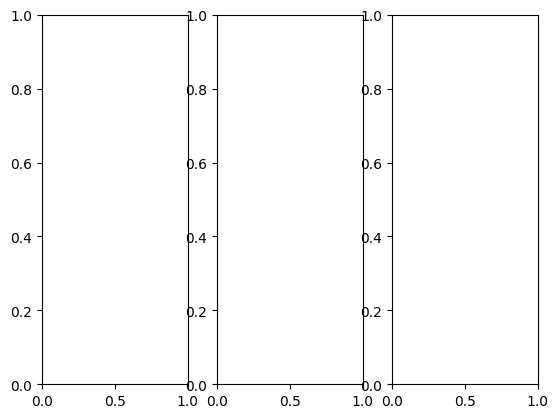

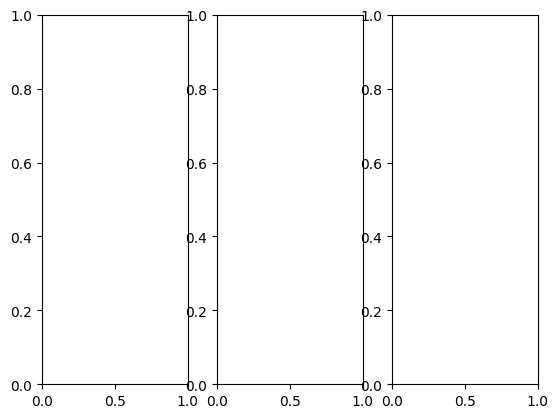

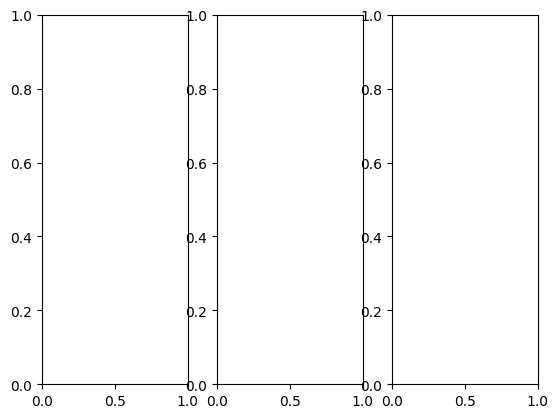

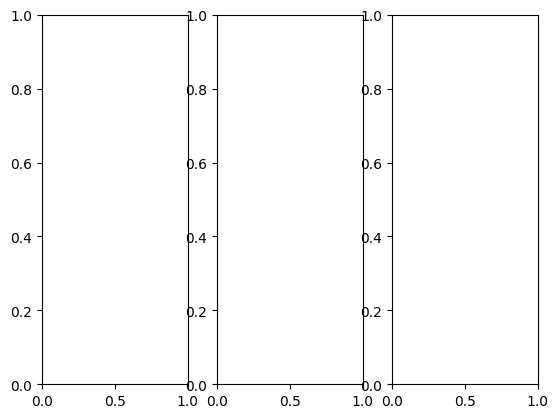

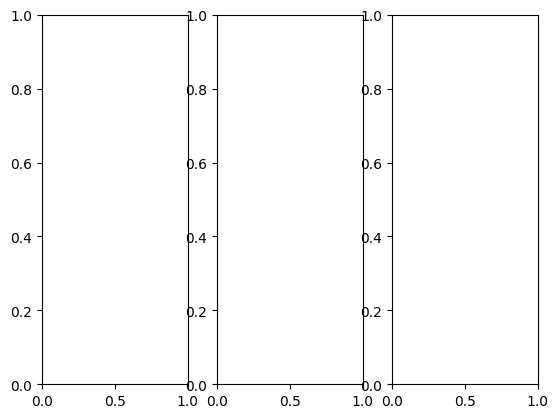

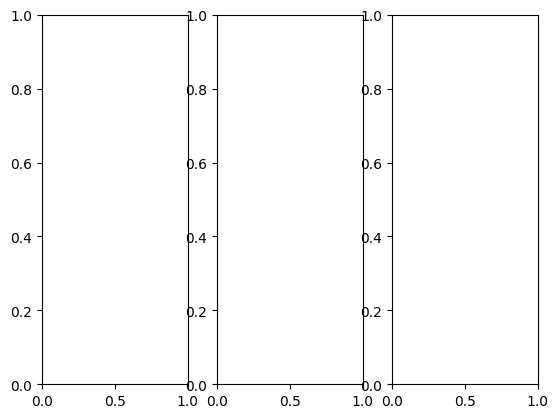

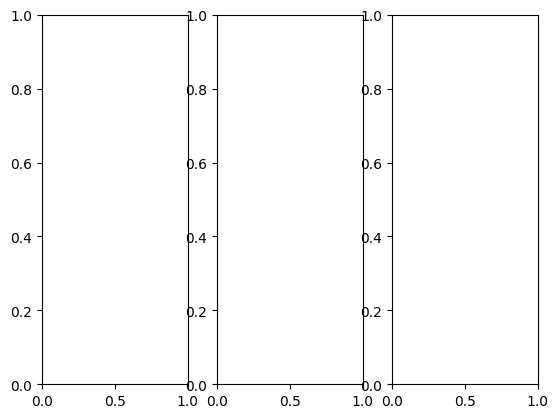

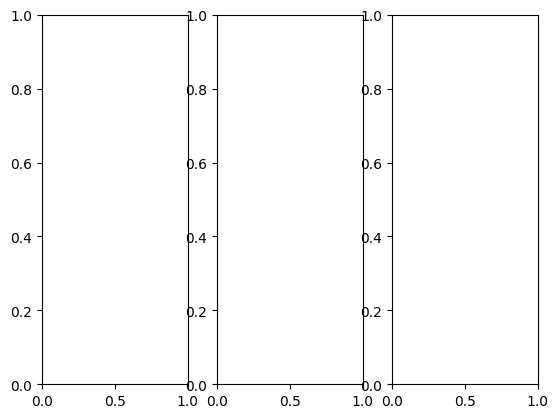

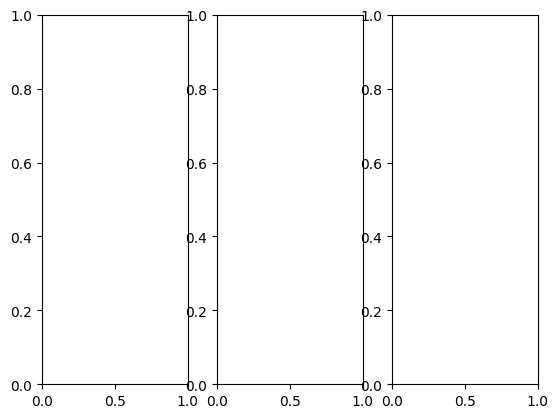

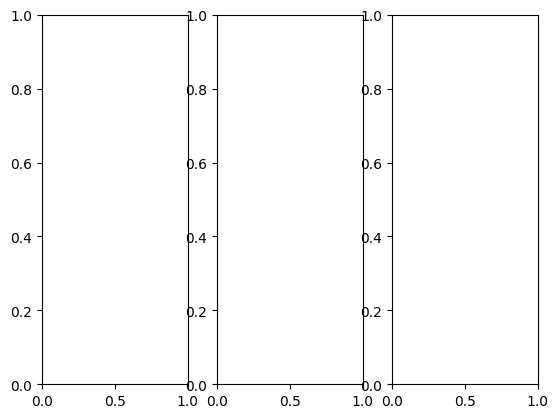

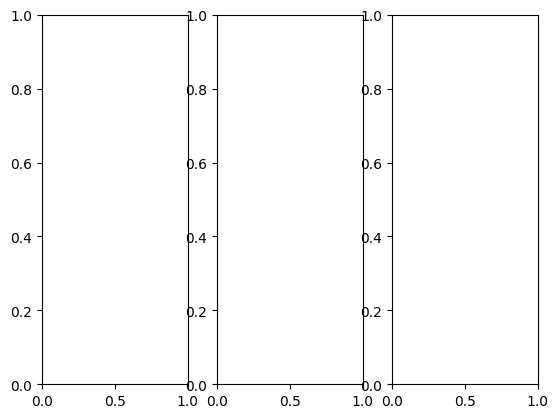

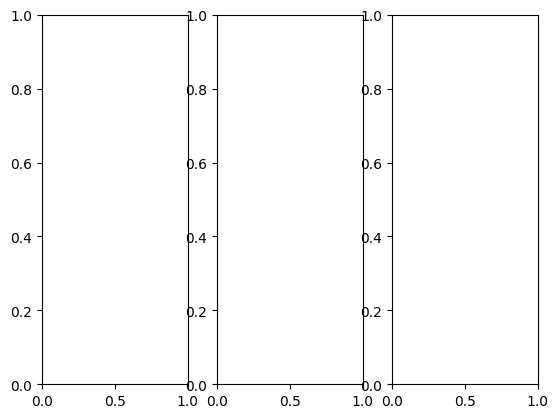

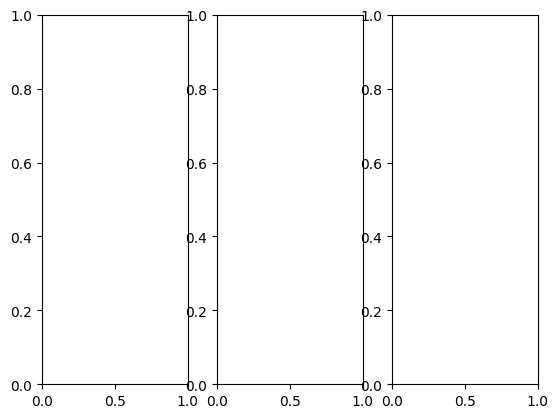

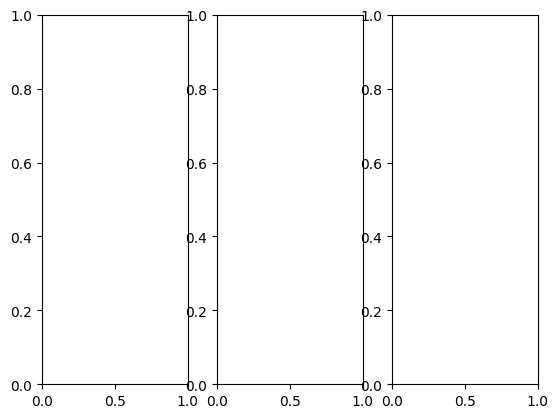

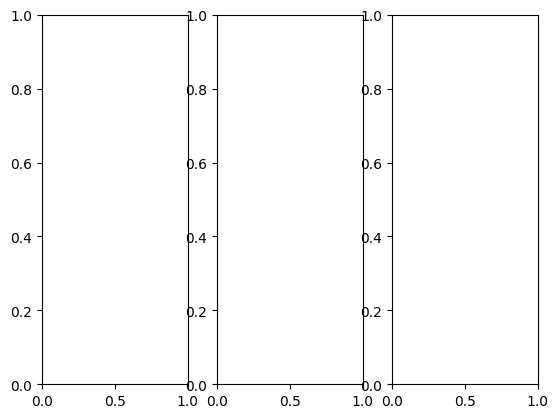

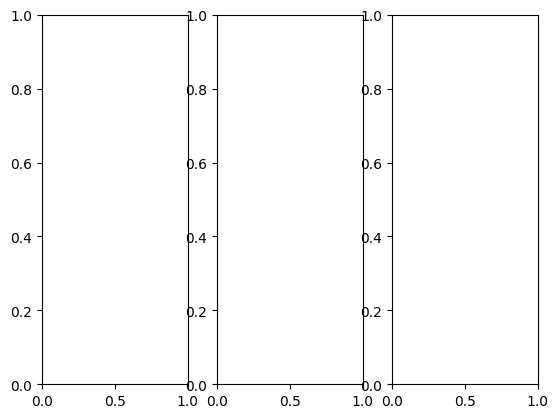

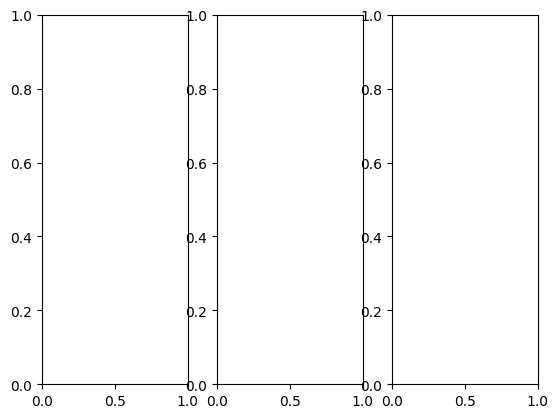

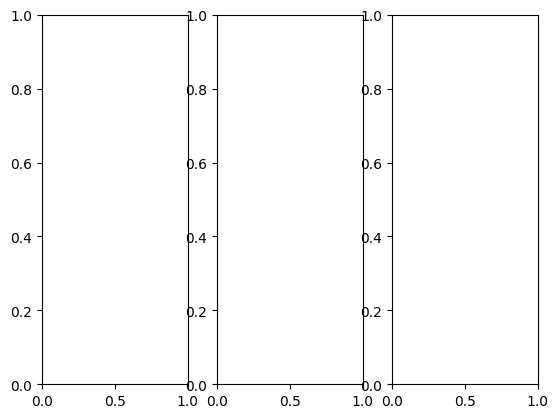

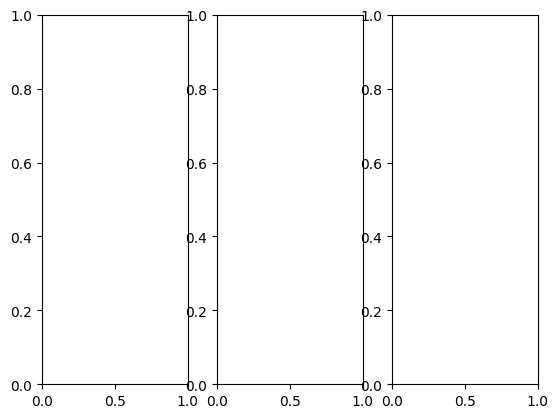

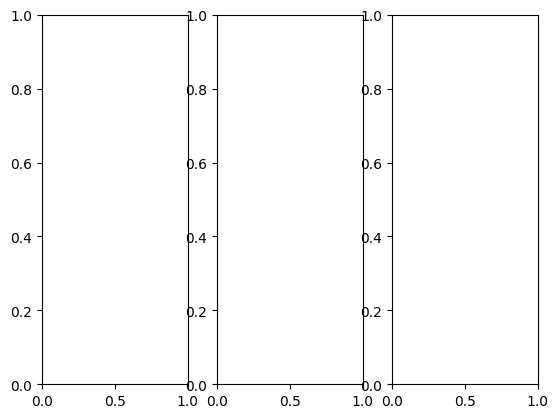

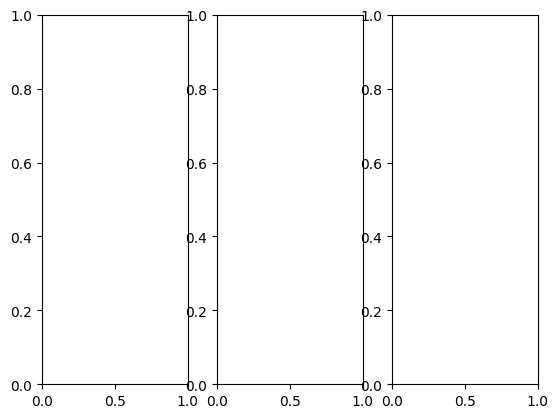

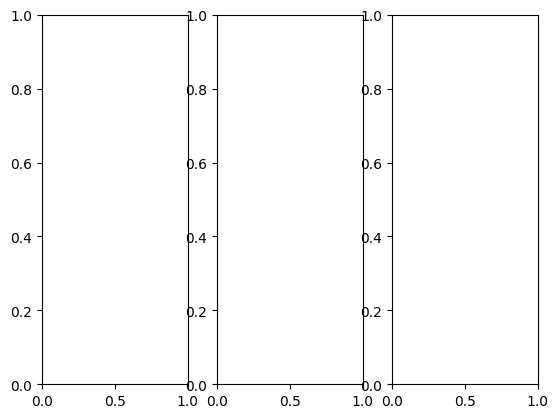

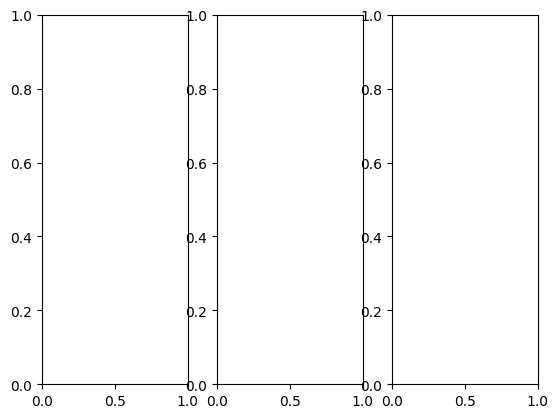

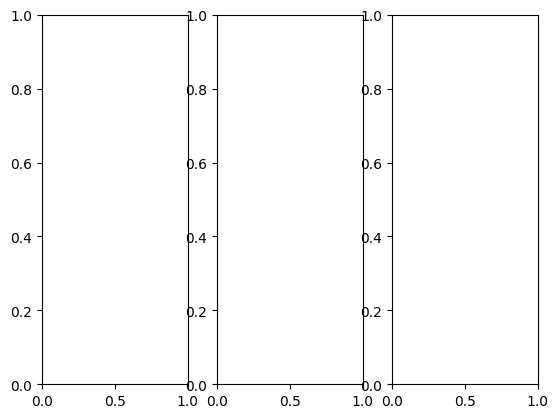

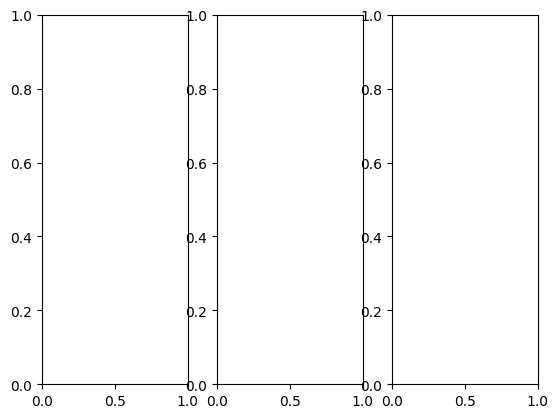

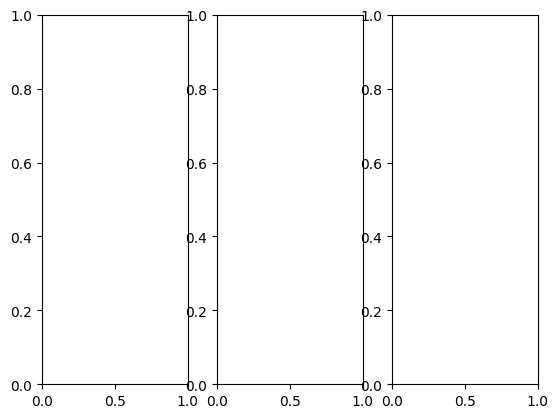

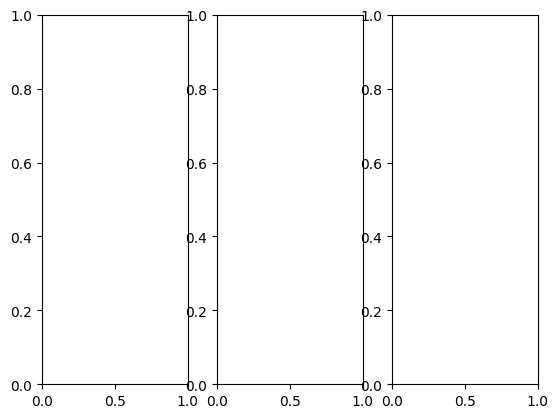

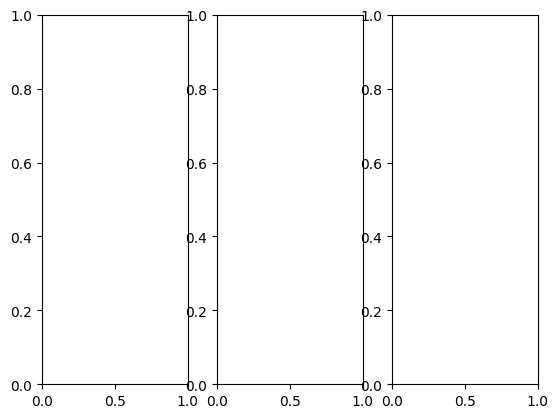

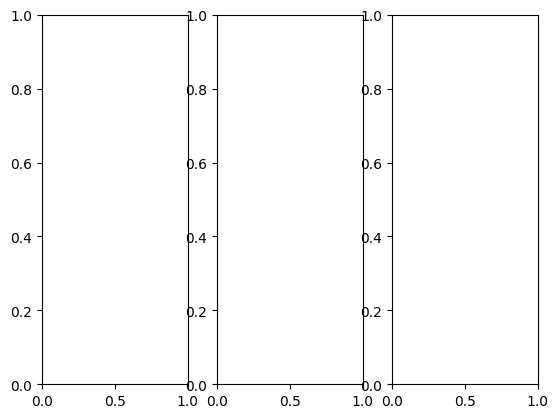

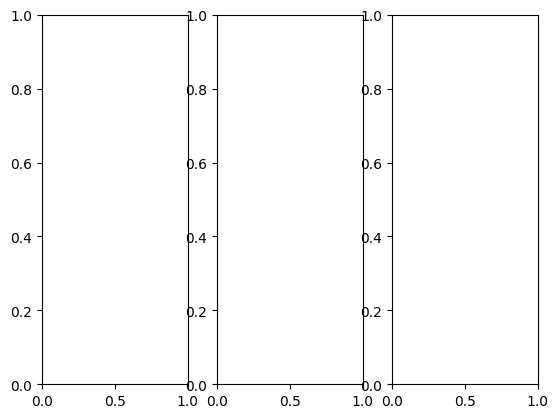

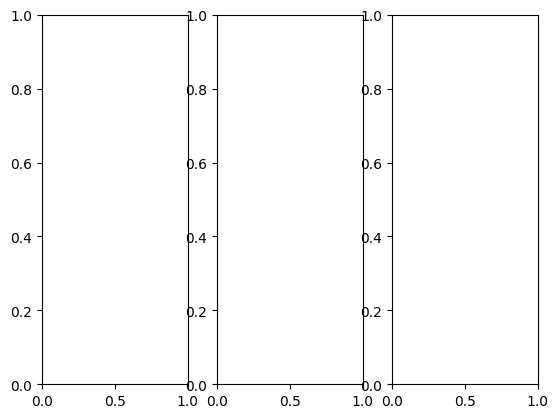

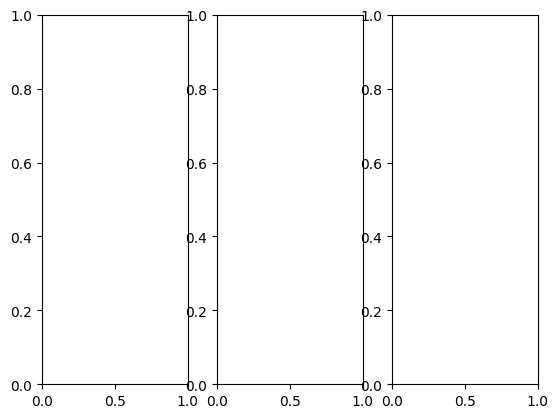

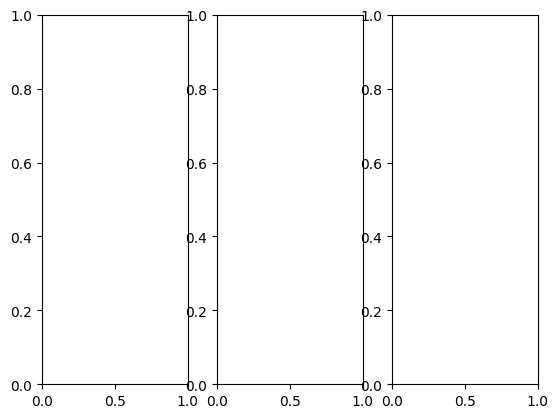

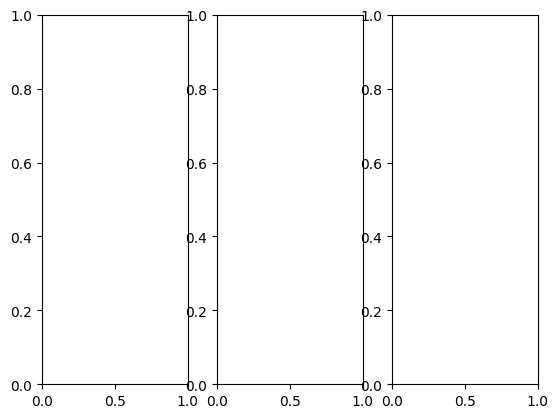

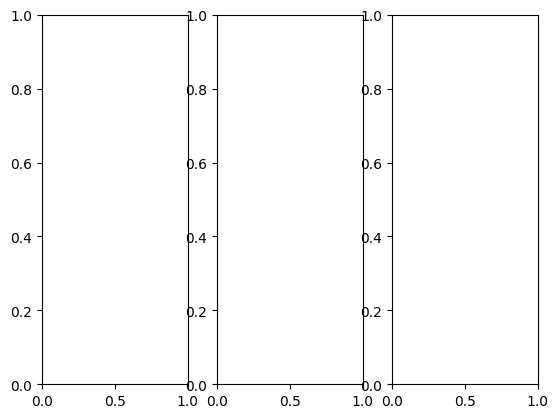

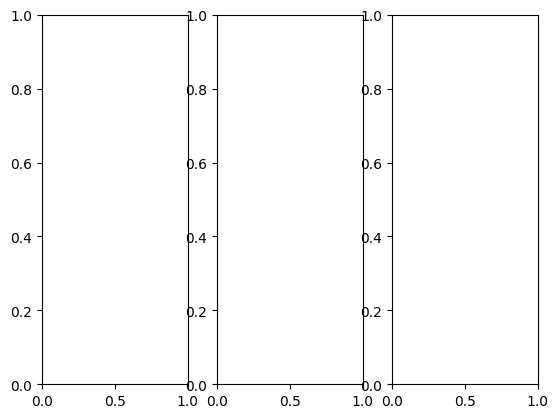

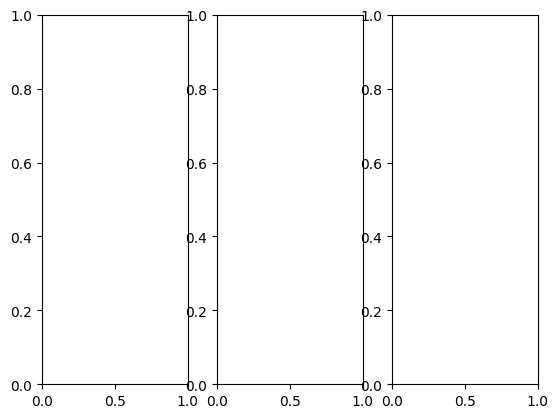

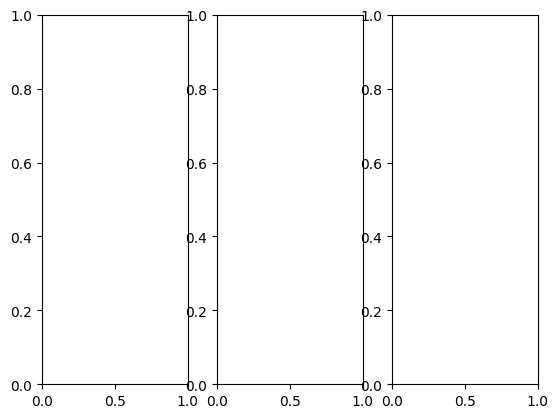

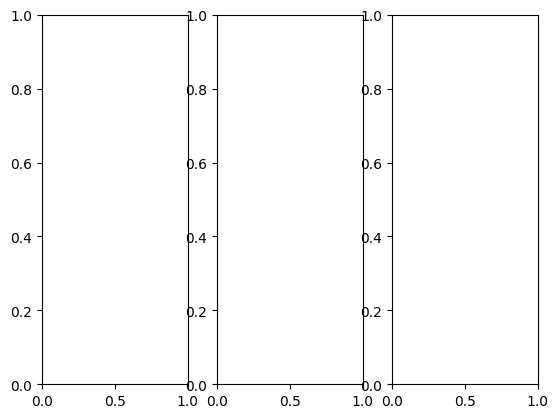

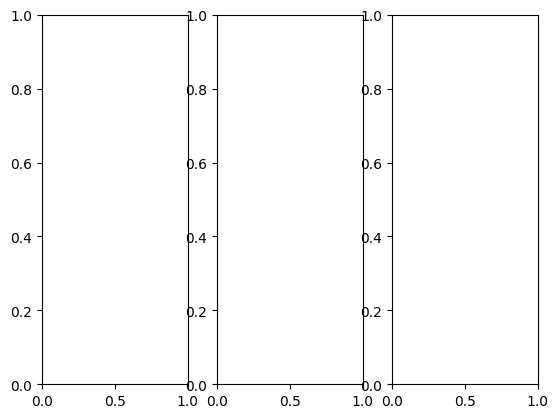

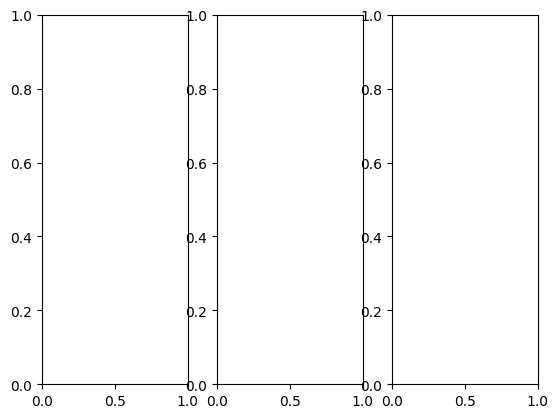

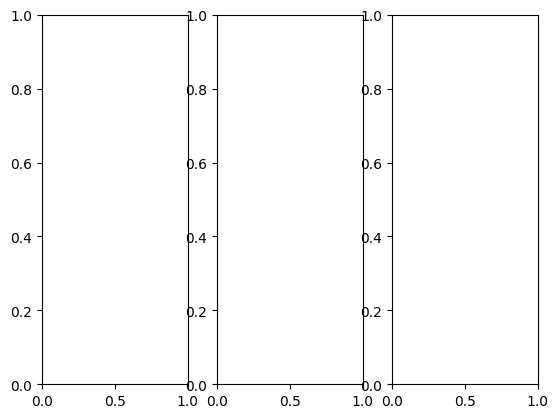

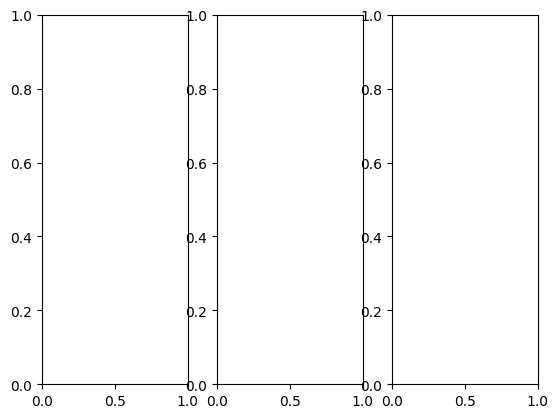

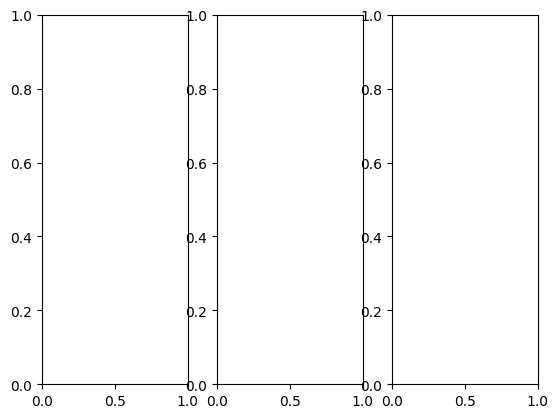

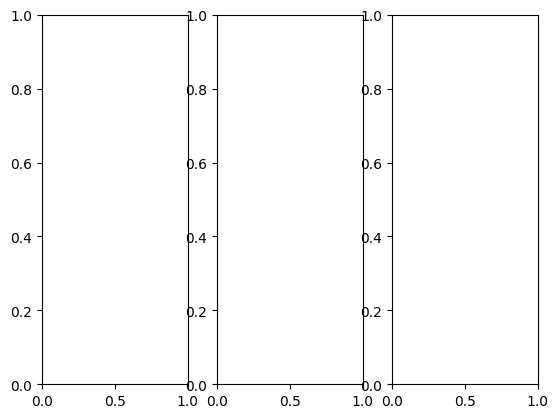

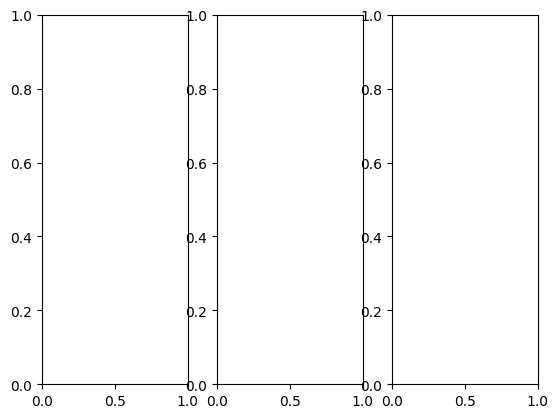

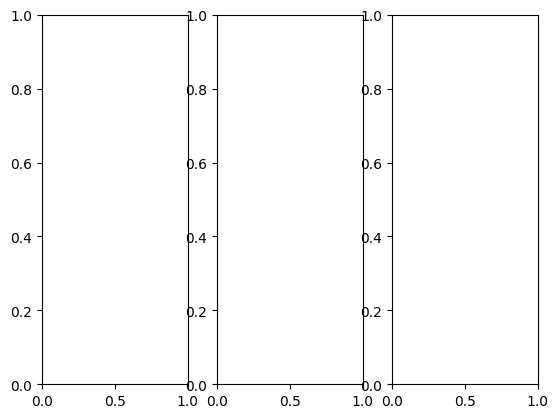

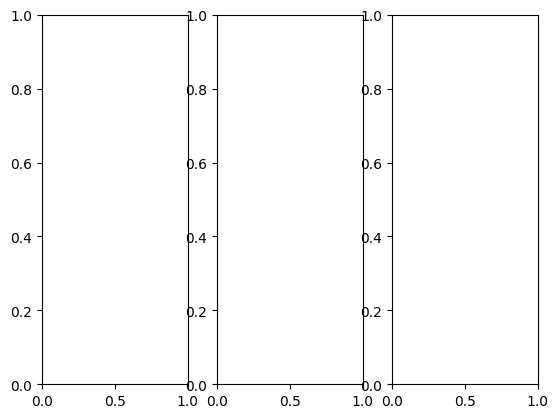

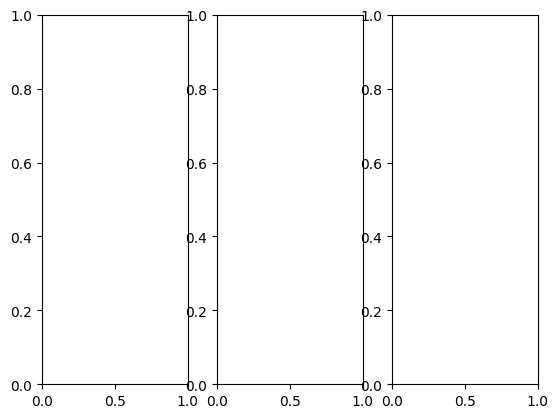

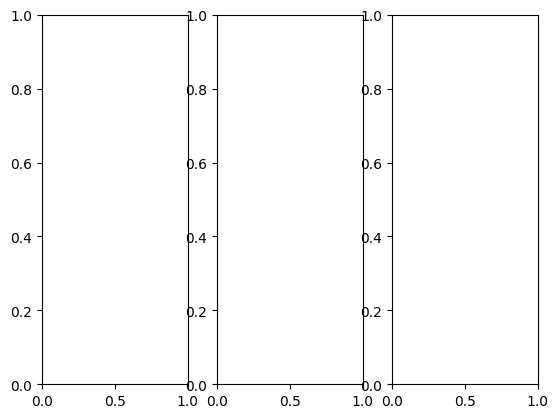

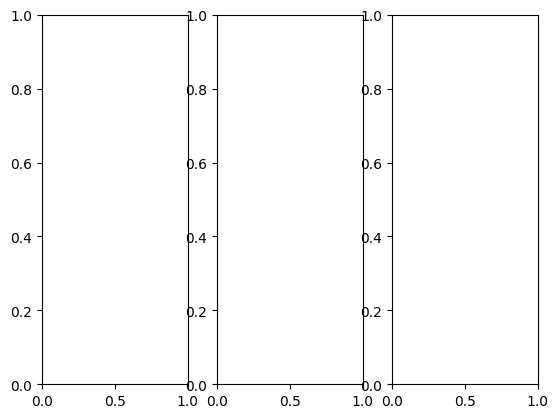

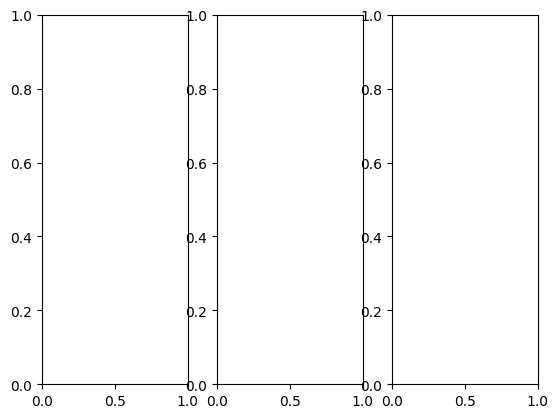

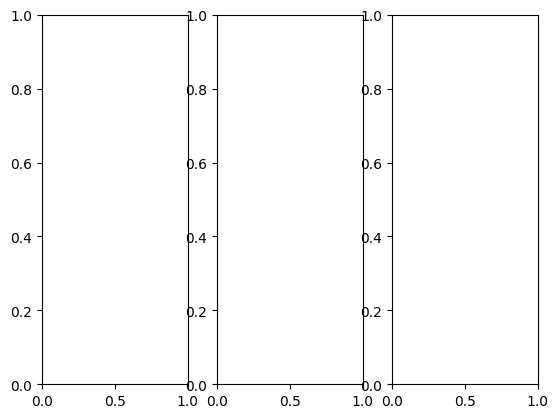

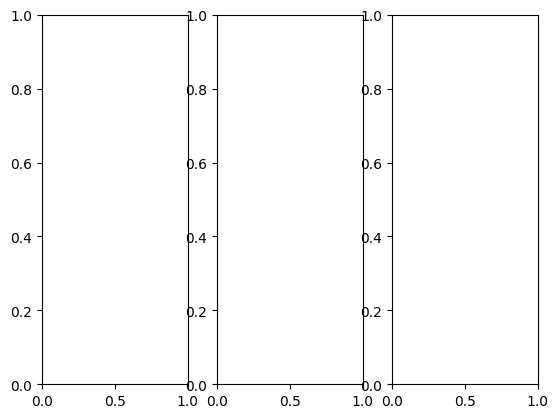

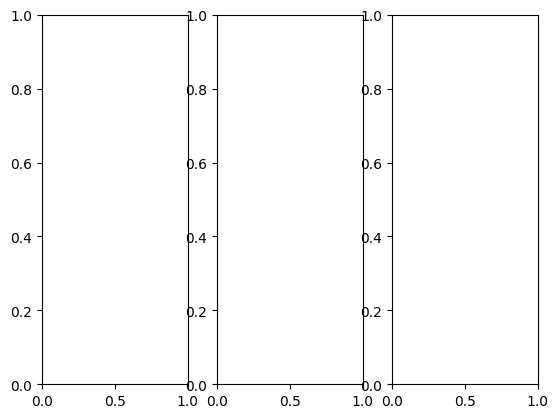

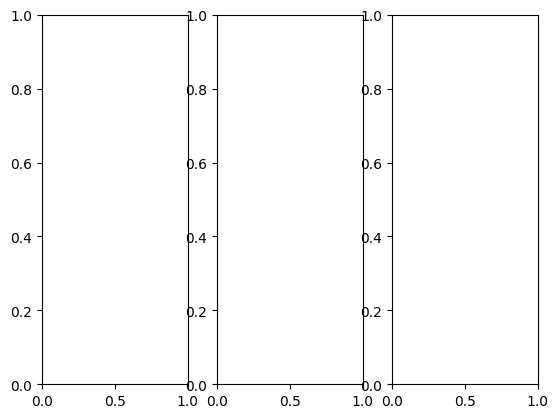

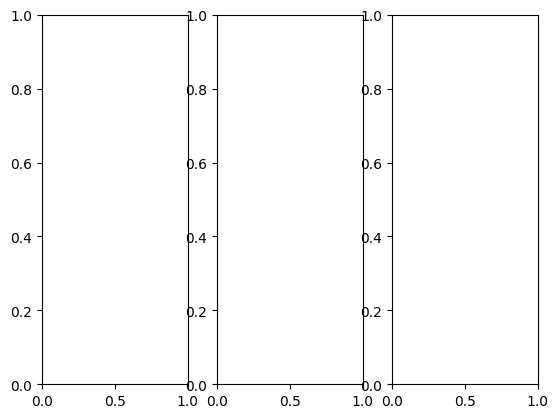

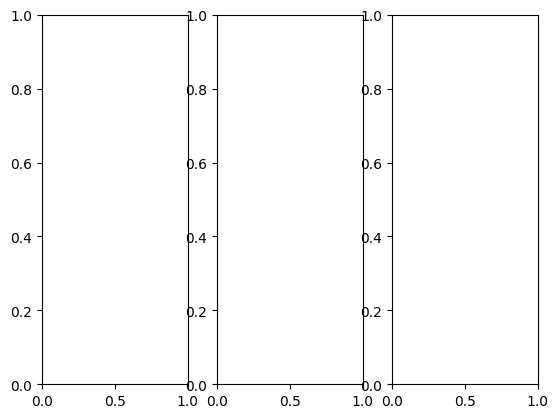

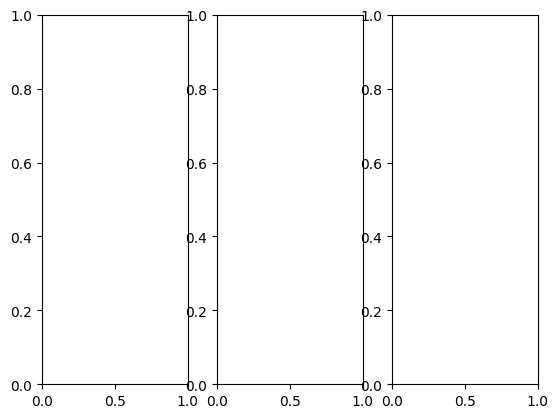

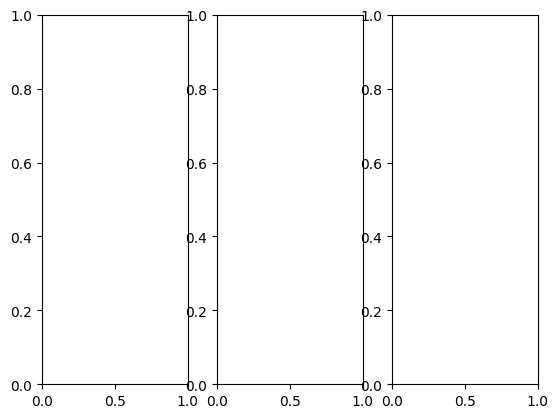

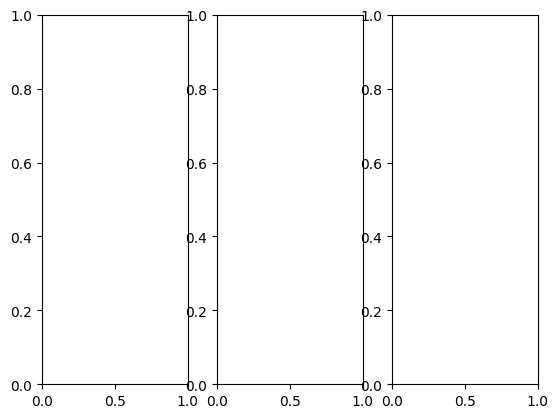

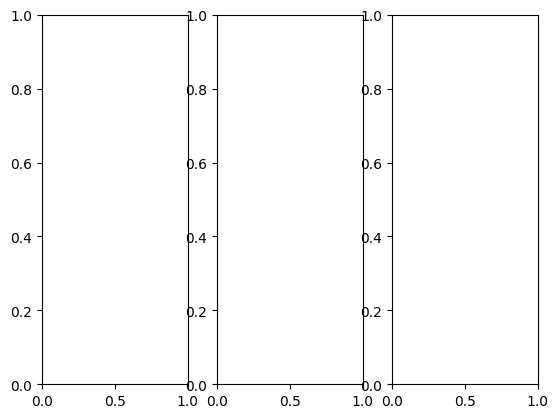

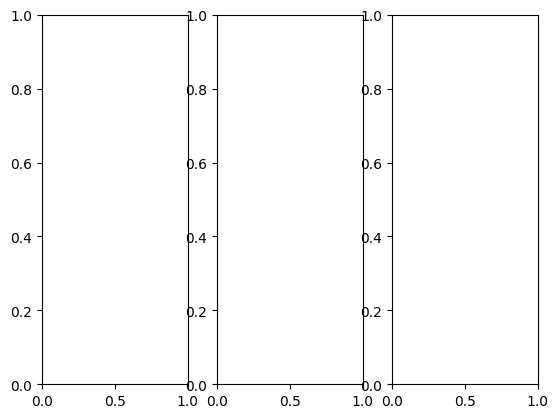

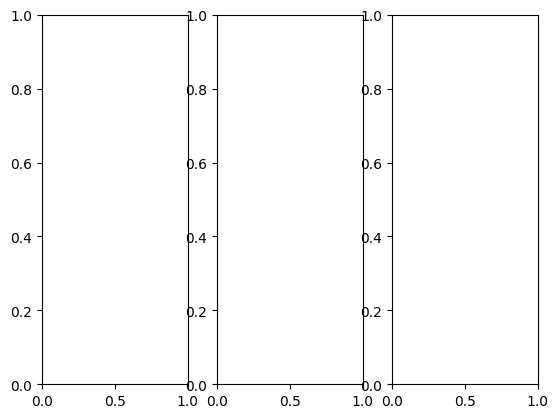

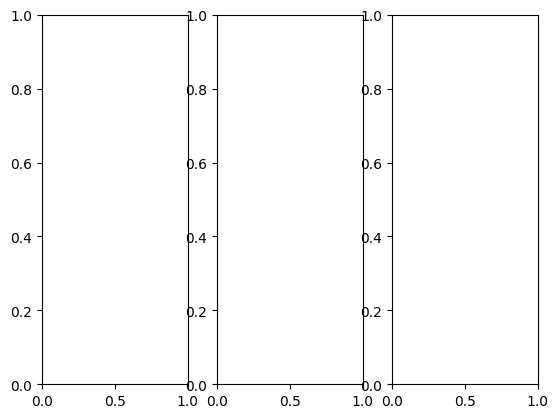

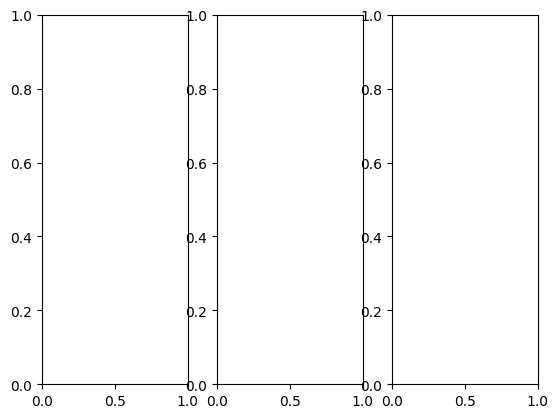

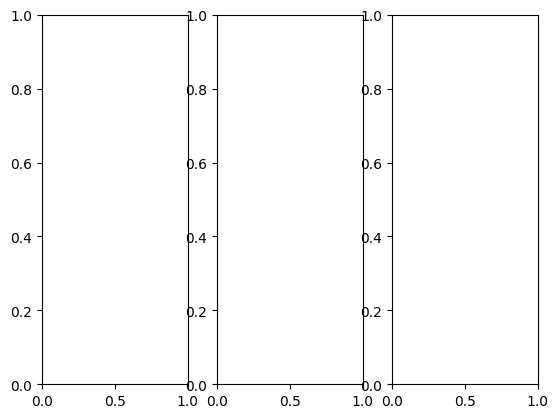

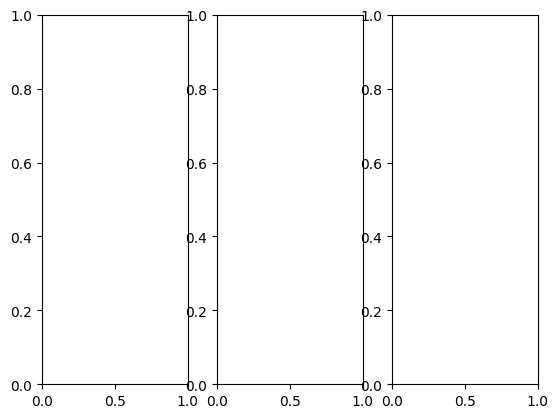

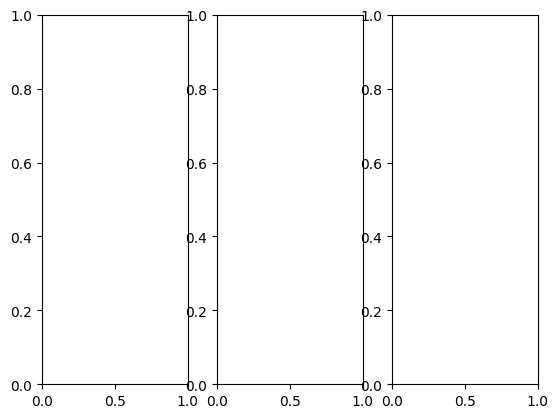

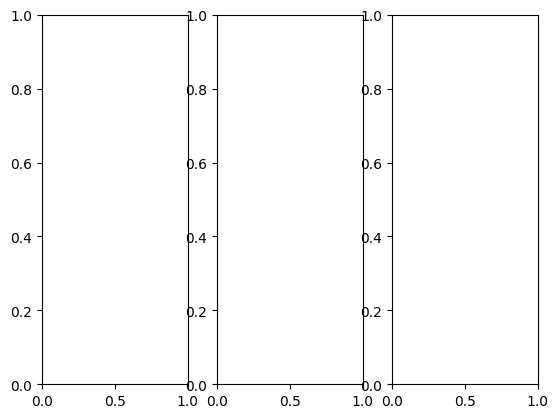

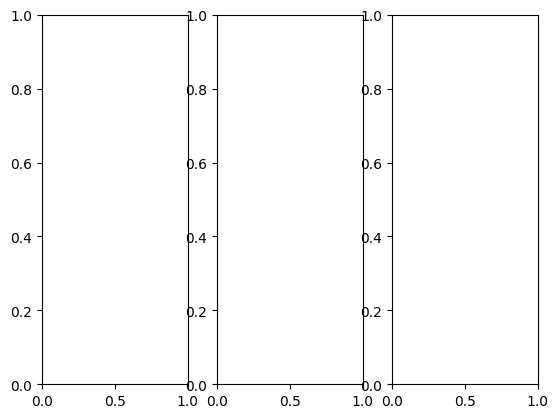

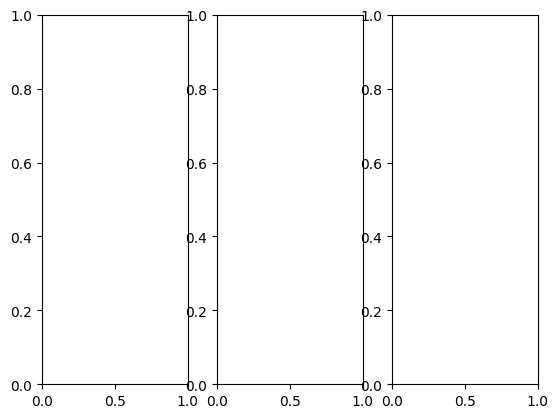

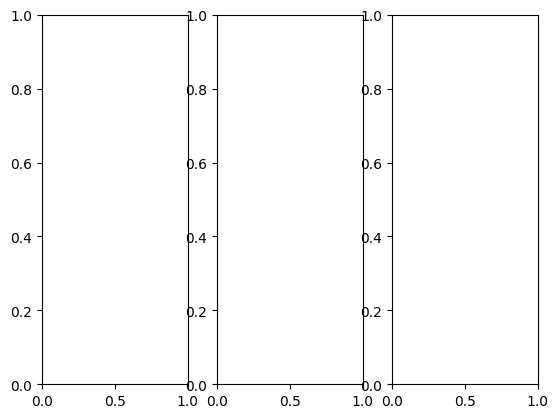

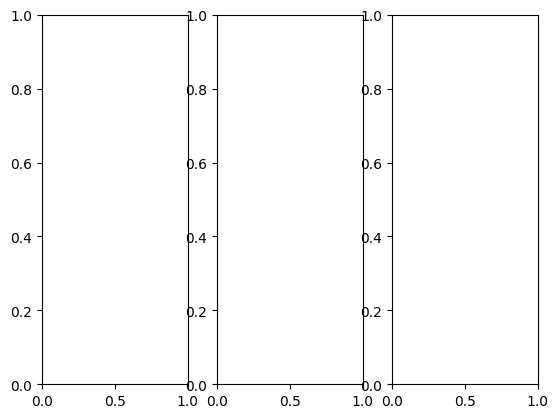

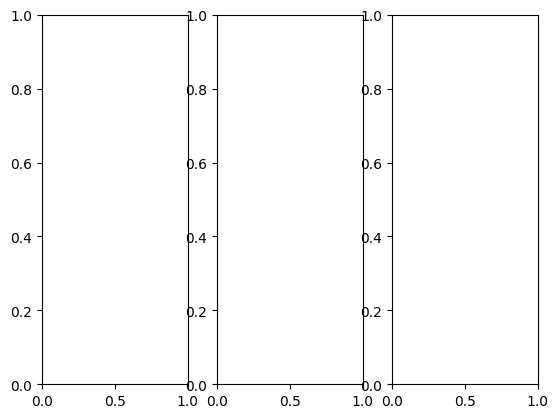

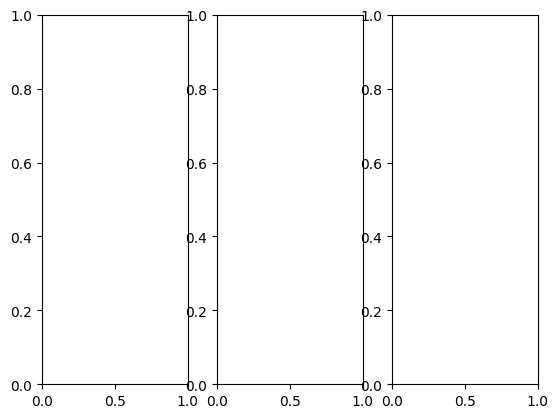

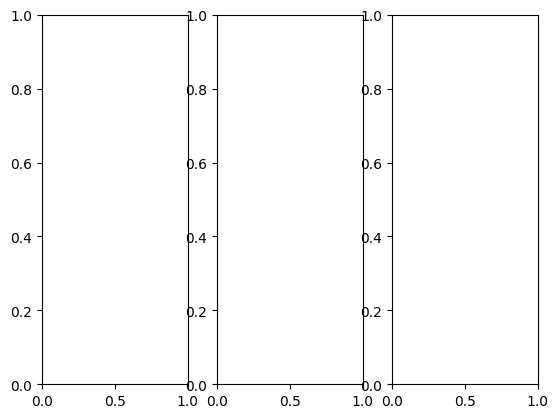

In [9]:
for i, (cam_type, max_eplen, rep) in enumerate(product(cam_types, max_eplens, range(repeats))):

  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 

  max_eplen = "demo_max"

  rets, done = run_grasp_with_agent(
    env, task, agent, demos, max_eplen = max_eplen, ## TODO: try 'demo_max'?? 

    training_params=training_params, 
    task_params=task_params,
    
    print_index=i
  )

  df.loc[i] = {
    "task_name": get_task_name(task),
    "cam_type": cam_type,
    "demo_count": 1,
    "max_eplen": max_eplen,
    "is_success": done,
    "min_distance": min(rets["distances"]),
    "final_distance": rets["distances"][-1],
    "gripper_image_paths": rets["gripper_image_paths"]

  }
  df.to_csv("vision_single_static-comb_cams-results.csv", index=True)



## Param Tuning - Trying longer sequences
See `plots.ipynb` for the explanation but larger mb size hence longer sequences of uninterrupted actions from the observations dataset will help the robot

TODO: Maybe change the dataset so that the robot trains on entirety of the given observations?

In [4]:
cam_types = [
  CamType.WRIST, 
  CamType.RIGHT_SHOULDER,
  CamType.LEFT_SHOULDER,
  CamType.LEFT_SHOULDER | CamType.RIGHT_SHOULDER
]

task = Vision_Static
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": 1000,
  "minibatch_size": None, ## tuning for this so will change this
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": False,
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5
}
repeats = 10

mb_sizes = [128, 256, 512]

In [10]:
demos = task_env.get_demos(1, live_demos = True)

[vision_static] scale: 1 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)


In [28]:
combs = list(product(cam_types, mb_sizes, range(repeats)))
df = pd.DataFrame(columns=[
  "task_name", "cam_type", "demo_count", "max_eplen", 
  "mb_size",
  "is_success", "min_distance", "final_distance",
  "gripper_image_paths"
  
], index = range(len(combs))) 
df.to_csv("vision_single_static-hpt-results.csv", index=True)

In [29]:
for i, (cam_type, mb, rep) in enumerate(combs):
  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, mb size: {mb} repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 


  copy_params = training_params
  copy_params["minibatch_size"] = mb


  rets, done = run_grasp_with_agent(
    env, task, agent, demos, max_eplen = "demo_max", 
    training_params=copy_params, 
    task_params=task_params,
    print_index=i
  )
  print(f"{done = }")
  
  df.loc[i] = {
    "task_name": get_task_name(task),
    "cam_type": cam_type,
    "demo_count": 1,
    "max_eplen": "demo_max",
    "mb_size": mb,
    "is_success": done,
    "min_distance": min(rets["distances"]),
    "final_distance": rets["distances"][-1],
    "gripper_image_paths": rets["gripper_image_paths"]

  }
  df.to_csv("vision_single_static-hpt-results.csv", index=True)
                                        

Running Vision_Static with wrist and 1 demo, mb size: 128 repeat: 0
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 128, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 213.26it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May12_14-44.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
done = np.False_
Running Vision_Static with wrist and 1 demo, mb size: 128 repeat: 1
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 128, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 214.00it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May12_14-44.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
done = np.False_
Running Vision_Static with wrist and 1 demo, mb size: 128 repeat: 2
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 128, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



...

Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-l_shoulder+r_shoulder--_May12_14-56.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
done = np.True_
Running Vision_Static with l_shoulder+r_shoulder and 1 demo, mb size: 512 repeat: 8
[simple_policy] - Policy] Using l_shoulder+r_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: l_shoulder+r_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 512, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:06<00:00, 158.64it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-l_shoulder+r_shoulder--_May12_14-56.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
done = np.True_
Running Vision_Static with l_shoulder+r_shoulder and 1 demo, mb size: 512 repeat: 9
[simple_policy] - Policy] Using l_shoulder+r_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: l_shoulder+r_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 512, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:06<00:00, 157.85it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-l_shoulder+r_shoulder--_May12_14-56.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
done = np.True_


## Param Tuning + Vision_Random

I also want to see generalisations, running wrist alone a few times, I saw that the wrist camera generalises better across multiple trials compared to a single wrist or shoulder camera

This will also be provide a better representation for which mb_size is actually better

In [39]:
cam_types = [
  ## NOTE: not running the others yet, unless the wrist is actually better this time
  CamType.WRIST, 
  # CamType.RIGHT_SHOULDER,
  # CamType.LEFT_SHOULDER,
  # CamType.LEFT_SHOULDER | CamType.RIGHT_SHOULDER
]

task = Vision_Random
# size is still the same, but object will be randomly placed
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": 1000,
  "minibatch_size": None, ## tuning for this so will change this
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": False,
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5 ## NOTE: should I vary the distance??
}

## want to run 5 trials per trained policy, and then train 10 policies per combination
## this will take time
train_repeats = 10
repeats = 5
demo_counts = [1, 10]
## demo lengths are around ~60, 
mb_sizes = [20, 30, 60] # [128, 256, 512]


In [31]:
demos = task_env.get_demos(max(demo_counts), live_demos = True)

[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)


In [40]:
demo_lens = [len(demo) for demo in demos]
mb_sizes = [sum(demo_lens) // len(demos), max(demo_lens)]
mb_sizes

[78, 98]

In [41]:
combs = list(
  product(
    cam_types,
    mb_sizes,
    demo_counts,
    range(repeats),
  )
)

df = pd.DataFrame(columns=[
  "task_name", 
  "setting_rep", ## repeat as before
  "train_rep", ## policy index (see `train_repeats`)
  "cam_type", 
  "demo_count", 
  "max_eplen", 
  "mb_size",
  "is_success",
  "min_distance",
  "final_distance",
  "gripper_image_paths"
  
], index = range(len(combs) * train_repeats)) 

df_path = "vision_single_random_fixed_size-hpt-results--dynamic-len.csv"

df.to_csv(df_path, index=True)

In [42]:
for i, (cam_type, mb, demo_count, rep) in enumerate(combs):
  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, mb size: {mb} repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 


  copy_params = training_params
  copy_params["minibatch_size"] = mb


  task_env, _ = demos_and_train_for_task(
    env, 
    task, 
    agent, 
    demos, 
    save_model= True,
    training_params=copy_params, 
    task_params=task_params
  )

  for train_rep in range(train_repeats):
    print(f"\t Trial {train_rep}:")
    rets, done = run_grasp_with_agent(
      env, task, agent, demos[:demo_count], max_eplen = "demo_max", 
      training_params=copy_params, 
      task_params=task_params,
      print_index=i,
      task_env=task_env, ## this forces NO TRAINING!!
    )
    print(f"{done = }")
    
    df.loc[(i * train_repeats) + train_rep] = {
      "task_name": get_task_name(task),
      "cam_type": cam_type,
      "setting_rep": i,
      "train_rep": train_rep,
      "demo_count": demo_count,
      "max_eplen": "demo_max",
      "mb_size": mb,
      "is_success": done,
      "min_distance": min(rets["distances"]),
      "final_distance": rets["distances"][-1],
      "gripper_image_paths": rets["gripper_image_paths"]

    }
    df.to_csv(df_path, index=True)
                                        

Running Vision_Random with wrist and 1 demo, mb size: 78 repeat: 0
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Random
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 78, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	 dataset_to_use = 'obs', 
	random loader 
	cuda



  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:54<00:00, 18.19it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May13_15-52.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at

100%|██████████| 1000/1000 [00:56<00:00, 17.76it/s]


...

Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May13_16-11.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 6:
[vision_random] scale: 1.0 (picked at c

100%|██████████| 1000/1000 [00:52<00:00, 19.12it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May13_16-12.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 6:
[vision_random] scale: 1.0 (picked at

100%|██████████| 1000/1000 [00:51<00:00, 19.34it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May13_16-13.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.True_
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
done = np.False_
	 Trial 6:
[vision_random] scale: 1.0 (picked at

In [29]:
## concat all these separate csvs

first_df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results-1.csv")
lr_df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results--l+r_s.csv")
l128_df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results--l_s-10-128.csv")
l_rest = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results--l-rest.csv")#]


df = pd.concat([first_df, lr_df, l128_df, l_rest], axis = 0, ignore_index=True).reset_index()
# df.drop(["index", "Unamed: 0"], inplace=True)
df = df[["task_name", 
  "setting_rep", ## repeat as before
  "train_rep", ## policy index (see `train_repeats`)
  "cam_type", 
  "demo_count", 
  "max_eplen", 
  "mb_size",
  "is_success",
  "min_distance",
  "final_distance",
  "gripper_image_paths"]]
df.to_csv("vision_single_random_fixed_size-hpt-results.csv")
df

,task_name,setting_rep,train_rep,cam_type,demo_count,max_eplen,mb_size,is_success,min_distance,final_distance,gripper_image_paths
0,Vision_Random,0,0,wrist,1,demo_max,128,False,0.211671,0.250135,[]
1,Vision_Random,0,1,wrist,1,demo_max,128,False,0.085645,0.181058,[]
2,Vision_Random,0,2,wrist,1,demo_max,128,True,0.104445,0.104445,['outputs/run-grasp-with-agent/_May12_16-09/0']
3,Vision_Random,0,3,wrist,1,demo_max,128,True,0.101209,0.101209,['outputs/run-grasp-with-agent/_May12_16-09/0']
4,Vision_Random,0,4,wrist,1,demo_max,128,False,0.267627,0.267843,[]
...,...,...,...,...,...,...,...,...,...,...,...
1795,Vision_Random,29,5,l_shoulder,10,demo_max,512,False,0.221963,0.237469,['outputs/run-grasp-with-agent/_May13_10-13/29...
1796,Vision_Random,29,6,l_shoulder,10,demo_max,512,False,0.118017,0.294166,['outputs/run-grasp-with-agent/_May13_10-13/29']
1797,Vision_Random,29,7,l_shoulder,10,demo_max,512,False,0.159563,0.159563,[]
1798,Vision_Random,29,8,l_shoulder,10,demo_max,512,False,0.579642,0.579642,[]


## Vision_Random - Trying "demo" dataset, entire demos, not mixed

See `plots.ipynb`, trying to run each demo once 

In [ ]:
cam_types = [
  ## NOTE: not running the others yet, unless the wrist is actually better this time
  CamType.WRIST, 
  # CamType.RIGHT_SHOULDER,
  # CamType.LEFT_SHOULDER,
  # CamType.LEFT_SHOULDER | CamType.RIGHT_SHOULDER
]

task = Vision_Random
# size is still the same, but object will be randomly placed
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": 1000,
  "minibatch_size": None, ## tuning for this so will change this
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": True, ## TODO: run this agagin with shuffle
  "dataset_to_use": "demo" ## use demo less training
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5 ## NOTE: should I vary the distance??
}

## want to run 5 trials per trained policy, and then train 10 policies per combination
## this will take time
train_repeats = 10
repeats = 5
demo_counts = [10] ## not running 1 demo, doesn't mean anything, not gonna generalise anyway
## demo lengths are around ~60, 
epochs = [200]


In [6]:
demos = task_env.get_demos(max(demo_counts), live_demos = True)

[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.

In [7]:
combs = list(
  product(
    cam_types,
    epochs,
    demo_counts,
    range(repeats),
  )
)

df = pd.DataFrame(columns=[
  "task_name", 
  "setting_rep", ## repeat as before
  "train_rep", ## policy index (see `train_repeats`)
  "cam_type", 
  "demo_count", 
  "max_eplen", 
  "epochs",
  "is_success",
  "min_distance",
  "final_distance",
  "gripper_image_paths"
  
], index = range(len(combs) * train_repeats)) 

df_path = "vision_single_random_fixed_size-hpt-results--demo_dataset.csv"

df.to_csv(df_path, index=True)

In [9]:
for i, (cam_type, epoch, demo_count, rep) in enumerate(combs):
  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, epoch: {epoch} repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 


  copy_params = training_params
  copy_params["epochs"] = epoch

  ## trained here
  task_env, _ = demos_and_train_for_task(
    env, 
    task, 
    agent, 
    demos, 
    save_model= True,
    training_params=copy_params, 
    task_params=task_params
  )

  for train_rep in range(train_repeats):
    print(f"\t Trial {train_rep}:")
    rets, done = run_grasp_with_agent(
      env, task, agent, demos[:demo_count], max_eplen = "demo_max", 
      training_params=copy_params, 
      task_params=task_params,
      print_index=i,
      task_env=task_env, ## this forces NO TRAINING!!
    )
    
    df.loc[(i * train_repeats) + train_rep] = {
      "task_name": get_task_name(task),
      "cam_type": cam_type,
      "setting_rep": i,
      "train_rep": train_rep,
      "demo_count": demo_count,
      "max_eplen": "demo_max",
      "epochs": epoch,
      "is_success": done,
      "min_distance": min(rets["distances"]),
      "final_distance": rets["distances"][-1],
      "gripper_image_paths": rets["gripper_image_paths"]

    }
    df.to_csv(df_path, index=True)
                                        

Running Vision_Random with wrist and 1 demo, epoch: 200 repeat: 0
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Random
Camera: wrist
Training Params: 
	epochs = 200, 
	minibatch_size = None, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	 dataset_to_use = 'demo', 
	random loader 
	cuda



100%|██████████| 200/200 [00:12<00:00, 15.52it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_12-35.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 8:
[vision_random] scal

100%|██████████| 200/200 [00:13<00:00, 14.80it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_12-36.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 8:
[vision_random] scal

...

Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_12-45.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at crea

100%|██████████| 1000/1000 [01:01<00:00, 16.38it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_12-46.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[visi

100%|██████████| 1000/1000 [01:04<00:00, 15.60it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_12-47.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (pic

#### entire demos but now they are being shuflled and multiple demos can be used to train
I want to keep the ratios similar I want around 2000 passes in the network
512 mb_size with 10 demos was about 2000  iterations, 

so now using lets say seq_size = 5 (which is 2 batches in 10 demos) want to do 1000 epochs, or seq = 2 (5) then 400 epochs etc, realsied with some mmanual trials that this network needs this scaling to work well

In [4]:
cam_types = [
  CamType.WRIST, 
]

task = Vision_Random
# size is still the same, but object will be randomly placed
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": None,
  "minibatch_size": None, ## tuning for this so will change this
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": True,
  "dataset_to_use": "demo" ## use demo less training
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5 ## NOTE: should I vary the distance??
}

## want to run 5 trials per trained policy, and then train 10 policies per combination
## this will take time
train_repeats = 10
repeats = 5
demo_counts = [10] ## not running 1 demo, doesn't mean anything, not gonna generalise anyway
## demo lengths are around ~60, 
pass_tot = 2000
mb_sizes = [2, 5, 10]


In [5]:
demos = task_env.get_demos(max(demo_counts), live_demos = True)

[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1 (picked at creation)
[vision_random] dist: 0.

In [6]:
combs = list(
  product(
    cam_types,
    mb_sizes,
    demo_counts,
    range(repeats),
  )
)

df = pd.DataFrame(columns=[
  "task_name", 
  "setting_rep", ## repeat as before
  "train_rep", ## policy index (see `train_repeats`)
  "cam_type", 
  "demo_count", 
  "max_eplen", 
  "epochs", 
  "mb_size",
  "is_success",
  "min_distance",
  "final_distance",
  "gripper_image_paths"
  
], index = range(len(combs) * train_repeats)) 

df_path = "vision_single_random_fixed_size-hpt-results--demo_dataset-batch_collated.csv"

df.to_csv(df_path, index=True)

In [7]:
for i, (cam_type, mb_size, demo_count, rep) in enumerate(combs):
  epoch = pass_tot // (10 // mb_size)
  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, mb_size: {mb_size}, epoch: {epoch} repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 


  copy_params = training_params
  copy_params["epochs"] = epoch
  copy_params["minibatch_size"] = mb_size

  ## trained here
  task_env, _ = demos_and_train_for_task(
    env, 
    task, 
    agent, 
    demos, 
    save_model= True,
    training_params=copy_params, 
    task_params=task_params
  )

  for train_rep in range(train_repeats):
    print(f"\t Trial {train_rep}:")
    rets, done = run_grasp_with_agent(
      env, task, agent, demos[:demo_count], max_eplen = "demo_max", 
      training_params=copy_params, 
      task_params=task_params,
      print_index=i,
      task_env=task_env, ## this forces NO TRAINING!!
    )
    
    df.loc[(i * train_repeats) + train_rep] = {
      "task_name": get_task_name(task),
      "cam_type": cam_type,
      "setting_rep": i,
      "train_rep": train_rep,
      "demo_count": demo_count,
      "max_eplen": "demo_max",
      "epochs": epoch,
      "mb_size": mb_size, 
      "is_success": done,
      "min_distance": min(rets["distances"]),
      "final_distance": rets["distances"][-1],
      "gripper_image_paths": rets["gripper_image_paths"]

    }
    df.to_csv(df_path, index=True)
                                        

Running Vision_Random with wrist and 1 demo, mb_size: 2, epoch: 400 repeat: 0
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Random
Camera: wrist
Training Params: 
	epochs = 400, 
	minibatch_size = 2, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = True,
	shuffle_obs_in_demo = False,
	 dataset_to_use = 'demo', 
	random loader 
	cuda



100%|██████████| 400/400 [00:22<00:00, 18.11it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_14-50.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 8:
[vision_random] scal

100%|██████████| 400/400 [00:22<00:00, 18.04it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_14-51.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 8:
[vision_random] scal

...

Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-03.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at crea

100%|██████████| 2000/2000 [01:39<00:00, 20.19it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-05.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[visi

100%|██████████| 2000/2000 [01:40<00:00, 19.91it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-07.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (pic

#### Quick test about using the other loader with same demos with the entirety of frames being selected for the batchsize



In [ ]:
cam_types = [
  CamType.WRIST, 
]

task = Vision_Random
# size is still the same, but object will be randomly placed
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": None,
  "minibatch_size": None, ## tuning for this so will change this
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": False,
  "dataset_to_use": "obs" ## use demo less training
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5 ## NOTE: should I vary the distance??
}

## want to run 5 trials per trained policy, and then train 10 policies per combination
## this will take time
train_repeats = 10
repeats = 5
demo_counts = [10] ## not running 1 demo, doesn't mean anything, not gonna generalise anyway
## demo lengths are around ~60, 


In [19]:
mb_sizes = [sum(map(len, demos))]
epochs = [2000]

In [20]:
combs = list(
  product(
    cam_types,
    epochs,
    mb_sizes,
    demo_counts,
    range(repeats),
  )
)

df = pd.DataFrame(columns=[
  "task_name", 
  "setting_rep", ## repeat as before
  "train_rep", ## policy index (see `train_repeats`)
  "cam_type", 
  "demo_count", 
  "max_eplen", 
  "epochs", 
  "mb_size",
  "is_success",
  "min_distance",
  "final_distance",
  "gripper_image_paths"
  
], index = range(len(combs) * train_repeats)) 

df_path = "vision_single_random_fixed_size-hpt-results--demo_obs_dataset-entire_batch.csv"

df.to_csv(df_path, index=True)

In [21]:
for i, (cam_type, epoch, mb_size, demo_count, rep) in enumerate(combs):
  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, mb_size: {mb_size}, epoch: {epoch} repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 


  copy_params = training_params
  copy_params["epochs"] = epoch
  copy_params["minibatch_size"] = mb_size

  ## trained here
  task_env, _ = demos_and_train_for_task(
    env, 
    task, 
    agent, 
    demos, 
    save_model= True,
    training_params=copy_params, 
    task_params=task_params
  )

  for train_rep in range(train_repeats):
    print(f"\t Trial {train_rep}:")
    rets, done = run_grasp_with_agent(
      env, task, agent, demos[:demo_count], max_eplen = "demo_max", 
      training_params=copy_params, 
      task_params=task_params,
      print_index=i,
      task_env=task_env, ## this forces NO TRAINING!!
    )
    
    df.loc[(i * train_repeats) + train_rep] = {
      "task_name": get_task_name(task),
      "cam_type": cam_type,
      "setting_rep": i,
      "train_rep": train_rep,
      "demo_count": demo_count,
      "max_eplen": "demo_max",
      "epochs": epoch,
      "mb_size": mb_size, 
      "is_success": done,
      "min_distance": min(rets["distances"]),
      "final_distance": rets["distances"][-1],
      "gripper_image_paths": rets["gripper_image_paths"]

    }
    df.to_csv(df_path, index=True)
                                        

Running Vision_Random with wrist and 1 demo, mb_size: 769, epoch: 2000 repeat: 0
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Random
Camera: wrist
Training Params: 
	epochs = 2000, 
	minibatch_size = 769, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	 dataset_to_use = 'obs', 
	random loader 
	cuda



100%|██████████| 2000/2000 [01:52<00:00, 17.85it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-30.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 8:
[vision_random] scal

100%|██████████| 2000/2000 [01:52<00:00, 17.74it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-32.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (pic

...

Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-34.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (pic

100%|██████████| 2000/2000 [01:53<00:00, 17.70it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-36.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 8:
[vision_random] scal

100%|██████████| 2000/2000 [01:51<00:00, 17.88it/s]


Done Training Policy on 10 Demos
Saved Model under './all-models/task-Vision_Random-demo-10-cam-wrist--_May14_15-38.pth'
	 Trial 0:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 1:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 2:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 3:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 4:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 5:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 6:
[vision_random] scale: 1.0 (picked at creation)
[vision_random] dist: 0.5 (picked at creation)
	 Trial 7:
[vision_random] scale: 1.0 (pic